# News Sentiment and XRP Price Volatility

**DSM020 — Data Programming in Python**  ·  **Asset:** XRP (XRP Ledger)
**Study window:** 1 September 2025 – 31 August 2026 (365 days, fixed)

---

## Abstract

**Background.** Media sentiment is widely held to move asset prices, and crypto assets are
argued to be unusually exposed to it: retail-dominated, narrative-driven, and traded
continuously. The claim is rarely tested against an instrument whose limits have been
measured first.

**Data.** Twelve streams from seven providers over a fixed 365-day window
(1 September 2025 – 31 August 2026): daily OHLCV from two independent exchanges, ten
on-chain metrics, 8,048 news articles reduced to 7,131 after cleaning and syndication
de-duplication, an independent news-tone series, developer activity from four XRP Ledger
repositories, and a market-wide sentiment index. Every stream is checksummed and reproduces
offline without an API key.

**Methods.** Four hypotheses were fixed before analysis and corrected as one family with
Benjamini–Hochberg. Sentiment is scored with VADER extended by a 75-term finance lexicon;
volatility by both close-to-close and Parkinson high–low estimators. Intervals come from a
moving-block bootstrap that assumes serial dependence, and lead–lag relationships from
pre-whitened cross-correlation and Granger tests rather than raw correlograms. Every
engineered feature's lookahead horizon is measured by truncation rather than asserted.

**Results.** One hypothesis of four survives. On-chain activity and volatility are
associated at *r* = +0.281 (BH-adjusted *p* < 0.0001, *n* = 358), robust to the volatility
estimator, the exchange, and the exclusion of days flagged as venue or wallet artefacts.
The relationship is **contemporaneous**: once each series is stripped of its own dynamics it
localises at no lag, including zero. News sentiment shows no relationship with forward
volatility at any horizon within a fortnight (*r* = −0.031), under four scoring
specifications — three lexicon-based, one independent of that lexicon — and Granger tests
are null in both directions. Regulatory news intensity does
not move volume; developer activity does not precede ledger usage.

**Contribution.** A composite three-axis indicator for the XRP network is constructed, and
then declines to earn either use it was built for — on a held-out period neither the
composite nor any single component predicts next-day volatility better than that period's
own mean, and its apparent response to regulatory events disappears when the events are
chosen by rule rather than by hand. Reporting that failure is the point. The same
methodology reversed the sign of its own headline result when the window grew from 91 to
365 days, which is the most transferable finding here: the pipeline outlived its conclusion.

---

## How this notebook maps to a paper

The notebook runs as a pipeline — acquisition, preparation, analysis, evaluation — because
that is the order in which the work has to execute and be audited. The conventional paper
sections are laid over that order rather than replacing it, and this table is the map
between them.

| Paper section | Where it lives | |
| --- | --- | --- |
| **Abstract** | above | |
| **1. Introduction** | §1.1 research question · §1.2 objectives · §1.3 hypotheses | |
| **2. Literature** | §1.4 media sentiment, microstructure, crypto-specific evidence | |
| **3. Data** | acquisition, then preparation, validation and feature engineering (§2.0–§2.6) | |
| **4. Methodology** | §2.0 validation framework · §2.0.1 leakage detection · §3.0 statistical method | |
| **5. Results** | §3.1–§3.9, hypothesis by hypothesis | |
| **6. Discussion** | §3.10 conclusions · §4.0 tool choices · §4.4 what the results license | |
| **7. Limitations** | §4.1 instrument validity · §4.2 statistical power · §4.3 assumptions | |
| **8. Conclusion** | after the discussion, before the references | |
| **References** | at the end | |
| **Appendices** | §4.6 data-quality record · §4.7 run log | |

Two sections have no counterpart in a conventional paper and are deliberate additions.
§4.5 is a socio-technical reflection on what it means to measure a public ledger, which
belongs to this subject rather than to the format. The appendices are machine-generated
records of the notebook's own execution — every validation check and every stage
transition — included because a computational paper can offer evidence a printed one
cannot.

---

# 1. Introduction

## 1.1 Research question

> **Does crypto-news sentiment precede changes in XRP price volatility, and can the state
> of the XRP network be measured well enough to say so?**

The second clause is not decoration. A sentiment–volatility result is only as good as the
instruments on both sides of it, and a substantial part of this notebook is spent
establishing what those instruments can and cannot support before any hypothesis is tested.

## 1.2 Objectives, operationally defined

Each variable is defined by the estimator that computes it, not by its name. "Volatility"
is ambiguous; $\sigma_{7d}$ from close-to-close returns is not.

| Concept | Operational definition | Estimator | Source |
| --- | --- | --- | --- |
| Price volatility | standard deviation of daily log-free simple returns over a trailing 7 and 14 days | `volatility_7d`, `volatility_14d` | Kraken daily close |
| Volatility (independent) | Parkinson high–low range estimator, $\sigma_P=\sqrt{\ln(H/L)^2 / 4\ln 2}$ | `parkinson_daily`, `parkinson_7d` | Kraken daily H/L |
| Forward volatility | realised volatility over $t{+}1 \dots t{+}3$, strictly excluding $t$ | `fwd_vol_3d` | derived |
| News sentiment | mean VADER compound polarity of XRP-specific headlines that day | `sentiment_mean` | GDELT |
| News sentiment (independent) | GDELT's own tone score over its complete index | `gdelt_tone` | GDELT |
| Regulatory intensity | share of that day's articles matching a regulatory-theme regex | `regulatory_share` | GDELT |
| Network activity | daily transactions, active addresses, transfers, fees | `tx_count`, `active_addresses`, … | Coin Metrics |
| Transaction velocity | transfers per active address | `transfers_per_address` | derived |
| Developer activity | commits landing on four XRPL repositories, 7-day rolling | `commits_7d`, `commits_core_7d` | GitHub |
| Trading volume | daily native volume × VWAP, in USD | `volume` | Kraken |

## 1.3 Hypotheses, and what would falsify each

Four pre-registered hypotheses. Each states a direction, a primary estimator, and the
result that would count against it — declared here so that a null is a finding rather than
a disappointment.

> **What "pre-registered" claims here, and what it does not.** It means these four
> hypotheses, their primary estimators and their falsification criteria were fixed in this
> section before any test in §3 was run, and were not revised once results were seen —
> which is what makes the Benjamini–Hochberg family in §3.7 a *declared* family rather than
> a post-hoc selection. It does **not** mean registration with an external registry, and
> this archive contains no dated artefact that would let a reader verify the ordering
> independently. A reader who wants that guarantee should treat these as declared-in-advance
> by assertion. The midterm build that preceded this one is referenced throughout §2 for
> the choices it made differently, but it is not submitted here and cannot serve as
> evidence of timing.

| | Hypothesis | Primary test | Supported if | Falsified if |
| --- | --- | --- | --- | --- |
| **H1** | Daily news sentiment precedes higher forward volatility | Pearson $r$: `sentiment_mean`(t) vs `fwd_vol_3d`(t+1…t+3) | $r$ significantly $\neq 0$ after BH correction, and the sign holds across the Parkinson and full-corpus specifications | CI spans zero, or the sign reverses between specifications |
| **H2** | Regulatory-themed news days show elevated trading volume | Pearson $r$: `regulatory_share`(t) vs `volume`(t) | significant positive $r$ surviving BH correction | CI spans zero, or the effect is an artefact of the corpus filter |
| **H3** | On-chain activity is associated with volatility | Pearson $r$: `active_addresses` vs `volatility_7d` | significant $r$ after BH correction, surviving an independently constructed volatility measure | CI spans zero, or the sign depends on the volatility estimator |
| **H4** | Developer activity precedes rising transaction velocity | Spearman $\rho$: `commits_core`(t) vs `transfers_per_address`(t+1 week) | significant positive $\rho$ at the pre-registered lag, surviving BH correction across the lag grid | null at the pre-registered lag, or significant only at lags found by scanning |

**Measurable and time-scaled.** Every quantity above is computed from one of **twelve
acquired streams across seven independent providers** over a fixed 365-day window. Every test reports an effect size with a
95% confidence interval, an effective sample size adjusted for serial correlation, and a
minimum detectable effect — so a null result can be distinguished from an underpowered one
rather than conflated with it.

**Achievable.** The full pipeline — acquisition through to the composite indicator — runs
in about **11 seconds** from a checksummed local sample, with no API key and no network
access. A cold re-acquisition from the live APIs takes closer to two hours, almost all of
it GDELT's rate limit; §"News at scale" explains why.

# 2. Literature

## 1.4 Why this question, and where it sits in the literature

### Media sentiment and market behaviour

That news content carries information for asset prices is well established in equities.
Tetlock (2007) showed that pessimism in a daily *Wall Street Journal* column predicts
downward price pressure followed by reversion, and — more relevant to H2 — that unusually
high *or* low pessimism predicts elevated trading volume. Antweiler and Frank (2004),
working on 1.5 million stock-message-board posts, found that message content helps predict
**volatility** while its effect on returns is statistically significant but economically
small, and that *disagreement* among posts is associated with higher trading volume. Baker
and Wurgler (2007) set out the broader case that investor sentiment measurably moves asset
prices rather than being averaged away by arbitrage.

Those three findings motivate the design directly. H1 tests volatility rather than returns
because that is where the equity literature locates the more robust effect. H2 tests volume
because both Tetlock and Antweiler–Frank identify volume as sentiment-responsive.

### Why a general-purpose sentiment lexicon is the wrong instrument

Loughran and McDonald (2011) is the uncomfortable one, and it is cited here because it
undermines this notebook's own primary instrument. Analysing 10-K filings, they found that
almost **three-quarters** of the words the widely used Harvard dictionary classifies as
negative are not negative in a financial context — "liability", "tax", "cost". Their
conclusion is that word lists built for one domain misclassify systematically when moved to
another.

VADER (Hutto and Gilbert, 2014) is tuned for social media, not financial prose. §2.1
measures the consequence directly rather than inferring it: VADER returns exactly 0.0 for
**43.8%** of the headlines in this corpus, and for **43.5%** it recognises no term at all —
the two rates are separated in §2.1.3, because a score of zero can also mean that
recognised terms cancelled. The Loughran–McDonald result predicts this, and
§4 treats it as a limitation on what H1's null can mean.

### Crypto is not equities

The equity results above cannot simply be assumed to transfer. Liu and Tsyvinski (2021)
show that cryptocurrency returns are driven by factors largely distinct from those in
equities and currencies — notably investor attention — so a sentiment mechanism documented
in stocks is a hypothesis about crypto, not a premise. Sapkota (2022) tests news-based
sentiment against Bitcoin volatility specifically, which is the closest published analogue
to H1 and the reason H1 is framed as directional rather than exploratory.

### Measuring volatility, and why not a GARCH model

Volatility is latent and must be estimated. Parkinson (1980) showed that a high–low range
estimator is several times more efficient than one built from closing prices alone, which
is why §2.2.1 carries it as an independent second measure rather than a decoration. Andersen
and Bollerslev (1998) established that apparently poor volatility forecasts often reflect a
noisy *proxy* for realised volatility rather than a poor model — the reason this notebook
uses two structurally different volatility estimators and reports both.

The obvious alternative design is a GARCH-family model (Bollerslev, 1986), which would
estimate conditional volatility directly and admit sentiment as an exogenous regressor. It
is not used here, for a stated reason: GARCH assumes a parametric conditional-variance
process, and the first question this study must answer is whether any association exists at
all. A correlational design with non-parametric fallbacks, effect sizes and explicit
multiplicity control answers that question with fewer assumptions. **GARCH-X is the natural
next step, not a rejected one** — §4 says so.

### Market microstructure: why volume needs treating with suspicion

Amihud (2002) established illiquidity — price impact per unit of volume — as a priced
characteristic, and with it the principle that raw volume conflates trading interest with
market depth. In crypto the problem is sharper. Cong, Li, Tang and Yang (2023) estimate
that a substantial fraction of reported volume on unregulated exchanges is **wash trading**,
fabricated to inflate apparent liquidity. This is not an abstract concern for H2: §2.4.2 finds
that exchange-*reported* volume runs between **21× and 321×** the volume observable at two
named venues over this window. H2's volume variable is therefore taken from named venues
rather than from aggregate reported figures, and the divergence is used as a signal in its
own right.

## 1.5 Why XRP

XRP is chosen for a property that makes it unusually suited to this question: its price
history is dominated by **dated, exogenous, well-documented regulatory events**. The SEC's
December 2020 action against Ripple Labs and the July 2023 ruling on programmatic sales
supply news shocks with precise timestamps and a clear direction — the kind of natural
experiment that most assets lack. That is what makes H2 testable at all, and it is the basis
of the event study in §3.2.1.

The XRP Ledger also settles transactions in 3–5 seconds through validator consensus rather
than proof-of-work, so on-chain activity responds to usage within the same day rather than
being smoothed by block-time and mempool dynamics. For a daily study, that matters: it is
what makes `tx_count` and `active_addresses` meaningful at this frequency, and it is the
basis of H3.

Both properties are also limitations, and §4 returns to them: an asset whose price is driven
by litigation is not a representative cryptocurrency, and a ledger whose activity is
concentrated in a few exchange corridors is not a representative network.

## 1.6 Scope, and the designs not chosen

| Alternative | Why not, here |
| --- | --- |
| **Intraday event study** | Would identify reaction windows far more precisely, and is the right design for measuring *speed* of response. It requires timestamped news to the minute and intraday prices; GDELT stamps articles to a 15-minute *observation* time, not publication, so the precision would be false. Daily aggregation is the honest resolution for this data. |
| **GARCH-X with sentiment as exogenous regressor** | Stronger if an association exists. Assumes a parametric variance process before establishing that one is needed. Named as the next step in §4. |
| **Cross-asset panel (BTC, ETH, XRP)** | Would separate XRP-specific effects from market-wide ones. Doubles acquisition and would dilute the one property that makes XRP suitable — its dated regulatory shocks. The Fear & Greed index is carried as a partial market-wide control instead. |
| **Transformer sentiment model (FinBERT)** | Better tuned to financial prose than VADER. Adds ~400 MB of model weights against a 10 MB deliverable budget and makes the notebook non-reproducible offline. §2.1 measures VADER's failure rate instead of concealing it. |
| **Order-book / trade-level data** | Would allow direct wash-trading detection per Cong et al. (2023). Not available without paid API access; the two-venue divergence measure in §2.4 is the affordable substitute, and its weakness is stated. |

## How to reproduce this notebook

Three commands, run from the directory containing `notebook.ipynb`. **No API key and no network
access are required** — the notebook executes from the checksummed sample committed in
`data_sample/`.

```bash
python3.13 -m venv .venv
.venv/bin/python -m pip install -r requirements.txt
.venv/bin/jupyter execute notebook.ipynb
```

That runs every cell top to bottom in about ten seconds. To work through it interactively
instead, `.venv/bin/jupyter notebook notebook.ipynb` and then *Run ▸ Run All Cells*.

**What makes the run deterministic.** Four decisions, each described where it is implemented:

| Mechanism | Effect | Where |
| --- | --- | --- |
| `CONFIG["run_mode"] = "cached"` | Reads the committed sample; a missing file raises rather than silently fetching, so a "cached" run cannot quietly produce different numbers | *Run configuration* |
| `CONFIG["analysis_end"]` | A fixed date anchor — windows are measured back from it, never from `datetime.now()`, so a re-run does not slide onto a different sample | *Run configuration* |
| `CONFIG["random_seed"]` | Fixes the block-bootstrap resampling, so every interval is identical run to run | §3.0 |
| Vendored `vader_lexicon` | The sentiment lexicon ships in `data_sample/nltk_data/`, so nothing is downloaded and no TLS exception is ever needed | *Sentiment lexicon* |

**The three submitted components** (per the brief):

| File | Purpose |
| --- | --- |
| `notebook.ipynb` | This notebook — all acquisition, preparation, analysis and narrative |
| `data_sample/` | The five acquired CSVs, the vendored lexicon, `_manifest.json` (provenance and SHA-256 per stream) and `validation_report.csv` (every data-quality check and its outcome) |
| `requirements.txt` | Exact pinned versions, plus these instructions in brief |

**Verifying the data is what it claims to be.** Every load re-computes each file's SHA-256 and
checks it against `data_sample/_manifest.json`, printing either a confirmation or a loud
warning. Editing any cached CSV will therefore be reported at the top of the run rather than
silently changing the results below.

**Re-acquiring live data (optional).** Set `CONFIG["run_mode"] = "live"`, put a free NewsAPI
key in a git-ignored `.env` file as `NEWS_API_KEY=...`, and delete the `data_sample/*.csv`
files you want refreshed. Note that a live run **will not reproduce these outputs**: NewsAPI's
developer tier serves only a sliding ~30-day window, and CoinGecko's endpoints accept only a
relative look-back, so the sample will cover a different period from the one this commentary
discusses. That is precisely why the cached sample is the default.

In [1]:
# Standard library
import collections
from collections.abc import Callable, Iterator, Sequence
import contextlib
import getpass
import hashlib
import importlib.metadata
import json
import logging
import os
import pathlib
import platform
import re
import ssl
import sys
import time
import urllib.parse

# Third-party
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer, SentiText
from requests.adapters import HTTPAdapter, Retry
from scipy import stats

# Render figures inline and fix one visual theme for the whole notebook, so that every
# chart - in Phase 2 as well as Phase 3 - is styled consistently from a single decision.
%matplotlib inline
sns.set_theme(style="whitegrid")

### Run configuration & the reproducibility contract

Every tunable is declared once, here, and read from `CONFIG` downstream - no window lengths, paths or seeds are hard-coded further down. Three choices carry the reproducibility guarantee the brief asks for:

- **`run_mode`** - `"cached"` (the default) reads the frozen sample committed in `data_sample/`, so the notebook executes top to bottom **with no API key and no network access**. `"live"` re-acquires every stream from source. In cached mode a missing sample file raises rather than silently falling back to a live fetch, so a "cached" run cannot quietly produce different numbers from the ones discussed in the commentary.
- **`analysis_end`** - a **fixed date anchor**. Acquisition windows are measured back from this date rather than from `datetime.now()`, so re-running the notebook next month does not slide the sample onto a different period and silently invalidate every figure quoted below. (The Coin Metrics and NewsAPI windows are anchored at the API itself; CoinGecko's `market_chart`/`ohlc` endpoints only accept a relative look-back, so for those the anchor is enforced by the cached sample.)
- **`random_seed`** - fixes every stochastic procedure, so resampling-based results are identical run to run.

All paths are relative, per the brief.

In [2]:
# ---------------------------------------------------------------------------
# Single source of truth for every tunable in this notebook.
# ---------------------------------------------------------------------------
CONFIG = {
    # "cached" -> read the frozen sample (no key, no network); "live" -> re-acquire.
    "run_mode": "cached",

    # The study window, fixed. Every acquisition is measured from these two dates and
    # never from datetime.now(), so a live re-run reproduces the same window rather
    # than silently sliding forward and invalidating the commentary.
    "analysis_end": "2026-08-31",
    "horizon_days": 365,

    # Which venue supplies price and volume. Any key of BACKBONE_SOURCES works; the
    # whole pipeline follows from it. §3.7 re-runs the study on the other one.
    "backbone": "kraken",

    # --- Developer activity (GitHub) ---------------------------------------------
    # The repositories that constitute the XRP Ledger as a working system, rather than
    # every repository the organisation owns.
    "github_repos": {
        "XRPLF/rippled": "core ledger server (C++) - the protocol implementation itself",
        "XRPLF/clio": "API/query server - how applications read the ledger",
        "XRPLF/XRPL-Standards": "XLS standards proposals - protocol evolution",
        "XRPLF/xrpl.js": "JavaScript client library - the main integration surface",
    },

    # --- News (GDELT) ------------------------------------------------------------
    # `sourcelang:english` is applied at the API rather than filtered afterwards, so the
    # 250-record cap is spent entirely on articles this notebook can actually score.
    "gdelt_query": "XRP sourcelang:english",
    # The rejected alternative, retained so the choice can be measured rather than
    # asserted - see the divergence test below the GDELT acquisition section.
    "gdelt_query_broad": "(XRP OR Ripple) sourcelang:english",
    "gdelt_window_days": 4,        # ~115 articles per window against a 250 cap
    "gdelt_maxrecords": 250,

    # Rolling volatility windows, in days.
    "volatility_windows": (7, 14),
    # Forward horizon (days) for the lookahead-free volatility measure in H1.
    "forward_vol_horizon": 3,
    # Fixes every stochastic procedure (the block bootstrap in Phase 3).
    "random_seed": 42,
    "bootstrap_iterations": 5000,
    # Relative paths only, per the brief.
    "data_dir": pathlib.Path("data_sample"),
    "nltk_dir": pathlib.Path("data_sample") / "nltk_data",
}

ANALYSIS_END = pd.Timestamp(CONFIG["analysis_end"])
ANALYSIS_START = ANALYSIS_END - pd.Timedelta(days=CONFIG["horizon_days"] - 1)
DATA_DIR = CONFIG["data_dir"]

print(f"Run mode       : {CONFIG['run_mode']}")
print(f"Study window   : {ANALYSIS_START.date()} -> {ANALYSIS_END.date()} "
      f"({CONFIG['horizon_days']} days, fixed)")
print(f"Data directory : {DATA_DIR}/ (relative path)")

Run mode       : cached
Study window   : 2025-09-01 -> 2026-08-31 (365 days, fixed)
Data directory : data_sample/ (relative path)


**Environment provenance.** The cell below records the interpreter and library versions that produced these outputs. `requirements.txt` pins the same versions, so a discrepancy here is the first thing to check if a re-run disagrees with the commentary.

In [3]:
print(f"Python {platform.python_version()} on {platform.system()} ({platform.machine()})")
for _pkg in ("pandas", "requests", "nltk", "matplotlib", "seaborn", "scipy", "python-dotenv"):
    try:
        print(f"  {_pkg:<14} {importlib.metadata.version(_pkg)}")
    except importlib.metadata.PackageNotFoundError:
        print(f"  {_pkg:<14} (not installed)")

Python 3.13.2 on Darwin (arm64)
  pandas         3.0.3
  requests       2.34.2
  nltk           3.9.4
  matplotlib     3.11.0
  seaborn        0.13.2
  scipy          1.18.0
  python-dotenv  1.2.2


In [4]:
%load_ext dotenv
%dotenv

In [5]:
# The key is needed only to *acquire* news. In cached mode - or whenever the cached
# news sample is already present - the notebook runs without one, so an evaluator can
# execute it headless with no `.env` file. An unconditional `getpass` prompt would
# otherwise block `jupyter execute` indefinitely.
NEWS_API_KEY = os.environ.get("NEWS_API_KEY")
_news_cache = DATA_DIR / "xrp_news.csv"

if NEWS_API_KEY:
    print("NewsAPI key loaded from the environment (.env).")
elif CONFIG["run_mode"] == "cached" or _news_cache.exists():
    NEWS_API_KEY = None
    print(f"No NewsAPI key found - and none required: news is read from {_news_cache}.")
elif sys.stdin.isatty():
    NEWS_API_KEY = getpass.getpass("Please enter your NewsAPI Key: ")
else:
    raise RuntimeError(
        "run_mode='live' requires NEWS_API_KEY in .env: there is no cached news sample "
        "to fall back on and no interactive terminal to prompt from."
    )

NewsAPI key loaded from the environment (.env).


### Sentiment lexicon: vendored, offline-first

VADER needs NLTK's `vader_lexicon` corpus. Downloading it at run time made the notebook depend on both the network *and* a working TLS chain, and the previous version disabled certificate verification **process-wide** to survive restrictive networks - not a defensible default even in coursework, since it silently weakened every later request too.

The lexicon (~90 KB) is therefore **vendored** into `data_sample/nltk_data/`, so the notebook resolves it offline and normally downloads nothing at all. The download survives only as a fallback for a checkout without the vendored copy, and the certificate exception it may need is now confined to a context manager that restores the default TLS context on exit - it can no longer leak into the data-acquisition layer below. Revisited under *Ethical considerations*.

In [6]:
@contextlib.contextmanager
def unverified_ssl_context() -> Iterator[None]:
    """
    Temporarily disable TLS certificate verification, restoring the default on exit.

    Scoped *only* to the NLTK download fallback: some restrictive networks break the
    handshake `nltk.download` performs. Unlike a process-wide override, this cannot
    affect the `requests` calls in the acquisition layer further down.
    """
    previous = ssl._create_default_https_context
    ssl._create_default_https_context = ssl._create_unverified_context
    try:
        yield
    finally:
        ssl._create_default_https_context = previous


def ensure_vader_lexicon(local_dir: pathlib.Path) -> str:
    """
    Make the VADER lexicon available to NLTK and report where it was resolved from.

    Prefers the vendored copy in `local_dir` (offline and deterministic); falls back to a
    one-off download only when that is absent, and to an unverified-TLS download only if
    the verified one fails. Raises if the lexicon cannot be obtained at all, rather than
    letting the failure surface later as a confusing error inside VADER.
    """
    if local_dir.is_dir() and str(local_dir) not in nltk.data.path:
        nltk.data.path.insert(0, str(local_dir))

    try:
        nltk.data.find("sentiment/vader_lexicon.zip")
        return f"resolved offline from the vendored copy in {local_dir}/"
    except LookupError:
        pass

    print("Vendored lexicon not found - falling back to a one-off download ...")
    if nltk.download("vader_lexicon", quiet=True):
        return "downloaded from NLTK (TLS verified)"
    with unverified_ssl_context():
        if nltk.download("vader_lexicon", quiet=True):
            return "downloaded from NLTK (TLS verification bypassed - see note above)"

    raise RuntimeError(
        "Could not obtain the VADER lexicon: it is absent from "
        f"{local_dir}/ and every download attempt failed."
    )

In [7]:
print(f"VADER lexicon: {ensure_vader_lexicon(CONFIG['nltk_dir'])}")

VADER lexicon: resolved offline from the vendored copy in data_sample/nltk_data/


In [8]:
# Initialize the analyzer
sia = SentimentIntensityAnalyzer()

## Ethical considerations

Harvesting and analysing public financial and sentiment data carries obligations. The
sections below state them as *tensions to be resolved* rather than boxes to be ticked,
because two of them are genuinely unresolved by this project.

**Terms of service, and one place this project sits uncomfortably.** Kraken, Bitstamp, Coin Metrics, GDELT,
alternative.me, GitHub and NewsAPI are reached only through their official public APIs,
within free-tier limits, with no scraping of disallowed content. Every request identifies itself
with a descriptive `User-Agent`; a per-host politeness interval is enforced *before* each
call rather than apologised for afterwards; and when a provider signals rate limiting (HTTP
429) the client obeys the `Retry-After` interval the provider itself specifies.

The uncomfortable part is redistribution. NewsAPI's developer tier is licensed for
**non-commercial use and does not grant redistribution rights over article content**. This
notebook caches headlines and snippets to `data_sample/xrp_news.csv` — and that file is part
of the submission. The cache exists for a legitimate reason (without it the analysis is not
reproducible at all, since the developer tier serves a sliding ~30-day window), and the
audience is a single examiner rather than the public, which is a materially different act
from publishing a corpus. But it is a redistribution of licensed content, and calling it
anything else would be dishonest. A production version of this work would store only derived
quantities — sentiment scores, keyword flags and content hashes — and re-fetch the text on
demand, which preserves reproducibility of the *analysis* without redistributing the
*content*. That is the correct design; it is not what is submitted here, and the trade-off
was made knowingly.

**Privacy and data minimisation.** Only aggregate market figures, aggregate on-chain counts,
an aggregate sentiment index and *published* article metadata are collected. NewsAPI also
returns an `author` field, which is personal data under GDPR; it is deliberately **not
retained**. The `source` field that is kept identifies an organisation, not a person. On-chain
data is aggregate by construction — no wallet addresses or transaction-level records are
touched — which matters because ledger data is pseudonymous rather than anonymous, and
address-level analysis can often be de-anonymised.

**Credential security.** The NewsAPI key is read from a git-ignored `.env` file and never
appears in source, output or version control. The notebook runs from its cached sample
without a key at all, so an evaluator never needs to hold one.

**A security trade-off, and how it was retired.** An earlier version of this pipeline disabled
SSL certificate verification *process-wide* so that an NLTK download would survive a
restrictive network. That was a poor trade: a convenience for one 90 KB fetch silently
weakened transport security for every subsequent API call. The lexicon is now vendored into
the sample directory, so the normal path performs no download and makes no exception at all;
the bypass survives only as a last-resort fallback, confined to a context manager that
restores the default TLS context on exit. The general principle: a workaround adopted for one
narrow purpose must be *scoped* to that purpose, not left switched on globally because it is
convenient.

**Bias, as a measurement rather than an assertion.** It is easy to write that "crypto news
skews toward crypto-native outlets"; §2.1.1 measures it instead — **441 outlets across
7,131 articles**, top-three concentration **31.7%**, 329 stories carried by more than one
outlet, and **144 of 917** removed reprints traceable to a single source, which turns out to
be an S3 bucket (`disti-assets.s3.amazonaws.com`) serving syndicated content rather than a
newsroom at all. Two consequences follow. First, a daily sentiment mean is partly a
measure of *who published that day*, not only of what happened. Second, VADER itself carries
register bias: it is tuned for social media, and §4.1 shows it recognises almost none of the
vocabulary financial journalism actually uses, so the instrument systematically mis-reads its
subject matter. Both are reported as limitations on what the sentiment variable can support,
not buried.

**Harm, and what this analysis must not be used for.** A notebook relating sentiment to
volatility is trivially misread as a trading signal. It is not one, and the study is
explicitly not investment advice. The results themselves make the case: the strongest news
finding rests on 19 usable days, is derived from an instrument blind to most financial
vocabulary, and loses significance under inference that allows for serial correlation. Acting
financially on a result that fragile would be a straightforward way to lose money, and
presenting it without those caveats attached would be the actual ethical failure. Publishing
uncertainty honestly is not a hedge here — it is the substance of the obligation.

### A small type vocabulary

Four contracts recur throughout this notebook, and spelling each one out at every call site
makes the signatures longer without making them clearer. They are named once here instead.

The aliases are not decoration. `Check` says that a validation check is *any* callable
taking a frame and returning a failure count with an explanation — which is exactly what
lets §2.0's engine run checks it has never seen, and what a reader needs to know before
writing one. `FeatureBuilder` says the same for §2.0.1's leakage detector: it can audit any
function of a frame, which is why it cannot be fooled by a feature constructed in a way
nobody anticipated.

In [9]:
# A decoded JSON body, and the callable that decides whether it is the shape we need.
# Returning `str | None` rather than a bool is deliberate: a validator that rejects a
# payload must say why, because that message is what reaches the retry log.
JsonPayload = dict | list | None
Validator = Callable[[JsonPayload], str | None]

# One validation check: how many rows failed, and a human-readable account of it.
CheckResult = tuple[int, str]
Check = Callable[[pd.DataFrame], CheckResult]

# A post-condition answers a yes/no question about a whole frame, with its reason.
Postcondition = Callable[[pd.DataFrame], tuple[bool, str]]

# Anything the statistics accept: a Series, a numpy array, or a plain sequence. The
# functions below convert explicitly rather than relying on duck typing, so this alias
# documents what they promise to accept rather than what they happen to tolerate.
ArrayLike = pd.Series | np.ndarray | Sequence[float]

# A feature under audit: any function from a frame to a column of values.
FeatureBuilder = Callable[[pd.DataFrame], ArrayLike]

for _alias in ("JsonPayload", "Validator", "CheckResult", "Check", "Postcondition",
               "ArrayLike", "FeatureBuilder"):
    print(f"  {_alias:16} {globals()[_alias]}")

  JsonPayload      dict | list | None
  Validator        collections.abc.Callable[[dict | list | None], str | None]
  CheckResult      tuple[int, str]
  Check            collections.abc.Callable[[pandas.DataFrame], tuple[int, str]]
  Postcondition    collections.abc.Callable[[pandas.DataFrame], tuple[bool, str]]
  ArrayLike        pandas.Series | numpy.ndarray | collections.abc.Sequence[float]
  FeatureBuilder   collections.abc.Callable[[pandas.DataFrame], pandas.Series | numpy.ndarray | collections.abc.Sequence[float]]


# 3. Data — acquisition

Twelve streams from seven providers, every one of them reproducible offline from the
checksummed sample. The shared request layer comes first because every stream below
depends on it, and because its retry and validation behaviour is part of what makes the
acquisition defensible rather than incidental.

### Shared HTTP helper

All four providers (CoinGecko, Coin Metrics, NewsAPI, alternative.me) are reached through one function, `fetch_json`, so that every stream inherits identical operational behaviour and no request logic is duplicated. Rather than a bare GET, the helper addresses the edge cases a live API integration actually meets:

| Edge case | Handling |
| --- | --- |
| **Rate limiting** | A per-host minimum interval is enforced *before* the call (`throttle`), so bursts are prevented rather than apologised for. CoinGecko's public tier is the strictest and gets the longest gap. |
| **HTTP 429 / 5xx** | Retried by the session adapter with **exponential backoff**, up to `MAX_RETRIES` times, honouring the provider's own `Retry-After` header where it sends one. Other 4xx codes are *not* retried — a 401 or 404 will not fix itself. |
| **Timeouts & dropped connections** | Bounded by `REQUEST_TIMEOUT` per attempt and retried by the same policy; each retry is announced inline so backoff is visible rather than silent. |
| **Failure reported inside a 200 response** | Caught by a per-source `validate` callback. This matters: NewsAPI signals an exhausted quota or bad key with `status: "error"` in an HTTP 200 body, and alternative.me populates `metadata.error` — a status check alone sees neither. |
| **Malformed / unexpected payload** | The same callback asserts the shape each parser depends on, so a truncated body fails immediately with a clear message instead of surfacing later as a cryptic `KeyError`. |
| **Unparseable JSON** | Caught and reported against the host that returned it. |

One further distinction: `required=True` marks a stream the analysis **cannot proceed without** (the market series everything else is joined onto). Those failures raise `DataAcquisitionError` and stop the notebook; optional streams degrade to an empty DataFrame instead. An empty frame silently propagating into the statistics would be a worse outcome than a loud stop.

In [10]:
# --- Request configuration, centralised for easy tuning ----------------------------
REQUEST_TIMEOUT = 90      # seconds before a single attempt is abandoned;
                          # GDELT's year-long timeline queries are slow to build
MAX_RETRIES = 4           # additional attempts after the first failure
BACKOFF_FACTOR = 1.5      # urllib3 waits BACKOFF_FACTOR * (2 ** (attempt - 1)) seconds
USER_AGENT = "MScDataScience_AcademicProject/1.0"

# Politeness floor: the minimum gap between two calls to the same host. CoinGecko's
# public tier throttles hardest (~5-15 calls/minute), so it gets the longest interval.
MIN_INTERVAL_BY_HOST = {
    # GDELT documents a 5s floor, but refusals were observed well above it (see the
    # patient wrapper below), so it gets double the documented interval.
    "api.gdeltproject.org": 10.0,
    "api.kraken.com": 1.5,
    "www.bitstamp.net": 1.5,
    "community-api.coinmetrics.io": 1.0,
    "newsapi.org": 1.0,
    "api.alternative.me": 1.0,
}
DEFAULT_MIN_INTERVAL = 1.0
_last_call_at: dict[str, float] = {}


class DataAcquisitionError(RuntimeError):
    """Raised when a stream the pipeline cannot proceed without fails to load."""


class LoggingRetry(Retry):
    """
    Retry policy that announces each retry inline.

    Identical to `urllib3.Retry` except that it prints why it is retrying, so backoff
    is visible in the notebook's output rather than happening invisibly.
    """

    def increment(self, method: str | None = None, url: str | None = None,
                  response: object = None, error: Exception | None = None,
                  **kwargs) -> "LoggingRetry":
        """Log each retry as it is taken, then defer to urllib3's own bookkeeping."""
        # self.total is the number of retries still permitted *before* this increment,
        # so a value of 0 means this call exhausts the budget and no retry will follow.
        if self.total:
            reason = (
                f"HTTP {response.status}" if response is not None
                else type(error).__name__
            )
            retry_after = (
                response.headers.get("Retry-After") if response is not None else None
            )
            note = (
                f" (server asked for {retry_after}s)" if retry_after
                else " (exponential backoff)"
            )
            attempt = MAX_RETRIES - self.total + 1
            print(f"  retry {attempt}/{MAX_RETRIES} after {reason}{note} ...")
        return super().increment(
            method=method, url=url, response=response, error=error, **kwargs
        )


def build_session() -> requests.Session:
    """
    Build the one HTTP session every acquisition call shares.

    Mounting the retry policy on the adapter means each call site inherits it
    automatically: transient failures worth retrying - connection resets, read timeouts,
    429 (rate limited) and the 5xx family - are retried with exponential backoff, obeying
    `Retry-After` when the provider supplies it. `raise_on_status=False` lets the final
    failed response through so that `raise_for_status()` can report the provider's own
    error message, which is more useful than urllib3's generic retry exception.
    """
    retry = LoggingRetry(
        total=MAX_RETRIES,
        backoff_factor=BACKOFF_FACTOR,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=("GET",),
        respect_retry_after_header=True,
        raise_on_status=False,
    )
    session = requests.Session()
    session.headers.update({"User-Agent": USER_AGENT})
    adapter = HTTPAdapter(max_retries=retry, pool_connections=4, pool_maxsize=4)
    session.mount("https://", adapter)
    session.mount("http://", adapter)

    # GDELT is the exception, and it has to be. Its refusals are probabilistic rather
    # than a queue that clears (see the note in the GDELT section), so waiting inside a
    # single request buys nothing that waiting between requests does not - and it does it
    # invisibly. Measured on a live 92-window acquisition: ~73 seconds per request
    # disappeared into this adapter's backoff, against a 10-second host floor, because
    # `respect_retry_after_header` honours whatever GDELT asks for without reporting it.
    #
    # One quick retry absorbs a genuine transient; everything beyond that is handed to
    # `gdelt_fetch`, whose waits are escalating, logged, and interruptible. Requests
    # matches the longest mounted prefix, so this overrides the https:// adapter above
    # for this host only.
    session.mount("https://api.gdeltproject.org", HTTPAdapter(
        max_retries=LoggingRetry(
            total=1,
            backoff_factor=0.5,
            status_forcelist=(500, 502, 503, 504),   # NOT 429: the outer loop owns that
            allowed_methods=("GET",),
            respect_retry_after_header=False,
            raise_on_status=False,
        ),
        pool_connections=2, pool_maxsize=2,
    ))
    return session


SESSION = build_session()


def throttle(host: str) -> None:
    """Block until this host's politeness interval has elapsed since our last call."""
    interval = MIN_INTERVAL_BY_HOST.get(host, DEFAULT_MIN_INTERVAL)
    waited = time.monotonic() - _last_call_at.get(host, 0.0)
    if waited < interval:
        time.sleep(interval - waited)
    _last_call_at[host] = time.monotonic()


def provider_message(response: requests.Response) -> str:
    """Best-effort extraction of an API's own error text from a failed response body."""
    try:
        body = response.json()
    except ValueError:
        return ""
    if not isinstance(body, dict):
        return ""
    for key in ("message", "error", "status_message"):
        if body.get(key):
            return str(body[key])
    nested = body.get("status")
    if isinstance(nested, dict) and nested.get("error_message"):
        return str(nested["error_message"])
    return ""


def fetch_json(
    url: str,
    params: dict | None = None,
    *,
    validate: Validator | None = None,
    required: bool = False,
) -> JsonPayload:
    """
    Perform a throttled, retrying GET and return the decoded JSON payload.

    `validate` receives the decoded body and returns an error string if it is not the
    shape the caller depends on (or None if it is). `required=True` turns any failure
    into a raised `DataAcquisitionError` instead of a None return, for streams the
    analysis cannot proceed without.
    """
    host = urllib.parse.urlsplit(url).netloc
    response = None
    try:
        throttle(host)
        response = SESSION.get(url, params=params, timeout=REQUEST_TIMEOUT)
        response.raise_for_status()
        # A 200 does not guarantee JSON. GDELT answers a throttled request with a
        # plain-text notice, which `response.json()` would report as a bare
        # JSONDecodeError saying nothing about rate limiting. Check the body shape
        # first so the diagnostic names the real cause.
        body = response.text.lstrip()
        if not body.startswith(("{", "[")):
            problem = f"expected JSON, got a {len(body)}-byte text body: {body[:100]!r}"
        else:
            payload = response.json()
            problem = validate(payload) if validate is not None else None
            if problem is None:
                return payload
    except requests.exceptions.Timeout:
        problem = f"no response within {REQUEST_TIMEOUT}s per attempt (retries exhausted)"
    except requests.exceptions.ConnectionError as e:
        problem = f"could not connect (retries exhausted): {e}"
    except requests.exceptions.HTTPError as e:
        problem = f"{e}. {provider_message(response)}".strip()
    except ValueError as e:
        # requests.exceptions.JSONDecodeError subclasses both ValueError and
        # RequestException, so this clause must precede the generic one below.
        problem = f"response body was not valid JSON: {e}"
    except requests.exceptions.RequestException as e:
        problem = f"request failed: {e}"

    message = f"{host}: {problem}"
    if required:
        raise DataAcquisitionError(message)
    print(f"Acquisition warning - {message}")
    return None

### Reproducible local sample cache, with a provenance manifest

API responses here are not deterministic over time: NewsAPI's developer tier serves a *sliding* 100-article window and requires a private key, while CoinGecko's windows are relative to the current date. A live re-run by an evaluator would therefore not reproduce these exact outputs. To guarantee reproducibility — and to supply the **Data Sample Directory** the brief requires — `load_or_fetch` caches each acquired DataFrame to the relative-path `data_sample/` directory on first acquisition and reloads from it thereafter.

Two operational details make that cache trustworthy rather than merely convenient:

- **Atomic writes.** The CSV is written to a temporary file and then moved into place with `os.replace`. An interrupted or failed run therefore cannot leave a half-written CSV behind that a later run would happily load as though it were complete.
- **A provenance manifest.** `data_sample/_manifest.json` records, per stream, the endpoint it came from, the request parameters, the UTC acquisition time, the row count and a **SHA-256 checksum**. Every subsequent load re-computes the checksum and verifies it, so the notebook can state positively that the figures below were produced from exactly the bytes that were acquired — and warns loudly if a file has changed since. This is what makes the sources "transparent, verifiable and readily replicable" for an evaluator, rather than merely present.

In [11]:
MANIFEST_PATH = DATA_DIR / "_manifest.json"


def file_checksum(path: pathlib.Path) -> str:
    """SHA-256 of a file, read in chunks so memory use stays flat on large samples."""
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(65536), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_manifest() -> dict:
    """Load the provenance manifest, or an empty one if this is a first run."""
    if MANIFEST_PATH.exists():
        return json.loads(MANIFEST_PATH.read_text())
    return {}


def write_manifest(manifest: dict) -> None:
    """Persist the manifest atomically, so it can never be left half-written."""
    tmp = MANIFEST_PATH.with_name(MANIFEST_PATH.name + ".tmp")
    tmp.write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n")
    os.replace(tmp, MANIFEST_PATH)


def load_or_fetch(name: str, fetch_fn: Callable[[], pd.DataFrame],
                  parse_dates: list[str] | None = None,
                  source: str | None = None) -> pd.DataFrame:
    """
    Return the cached `data_sample/<name>.csv` if present, else acquire it and cache it.

    On a cache hit the file's SHA-256 is verified against the manifest, so the notebook
    can assert that these figures came from exactly the bytes that were acquired. On a
    cache miss under `run_mode="cached"` this raises rather than silently reaching the
    network - a "cached" run must never quietly produce different numbers from the ones
    the commentary discusses. On a genuine acquisition the CSV is written atomically and
    its provenance (endpoint, fetch time, rows, checksum) recorded in the manifest.
    """
    DATA_DIR.mkdir(exist_ok=True)
    path = DATA_DIR / f"{name}.csv"
    manifest = read_manifest()

    if path.exists():
        checksum = file_checksum(path)
        entry = manifest.get(name)
        df = pd.read_csv(path, parse_dates=parse_dates)

        if entry is None:
            # First sight of a sample acquired before manifesting was introduced: record
            # what is honestly knowable now (integrity), not a fabricated acquisition log.
            manifest[name] = {
                "source": source or "unspecified",
                "rows": len(df),
                "sha256": checksum,
                "recorded_at": pd.Timestamp.now("UTC").isoformat(),
                "provenance": "pre-existing sample; checksum recorded retrospectively",
            }
            write_manifest(manifest)
            print(f"Loaded cached '{name}' ({len(df)} rows) - provenance now recorded, "
                  f"sha256 {checksum[:12]}...")
        elif entry.get("sha256") != checksum:
            print(f"WARNING: '{name}' does not match its recorded checksum. {path} has "
                  f"changed since it was acquired, so the figures below may differ from "
                  f"the commentary. Expected {str(entry.get('sha256'))[:12]}..., "
                  f"found {checksum[:12]}...")
        else:
            acquired = entry.get("fetched_at") or entry.get("recorded_at", "unknown")
            print(f"Loaded cached '{name}' ({len(df)} rows) - checksum verified against "
                  f"manifest (recorded {acquired[:19]}).")
        return df

    if CONFIG["run_mode"] == "cached":
        raise FileNotFoundError(
            f"run_mode='cached' but {path} is missing. Set CONFIG['run_mode'] = 'live' "
            "in the configuration cell to re-acquire this stream from its source."
        )

    df = fetch_fn()
    if df.empty:
        print(f"'{name}' returned no rows - nothing cached.")
        return df

    # Atomic write: a crash mid-write cannot leave a truncated CSV that later loads clean.
    tmp = path.with_name(path.name + ".tmp")
    df.to_csv(tmp, index=False)
    os.replace(tmp, path)

    manifest[name] = {
        "source": source or "unspecified",
        "rows": len(df),
        "columns": list(df.columns),
        "fetched_at": pd.Timestamp.now("UTC").isoformat(),
        "sha256": file_checksum(path),
    }
    write_manifest(manifest)
    print(f"Cached '{name}' to {path} ({len(df)} rows, "
          f"sha256 {manifest[name]['sha256'][:12]}...).")
    return df

### Diagnostic logging, separate from the narrative

Everything this notebook prints is written to be *read* — it is the report, not a trace.
That makes `print` the wrong instrument for diagnostics, because the two audiences want
opposite things: a reader wants the argument, and someone debugging a failed re-run wants
timings, row counts and the order things happened in.

So the two are separated. A `logging` channel records the mechanical facts of the run —
every stage transition, its row count and its wall time, every validation warning — and
holds them in memory for §4.7 to render as a table. Only `WARNING` and above is allowed to
interrupt the prose, and the handler prints those to `stdout` so they appear inline in the
cell that raised them rather than in a stream Jupyter may show elsewhere.

In [12]:
RUN_LOG: list[dict] = []

# Several sections deliberately break things to prove a guard works - the leakage controls
# in §3.2, the stage guarantees in §2.6. Those raise real errors through the real code
# path, which is the point, but they are drills and §4.7 must not count them as faults of
# the run. One marker, set while a drill is in progress, keeps that distinction in one
# place rather than having each guard decide for itself how loudly to complain.
DRILL = {"depth": 0, "names": []}


@contextlib.contextmanager
def expected_failure(what: str) -> Iterator[None]:
    """Mark a deliberately induced failure: recorded, not counted, and not printed."""
    DRILL["depth"] += 1
    DRILL["names"].append(what)
    try:
        yield
    finally:
        DRILL["depth"] -= 1


class RunLogHandler(logging.Handler):
    """Keeps every record in memory so the notebook can render its own run history."""

    def emit(self, record: logging.LogRecord) -> None:
        """Flatten one record into RUN_LOG. Never raises: a broken log must not
        break the run it is describing."""
        RUN_LOG.append({
            "at": record.created,
            "level": record.levelname,
            "stage": getattr(record, "stage", ""),
            "frame": getattr(record, "frame", ""),
            "rows": getattr(record, "rows", None),
            "cols": getattr(record, "cols", None),
            "seconds": getattr(record, "seconds", None),
            "drill": DRILL["depth"] > 0,
            "message": record.getMessage(),
        })


LOGGER = logging.getLogger("dsm020")
LOGGER.setLevel(logging.DEBUG)
LOGGER.handlers.clear()          # idempotent: re-running this cell must not double-log
LOGGER.propagate = False         # keep records out of the root logger's handlers
LOGGER.addHandler(RunLogHandler())

# A second handler for problems only. stdout rather than the default stderr, so a warning
# lands inline in the cell that raised it instead of in a separately buffered stream.
_console = logging.StreamHandler(sys.stdout)
_console.setLevel(logging.WARNING)
_console.setFormatter(logging.Formatter("%(levelname)-8s %(message)s"))
_console.addFilter(lambda record: DRILL["depth"] == 0)   # a drill is not news
LOGGER.addHandler(_console)

LOGGER.info("run started", extra={"stage": "-", "frame": "-"})
print(f"Diagnostic channel open: INFO and above captured to RUN_LOG "
      f"({len(LOGGER.handlers)} handlers), WARNING and above also printed inline.")

Diagnostic channel open: INFO and above captured to RUN_LOG (2 handlers), WARNING and above also printed inline.


### The pipeline as a sequence of write-once stages

Everything from here to the end of Phase 2 is a one-way pipeline. Every frame belongs to
exactly one of five stages, and each stage is a **write-once namespace**:

| Stage | Holds | Invariant it guarantees |
| --- | --- | --- |
| `RAW` | exactly what the provider returned, as parsed | the evidentiary record — nothing downstream can reach it |
| `TYPED` | schema enforced, contracts checked | **row count preserved** — typing never silently drops data |
| `CLEAN` | row-level cleaning applied | rows may be dropped, never invented; every drop is logged |
| `FEATURES` | engineered columns | the grain may change (article → calendar day) |
| `MERGED` | streams joined onto the daily backbone | one row per calendar day |

Two properties are *enforced* rather than described. A stage refuses to bind a name it
already holds, so no cell can silently redefine a frame an earlier cell established — the
second `bind` raises. And a stage hands out copies, so whatever a downstream cell does to
the frame it receives cannot reach the stored one. §2.5 demonstrates both failing on
purpose.

This is the only immutability pandas 3.0 actually permits. Marking the underlying numpy
buffers read-only *looks* stronger but protects nothing: under copy-on-write `to_numpy()`
already returns a copy, so the flag is set on a throwaway array while the frame itself
stays writable. A guarantee that cannot be demonstrated failing is not a guarantee, so the
boundary is drawn where it can actually be held.

Phase 3 takes one handle out of `MERGED` and never writes back — with a single explicit
exception, §3.2, where the forward-looking dependent variables are derived. Confining
future information to one named, logged transition is what makes the lookahead audit in
§3.2 possible at all.

In [13]:
# --- A staged, write-once pipeline ---------------------------------------------------
class ImmutablePipelineError(RuntimeError):
    """Raised when a stage is asked to rebind a name it already holds."""


class PostconditionError(AssertionError):
    """Raised when a frame fails a condition its own stage declared it would meet."""


# Post-conditions run inside `bind`, so a frame cannot enter the pipeline without meeting
# what was declared about it. Registering them centrally rather than writing asserts after
# each construction means a frame built in one cell and used ten cells later still carries
# its guarantees - and that the guarantees are visible as a list rather than scattered.
POSTCONDITIONS: dict[str, list[Postcondition]] = {}


def postcondition(*keys: str) -> Callable[[Postcondition], Postcondition]:
    """Register `fn(frame) -> (ok, detail)` as a post-condition on each named frame."""
    def register(fn: Postcondition) -> Postcondition:
        """Attach `fn` to every named frame and hand it back unchanged."""
        for key in keys:
            POSTCONDITIONS.setdefault(key, []).append(fn)
        return fn
    return register


STAGE_CONTRACTS = {
    "RAW":      "exactly as parsed from the provider; the evidentiary record",
    "TYPED":    "schema-enforced and contract-validated; row count preserved",
    "CLEAN":    "row-level cleaning applied; rows may be dropped, never invented",
    "FEATURES": "engineered columns; the grain may change (article -> calendar day)",
    "MERGED":   "streams joined onto the daily backbone calendar",
}

# What one row of each frame represents. Declared centrally for the same reason SCHEMAS
# and MISSING_POLICY are: a row-count change only means something once you know whether
# the grain changed with it, and that fact should live in one place rather than being
# re-stated at every call site.
FRAME_GRAIN = {
    "xrp_kraken": "calendar day",
    "xrp_bitstamp": "calendar day",
    "xrp_onchain": "calendar day",
    "xrp_fear_greed": "calendar day",
    "xrp_gdelt_news": "article",
    "xrp_gdelt_coverage": "acquisition window",
    "xrp_gdelt_tone": "calendar day",
    "xrp_gdelt_volume": "calendar day",
    "xrp_gdelt_volume_broad": "calendar day",
    "xrp_news": "article",
    "xrp_github_commits": "commit",
    "xrp_github_releases": "release",
    "daily_github": "calendar day",
    "news_scored": "article",
    "news_regulatory": "article",
    "daily_sentiment": "calendar day",
    "daily_sentiment_base": "calendar day",
    "daily_sentiment_broad": "calendar day",
    "daily_market": "calendar day",
    "daily_noise_flags": "calendar day",
    "daily_market_alt": "calendar day",
    "daily_ohlc_alt": "calendar day",
    "master_alt": "calendar day",
    "daily_bitstamp": "calendar day",
    "daily_ohlc": "calendar day",
    "daily_gdelt": "calendar day",
    "daily_onchain": "calendar day",
    "daily_fg": "calendar day",
    "master": "calendar day",
    "master_forward": "calendar day",
    "network_state_index": "calendar day",
}

# Every bind appends one row here, so the notebook can render its own data lineage.
LINEAGE: list[dict] = []


class Stage:
    """
    A write-once namespace of DataFrames representing one step of the pipeline.

    `bind` stores a copy and refuses a name already held; `__getitem__` returns a copy.
    Together these mean a stage's contents are reachable only through `bind`, so the
    lineage recorded below is the lineage that actually ran. The copies are affordable
    because the largest frame in this notebook is ~2,000 rows.
    """

    # Shared across stages: wall time is measured between consecutive binds, whichever
    # stage each belongs to, because the pipeline is one sequence however it is namespaced.
    _clock: float = time.perf_counter()

    def __init__(self, name: str) -> None:
        self.name = name
        self.contract = STAGE_CONTRACTS[name]
        self._frames: dict[str, pd.DataFrame] = {}

    def bind(self, key: str, frame: pd.DataFrame, *, parent: str = "",
             transform: str = "") -> pd.DataFrame:
        """Record `frame` under `key`, log the transition, and return a working copy."""
        if key in self._frames:
            raise ImmutablePipelineError(
                f"{self.name}['{key}'] is already bound ({len(self._frames[key])} rows). "
                "A stage is write-once: derive a new name rather than overwriting."
            )
        if not isinstance(frame, pd.DataFrame):
            raise TypeError(
                f"{self.name}['{key}'] must be a DataFrame, got {type(frame).__name__}"
            )
        # Post-conditions BEFORE the frame is stored: a frame that fails what its stage
        # promised must not become reachable, or the next cell inherits a bad table and
        # the traceback points at the wrong place.
        for condition in POSTCONDITIONS.get(key, []):
            ok, detail = condition(frame)
            if not ok:
                LOGGER.error("post-condition failed on %s.%s: %s", self.name, key, detail,
                             extra={"stage": self.name, "frame": key})
                raise PostconditionError(
                    f"{self.name}['{key}'] failed the post-condition "
                    f"{condition.__name__}: {detail}"
                )

        self._frames[key] = frame.copy()
        elapsed = time.perf_counter() - Stage._clock
        Stage._clock = time.perf_counter()
        # A row-count delta only means something between frames of the same grain: going
        # from 365 articles to 21 calendar days is an aggregation, not the loss of 344
        # records, and printing "-344" would invite exactly that misreading.
        grain = FRAME_GRAIN.get(key, "row")
        parent_row = next((row for row in reversed(LINEAGE)
                           if f"{row['stage']}.{row['frame']}" == parent), None)
        if parent_row is None:
            delta = ""
        elif parent_row["grain"] != grain:
            delta = f"grain change ({parent_row['grain']} -> {grain})"
        else:
            delta = f"{len(frame) - parent_row['rows']:+d}"
        LINEAGE.append({
            "stage": self.name,
            "frame": key,
            "grain": grain,
            "rows": len(frame),
            "cols": frame.shape[1],
            "parent": parent or "(external source)",
            "rows_delta": delta,
            "seconds": round(elapsed, 3),
            "conditions": len(POSTCONDITIONS.get(key, [])),
            "transform": transform,
        })
        LOGGER.info("bound %-10s %5d rows x %2d cols  (%.3f s, %d post-conditions)",
                    key, len(frame), frame.shape[1], elapsed,
                    len(POSTCONDITIONS.get(key, [])),
                    extra={"stage": self.name, "frame": key, "rows": len(frame),
                           "cols": frame.shape[1], "seconds": round(elapsed, 3)})
        return self[key]

    def __getitem__(self, key: str) -> pd.DataFrame:
        """Return a COPY, so a caller cannot reach back into the stored frame."""
        if key not in self._frames:
            raise KeyError(f"{self.name} holds {sorted(self._frames)}, not '{key}'")
        return self._frames[key].copy()

    def __contains__(self, key: object) -> bool:
        return key in self._frames

    def __iter__(self) -> Iterator[str]:
        """Iterate the names bound in this stage, so `for key in FEATURES` reads well."""
        return iter(self._frames)

    def __len__(self) -> int:
        return len(self._frames)

    def __repr__(self) -> str:
        return f"<Stage {self.name}: {', '.join(self._frames) or 'empty'}>"


RAW, TYPED, CLEAN, FEATURES, MERGED = (Stage(name) for name in STAGE_CONTRACTS)

for _stage in (RAW, TYPED, CLEAN, FEATURES, MERGED):
    print(f"{_stage.name:<9} {_stage.contract}")

RAW       exactly as parsed from the provider; the evidentiary record
TYPED     schema-enforced and contract-validated; row count preserved
CLEAN     row-level cleaning applied; rows may be dropped, never invented
FEATURES  engineered columns; the grain may change (article -> calendar day)
MERGED    streams joined onto the daily backbone calendar


### Price and volume: Kraken, and why not CoinGecko

The midterm build took price and volume from CoinGecko's `coins/ripple/market_chart`.
That stream is dropped here, for a reason that goes to the reproducibility contract
rather than to convenience.

CoinGecko's public tier **cannot serve a fixed historical window**. `market_chart`
accepts only a *relative* `days=` look-back, and the dated alternative,
`market_chart/range`, answers this study's window with
`HTTP 401, error_code 10012` — *"Public API users are limited to querying historical
data within the past 365 days."* A third limit compounds it: `/ohlc` degrades to
**4-day candles beyond 180 days**, so at this horizon it cannot express a daily high and
low at all, and the Parkinson estimator in §2.2.1 would have had nothing to read.

The consequence is not slow acquisition, it is an expiring sample. A CoinGecko-anchored
window slides with `now` and cannot be re-fetched at a fixed date later, which is exactly
the defect the reproducibility contract in §"Run configuration" claims to have fixed.
A contract the provider cannot honour is not a contract.

**Kraken's public OHLC endpoint** accepts an absolute `since` timestamp, serves 721 daily
candles (back to 2024-09-23, verified), and needs no key. It also returns two fields
CoinGecko never exposed:

- **`count`** — the number of trades that day. `volume / count` is mean trade size, the
  input to the wash-trading check in §2.3.
- **`vwap`** — lets XRP-denominated volume be expressed in USD without a second source.

`price` is therefore the daily close and `volume` is `volume x vwap` in USD, which keeps
the H2 volume hypothesis denominated as before.

In [14]:
def _validate_kraken(payload: JsonPayload) -> str | None:
    """Kraken reports failure in an `error` list inside an otherwise valid 200 body."""
    if not isinstance(payload, dict):
        return "expected a JSON object"
    if payload.get("error"):
        return f"API error: {payload['error']}"
    result = payload.get("result")
    if not isinstance(result, dict):
        return "response contained no 'result' object"
    if not [k for k in result if k != "last"]:
        return "result carried no OHLC series"
    return None


def fetch_kraken_ohlc(
    pair: str = "XRPUSD",
    start: pd.Timestamp = None,
    end: pd.Timestamp = None,
) -> pd.DataFrame:
    """
    Fetch daily XRP/USD candles from Kraken's public OHLC endpoint.

    This is the backbone every other series is joined onto, so it is acquired with
    `required=True`: a failure raises `DataAcquisitionError` rather than returning an
    empty frame that would propagate silently into the statistics.

    Returns columns ['date', 'open', 'high', 'low', 'close', 'vwap', 'volume',
    'trade_count', 'volume_usd'].
    """
    start = ANALYSIS_START if start is None else start
    end = ANALYSIS_END if end is None else end
    url = "https://api.kraken.com/0/public/OHLC"
    # `since` is inclusive and Kraken counts forward from it; two days of slack absorbs
    # any boundary rounding, and the window is trimmed exactly after parsing.
    params = {"pair": pair, "interval": 1440,
              "since": int((start - pd.Timedelta(days=2)).timestamp())}

    print(f"Attempting to fetch Kraken {pair} daily candles "
          f"({start.date()} -> {end.date()})...")
    data = fetch_json(url, params=params, validate=_validate_kraken, required=True)

    series_key = [k for k in data["result"] if k != "last"][0]
    df = pd.DataFrame(
        data["result"][series_key],
        columns=["timestamp", "open", "high", "low", "close",
                 "vwap", "volume", "trade_count"],
    )
    df["date"] = pd.to_datetime(df["timestamp"], unit="s")
    for column in ("open", "high", "low", "close", "vwap", "volume"):
        df[column] = pd.to_numeric(df[column], errors="coerce")
    df["trade_count"] = pd.to_numeric(df["trade_count"], errors="coerce")

    # Kraken quotes volume in XRP; VWAP converts it to the USD terms H2 is stated in.
    df["volume_usd"] = df["volume"] * df["vwap"]
    df = df[(df["date"] >= start) & (df["date"] <= end)]
    df = df.drop(columns=["timestamp"]).sort_values("date").reset_index(drop=True)

    print(f"Kraken data acquired ({len(df)} daily candles).")
    return df

### A second venue: Bitstamp

Kraken alone would answer every question this notebook asks of price. A **second,
independent venue** is acquired anyway, because one exchange cannot distinguish a
market-wide move from its own idiosyncrasy — and that distinction is what §2.3 needs in
order to filter venue-specific noise rather than treat it as signal.

Bitstamp's public OHLC endpoint serves 1,000 daily candles (back to 2023-12-19) with no
key. Measured over the 365 shared days of this window:

- close prices correlate at **r = 1.000000**, with a maximum absolute gap of
  **0.002 USD** — the two venues agree on price to within a fifth of a cent;
- the **volume** ratio between them has a median of 1.09 but ranges from **0.32 to 2.75**.

Price is not venue-dependent; relative volume swings by a factor of roughly eight. That
asymmetry is the justification for treating volume, and only volume, as contaminated by
venue-specific activity — the "systemic noise" the analysis has to isolate before it can
read a volume signal as a market signal.

In [15]:
def _validate_bitstamp(payload: JsonPayload) -> str | None:
    """Bitstamp nests its candles under data.ohlc; an empty list is a silent failure."""
    if not isinstance(payload, dict):
        return "expected a JSON object"
    data = payload.get("data")
    if not isinstance(data, dict):
        return "response contained no 'data' object"
    if not data.get("ohlc"):
        return "response carried no OHLC candles"
    return None


def fetch_bitstamp_ohlc(
    pair: str = "xrpusd",
    start: pd.Timestamp = None,
    end: pd.Timestamp = None,
) -> pd.DataFrame:
    """
    Fetch daily XRP/USD candles from a second venue, for cross-venue comparison.

    Degrades to an empty DataFrame on failure rather than raising: this stream
    cross-checks the backbone rather than defining it, so losing it weakens the
    noise-filtering in §2.3 without invalidating the analysis.

    Returns columns ['date', 'open', 'high', 'low', 'close', 'volume'].
    """
    start = ANALYSIS_START if start is None else start
    end = ANALYSIS_END if end is None else end
    url = f"https://www.bitstamp.net/api/v2/ohlc/{pair}/"
    # Bitstamp counts `limit` back from the present, so the full 1000-candle allowance is
    # requested and the window trimmed after parsing.
    params = {"step": 86400, "limit": 1000}

    print(f"Attempting to fetch Bitstamp {pair} daily candles...")
    data = fetch_json(url, params=params, validate=_validate_bitstamp)
    if data is None:
        return pd.DataFrame()

    df = pd.DataFrame(data["data"]["ohlc"])
    df["date"] = pd.to_datetime(df["timestamp"].astype(int), unit="s")
    for column in ("open", "high", "low", "close", "volume"):
        df[column] = pd.to_numeric(df[column], errors="coerce")
    df = df[(df["date"] >= start) & (df["date"] <= end)]
    df = df.drop(columns=["timestamp"]).sort_values("date").reset_index(drop=True)

    print(f"Bitstamp data acquired ({len(df)} daily candles).")
    return df

### On-chain ledger activity

The exchange streams describe XRP's *market*. This one describes the **XRP Ledger
itself** — a genuinely heterogeneous third dimension, from the Coin Metrics community
API, no key required.

The midterm build requested three counts. The community tier actually exposes 23 daily
metrics for XRP, and seven more of them earn their place here:

| Metric | Column | What it carries |
| --- | --- | --- |
| `TxCnt` | `tx_count` | transactions confirmed on-ledger per day |
| `AdrActCnt` | `active_addresses` | distinct addresses active that day |
| `TxTfrCnt` | `transfer_count` | value-transfer transactions per day |
| `AdrBalCnt` | `addresses_with_balance` | addresses holding any balance — network *size*, as against network *use* |
| `FeeTotNtv` | `fees_native` | total fees paid — demand for ledger capacity |
| `BlkCnt` | `ledger_count` | ledgers closed, a throughput denominator |
| `CapMVRVCur` | `mvrv` | market-value-to-realised-value, a standard over/under-valuation gauge |
| `CapMrktCurUSD` | `market_cap_usd` | market capitalisation, for normalisation |
| `volume_reported_spot_usd_1d` | `reported_volume_usd` | **exchange-*reported* spot volume** |
| `PriceUSD` | `reference_price_usd` | an independent price, for cross-source validation |

Two of these are worth singling out.

`reported_volume_usd` is what exchanges *claim* they traded. Set against the volume this
notebook can actually observe at two named venues, the ratio over this window has a median
of **48x** and a range of **21x to 321x**. Most of that gap is simply the venues not
covered — but the *variance* is not, and it is the raw material for the wash-trading
discussion in §2.3.

`reference_price_usd` is a free consistency check on the backbone: it correlates with the
Kraken close at **r = 0.999986**, maximum absolute difference **0.021 USD**. Two
independent providers agreeing to two decimal places is stronger evidence that the price
series is sound than any internal check could be.

*Requested and refused:* `TxTfrValAdjUSD` (USD transfer value) returns
`HTTP forbidden — "not available with supplied credentials"`. It is a paid metric, so the
notebook does not claim a transfer-value series it cannot obtain. `ReferenceRateUSD`
returns an empty array at daily frequency — a 200 response carrying no data, which the
validator below catches rather than silently parsing into an empty frame.

In [16]:
# Requested metrics, and the names they carry downstream. Declared as data so the
# request and the rename cannot drift apart.
ONCHAIN_METRICS = {
    "TxCnt": "tx_count",
    "AdrActCnt": "active_addresses",
    "TxTfrCnt": "transfer_count",
    "AdrBalCnt": "addresses_with_balance",
    "FeeTotNtv": "fees_native",
    "BlkCnt": "ledger_count",
    "CapMVRVCur": "mvrv",
    "CapMrktCurUSD": "market_cap_usd",
    "volume_reported_spot_usd_1d": "reported_volume_usd",
    "PriceUSD": "reference_price_usd",
}


def fetch_xrp_onchain_coinmetrics(
    start: pd.Timestamp = None, end: pd.Timestamp = None
) -> pd.DataFrame:
    """
    Fetch daily XRP Ledger activity metrics from the Coin Metrics community API.

    The window is stated as absolute dates, not a look-back, so a re-run reproduces the
    same window instead of sliding forward with the calendar.
    """
    start = ANALYSIS_START if start is None else start
    end = ANALYSIS_END if end is None else end
    url = "https://community-api.coinmetrics.io/v4/timeseries/asset-metrics"
    params = {
        "assets": "xrp",
        "metrics": ",".join(ONCHAIN_METRICS),
        "frequency": "1d",
        "start_time": start.strftime("%Y-%m-%d"),
        "end_time": end.strftime("%Y-%m-%d"),
        "page_size": 10000,
    }

    print(f"Attempting to fetch XRP on-chain metrics "
          f"({start.date()} -> {end.date()})...")
    data = fetch_json(url, params=params, validate=_validate_coinmetrics)
    if data is None:
        return pd.DataFrame()

    records = data.get("data", [])
    if not records:
        print("No on-chain metrics returned for the given window.")
        return pd.DataFrame()

    df_chain = pd.DataFrame(records).rename(columns=ONCHAIN_METRICS)
    for column in ONCHAIN_METRICS.values():
        if column in df_chain.columns:
            df_chain[column] = pd.to_numeric(df_chain[column], errors="coerce")

    df_chain["date"] = pd.to_datetime(
        df_chain["time"], errors="coerce", utc=True
    ).dt.tz_localize(None).dt.normalize()
    keep = ["date"] + [c for c in ONCHAIN_METRICS.values() if c in df_chain.columns]
    df_chain = df_chain[keep].sort_values("date").reset_index(drop=True)

    print(f"Successfully acquired {len(df_chain)} days of on-chain metrics.")
    return df_chain

### News data acquisition

`fetch_xrp_news_newsapi(api_key, query="XRP")` retrieves recent news articles from the NewsAPI `/v2/everything` endpoint. Query parameters restrict results to English-language articles, sort by `publishedAt`, and request `pageSize=100` (the maximum on the developer tier). The API key is passed as an argument rather than hard-coded, keeping the credential out of the function body. As with the market fetch, the HTTP call is routed through the shared `fetch_json` helper, which enforces the timeout, status check, rate-limit pause, and layered error handling (including surfacing NewsAPI's own error message on authentication failure). A `None` result degrades to an empty DataFrame.

On success, the `articles` array is flattened with `pd.json_normalize`, and the fields `title`, `description`, `publishedAt`, and the nested `source.name` are renamed to `headline`, `snippet`, `published_at`, and `source`. An empty result set is handled explicitly. The `published_at` strings are converted to timezone-naive `datetime` values via `pd.to_datetime(..., errors='coerce').dt.tz_localize(None)` — `errors='coerce'` guards against malformed dates — producing a `date` column aligned with the market data for later merging. The return value is a DataFrame with columns `headline`, `snippet`, `published_at`, `source`, and `date`, ready for VADER sentiment scoring.

In [17]:
PAGE_SIZE = 100  # NewsAPI developer-tier maximum per request


def _validate_newsapi(payload: JsonPayload) -> str | None:
    """
    NewsAPI reports an exhausted quota, a rejected key and bad parameters *inside* an
    HTTP 200 body, so a status check alone cannot tell us the call succeeded.
    """
    if not isinstance(payload, dict):
        return "expected a JSON object"
    if payload.get("status") != "ok":
        return (f"status={payload.get('status')} code={payload.get('code')}: "
                f"{payload.get('message')}")
    if "articles" not in payload:
        return "response contained no 'articles' key"
    return None


def fetch_xrp_news_newsapi(
    api_key: str,
    query: str = "XRP",
    from_date: str | None = None,
    to_date: str | None = None,
    page_size: int = PAGE_SIZE,
) -> pd.DataFrame:
    """
    Fetch news articles for `query` from the NewsAPI /v2/everything endpoint.

    Optional `from_date`/`to_date` (YYYY-MM-DD) restrict the query to one date window -
    used by `fetch_xrp_news_windowed` to assemble denser coverage than a single
    100-article call allows. Returns a DataFrame with columns ['headline', 'snippet',
    'published_at', 'source', 'date'], or an empty DataFrame if the request fails or no
    articles are found.

    The returned frame carries NewsAPI's `totalResults` on `.attrs["total_results"]`, so
    the caller can distinguish a window that was served in full from one that hit the
    100-article page cap and is therefore an incomplete sample of its own period.
    """
    url = "https://newsapi.org/v2/everything"
    params = {
        "q": query,
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": page_size,
        "apiKey": api_key,
    }
    if from_date:
        params["from"] = from_date
    if to_date:
        params["to"] = to_date

    window = f" [{from_date} .. {to_date}]" if (from_date or to_date) else ""
    print(f"Attempting to fetch news for query: '{query}'{window} via NewsAPI...")
    data = fetch_json(url, params=params, validate=_validate_newsapi)
    if data is None:
        return pd.DataFrame()

    articles = data.get("articles", [])
    total_available = data.get("totalResults")
    if not articles:
        print("No articles found for the given query.")
        empty = pd.DataFrame()
        empty.attrs["total_results"] = total_available
        return empty

    # Normalise the nested JSON into a flat frame, then keep the fields we need.
    df_news = pd.json_normalize(articles)
    df_news = df_news.rename(
        columns={
            "title": "headline",
            "description": "snippet",
            "publishedAt": "published_at",
            "source.name": "source",
        }
    )[["headline", "snippet", "published_at", "source"]]

    # Parse to timezone-naive datetimes ('coerce' guards against malformed dates).
    df_news["date"] = pd.to_datetime(
        df_news["published_at"], errors="coerce"
    ).dt.tz_localize(None)

    df_news.attrs["total_results"] = total_available
    print(f"Successfully harvested {len(df_news)} of {total_available} available articles.")
    return df_news

#### Widening coverage with a windowed fetch

A single `/v2/everything` call returns at most 100 articles, sorted newest-first. For a heavily covered asset like XRP those 100 articles are exhausted within ~5 days, leaving too few daily sentiment points to test against volatility. `fetch_xrp_news_windowed` mitigates this by issuing **one request per weekly window** over the last `weeks` (default 4) using the `from`/`to` date parameters, then concatenating and de-duplicating. Each window contributes its own ~100 articles, so coverage spreads across the whole month instead of clustering in the last few days. It is a thin orchestration layer over `fetch_xrp_news_newsapi` — no request logic is duplicated — and inherits its throttling, retries and payload validation.

Multi-request acquisition introduces two edge cases a single call does not have, and the function reports on both rather than hiding them:

- **Partial failure.** One window failing must not discard the other three. Failed windows are skipped, but they are *counted and named* in the coverage table below — silently returning three windows' worth of data as though it were four would misrepresent the sample the statistics are computed on.
- **Silent truncation.** A window returning exactly 100 articles has almost certainly hit the page cap, meaning that period is *under*-sampled relative to the others. Comparing the articles returned against NewsAPI's own `totalResults` detects this, and the coverage table flags it — an important caveat for the daily sentiment series, which implicitly assumes each day is sampled comparably.

In [18]:
def _window_status(frame: pd.DataFrame, available: int | str | None) -> str:
    """Classify one window's outcome for the coverage report."""
    if frame.empty:
        return "FAILED or empty"
    if isinstance(available, int) and len(frame) >= PAGE_SIZE and available > len(frame):
        return f"TRUNCATED ({available - len(frame)} not returned)"
    return "complete"


def fetch_xrp_news_windowed(
    api_key: str, query: str = "XRP", weeks: int = 4, end_date: str | None = None
) -> pd.DataFrame:
    """
    Assemble news across `weeks` consecutive 7-day windows ending at `end_date`.

    Issues one request per weekly window via `fetch_xrp_news_newsapi` and concatenates
    the results, de-duplicating articles that appear at window boundaries. Prints a
    per-window coverage table so partial failures and page-cap truncation are visible
    rather than silently folded into the combined frame. Returns the same column schema
    as the single-window fetch, or an empty DataFrame if every window failed.

    Note: the developer tier only serves articles from ~the last month, so `weeks`
    beyond ~4 will return empty older windows.
    """
    end = (
        pd.Timestamp(end_date)
        if end_date
        else pd.Timestamp.now("UTC").tz_localize(None).normalize()
    )

    frames, coverage = [], []
    for i in range(weeks):
        window_to = end - pd.Timedelta(days=i * 7)
        window_from = end - pd.Timedelta(days=(i + 1) * 7)
        frame = fetch_xrp_news_newsapi(
            api_key,
            query=query,
            from_date=window_from.strftime("%Y-%m-%d"),
            to_date=window_to.strftime("%Y-%m-%d"),
        )
        available = frame.attrs.get("total_results")
        coverage.append({
            "window_from": window_from.date(),
            "window_to": window_to.date(),
            "returned": len(frame),
            "available": available if available is not None else "-",
            "status": _window_status(frame, available),
        })
        frames.append(frame)

    coverage_df = pd.DataFrame(coverage)
    print("\nPer-window acquisition coverage:")
    print(coverage_df.to_string(index=False))

    failed = int((coverage_df["status"] == "FAILED or empty").sum())
    truncated = int(coverage_df["status"].str.startswith("TRUNCATED").sum())
    if failed:
        print(f"  {failed} of {weeks} windows returned nothing - the combined sample "
              f"covers less of the period than intended.")
    if truncated:
        print(f"  {truncated} window(s) hit the {PAGE_SIZE}-article page cap and are "
              f"under-sampled relative to the others (see the note above).")

    frames = [f for f in frames if not f.empty]
    if not frames:
        print("Every window failed - returning an empty frame.")
        return pd.DataFrame()

    # Concatenate windows and drop articles duplicated at the window boundaries.
    combined = (
        pd.concat(frames, ignore_index=True)
        .drop_duplicates(subset=["headline", "published_at"])
        .reset_index(drop=True)
    )
    print(
        f"Windowed fetch: {len(combined)} unique articles across {len(frames)} "
        f"successful window(s)."
    )
    return combined

### Market-wide sentiment: the Crypto Fear & Greed Index

The VADER news signal is **XRP-specific** but, bounded by NewsAPI's ~30-day horizon, covers only ~3 weeks. To obtain a sentiment series spanning the full 90-day market window, `fetch_crypto_fear_greed(days=120)` retrieves the daily **Crypto Fear & Greed Index** from alternative.me (free, no key) — a 0–100 gauge (0 = extreme fear, 100 = extreme greed) built from volatility, momentum, volume, social media and surveys.

The trade-off is explicit: this index measures **whole-crypto-market** sentiment, *not* XRP news, so it is a broader, complementary proxy rather than a replacement. Keeping both lets Phase 3 run the sentiment–volatility tests on a statistically robust ~90-day series (Fear & Greed) alongside the focused but shorter XRP-news series (VADER), and compare what each lens implies. The call reuses the shared `fetch_json` helper and is cached like every other source.

In [19]:
def fetch_crypto_fear_greed(
    start: pd.Timestamp = None, end: pd.Timestamp = None
) -> pd.DataFrame:
    """
    Fetch the daily Crypto Fear & Greed Index from alternative.me (no key required).

    This provider counts `limit` back from *today* and offers no dated parameter, so it
    is the one stream in the notebook whose request cannot be anchored. The limit is
    therefore derived from the anchor - enough readings to reach `start` from today, plus
    slack - and the window is trimmed exactly after parsing. The residual exposure is
    stated rather than hidden: if this notebook is re-acquired far enough in the future,
    the provider's own retention, not the code, becomes the binding constraint.
    """
    start = ANALYSIS_START if start is None else start
    end = ANALYSIS_END if end is None else end
    reach = (pd.Timestamp.today().normalize() - start).days + 5
    url = "https://api.alternative.me/fng/"
    params = {"limit": reach, "format": "json"}

    print(f"Attempting to fetch the Crypto Fear & Greed Index "
          f"(limit={reach} to reach {start.date()})...")
    data = fetch_json(url, params=params, validate=_validate_fear_greed)
    if data is None:
        return pd.DataFrame()

    records = data.get("data", [])
    if not records:
        print("No Fear & Greed data returned.")
        return pd.DataFrame()

    df_fg = pd.DataFrame(records).rename(
        columns={"value": "fear_greed", "value_classification": "fear_greed_label"}
    )
    df_fg["fear_greed"] = pd.to_numeric(df_fg["fear_greed"], errors="coerce")
    df_fg["date"] = pd.to_datetime(df_fg["timestamp"].astype(int), unit="s").dt.normalize()
    df_fg = df_fg[(df_fg["date"] >= start) & (df_fg["date"] <= end)]
    df_fg = df_fg[["date", "fear_greed", "fear_greed_label"]]
    df_fg = df_fg.sort_values("date").reset_index(drop=True)

    print(f"Successfully acquired {len(df_fg)} days of Fear & Greed data.")
    return df_fg

### News at scale: GDELT

NewsAPI's developer tier serves roughly the last 30 days. That ceiling, not any
analytical choice, is what held the midterm build to **21 daily observations** — and 21
points cannot support a lagged cross-correlation or a validated composite indicator, so
the news source had to change before anything else could.

**GDELT** indexes worldwide news with a deep archive, no key, and an English-language
filter applied at the API. It is queried in three modes, for three different reasons:

| Mode | Requests | Returns | Subject to the 250-record cap? |
| --- | --- | --- | --- |
| `timelinetone` | 1 | daily average **tone** across GDELT's complete index | no |
| `timelinevolraw` | 1 | daily article **counts** | no |
| `artlist` | ~92 | the actual headlines, for VADER and the outlet analysis | **yes** |

The split matters. `artlist` caps at 250 records per query, so an exhaustive year of
headlines would need daily windows — 365 requests at a 5-second floor. The two timeline
modes are uncapped and return the *whole* index in one call each, so the daily aggregate
series are complete while the headline pull is a large but truncated sample.

That truncation is **measured, not assumed**: `timelinevolraw` reports the true daily
article count, so comparing it against the number of headlines actually retrieved gives an
exact coverage rate per window. §2.0 carries it as a validation check.

GDELT's tone score is also a genuinely **independent instrument** from VADER — a different
method, computed over the full article text rather than the headline. Where they agree,
the sentiment measure is not an artefact of one lexicon; where they disagree, that is
itself a finding. §"Consideration of tools" builds on this.

**Rate limiting, as measured rather than as documented.** GDELT publishes a one-request-
per-5-seconds floor and answers a violation with **HTTP 429 carrying a plain-text body**.
The observed behaviour is less orderly. Three probes were needed to characterise it:
timeline queries were refused at every span from 7 to 365 days at a constant 20-second
spacing, including on the first request after a three-minute cooldown, while `artlist`
succeeded in the same runs at the same spacing — and then the *same* timeline mode
returned 200 for a 30-day and a 12-month window moments later. The refusals are
**probabilistic, and independent of both span and mode**.

Two things follow, and both are in the code below. The shared session's retry policy backs
off for about 22 seconds in total, which is demonstrably not enough, so GDELT gets a slower
outer loop on top of it — six attempts at 20s, 40s, ... 100s. And `fetch_json` guards the
body shape before decoding, so a throttled response is reported as rate limiting rather
than as an opaque `JSONDecodeError`.

In [20]:
GDELT_URL = "https://api.gdeltproject.org/api/v2/doc/doc"


def _validate_gdelt_timeline(payload: JsonPayload) -> str | None:
    """A timeline response must carry at least one non-empty series."""
    if not isinstance(payload, dict):
        return "expected a JSON object"
    timeline = payload.get("timeline")
    if not timeline:
        return "response contained no 'timeline' array"
    if not timeline[0].get("data"):
        return "timeline series carried no data points"
    return None


def _validate_gdelt_artlist(payload: JsonPayload) -> str | None:
    """An article list may legitimately be empty, but the key must be present."""
    if not isinstance(payload, dict):
        return "expected a JSON object"
    if "articles" not in payload:
        return "response contained no 'articles' key"
    return None


def gdelt_fetch(params: dict, validate: Validator, *, attempts: int = 6,
                base_wait: float = 20.0, label: str = "") -> dict | None:
    """
    Fetch from GDELT with more patience than the shared retry policy provides.

    GDELT refuses requests probabilistically: an identical query can return 429 several
    times in a row and then succeed, independent of the span or mode requested. The
    session-level policy backs off for ~22s in total; this adds an outer loop of
    escalating waits on top of it, and reports what it is waiting for.
    """
    for attempt in range(1, attempts + 1):
        payload = fetch_json(GDELT_URL, params=params, validate=validate, required=False)
        if payload is not None:
            return payload
        if attempt < attempts:
            wait = base_wait * attempt
            print(f"    {label}: refused, waiting {wait:.0f}s "
                  f"(attempt {attempt}/{attempts})")
            time.sleep(wait)
    return None


def _gdelt_stamp(ts: pd.Timestamp) -> str:
    """GDELT wants YYYYMMDDHHMMSS, not ISO-8601."""
    return pd.Timestamp(ts).strftime("%Y%m%d%H%M%S")


def fetch_gdelt_timeline(
    mode: str, column: str, query: str = None,
    start: pd.Timestamp = None, end: pd.Timestamp = None,
) -> pd.DataFrame:
    """
    Fetch one daily aggregate series over GDELT's complete index.

    Not subject to the 250-record cap that bounds `artlist`, so the series returned here
    covers every article GDELT indexed, not a sample of them.
    """
    query = CONFIG["gdelt_query"] if query is None else query
    start = ANALYSIS_START if start is None else start
    end = ANALYSIS_END if end is None else end

    print(f"Attempting to fetch GDELT {mode} ({start.date()} -> {end.date()})...")
    payload = gdelt_fetch({
        "query": query, "mode": mode, "format": "json",
        "startdatetime": _gdelt_stamp(start),
        "enddatetime": _gdelt_stamp(end + pd.Timedelta(days=1)),
    }, _validate_gdelt_timeline, label=mode)
    if payload is None:
        return pd.DataFrame()

    df = pd.DataFrame(payload["timeline"][0]["data"])
    # GDELT stamps timeline points tz-aware (UTC); every other stream here is tz-naive.
    df["date"] = pd.to_datetime(df["date"], utc=True).dt.tz_localize(None).dt.normalize()
    df = df.rename(columns={"value": column})[["date", column]]
    df = df[(df["date"] >= start) & (df["date"] <= end)]
    df = df.sort_values("date").reset_index(drop=True)

    print(f"GDELT {mode} acquired ({len(df)} days).")
    return df


def fetch_gdelt_articles(
    query: str = None, start: pd.Timestamp = None, end: pd.Timestamp = None,
    window_days: int = None, maxrecords: int = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Walk the study window in fixed slices, collecting headlines.

    Returns (articles, coverage). A slice carrying more articles than `maxrecords` is
    truncated by the API; rather than assume that away, per-slice status is returned so
    §2.0 can measure it against the true daily volume from `timelinevolraw`.

    A slice that cannot be retrieved at all is recorded as FAILED and the walk continues:
    one unrecoverable window must not discard the other ninety-one.
    """
    query = CONFIG["gdelt_query"] if query is None else query
    start = ANALYSIS_START if start is None else start
    end = ANALYSIS_END if end is None else end
    window_days = CONFIG["gdelt_window_days"] if window_days is None else window_days
    maxrecords = CONFIG["gdelt_maxrecords"] if maxrecords is None else maxrecords

    # Resumability. A full walk is ~92 requests against a provider that refuses roughly
    # a third of them, so it runs for the better part of an hour. Holding everything in
    # memory until the end means an interruption - a dropped connection, a closed laptop,
    # an impatient Ctrl-C - discards the whole run. Each window is therefore appended to a
    # partial file as it lands, and a restart skips what is already there.
    #
    # The partial is working state, not evidence: it is deleted once the complete frame
    # is written, so it never reaches the deliverable or the manifest.
    partial_path = DATA_DIR / "xrp_gdelt_news.partial.csv"
    frames, coverage = [], []
    done_windows: set[str] = set()

    if partial_path.exists():
        prior = pd.read_csv(partial_path, parse_dates=["date"])
        done_windows = set(prior["_window"].astype(str))
        frames.append(prior)
        print(f"Resuming: {len(done_windows)} windows already cached in "
              f"{partial_path.name} ({len(prior)} articles).")

    cursor = start
    print(f"Attempting to fetch GDELT headlines in {window_days}-day windows "
          f"({start.date()} -> {end.date()})...")
    while cursor <= end:
        slice_end = min(cursor + pd.Timedelta(days=window_days),
                        end + pd.Timedelta(days=1))
        window_id = str(cursor.date())
        if window_id in done_windows:
            cursor = slice_end
            continue

        payload = gdelt_fetch({
            "query": query, "mode": "artlist", "maxrecords": maxrecords,
            "format": "json", "sort": "datedesc",
            "startdatetime": _gdelt_stamp(cursor),
            "enddatetime": _gdelt_stamp(slice_end),
        }, _validate_gdelt_artlist, label=str(cursor.date()))

        articles = (payload or {}).get("articles", [])
        status = ("FAILED" if payload is None
                  else "TRUNCATED" if len(articles) >= maxrecords
                  else "complete")
        coverage.append({
            "window_start": cursor.normalize(),
            "window_end": (slice_end - pd.Timedelta(days=1)).normalize(),
            "articles": len(articles),
            "status": status,
        })
        if articles:
            window_frame = pd.DataFrame(articles)
            window_frame["_window"] = window_id
            frames.append(window_frame)
            # Append immediately, header only on first write, so the walk survives being
            # interrupted at any point.
            window_frame.to_csv(
                partial_path, mode="a", index=False, header=not partial_path.exists()
            )
        cursor = slice_end

    coverage = pd.DataFrame(coverage)
    if not frames:
        return pd.DataFrame(), coverage

    df = pd.concat(frames, ignore_index=True).drop(columns=["_window"], errors="ignore")
    df["date"] = pd.to_datetime(
        df["seendate"], format="%Y%m%dT%H%M%SZ", utc=True
    ).dt.tz_localize(None).dt.normalize()
    df = df.rename(columns={"title": "headline", "domain": "source",
                            "seendate": "published_at",
                            "sourcecountry": "source_country"})
    # Overlapping slice boundaries can return the same article twice; the URL is the
    # only field guaranteed unique per article.
    before = len(df)
    df = df.drop_duplicates(subset=["url"])
    df = df[["headline", "published_at", "date", "source", "source_country",
             "language", "url"]].sort_values("date").reset_index(drop=True)

    # The walk completed, so the partial has served its purpose and would otherwise be a
    # second, stale copy of the corpus sitting in the deliverable.
    partial_path.unlink(missing_ok=True)

    print(f"GDELT headlines acquired ({len(df)} articles, "
          f"{before - len(df)} duplicates dropped, "
          f"{int((coverage['status'] == 'TRUNCATED').sum())} windows truncated, "
          f"{int((coverage['status'] == 'FAILED').sum())} failed).")
    return df, coverage

In [21]:
RAW.bind(
    "xrp_kraken",
    load_or_fetch(
        "xrp_kraken",
        fetch_kraken_ohlc,
        parse_dates=["date"],
        source=f"Kraken /0/public/OHLC (pair=XRPUSD, interval=1440; "
               f"{ANALYSIS_START.date()} -> {ANALYSIS_END.date()})",
    ),
    transform="GET -> JSON -> DataFrame (daily OHLCV + trade count)",
).head()

Loaded cached 'xrp_kraken' (365 rows) - checksum verified against manifest (recorded 2026-09-13T04:05:33).


,open,high,low,close,vwap,volume,trade_count,date,volume_usd
0,2.77568,2.83786,2.70000,2.75560,2.76391,2.389658e+07,27510,2025-09-01,6.604799e+07
1,2.75866,2.86319,2.74841,2.86250,2.80769,2.033595e+07,20144,2025-09-02,5.709703e+07
2,2.86251,2.88701,2.81300,2.84450,2.85526,1.460444e+07,15467,2025-09-03,4.169947e+07
3,2.84450,2.86017,2.78652,2.79551,2.82306,1.767085e+07,15887,2025-09-04,4.988586e+07
4,2.79551,2.88400,2.77820,2.81511,2.83375,2.232770e+07,19364,2025-09-05,6.327111e+07


In [22]:
RAW.bind(
    "xrp_bitstamp",
    load_or_fetch(
        "xrp_bitstamp",
        fetch_bitstamp_ohlc,
        parse_dates=["date"],
        source=f"Bitstamp /api/v2/ohlc/xrpusd (step=86400; "
               f"{ANALYSIS_START.date()} -> {ANALYSIS_END.date()})",
    ),
    transform="GET -> JSON -> DataFrame (daily OHLCV, second venue)",
).head()

Loaded cached 'xrp_bitstamp' (365 rows) - checksum verified against manifest (recorded 2026-09-13T04:05:33).


,open,high,low,close,volume,date
0,2.77414,2.83952,2.69569,2.75708,1.615430e+07,2025-09-01
1,2.75891,2.86450,2.74881,2.86215,1.572486e+07,2025-09-02
2,2.86186,2.88716,2.81160,2.84510,9.455955e+06,2025-09-03
3,2.84509,2.86212,2.78500,2.79454,1.735919e+07,2025-09-04
4,2.79443,2.88500,2.77837,2.81456,1.239464e+07,2025-09-05


In [23]:
RAW.bind(
    "xrp_onchain",
    load_or_fetch(
        "xrp_onchain",
        fetch_xrp_onchain_coinmetrics,
        parse_dates=["date"],
        source=f"Coin Metrics community /v4/timeseries/asset-metrics (xrp; "
               f"{len(ONCHAIN_METRICS)} metrics; 1d; "
               f"{ANALYSIS_START.date()} -> {ANALYSIS_END.date()})",
    ),
    transform="GET -> JSON -> DataFrame (daily ledger activity)",
).head()

Loaded cached 'xrp_onchain' (365 rows) - checksum verified against manifest (recorded 2026-09-13T04:05:33).


,active_addresses,addresses_with_balance,ledger_count,mvrv,market_cap_usd,fees_native,reference_price_usd,tx_count,transfer_count,reported_volume_usd,date
0,52735,6945734,22252,1.798928,2.747723e+11,651.893396,2.748115,1770983,419230,4.696575e+09,2025-09-01
1,47510,6949306,22304,1.866909,2.857867e+11,675.408984,2.858275,1728778,390301,4.314576e+09,2025-09-02
2,46883,6953231,22321,1.859456,2.844500e+11,609.637409,2.844906,1578017,363061,2.381681e+09,2025-09-03
3,43796,6956638,22332,1.836429,2.802798e+11,580.747903,2.803198,1573625,363122,2.642890e+09,2025-09-04
4,45896,6960527,22294,1.847285,2.817848e+11,662.862323,2.818250,1869117,469684,3.726724e+09,2025-09-05


In [24]:
RAW.bind(
    "xrp_fear_greed",
    load_or_fetch(
        "xrp_fear_greed",
        fetch_crypto_fear_greed,
        parse_dates=["date"],
        source=f"alternative.me /fng/ (format=json; trimmed to "
               f"{ANALYSIS_START.date()} -> {ANALYSIS_END.date()})",
    ),
    transform="GET -> JSON -> DataFrame (daily market-wide index)",
).head()

Loaded cached 'xrp_fear_greed' (365 rows) - checksum verified against manifest (recorded 2026-09-13T04:05:33).


,date,fear_greed,fear_greed_label
0,2025-09-01,46,Fear
1,2025-09-02,49,Neutral
2,2025-09-03,55,Greed
3,2025-09-04,51,Neutral
4,2025-09-05,48,Neutral


#### The GDELT streams

The windowed article walk produces two frames from one pass over the API — the headlines
and the per-window coverage record. Caching them as two streams would run the walk twice,
so the pull is memoised and both outputs are served from it. On a cached run neither
touches the network.

In [25]:
# One pass over ~92 windows produces both the articles and the coverage record. Running
# it twice to cache two files would double a 20-minute acquisition for no gain.
_GDELT_PULL: dict[str, pd.DataFrame] = {}


def gdelt_pull(which: str) -> pd.DataFrame:
    """Serve either output of the windowed article walk, running it at most once."""
    if not _GDELT_PULL:
        articles, coverage = fetch_gdelt_articles()
        _GDELT_PULL["articles"] = articles
        _GDELT_PULL["coverage"] = coverage
    return _GDELT_PULL[which]


RAW.bind(
    "xrp_gdelt_news",
    load_or_fetch(
        "xrp_gdelt_news",
        lambda: gdelt_pull("articles"),
        parse_dates=["date"],
        source=f"GDELT DOC 2.0 artlist (query={CONFIG['gdelt_query']!r}; "
               f"{CONFIG['gdelt_window_days']}-day windows, "
               f"maxrecords={CONFIG['gdelt_maxrecords']}; "
               f"{ANALYSIS_START.date()} -> {ANALYSIS_END.date()})",
    ),
    transform=f"GET x N windows -> JSON -> DataFrame (one row per article)",
).head()

Loaded cached 'xrp_gdelt_news' (8048 rows) - checksum verified against manifest (recorded 2026-09-13T04:05:33).


,headline,published_at,date,source,source_country,language,url
0,XRP Price Near $2 . 75 With Key Levels Highlig...,20250901T201500Z,2025-09-01,coindesk.com,United States,English,https://www.coindesk.com/markets/2025/09/01/xr...
1,"Why XRP , BNB and Solana traders brace for a b...",20250901T160000Z,2025-09-01,fxstreet.com,China,English,https://www.fxstreet.com/cryptocurrencies/news...
2,XRP Price Declines Further – Is a Bigger Crash...,20250901T050000Z,2025-09-01,newsbtc.com,United States,English,https://www.newsbtc.com/analysis/xrp/xrp-price...
3,XRP price outlook for September : on - chain d...,20250901T053000Z,2025-09-01,invezz.com,United Kingdom,English,https://invezz.com/news/2025/09/01/xrp-price-o...
4,XRP Price Prediction for September : Key Scena...,20250901T103000Z,2025-09-01,banklesstimes.com,United States,English,https://www.banklesstimes.com/articles/2025/09...


In [26]:
RAW.bind(
    "xrp_gdelt_coverage",
    load_or_fetch(
        "xrp_gdelt_coverage",
        lambda: gdelt_pull("coverage"),
        parse_dates=["window_start", "window_end"],
        source="GDELT DOC 2.0 artlist - per-window acquisition record",
    ),
    transform="acquisition bookkeeping: articles retrieved and cap status per window",
).head()

Loaded cached 'xrp_gdelt_coverage' (92 rows) - checksum verified against manifest (recorded 2026-09-13T04:05:33).


,window_start,window_end,articles,status
0,2025-09-01,2025-09-04 00:00:00,106,complete
1,2025-09-05,2025-09-08 00:00:00,116,complete
2,2025-09-09,2025-09-12 00:00:00,129,complete
3,2025-09-13,2025-09-16 00:00:00,88,complete
4,2025-09-17,2025-09-20 00:00:00,133,complete


In [27]:
RAW.bind(
    "xrp_gdelt_tone",
    load_or_fetch(
        "xrp_gdelt_tone",
        lambda: fetch_gdelt_timeline("timelinetone", "gdelt_tone"),
        parse_dates=["date"],
        source=f"GDELT DOC 2.0 timelinetone (query={CONFIG['gdelt_query']!r}; "
               f"{ANALYSIS_START.date()} -> {ANALYSIS_END.date()})",
    ),
    transform="GET -> JSON -> DataFrame (daily average tone, complete index)",
).head()

Loaded cached 'xrp_gdelt_tone' (361 rows) - checksum verified against manifest (recorded 2026-09-13T04:05:33).


,date,gdelt_tone
0,2025-09-01,1.0268
1,2025-09-02,0.5995
2,2025-09-03,1.1883
3,2025-09-04,1.3100
4,2025-09-05,0.4674


In [28]:
RAW.bind(
    "xrp_gdelt_volume",
    load_or_fetch(
        "xrp_gdelt_volume",
        lambda: fetch_gdelt_timeline("timelinevolraw", "gdelt_article_count"),
        parse_dates=["date"],
        source=f"GDELT DOC 2.0 timelinevolraw (query={CONFIG['gdelt_query']!r}; "
               f"{ANALYSIS_START.date()} -> {ANALYSIS_END.date()})",
    ),
    transform="GET -> JSON -> DataFrame (daily article count, complete index)",
).head()

Loaded cached 'xrp_gdelt_volume' (361 rows) - checksum verified against manifest (recorded 2026-09-13T04:05:33).


,date,gdelt_article_count
0,2025-09-01,24
1,2025-09-02,38
2,2025-09-03,19
3,2025-09-04,22
4,2025-09-05,36


#### Query design, decided by measurement

`q = "XRP"` and `q = "XRP OR Ripple"` are both defensible on their face, and they are not
close to equivalent. The narrow query under-counts: coverage that says only "Ripple" is
invisible to it. The broad query over-counts in two distinct ways — Ripple Labs the
company is not XRP the asset, and *"ripple effect"* is ordinary English that has nothing
to do with either.

Rather than argue this, both queries are run over the identical window and the divergence
is measured. The broad series is acquired as its own stream so the comparison is
reproducible and checksummed like everything else, not a number quoted from a notebook
that was run once.

In [29]:
RAW.bind(
    "xrp_gdelt_volume_broad",
    load_or_fetch(
        "xrp_gdelt_volume_broad",
        lambda: fetch_gdelt_timeline("timelinevolraw", "gdelt_article_count_broad",
                                     query=CONFIG["gdelt_query_broad"]),
        parse_dates=["date"],
        source=f"GDELT DOC 2.0 timelinevolraw (query={CONFIG['gdelt_query_broad']!r}; "
               f"{ANALYSIS_START.date()} -> {ANALYSIS_END.date()})",
    ),
    transform="GET -> JSON -> DataFrame (daily article count, broad query)",
).head()

Loaded cached 'xrp_gdelt_volume_broad' (361 rows) - checksum verified against manifest (recorded 2026-09-13T04:12:51).


,date,gdelt_article_count_broad
0,2025-09-01,97
1,2025-09-02,319
2,2025-09-03,245
3,2025-09-04,260
4,2025-09-05,246


q = 'XRP sourcelang:english'
  mean 22.5 articles/day
q = '(XRP OR Ripple) sourcelang:english'
  mean 194.1 articles/day

The broad query returns 8.65x the volume, but the two daily series
correlate at only r = 0.51.

Those two numbers together are the decision. If the extra coverage were simply
more of the same story, volume would rise and the series would still move together.
Instead the broad query multiplies volume by an order of magnitude while agreeing
with the narrow one roughly half the time - so most of what it adds is responding
to something other than XRP: Ripple Labs as a company, and 'ripple effect' as a
figure of speech. The narrow query is kept, and the cost is accepted and stated:
coverage that names only 'Ripple' is missed, which biases the corpus toward
asset-focused reporting and away from corporate news.


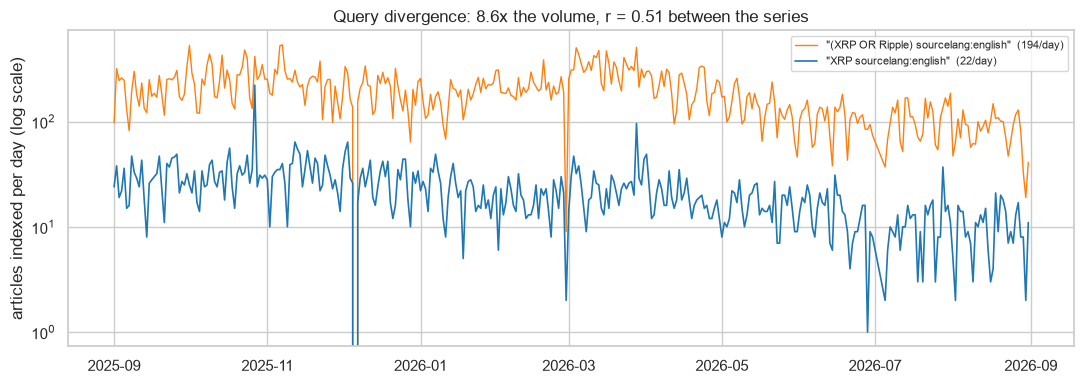

In [30]:
# How far apart are the two queries, actually?
narrow = RAW["xrp_gdelt_volume"].rename(columns={"gdelt_article_count": "narrow"})
broad = RAW["xrp_gdelt_volume_broad"].rename(
    columns={"gdelt_article_count_broad": "broad"})
divergence = narrow.merge(broad, on="date", how="outer").sort_values("date")

ratio = divergence["broad"].sum() / divergence["narrow"].sum()
r_daily = divergence["narrow"].corr(divergence["broad"])

print(f'q = {CONFIG["gdelt_query"]!r}')
print(f"  mean {divergence['narrow'].mean():.1f} articles/day")
print(f'q = {CONFIG["gdelt_query_broad"]!r}')
print(f"  mean {divergence['broad'].mean():.1f} articles/day")
print(f"\nThe broad query returns {ratio:.2f}x the volume, but the two daily series")
print(f"correlate at only r = {r_daily:.2f}.")
print("\nThose two numbers together are the decision. If the extra coverage were simply")
print("more of the same story, volume would rise and the series would still move together.")
print("Instead the broad query multiplies volume by an order of magnitude while agreeing")
print("with the narrow one roughly half the time - so most of what it adds is responding")
print("to something other than XRP: Ripple Labs as a company, and 'ripple effect' as a")
print("figure of speech. The narrow query is kept, and the cost is accepted and stated:")
print("coverage that names only 'Ripple' is missed, which biases the corpus toward")
print("asset-focused reporting and away from corporate news.")

# Carried into the §2.0 report once the validation framework exists; this cell runs
# during acquisition, before log_row is defined.
QUERY_DIVERGENCE = {"ratio": ratio, "daily_r": r_daily}

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(divergence["date"], divergence["broad"], lw=1,
        label=f'"{CONFIG["gdelt_query_broad"]}"  ({divergence["broad"].mean():.0f}/day)',
        color="tab:orange")
ax.plot(divergence["date"], divergence["narrow"], lw=1.2,
        label=f'"{CONFIG["gdelt_query"]}"  ({divergence["narrow"].mean():.0f}/day)',
        color="tab:blue")
ax.set_yscale("log")
ax.set_ylabel("articles indexed per day (log scale)")
ax.set_title(f"Query divergence: {ratio:.1f}x the volume, r = {r_daily:.2f} between the series")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

#### NewsAPI, retained and demoted

The midterm's NewsAPI sample is kept exactly as acquired. It covers 2026-06-09 to
2026-06-29, which falls **inside** the new study window, so it serves as an independent
second corpus over that overlap: §2.1.3 compares what the two providers saw on the same
21 days, which is a direct measurement of corpus selection rather than a caveat about it.

It is **not** re-acquired. The developer tier serves only the last ~30 days, which no
longer intersects the anchor — so a live re-run cannot reproduce this file, and the
notebook does not pretend otherwise. It is frozen evidence, and the manifest checksum is
what makes that claim checkable.

### Developer activity: the XRP Ledger as a software project

Every stream so far measures the market or the ledger's output. This one measures the
**people building the thing** — a genuinely different kind of evidence, and the one the
coursework brief singles out when it asks for a fusion of *"structural developer metrics
(GitHub updates)"* with *"shifting transaction velocities"*.

Four repositories, chosen because together they constitute the ledger as a working system
rather than because they belong to the same organisation:

| Repository | What it is | Why it is here |
| --- | --- | --- |
| `XRPLF/rippled` | core server, C++ | the protocol implementation itself |
| `XRPLF/clio` | API / query server | how applications actually read the ledger |
| `XRPLF/XRPL-Standards` | XLS proposals | where protocol *evolution* is negotiated |
| `XRPLF/xrpl.js` | JS client library | the main integration surface for developers |

Commits are retained individually rather than pre-aggregated, for two reasons. Distinct
contributors per period cannot be recovered from a count, and the **commit message itself
carries structure worth reading**: these repositories use conventional-commit prefixes
(`feat:`, `fix:`, `chore:`, `refactor:`, `ci:`), so each commit can be classified by the
*kind* of work it represents. "How much development" and "what kind of development" are
different questions, and only the second can distinguish a project adding capability from
one keeping the lights on.

The endpoint is unauthenticated (60 requests/hour), which the four repositories fit inside
at roughly 18 paginated calls. A `GITHUB_TOKEN` in `.env` raises the ceiling to 5,000/hour
and is used automatically if present, but is not required.

In [31]:
# Conventional-commit prefixes, grouped by what the work signifies. Declared as data so
# the grouping is inspectable rather than buried in a chain of conditionals.
COMMIT_TYPE_RE = re.compile(r"^(\w+)(\([^)]*\))?!?:")
COMMIT_TYPE_GROUPS = {
    "feat": "feature",
    "fix": "fix", "perf": "fix",
    "refactor": "maintenance", "chore": "maintenance", "style": "maintenance",
    "build": "maintenance", "ci": "maintenance", "test": "maintenance",
    "docs": "docs",
}


def classify_commit(message: str) -> str:
    """Map a commit subject to the kind of work it represents."""
    subject = str(message).split("\n")[0].strip()
    match = COMMIT_TYPE_RE.match(subject)
    if not match:
        return "unlabelled"
    return COMMIT_TYPE_GROUPS.get(match.group(1).lower(), "other")


def _github_headers() -> dict:
    """Authenticate if a token is available; the public ceiling suffices if not."""
    headers = {"Accept": "application/vnd.github+json",
               "X-GitHub-Api-Version": "2022-11-28"}
    token = os.environ.get("GITHUB_TOKEN")
    if token:
        headers["Authorization"] = f"Bearer {token}"
    return headers


def _validate_github_list(payload: JsonPayload) -> str | None:
    """Both endpoints used here return a bare JSON array."""
    if not isinstance(payload, list):
        return "expected a JSON array"
    return None


def fetch_github_commits(
    repos: dict | None = None, start: pd.Timestamp = None,
    end: pd.Timestamp = None, max_pages: int = 30,
) -> pd.DataFrame:
    """
    Fetch every commit landing in the window, one row per commit.

    `since`/`until` filter on committer date, which is when the work landed on the branch
    rather than when it was originally written - the right timestamp for an activity
    series. Pagination stops on a short page; `max_pages` is a guard against an
    unbounded walk if the API ever stops honouring the window.
    """
    repos = CONFIG["github_repos"] if repos is None else repos
    start = ANALYSIS_START if start is None else start
    end = ANALYSIS_END if end is None else end
    rows = []

    for repo in repos:
        print(f"Attempting to fetch commits for {repo} ...")
        for page in range(1, max_pages + 1):
            payload = fetch_json(
                f"https://api.github.com/repos/{repo}/commits",
                {"since": start.strftime("%Y-%m-%dT00:00:00Z"),
                 "until": (end + pd.Timedelta(days=1)).strftime("%Y-%m-%dT00:00:00Z"),
                 "per_page": 100, "page": page},
                validate=_validate_github_list,
            )
            if not payload:
                break
            for entry in payload:
                commit = entry.get("commit") or {}
                message = commit.get("message", "")
                rows.append({
                    "repo": repo,
                    "sha": (entry.get("sha") or "")[:12],
                    "date": (commit.get("committer") or {}).get("date"),
                    # Prefer the GitHub login; fall back to the git name when the commit
                    # is not linked to an account.
                    "author": ((entry.get("author") or {}).get("login")
                               or (commit.get("author") or {}).get("name")
                               or "unknown"),
                    "commit_type": classify_commit(message),
                    "is_merge": len(entry.get("parents", [])) > 1,
                    "subject": message.split("\n")[0][:140],
                })
            if len(payload) < 100:
                break

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df["date"] = pd.to_datetime(df["date"], utc=True).dt.tz_localize(None)
    df = df.drop_duplicates(subset=["repo", "sha"]).sort_values("date")
    print(f"Developer activity acquired ({len(df)} commits across {len(repos)} repositories).")
    return df.reset_index(drop=True)


def fetch_github_releases(
    repos: dict | None = None, start: pd.Timestamp = None, end: pd.Timestamp = None,
) -> pd.DataFrame:
    """Published releases in the window - the cadence at which work reaches users."""
    repos = CONFIG["github_repos"] if repos is None else repos
    start = ANALYSIS_START if start is None else start
    end = ANALYSIS_END if end is None else end
    rows = []

    for repo in repos:
        payload = fetch_json(
            f"https://api.github.com/repos/{repo}/releases", {"per_page": 100},
            validate=_validate_github_list, required=False,
        )
        for entry in payload or []:
            published = entry.get("published_at")
            if not published:          # a draft has no publication date
                continue
            stamp = pd.Timestamp(published).tz_localize(None).normalize()
            if start <= stamp <= end:
                rows.append({"repo": repo, "tag": entry.get("tag_name"),
                             "date": stamp,
                             "prerelease": bool(entry.get("prerelease"))})

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    print(f"Releases acquired ({len(df)} in window).")
    return df.sort_values("date").reset_index(drop=True)

In [32]:
# GitHub's public ceiling is 60 requests/hour, well above what four repositories need,
# but the politeness floor keeps the walk from bursting.
MIN_INTERVAL_BY_HOST["api.github.com"] = 1.0
SESSION.headers.update(_github_headers())
print("GitHub auth:", "GITHUB_TOKEN found (5,000/hr)"
      if os.environ.get("GITHUB_TOKEN") else "unauthenticated (60/hr, sufficient here)")

RAW.bind(
    "xrp_github_commits",
    load_or_fetch(
        "xrp_github_commits",
        fetch_github_commits,
        parse_dates=["date"],
        source=f"GitHub /repos/{{repo}}/commits for {len(CONFIG['github_repos'])} XRPLF "
               f"repositories ({ANALYSIS_START.date()} -> {ANALYSIS_END.date()})",
    ),
    transform="GET x N pages -> JSON -> DataFrame (one row per commit, typed by subject)",
).head()

GitHub auth: unauthenticated (60/hr, sufficient here)
Loaded cached 'xrp_github_commits' (1684 rows) - checksum verified against manifest (recorded 2026-09-13T04:29:55).


,repo,sha,date,author,commit_type,is_merge,subject
0,XRPLF/clio,ffd18049eb33,2025-09-01 12:21:47,github-actions[bot],maintenance,False,style: Update pre-commit hooks (#2491)
1,XRPLF/clio,0e8896ad064a,2025-09-01 15:16:22,mathbunnyru,maintenance,False,ci: Use Python 3.13 in CI docker image (#2493)
2,XRPLF/clio,3df28f42ec43,2025-09-01 15:58:52,mathbunnyru,maintenance,False,ci: Use image with Python 3.13 (#2495)
3,XRPLF/clio,402ab29a73e5,2025-09-02 10:14:37,emreariyurek,fix,False,fix: Change error style in Config (#2314)
4,XRPLF/xrpl.js,3c471fbfe2f2,2025-09-02 14:59:22,Patel-Raj11,unlabelled,False,release workflow fix - skip .github directory ...


In [33]:
RAW.bind(
    "xrp_github_releases",
    load_or_fetch(
        "xrp_github_releases",
        fetch_github_releases,
        parse_dates=["date"],
        source=f"GitHub /repos/{{repo}}/releases for {len(CONFIG['github_repos'])} XRPLF "
               f"repositories (trimmed to the study window)",
    ),
    transform="GET -> JSON -> DataFrame (one row per published release)",
).head()

Loaded cached 'xrp_github_releases' (74 rows) - checksum verified against manifest (recorded 2026-09-13T04:29:55).


,repo,tag,date,prerelease
0,XRPLF/xrpl.js,xrpl@4.4.1,2025-09-02,False
1,XRPLF/rippled,2.6.1-rc1,2025-09-17,True
2,XRPLF/rippled,2.5.1,2025-09-17,False
3,XRPLF/rippled,2.6.1-rc2,2025-09-24,True
4,XRPLF/xrpl.js,xrpl@4.4.2,2025-09-25,False


In [34]:
RAW.bind(
    "xrp_news",
    load_or_fetch(
        "xrp_news",
        lambda: fetch_xrp_news_windowed(
            api_key=NEWS_API_KEY, weeks=4, end_date="2026-06-29",
        ),
        parse_dates=["date"],
        source="NewsAPI /v2/everything (q=XRP, language=en, sortBy=publishedAt; "
               "4 weekly windows ending 2026-06-29) - FROZEN, see note above",
    ),
    transform="GET x N windows -> JSON -> DataFrame (one row per article)",
).head()

Loaded cached 'xrp_news' (399 rows) - checksum verified against manifest (recorded 2026-09-13T04:05:33).


,headline,snippet,published_at,source,date
0,SBI's $289 million Bitbank deal is symptomatic...,The investment bank said the purchase of Japan...,2026-06-28T15:00:00Z,CoinDesk,2026-06-28 15:00:00
1,"Stacks ranks 40th in Coinbase’s COIN50 Index, ...",Stacks' inclusion in Coinbase's COIN50 Index e...,2026-06-28T13:23:58Z,Crypto Briefing,2026-06-28 13:23:58
2,XRP investors capitulate at fastest pace since...,XRP’s retreat toward $1 is testing whether one...,2026-06-28T12:05:22Z,CryptoSlate,2026-06-28 12:05:22
3,"Bitcoin falls below $60,000, on track for a ra...",The token is down nearly 7% on the week with t...,2026-06-28T07:10:52Z,CoinDesk,2026-06-28 07:10:52
4,Ripple Secures Preliminary Luxembourg Approval...,Ripple Secures Preliminary Luxembourg Approval...,2026-06-28T01:05:00Z,Bitcoinist,2026-06-28 01:05:00


# 3 (cont.) — Data preparation, validation and feature engineering

With the five raw streams acquired, this phase forges them into a single, analysis-ready **daily** dataset. It proceeds in four movements:

1. **Automated validation** (§2.0) — a declarative schema contract and a reusable check library run over every stream, producing a single data-quality report rather than ad-hoc inspection.
2. **News cleaning & sentiment** (§2.1) — regex filtering of corrupted text, removal of syndicated reprints, and VADER scoring.
3. **Feature engineering** (§2.2, all vectorised) — rolling volatility, daily returns, on-chain activity intensity.
4. **Assembly** (§2.3) — merge on a common `date` key into a `master` daily frame under an explicit, executable missing-value policy, closing with post-condition assertions.

## 2.0 An automated validation framework

Validating five heterogeneous streams by eye does not scale and does not survive a re-run on refreshed data. Instead, validation here is **declarative and automated**: each stream declares a *schema contract* (the dtype every column must hold) and a *list of checks*, and one engine runs them all and emits a single tidy report. Adding a stream means adding a contract, not writing new inspection code.

Three ideas do the work:

- **Schema enforcement.** `enforce_schema` coerces every column to its contracted dtype and *reports how many values were lost to coercion* rather than silently turning them into NaN. This is not hypothetical: Coin Metrics returns its activity counts as JSON **strings**, and the Fear & Greed index arrives as a string too. Without an enforced contract those would propagate as `object` columns and produce meaningless correlations downstream.
- **A reusable check library.** Each check is a small parameterised factory (`chk_between(column, low, high)`, `chk_daily_calendar("date")`, …) returning a function the engine applies. The checks are therefore composable and shared across streams instead of copy-pasted per frame.
- **Report, then act deliberately.** Every check records what it found, what was *done* about it, and why. A failed check is not automatically a dropped row: some findings are corrected (syndicated reprints), some are deliberately preserved (days with no news stay `NaN` rather than being imputed to zero sentiment), and the report states which.

In [35]:
# --- Declarative schema contracts --------------------------------------------------
# The dtype family every column of every stream must hold before analysis. The family
# is contracted rather than the exact precision, because pandas selects the datetime
# resolution itself; what matters is that a date is a datetime and a count is numeric.
# Enforcing this
# centrally catches a provider changing a field's type - Coin Metrics returns its counts
# as JSON strings, alternative.me returns its index as one - at the boundary, rather than
# letting an `object` column produce a meaningless correlation later.
SCHEMAS = {
    "xrp_kraken": {"date": "datetime64", "open": "float64", "high": "float64",
                   "low": "float64", "close": "float64", "vwap": "float64",
                   "volume": "float64", "trade_count": "float64",
                   "volume_usd": "float64"},
    "xrp_bitstamp": {"date": "datetime64", "open": "float64", "high": "float64",
                     "low": "float64", "close": "float64", "volume": "float64"},
    "xrp_onchain": {"date": "datetime64", "tx_count": "float64",
                    "active_addresses": "float64", "transfer_count": "float64",
                    "addresses_with_balance": "float64", "fees_native": "float64",
                    "ledger_count": "float64", "mvrv": "float64",
                    "market_cap_usd": "float64", "reported_volume_usd": "float64",
                    "reference_price_usd": "float64"},
    "xrp_fear_greed": {"date": "datetime64", "fear_greed": "float64",
                       "fear_greed_label": "string"},
    "xrp_gdelt_news": {"date": "datetime64", "headline": "string",
                       "published_at": "string", "source": "string",
                       "source_country": "string", "language": "string",
                       "url": "string"},
    "xrp_gdelt_coverage": {"window_start": "datetime64", "window_end": "datetime64",
                           "articles": "float64", "status": "string"},
    "xrp_gdelt_tone": {"date": "datetime64", "gdelt_tone": "float64"},
    "xrp_gdelt_volume": {"date": "datetime64", "gdelt_article_count": "float64"},
    "xrp_gdelt_volume_broad": {"date": "datetime64",
                               "gdelt_article_count_broad": "float64"},
    "xrp_github_commits": {"date": "datetime64", "repo": "string", "sha": "string",
                           "author": "string", "commit_type": "string",
                           "subject": "string"},
    "xrp_github_releases": {"date": "datetime64", "repo": "string", "tag": "string"},
    "xrp_news": {"date": "datetime64", "headline": "string", "snippet": "string",
                 "published_at": "string", "source": "string"},
}

# Every check run by any stage of the pipeline is appended here, so the notebook can
# emit one consolidated data-quality report at the end of Phase 2.
VALIDATION_LOG: list[dict] = []


def log_row(stream: str, check: str, n_failed: int, action: str,
            detail: str = "", status: str | None = None) -> dict:
    """
    Build one row of the validation report (and record it in the running log).

    `status` overrides the PASS/WARN that `n_failed` implies. It exists for one case: the
    tool comparisons in §4.0 have no failure count at all. Filing them as WARN would
    overstate what this pipeline found wrong with itself; filing them as PASS would blank
    the finding, since a passing row carries no detail. They are INFO, and counted apart.

    A row registered inside `expected_failure` is a DRILL - a guard fired at an input built
    to break it. §4.7 already excludes those from its fault count; classifying them here
    means §4.6 does too, so the two reports cannot disagree about whether this pipeline
    found something wrong.
    """
    reportable = bool(n_failed) or status is not None
    if DRILL["depth"]:
        status = "DRILL"
    row = {
        "stream": stream,
        "check": check,
        "n_failed": int(n_failed),
        "status": status or ("PASS" if n_failed == 0 else "WARN"),
        "action": action if reportable else "-",
        "detail": detail if reportable else "",
    }
    VALIDATION_LOG.append(row)
    return row


def enforce_schema(df: pd.DataFrame, name: str, spec: dict) -> tuple[pd.DataFrame, list]:
    """
    Coerce every contracted column to its declared dtype.

    Coercion is deliberately non-silent: values that cannot be converted become NaN and
    are *counted*, so a provider quietly changing a field's format shows up as a number in
    the report instead of as an unexplained gap in the analysis.
    """
    df = df.copy()
    rows = []
    for column, dtype in spec.items():
        if column not in df.columns:
            rows.append(log_row(name, f"schema · {column}", 1, "STOP - column absent",
                                f"contracted column '{column}' is missing"))
            continue
        before = int(df[column].isna().sum())
        if dtype == "datetime64":
            df[column] = pd.to_datetime(df[column], errors="coerce")
            holds = pd.api.types.is_datetime64_any_dtype(df[column])
        elif dtype == "float64":
            df[column] = pd.to_numeric(df[column], errors="coerce").astype("float64")
            holds = pd.api.types.is_numeric_dtype(df[column])
        else:
            df[column] = df[column].astype("string")
            holds = pd.api.types.is_string_dtype(df[column])
        lost = int(df[column].isna().sum()) - before

        # Coercion is only half the contract: verify the column really ended up in the
        # declared dtype family, so a silently-failed conversion cannot pass unnoticed.
        if not holds:
            rows.append(log_row(name, f"schema · {column} → {dtype}", 1,
                                "STOP - coercion did not yield the contracted dtype",
                                f"holds {df[column].dtype} instead"))
            continue
        rows.append(log_row(name, f"schema · {column} → {dtype}", lost,
                            "unparseable values coerced to NaN",
                            f"{lost} of {len(df)} values"))
    return df, rows

In [36]:
# --- Reusable check library ---------------------------------------------------------
# Each factory returns a function of the DataFrame yielding (n_failed, detail), so checks
# compose freely across streams instead of being re-written per frame.

def chk_required(columns: list[str]) -> Check:
    """Every contracted column must be present."""
    def run(df: pd.DataFrame) -> CheckResult:
        missing = [c for c in columns if c not in df.columns]
        return len(missing), f"absent: {', '.join(missing)}"
    return run


def chk_no_nulls(columns: list[str]) -> Check:
    """Columns that must never be null for the analysis to be meaningful."""
    def run(df: pd.DataFrame) -> CheckResult:
        bad = {c: int(df[c].isna().sum()) for c in columns if c in df.columns}
        bad = {c: n for c, n in bad.items() if n}
        return sum(bad.values()), "; ".join(f"{c}: {n} null" for c, n in bad.items())
    return run


def chk_unique(subset: list[str]) -> Check:
    """No duplicate keys - a duplicated day would double-weight it in every aggregate."""
    def run(df: pd.DataFrame) -> CheckResult:
        n = int(df.duplicated(subset=subset).sum())
        return n, f"{n} duplicate rows on {' + '.join(subset)}"
    return run


def chk_sorted(column: str) -> Check:
    """Time series must be in ascending order before any rolling window is applied."""
    def run(df: pd.DataFrame) -> CheckResult:
        return (0, "") if df[column].is_monotonic_increasing else (1, "not ascending")
    return run


def chk_daily_calendar(column: str) -> Check:
    """A daily series should carry one row per calendar day with no gaps."""
    def run(df: pd.DataFrame) -> CheckResult:
        days = pd.DatetimeIndex(pd.to_datetime(df[column]).dt.normalize().unique())
        expected = pd.date_range(days.min(), days.max(), freq="D")
        missing = expected.difference(days)
        shown = ", ".join(d.strftime("%Y-%m-%d") for d in missing[:4])
        more = f" (+{len(missing) - 4} more)" if len(missing) > 4 else ""
        return len(missing), f"missing days: {shown}{more}"
    return run


def chk_between(column: str, low: float, high: float) -> Check:
    """Domain constraint: a value outside its documented range is a corrupted reading."""
    def run(df: pd.DataFrame) -> CheckResult:
        s = df[column].dropna()
        n = int(((s < low) | (s > high)).sum())
        return n, f"{n} values outside [{low}, {high}]"
    return run


def chk_greater_than(columns: list[str], floor: float) -> Check:
    """Strict lower bound - e.g. a price must be > 0, and so must a denominator."""
    def run(df: pd.DataFrame) -> CheckResult:
        bad = {c: int((df[c].dropna() <= floor).sum()) for c in columns if c in df.columns}
        bad = {c: n for c, n in bad.items() if n}
        return sum(bad.values()), "; ".join(f"{c}: {n} ≤ {floor}" for c, n in bad.items())
    return run


def chk_integral(columns: list[str]) -> Check:
    """Counts must be whole numbers; a fractional count signals a parsing error."""
    def run(df: pd.DataFrame) -> CheckResult:
        bad = {c: int((df[c].dropna() % 1 != 0).sum()) for c in columns if c in df.columns}
        bad = {c: n for c, n in bad.items() if n}
        return sum(bad.values()), "; ".join(f"{c}: {n} fractional" for c, n in bad.items())
    return run


def chk_ohlc_bounds() -> Check:
    """High must bound the candle from above and Low from below - else it is corrupt."""
    def run(df: pd.DataFrame) -> CheckResult:
        broken = (
            (df["high"] < df["low"])
            | (df["high"] < df[["open", "close"]].max(axis=1))
            | (df["low"] > df[["open", "close"]].min(axis=1))
        )
        return int(broken.sum()), f"{int(broken.sum())} candles violate high ≥ o/c ≥ low"
    return run


def chk_extreme_jump(column: str, threshold: float) -> Check:
    """
    Flag implausible moves between consecutive rows.

    An hourly crypto price can move sharply, but a jump beyond this threshold is far more
    likely to be a bad print from the aggregator than a real move, and would dominate any
    volatility statistic computed from it.
    """
    def run(df: pd.DataFrame) -> CheckResult:
        jumps = df[column].pct_change().abs().dropna()
        n = int((jumps > threshold).sum())
        return n, f"{n} consecutive moves > {threshold:.0%} (max {jumps.max():.2%})"
    return run


def chk_flagged(column: str, what: str) -> Check:
    """
    Count the rows a detector flagged.

    The §2.4 noise detectors compute their flags from rolling robust statistics, which the
    (label, action, fn) contract cannot express in one pass over a frame. They therefore
    write a boolean column and this check reports it, so the results reach
    validation_report.csv through the same machinery as every other check rather than
    through a parallel path that happens to write the same file.
    """
    def run(df: pd.DataFrame) -> CheckResult:
        n = int(df[column].fillna(False).sum())
        return n, f"{n} of {len(df)} days: {what}"
    return run


def chk_constant_run(column: str, length: int) -> Check:
    """
    A long run of identical values signals a stuck feed - or an over-eager forward-fill.

    Worth checking explicitly *because* this pipeline forward-fills: the check guards
    against the imputation strategy quietly manufacturing a flat, low-volatility stretch.
    """
    def run(df: pd.DataFrame) -> CheckResult:
        s = df[column]
        run_id = (s != s.shift()).cumsum()
        longest = int(s.groupby(run_id).transform("size").max())
        return (1 if longest >= length else 0), f"longest identical run = {longest} rows"
    return run


def validate_stream(name: str, df: pd.DataFrame,
                    checks: list[tuple[str, str, Check]]) -> pd.DataFrame:
    """Run `checks` (label, action, fn) over one stream and return its report slice."""
    rows = []
    for label, action, fn in checks:
        n_failed, detail = fn(df)
        rows.append(log_row(name, label, n_failed, action, detail))
    return pd.DataFrame(rows)

### 2.0.1 Catching leakage by measurement rather than by convention

Every check above asks whether a value is *plausible*. None asks the question that decides
whether a forward-looking result means anything: **does this feature, at time *t*, contain
information that did not exist until after *t*?**

The usual defence is a naming convention — call the trailing windows `rolling_` and the
forward ones `next_`, and review the code. That defends against nothing, because the defect
is never in the name. It is in `center=True`, in a `.mean()` taken over the whole sample
before splitting, in a `shift` with the wrong sign, in a merge that quietly carries a later
value backwards. Each of those produces a correctly named column that is wrong.

So leakage is measured here, by **truncation**. Rebuild the feature from the first *k* rows
alone and compare it with the same feature built from everything. A value that only ever
looked backwards is bit-identical. One that read *h* days ahead differs in exactly its last
*h* positions — and that difference *is* the horizon:

$$h = k - \min\{\,i : f(x_{0:k})_i \neq f(x_{0:n})_i\,\}$$

This returns a number rather than a verdict, which matters. A forward-looking target is
*supposed* to look ahead, so the useful assertion is not "nothing looks forward" but
"nothing looks **further** forward than it declared". A target declaring a three-day horizon
that measures four is reaching into a day it promised not to touch.

The detector needs no knowledge of how a feature was built, so it cannot be fooled by one
written in a way nobody anticipated — and it is tested in §3.2 against controls that leak on
purpose, because a leak detector that has never caught anything is an untested one.

Those controls earned their place immediately. This function originally tried four cut
points rather than all of them, and one control slipped past: a backfill leaks only across
the gaps it fills, and the sentiment series has just 7 gaps in 365 days, so none of the four
cuts landed in one. The detector was not wrong, it was under-powered — a distinction that
only exists because something known to be broken was pointed at it.

In [37]:
class LeakageError(AssertionError):
    """Raised when a feature reads further into the future than it declared."""


def lookahead_horizon(build: FeatureBuilder, frame: pd.DataFrame,
                      *, min_cut: int = 40,
                      stride: int = 1, tol: float = 1e-10) -> int:
    """
    How many trailing values of `build(frame)` depend on rows that come after them.

    Returns 0 for a strictly backward-looking feature, `h` for one that reads h rows
    ahead, and a number on the order of the remaining series length for one that uses a
    whole-sample statistic.

    EVERY cut point is tried, not a sample of them, and that is not thoroughness for its
    own sake. The first version of this function tested four - at 50%, 65%, 80% and 90% -
    and the `bfill` control in §3.2 defeated it, because a backfill only carries information
    backwards across a gap, and `sentiment_mean` has just 7 gaps in 365 days: no sampled cut
    happened to land in one. Sparse leakage needs a dense sweep. At this sample size the
    exhaustive version costs roughly 25 ms per feature, so there is nothing to trade.
    """
    full = np.asarray(build(frame), dtype=float)
    n = len(frame)
    worst = 0
    for cut in range(min_cut, n, stride):   # too short a prefix cannot separate leakage
        prefix = np.asarray(build(frame.iloc[:cut]), dtype=float)
        differs = ~np.isclose(prefix, full[:cut], rtol=0, atol=tol, equal_nan=True)
        positions = np.flatnonzero(differs)
        if positions.size:
            worst = max(worst, cut - int(positions.min()))
    return worst


def audit_lookahead(build: FeatureBuilder, frame: pd.DataFrame, label: str,
                    declared: int,
                    *, stream: str = "leakage", strict: bool = True) -> dict:
    """
    Measure a feature's horizon, record it, and stop the notebook if it exceeds `declared`.

    `declared` is the contract: 0 for anything used as a predictor, and the exact horizon
    for a deliberately forward-looking target. Measuring LESS than declared is not an
    error - it means the feature is more conservative than its contract - but it is
    reported, because it usually means the contract is wrong.

    A feature that is *supposed* to fail - a control proving the detector works - should be
    audited inside `expected_failure`, which records the error without counting it.
    """
    measured = lookahead_horizon(build, frame)
    if measured > declared:
        verdict, failed = "LEAKS", 1
    elif measured < declared:
        verdict, failed = "reaches less far than declared", 0
    else:
        verdict, failed = "matches its declaration", 0

    log_row(stream, f"lookahead · {label}", failed,
            "STOP - reads beyond its declared horizon" if failed
            else "verified by truncation",
            f"declared {declared} day(s), measured {measured}",
            status=None if failed else "INFO")

    if failed:
        LOGGER.error("leakage DETECTED: %s declared %d days, measured %d",
                     label, declared, measured,
                     extra={"stage": stream, "frame": label})
        if strict:
            raise LeakageError(
                f"{label} declared a {declared}-day horizon but reads {measured} days "
                f"ahead. Rebuilding it from a prefix of the data changes values that "
                f"were already final, so any forward-looking result using it is invalid."
            )
    return {"feature": label, "declared": declared, "measured": measured,
            "verdict": verdict}

### 2.0.2 What each frame promises about itself

The post-conditions below run **inside** `Stage.bind`, before a frame becomes reachable.
That placement is the point. An `assert` written after a construction protects the lines
below it in the same cell; a post-condition registered against a frame name protects every
use of that frame anywhere in the notebook, including the ones written months later by
someone who never read the cell that built it.

They are deliberately the assertions that would be *embarrassing* to violate rather than a
restatement of the schema — the daily calendar being contiguous, a proportion staying inside
[0, 1], a price series never going negative, the flag columns being genuinely boolean. Each
one encodes something Phase 3 silently relies on: an unequal-interval calendar would make
every rolling window mean something different from day to day, and a negative price would
propagate a complex number through the log return without raising anything.

In [38]:
@postcondition("master", "master_forward", "master_alt")
def daily_calendar_is_contiguous(frame: pd.DataFrame) -> tuple[bool, str]:
    """Every rolling window in Phase 3 assumes one row per day, with no gaps."""
    gaps = frame["date"].diff().dropna() != pd.Timedelta(days=1)
    return not gaps.any(), f"{int(gaps.sum())} irregular intervals in the date column"


@postcondition("master", "master_forward", "master_alt", "daily_market", "daily_ohlc")
def prices_are_positive(frame: pd.DataFrame) -> tuple[bool, str]:
    """A non-positive price makes log(price) undefined and log returns silently complex."""
    columns = [c for c in ("price", "close", "open", "high", "low") if c in frame]
    bad = {c: int((frame[c] <= 0).sum()) for c in columns if (frame[c] <= 0).any()}
    return not bad, f"non-positive values: {bad}" if bad else "all positive"


@postcondition("daily_noise_flags")
def flags_are_boolean(frame: pd.DataFrame) -> tuple[bool, str]:
    """A flag that is NaN or 0/1-as-float breaks `.any(axis=1)` and every count below."""
    flags = [c for c in frame.columns if c.startswith("flag_")]
    wrong = [c for c in flags if frame[c].dtype != bool]
    return not wrong, f"{len(flags)} flag columns, non-boolean: {wrong}"


@postcondition("daily_sentiment", "daily_sentiment_base", "daily_sentiment_broad")
def sentiment_within_vader_range(frame: pd.DataFrame) -> tuple[bool, str]:
    """VADER's compound score is bounded to [-1, 1]; a mean of it cannot escape that."""
    column = next(c for c in frame.columns if c.startswith("sentiment_mean"))
    outside = int(((frame[column] < -1) | (frame[column] > 1)).sum())
    return outside == 0, f"{outside} daily means outside [-1, 1]"


@postcondition("network_state_index")
def index_axes_are_finite(frame: pd.DataFrame) -> tuple[bool, str]:
    """An infinite axis means a zero trailing standard deviation went unnoticed."""
    axes = [c for c in ("utility", "turbulence", "fear") if c in frame]
    bad = int(sum(np.isinf(frame[c]).sum() for c in axes))
    return bad == 0, f"{bad} non-finite values across {len(axes)} axes"


registered = sorted(POSTCONDITIONS)
print(f"{sum(len(v) for v in POSTCONDITIONS.values())} post-conditions registered across "
      f"{len(registered)} frames:")
for key in registered:
    print(f"  {key:22} {', '.join(fn.__name__ for fn in POSTCONDITIONS[key])}")
print("\nThese run inside Stage.bind. A frame that fails one is never stored, so the error")
print("names the stage that produced it rather than the cell that later tripped over it.")

13 post-conditions registered across 10 frames:
  daily_market           prices_are_positive
  daily_noise_flags      flags_are_boolean
  daily_ohlc             prices_are_positive
  daily_sentiment        sentiment_within_vader_range
  daily_sentiment_base   sentiment_within_vader_range
  daily_sentiment_broad  sentiment_within_vader_range
  master                 daily_calendar_is_contiguous, prices_are_positive
  master_alt             daily_calendar_is_contiguous, prices_are_positive
  master_forward         daily_calendar_is_contiguous, prices_are_positive
  network_state_index    index_axes_are_finite

These run inside Stage.bind. A frame that fails one is never stored, so the error
names the stage that produced it rather than the cell that later tripped over it.


### Per-stream contracts

Each stream now declares what "valid" means for it. Note that the *action* column matters as much as the check: this pipeline distinguishes a defect to be corrected from a characteristic of the data to be recorded and carried forward.

Two checks deserve comment. `chk_daily_calendar` on the news stream is **expected** to find gaps — there are days with no XRP coverage at all — and the action records the deliberate decision to leave those days as `NaN` sentiment rather than impute a neutral score, which would fabricate an observation. And `chk_constant_run` exists specifically to police §2.2's forward-fill: an imputation strategy that quietly manufactured a flat, artificially calm stretch of price would bias every volatility figure in Phase 3, so the notebook checks its own imputation rather than trusting it.

In [39]:
STREAM_CHECKS = {
    "xrp_kraken": [
        ("all contracted columns present", "stop", chk_required(["date", "close", "high", "low", "volume", "trade_count"])),
        ("no nulls in the OHLCV block", "drop or investigate", chk_no_nulls(["date", "open", "high", "low", "close", "volume", "trade_count"])),
        ("no duplicate days", "de-duplicate", chk_unique(["date"])),
        ("days ascending", "sort before rolling windows", chk_sorted("date")),
        ("gap-free daily calendar", "report; rolling windows assume equal spacing", chk_daily_calendar("date")),
        ("candle bounds coherent (high >= o/c >= low)", "reject candle", chk_ohlc_bounds()),
        ("all prices strictly positive", "reject candle", chk_greater_than(["open", "high", "low", "close", "vwap"], 0)),
        ("volume non-negative", "reject reading", chk_greater_than(["volume", "volume_usd"], -1)),
        ("trade count positive (a day with no trades is not a day)", "investigate", chk_greater_than(["trade_count"], 0)),
        ("no implausible daily jumps", "flag as suspect print", chk_extreme_jump("close", 0.40)),
    ],
    "xrp_bitstamp": [
        ("all contracted columns present", "stop", chk_required(["date", "open", "high", "low", "close", "volume"])),
        ("no nulls", "drop candle", chk_no_nulls(["date", "open", "high", "low", "close", "volume"])),
        ("no duplicate days", "de-duplicate", chk_unique(["date"])),
        ("gap-free daily calendar", "report", chk_daily_calendar("date")),
        ("candle bounds coherent (high >= o/c >= low)", "reject candle", chk_ohlc_bounds()),
        ("all prices strictly positive", "reject candle", chk_greater_than(["open", "high", "low", "close"], 0)),
    ],
    "xrp_onchain": [
        ("all contracted columns present", "stop", chk_required(["date", "tx_count", "active_addresses", "transfer_count"])),
        ("no nulls in the core activity counts", "drop day", chk_no_nulls(["date", "tx_count", "active_addresses", "transfer_count"])),
        ("no duplicate days", "de-duplicate", chk_unique(["date"])),
        ("gap-free daily calendar", "report; merge leaves gaps as NaN", chk_daily_calendar("date")),
        ("counts are whole numbers", "investigate parsing", chk_integral(["tx_count", "active_addresses", "transfer_count", "ledger_count"])),
        ("active_addresses > 0 (divisor)", "exclude from ratio", chk_greater_than(["active_addresses"], 0)),
        ("MVRV strictly positive", "reject reading", chk_greater_than(["mvrv"], 0)),
        ("reported volume non-negative", "reject reading", chk_greater_than(["reported_volume_usd"], -1)),
        ("no implausible jumps in active addresses", "flag - see the note in 2.0", chk_extreme_jump("active_addresses", 1.0)),
    ],
    "xrp_fear_greed": [
        ("all contracted columns present", "stop", chk_required(["date", "fear_greed", "fear_greed_label"])),
        ("no nulls", "drop day", chk_no_nulls(["date", "fear_greed"])),
        ("no duplicate days", "de-duplicate", chk_unique(["date"])),
        ("gap-free daily calendar", "report", chk_daily_calendar("date")),
        ("index within its documented 0-100 scale", "reject reading", chk_between("fear_greed", 0, 100)),
    ],
    "xrp_gdelt_news": [
        ("all contracted columns present", "stop", chk_required(["headline", "published_at", "date", "source", "url"])),
        ("headline/date/source never null", "drop article", chk_no_nulls(["headline", "date", "source"])),
        ("no duplicate articles by URL", "de-duplicate", chk_unique(["url"])),
        ("every day covered", "KEEP as NaN - no news is not neutral news", chk_daily_calendar("date")),
    ],
    "xrp_gdelt_coverage": [
        ("all contracted columns present", "stop", chk_required(["window_start", "window_end", "articles", "status"])),
        ("no nulls", "investigate", chk_no_nulls(["window_start", "window_end", "articles", "status"])),
        ("no duplicate windows", "de-duplicate", chk_unique(["window_start"])),
        ("windows ascending", "sort", chk_sorted("window_start")),
        ("articles non-negative", "investigate", chk_greater_than(["articles"], -1)),
    ],
    "xrp_gdelt_tone": [
        ("all contracted columns present", "stop", chk_required(["date", "gdelt_tone"])),
        ("no nulls", "drop day", chk_no_nulls(["date", "gdelt_tone"])),
        ("no duplicate days", "de-duplicate", chk_unique(["date"])),
        ("gap-free daily calendar", "report - GDELT indexing gaps are real", chk_daily_calendar("date")),
        ("tone within GDELT's documented -100..100 range", "reject reading", chk_between("gdelt_tone", -100, 100)),
    ],
    "xrp_gdelt_volume": [
        ("all contracted columns present", "stop", chk_required(["date", "gdelt_article_count"])),
        ("no nulls", "drop day", chk_no_nulls(["date", "gdelt_article_count"])),
        ("no duplicate days", "de-duplicate", chk_unique(["date"])),
        ("gap-free daily calendar", "report - GDELT indexing gaps are real", chk_daily_calendar("date")),
        ("article count non-negative", "reject reading", chk_greater_than(["gdelt_article_count"], -1)),
    ],
    "xrp_gdelt_volume_broad": [
        ("all contracted columns present", "stop", chk_required(["date", "gdelt_article_count_broad"])),
        ("no nulls", "drop day", chk_no_nulls(["date", "gdelt_article_count_broad"])),
        ("no duplicate days", "de-duplicate", chk_unique(["date"])),
        ("article count non-negative", "reject reading", chk_greater_than(["gdelt_article_count_broad"], -1)),
    ],
    "xrp_github_commits": [
        ("all contracted columns present", "stop", chk_required(["date", "repo", "sha", "author", "commit_type"])),
        ("no nulls in the identifying fields", "drop commit", chk_no_nulls(["date", "repo", "sha", "author"])),
        ("no duplicate commits", "de-duplicate", chk_unique(["repo", "sha"])),
        ("commits ascending", "sort", chk_sorted("date")),
    ],
    "xrp_github_releases": [
        ("all contracted columns present", "stop", chk_required(["date", "repo", "tag"])),
        ("no nulls", "drop release", chk_no_nulls(["date", "repo", "tag"])),
        ("no duplicate tags per repo", "de-duplicate", chk_unique(["repo", "tag"])),
    ],
    "xrp_news": [
        ("all contracted columns present", "stop", chk_required(["headline", "snippet", "published_at", "source", "date"])),
        ("headline/date/source never null", "drop article", chk_no_nulls(["headline", "date", "source"])),
        ("snippet present", "KEEP - scored on headline alone (see 2.1)", chk_no_nulls(["snippet"])),
        ("no exact duplicate articles", "de-duplicate", chk_unique(["headline", "published_at"])),
        ("every day covered", "KEEP as NaN - frozen 21-day overlap corpus", chk_daily_calendar("date")),
    ],
}

# RAW is iterated in bind order, so every acquired stream is contracted exactly once and
# the report rows appear in acquisition order. TYPED is a pure function of RAW: schema
# enforcement and validation add columns and flags, but never add or remove a row.
reports = []
for stream_name in RAW:
    typed, _ = enforce_schema(RAW[stream_name], stream_name, SCHEMAS[stream_name])
    reports.append(validate_stream(stream_name, typed, STREAM_CHECKS[stream_name]))
    TYPED.bind(
        stream_name, typed,
        parent=f"RAW.{stream_name}",
        transform="enforce_schema -> validate_stream",
    )
    assert len(typed) == len(RAW[stream_name]), (
        f"TYPED['{stream_name}'] changed the row count; typing must never drop data"
    )

stream_report = pd.concat(reports, ignore_index=True)
n_pass = int((stream_report["status"] == "PASS").sum())
print(f"Stream validation: {n_pass} of {len(stream_report)} checks passed; "
      f"{len(stream_report) - n_pass} raised a warning.\n")
display(stream_report[stream_report["status"] != "PASS"].reset_index(drop=True))

Stream validation: 57 of 65 checks passed; 8 raised a warning.



,stream,check,n_failed,status,action,detail
0,xrp_onchain,no implausible jumps in active addresses,3,WARN,flag - see the note in 2.0,3 consecutive moves > 100% (max 291.09%)
1,xrp_gdelt_news,headline/date/source never null,154,WARN,drop article,headline: 154 null
2,xrp_gdelt_news,every day covered,5,WARN,KEEP as NaN - no news is not neutral news,"missing days: 2025-12-06, 2026-07-01, 2026-07-..."
3,xrp_gdelt_coverage,no nulls,2,WARN,investigate,window_end: 2 null
4,xrp_gdelt_tone,gap-free daily calendar,4,WARN,report - GDELT indexing gaps are real,"missing days: 2026-07-01, 2026-07-02, 2026-07-..."
5,xrp_gdelt_volume,gap-free daily calendar,4,WARN,report - GDELT indexing gaps are real,"missing days: 2026-07-01, 2026-07-02, 2026-07-..."
6,xrp_news,snippet present,41,WARN,KEEP - scored on headline alone (see 2.1),snippet: 41 null
7,xrp_news,every day covered,4,WARN,KEEP as NaN - frozen 21-day overlap corpus,"missing days: 2026-06-09, 2026-06-10, 2026-06-..."


## 2.1 News cleaning, de-duplication & sentiment scoring

The corpus is now GDELT's, and it differs from NewsAPI's in two ways that matter before a
single score is computed.

**There is no snippet.** GDELT returns a headline and nothing else, so VADER sees roughly
70 characters per article rather than ~250. That is a real loss of signal, and §4.1
quantifies what it costs. It is the price of the horizon: 365 days of headlines is worth
more to a lagged analysis than 21 days of headlines-plus-snippets.

**The headlines arrive pre-tokenised, and badly.** GDELT normalises punctuation by padding
it with spaces, so a title reaches us as

> `XRP Price Prediction : XRP Faces Rising Selling Pressure Can Support at $1 . 33 Prevent Further Losses ?`

A naive whitespace split turns `$1 . 33` into three tokens and strands `:` and `?` as
words of their own. Left alone this corrupts both the de-duplication key and, through it,
the daily means. The repair below is deliberately narrow — rejoin decimals, close up
space-before-punctuation — and the fuller tokenisation work belongs with the NLP
treatment, not here.

In [40]:
# Regex contracts for news text.
URL_RE = re.compile(r"http\S+|www\.\S+")
KEEP_RE = re.compile(r"[^A-Za-z0-9\s.,!?'$%-]")          # remove stray/control chars
PUNCT_RE = re.compile(r"[^a-z0-9 ]")

# GDELT pads punctuation with spaces. These two undo it: first rejoin decimal numbers
# ("$1 . 33" -> "$1.33"), then close up any remaining space before a punctuation mark.
GDELT_DECIMAL_RE = re.compile(r"(\d)\s+\.\s+(\d)")
GDELT_SPACING_RE = re.compile(r"\s+([.,:;!?%])")


def clean_text(value: str) -> str:
    """Normalise an article string: strip URLs and stray symbols, collapse whitespace."""
    if not isinstance(value, str):
        return ""
    value = URL_RE.sub(" ", value)
    value = GDELT_DECIMAL_RE.sub(r"\1.\2", value)
    value = GDELT_SPACING_RE.sub(r"\1", value)
    value = KEEP_RE.sub(" ", value)
    return re.sub(r"\s+", " ", value).strip()


def syndication_key(value: str) -> str:
    """
    Reduce a headline to a comparison key: casefolded, punctuation stripped, whitespace
    collapsed. Two outlets running the same wire story differ in timestamp and `source`
    but agree on this key, so it identifies reprints that URL-level de-duplication -
    already applied at acquisition - cannot see.
    """
    if not isinstance(value, str):
        return ""
    return re.sub(r"\s+", " ", PUNCT_RE.sub(" ", value.lower())).strip()


# The query-design decision measured during acquisition, recorded in the report now that
# the validation framework exists.
log_row("xrp_gdelt_news", "query design: narrow vs broad divergence", 0,
        f"narrow query {CONFIG['gdelt_query']!r} retained",
        f"broad query returns {QUERY_DIVERGENCE['ratio']:.2f}x the volume at "
        f"r={QUERY_DIVERGENCE['daily_r']:.2f} daily correlation")

news = TYPED["xrp_gdelt_news"]
n_raw = len(news)

# (1) Build the scored text first: with no snippet, the headline is all there is, and the
#     GDELT spacing repair has to happen before anything keys off the string.
news["text"] = news["headline"].map(clean_text)
empty = news["text"].str.len() == 0
news = news[~empty].copy()
log_row("xrp_gdelt_news", "articles empty after cleaning", int(empty.sum()),
        "dropped - nothing to score", "")

# (2) Syndication: keep the earliest printing of each distinct story. Crypto coverage is
#     heavily syndicated, and URL de-duplication cannot see the same wire story
#     republished by twenty outlets under twenty different URLs.
news["headline_key"] = news["text"].map(syndication_key)
reprinted = news["headline_key"].duplicated(keep=False)
n_stories = int(news.loc[reprinted, "headline_key"].nunique())
outlets_per_story = news[reprinted].groupby("headline_key")["source"].nunique()
n_cross_source = int((outlets_per_story > 1).sum())
news = (
    news.sort_values("date")
    .drop_duplicates(subset="headline_key", keep="first")
    .sort_values("date")
    .reset_index(drop=True)
)
n_reprints = int(reprinted.sum()) - n_stories
log_row("xrp_gdelt_news", "syndicated reprints of the same story", n_reprints,
        "dropped - earliest printing kept",
        f"{n_reprints} reprints of {n_stories} stories; "
        f"{n_cross_source} republished across outlets")

# (3) Topical relevance. GDELT matched the article body, but only the headline is scored,
#     so a piece about Bitcoin that mentions XRP in passing arrives and is then scored on
#     text that is not about XRP. Flagged rather than dropped, so both the XRP-specific
#     and the full-corpus signals reach Phase 3 and can be compared.
XRP_MENTION_RE = re.compile(r"\b(?:xrp|ripple)\b", re.IGNORECASE)
news["xrp_specific"] = news["text"].str.contains(XRP_MENTION_RE)
off_topic = int((~news["xrp_specific"]).sum())
log_row("xrp_gdelt_news", "scored text actually mentions XRP or Ripple", off_topic,
        "FLAGGED - drives the primary/sensitivity split in Phase 3",
        f"{off_topic} of {len(news)} articles ({off_topic / len(news):.1%}) mention neither "
        f"in the headline that VADER scores")

CLEAN.bind(
    "xrp_gdelt_news", news,
    parent="TYPED.xrp_gdelt_news",
    transform="repair GDELT spacing -> drop empty -> drop syndicated reprints -> flag XRP relevance",
)

print(f"News cleaning: {len(news)} of {n_raw} articles retained "
      f"({int(empty.sum())} empty after cleaning, {n_reprints} syndicated reprints).")
print(f"  {n_cross_source} stories were carried by more than one outlet - the reprint "
      f"problem URL de-duplication cannot see.")
print(f"  Mean scored length: {news['text'].str.len().mean():.0f} characters "
      f"(headline only; NewsAPI's headline+snippet averaged ~250).")

News cleaning: 7131 of 8048 articles retained (154 empty after cleaning, 763 syndicated reprints).
  329 stories were carried by more than one outlet - the reprint problem URL de-duplication cannot see.
  Mean scored length: 72 characters (headline only; NewsAPI's headline+snippet averaged ~250).


### 2.1.1 Adapting the instrument to the domain

§4.1 establishes the problem in one number: of 36 core financial-market terms, VADER
recognises **three**, and 44% of this corpus scores exactly 0.0 — recorded as *perfectly
neutral* rather than as *unmeasured*. Loughran and McDonald (2011) predicted precisely this:
a word list built for one domain misclassifies systematically when moved to another.

This section builds the NLP layer that addresses it. Four components, all of which must
work with **no network access and inside a 10 MB deliverable**, which rules out the obvious
tools:

| Component | Obvious choice | Why not | What is used instead |
| --- | --- | --- | --- |
| Lemmatiser | NLTK WordNet | **10 MB zipped** — the whole budget | WordNet used *once at authoring time* over this corpus's vocabulary, producing two files: the 2,021 words it reduces (**41 KB**) and the 4,482 it inspects and leaves alone (**32 KB**). §4.0.6 explains why the second one is not optional |
| POS tagger | `averaged_perceptron_tagger` | ~2 MB, and little gain on headlines | Try verb reading, then noun; take whichever reduces the token |
| Stop words | download at runtime | breaks offline execution | 198 English stop words vendored (1 KB) |
| Sentiment | FinBERT or similar | ~400 MB and a GPU-shaped dependency | VADER with a domain lexicon extension (2 KB) |

Total vendored cost: **77 KB**, against WordNet alone at 10 MB. The artefacts are built by
`tools_build_nlp_artifacts.py`, which is run once and is not part of the notebook's
execution path — the notebook only *reads* what it produced.

**Terms deliberately not added to the lexicon.** A naive finance word list would include
`sec`, `etf`, `settlement`, `regulation`, `volatility`. Each is a **topic marker, not a
valence**: "SEC approves" and "SEC sues" are opposite news containing the same token, and
scoring `volatility` at all would be circular given it is the dependent variable. Those
exclusions ship alongside the lexicon with a reason attached to each, so the choice is
inspectable rather than implicit.

In [41]:
# --- The vendored NLP layer ----------------------------------------------------------
NLP_DIR = DATA_DIR / "nlp"

LEMMA_MAP: dict[str, str] = json.loads((NLP_DIR / "lemma_map.json").read_text())
# The words WordNet inspected at authoring time and left unchanged. Without this list a
# word that is ALREADY its own lemma is indistinguishable from one the map never saw,
# and the suffix fallback below fires on it. §4.0.6 measures what that cost.
KNOWN_LEMMAS = set((NLP_DIR / "known_lemmas.txt").read_text().split())
STOPWORDS_EN = set((NLP_DIR / "stopwords_en.txt").read_text().split())
STOPWORDS_DOMAIN = set((NLP_DIR / "stopwords_domain.txt").read_text().split())
_lex = json.loads((NLP_DIR / "finance_lexicon.json").read_text())
FINANCE_LEXICON: dict[str, float] = _lex["valences"]
LEXICON_EXCLUSIONS: dict[str, str] = _lex["excluded_with_reasons"]

# Tokeniser tuned to this corpus. A whitespace split is wrong here: GDELT pads punctuation,
# so "$1 . 33" would become three tokens, and "sell-off" would split into two words with
# opposite sentiment. The alternation keeps money, percentages and hyphenated compounds
# whole, and takes words with internal apostrophes or hyphens as single tokens.
TOKEN_RE = re.compile(r"\$\d+(?:\.\d+)?[KMB]?|\d+(?:\.\d+)?%|[A-Za-z][A-Za-z'\-]*")

# Rule-based fallback for tokens in NEITHER vendored artefact - a live re-acquisition can
# surface vocabulary that was not in the corpus the map was built over. The guard list is
# not decoration: the bare ("s", "") rule turns "analysis" into "analysi" and "focus" into
# "focu", and these endings are where that happens.
SUFFIX_RULES = [("ies", "y"), ("sses", "ss"), ("shes", "sh"), ("ches", "ch"),
                ("s", ""), ("ing", ""), ("ed", "")]
NEVER_DEPLURALISE = ("ss", "us", "is", "as", "ics")


def tokenise(text: str) -> list[str]:
    """Split into lowercase tokens, preserving money, percentages and compounds."""
    return [t.lower() for t in TOKEN_RE.findall(str(text))]


def lemmatise(token: str) -> str:
    """
    Reduce a token to its lemma using the vendored map, falling back to suffix rules.

    The map was derived from WordNet over this corpus's vocabulary. Its known weakness is
    the absent POS tagger: a noun that looks like an inflected verb is over-reduced, so
    "holdings" becomes "holding". That is recorded rather than hidden, and it is why the
    lemma layer is used for description and de-duplication below but NOT for the
    regulatory classifier, where the same ambiguity proved actively harmful.
    """
    if token in LEMMA_MAP:
        return LEMMA_MAP[token]
    # WordNet already judged this token to be its own lemma. Returning it untouched is the
    # whole point of shipping the companion list - the suffix rules must never see it.
    if token in KNOWN_LEMMAS:
        return token
    # Never let the crude suffix rules touch a known function word. Without this guard
    # "this" loses its final s and becomes "thi", which then survives stop-word filtering
    # because "thi" is not in any stop list - a mangled token promoted to a content term.
    if token in STOPWORDS_EN or token in STOPWORDS_DOMAIN:
        return token
    for suffix, replacement in SUFFIX_RULES:
        if len(token) <= len(suffix) + 2 or not token.endswith(suffix):
            continue
        if suffix == "s" and token.endswith(NEVER_DEPLURALISE):
            continue
        return token[: -len(suffix)] + replacement
    return token


def content_terms(text: str) -> list[str]:
    """
    Tokenise, drop stop words, then lemmatise.

    Order matters: filtering before lemmatising means a stop word is removed as itself
    rather than as whatever the suffix rules would have made of it, and the surviving
    lemma is checked again in case inflection concealed a stop word ("markets" -> "market").
    """
    kept = [t for t in tokenise(text)
            if t not in STOPWORDS_EN and t not in STOPWORDS_DOMAIN]
    lemmas = [lemmatise(t) for t in kept]
    return [w for w in lemmas
            if w not in STOPWORDS_EN and w not in STOPWORDS_DOMAIN and len(w) > 2]


print(f"Vendored NLP artefacts from {NLP_DIR}/:")
print(f"  lemma map        {len(LEMMA_MAP):5,} non-identity entries")
print(f"  stop words       {len(STOPWORDS_EN)} English + {len(STOPWORDS_DOMAIN)} domain")
print(f"  finance lexicon  {len(FINANCE_LEXICON)} terms, "
      f"{len(LEXICON_EXCLUSIONS)} topic markers excluded")
_kb = sum(f.stat().st_size for f in NLP_DIR.glob("*")) / 1024
print(f"  total on disk    {_kb:.0f} KB (WordNet alone would be ~10,000 KB)\n")

print("Excluded from the lexicon, and why:")
for term, reason in sorted(LEXICON_EXCLUSIONS.items()):
    print(f"  {term:12} {reason}")

Vendored NLP artefacts from data_sample/nlp/:
  lemma map        2,021 non-identity entries
  stop words       198 English + 58 domain
  finance lexicon  75 terms, 9 topic markers excluded
  total on disk    77 KB (WordNet alone would be ~10,000 KB)

Excluded from the lexicon, and why:
  court        an institution, not a valence
  etf          a product; 'ETF approval' is positive, 'ETF rejected' is not
  lawsuit      already in VADER at -0.9; not overridden
  leverage     a mechanism, directionally neutral
  regulation   a topic marker; direction depends entirely on the ruling
  ruling       outcome-dependent
  sec          a regulator, not a sentiment - appears in both good and bad news
  settlement   resolves a dispute; outcome-dependent, not inherently good or bad
  volatility   the dependent variable - scoring it would be circular


In [42]:
# Two instruments over the same text: VADER as shipped, and VADER with the domain
# lexicon from §2.1.3 applied. Both are retained so every downstream result can be
# reported under either, and so the adaptation's effect is measurable rather than assumed.
news = CLEAN["xrp_gdelt_news"]

sia_adapted = SentimentIntensityAnalyzer()
sia_adapted.lexicon.update(FINANCE_LEXICON)

news["sentiment_base"] = news["text"].map(lambda t: sia.polarity_scores(t)["compound"])
news["sentiment"] = news["text"].map(
    lambda t: sia_adapted.polarity_scores(t)["compound"])

# Quantify the instrument's blind spot rather than asserting it - and separate the two
# quite different reasons a headline scores exactly 0.0, because only one of them is a
# blind spot. VADER returns 0.0 when it recognises no term at all, which is a vocabulary
# gap; it also returns 0.0 when recognised positive and negative terms cancel, which is the
# instrument working as designed on a genuinely mixed headline. Reporting the combined rate
# as "the lexicon recognising nothing" overstates the gap and overstates what any
# adaptation repaired, so the two are measured separately and reported separately.
def lexicon_matches(text: str, analyzer: SentimentIntensityAnalyzer) -> int:
    """
    How many tokens of `text` the analyzer's lexicon actually recognises.

    Tokenised through VADER's own SentiText rather than a regex of our own, so that the
    tokens counted here are exactly the tokens the scorer saw. A hand-rolled split would
    answer a slightly different question and quietly disagree at the margins.
    """
    tokens = SentiText(text, analyzer.constants.PUNC_LIST,
                       analyzer.constants.REGEX_REMOVE_PUNCTUATION).words_and_emoticons
    return sum(1 for token in tokens if token.lower() in analyzer.lexicon)


news["lexicon_hits_base"] = news["text"].map(lambda t: lexicon_matches(t, sia))
news["lexicon_hits"] = news["text"].map(lambda t: lexicon_matches(t, sia_adapted))

zero_base, zero_adapted = news["sentiment_base"] == 0.0, news["sentiment"] == 0.0
nomatch_base, nomatch_adapted = news["lexicon_hits_base"] == 0, news["lexicon_hits"] == 0
cancelled_base, cancelled_adapted = zero_base & ~nomatch_base, zero_adapted & ~nomatch_adapted

print("Articles scoring exactly 0.0, split by the reason they did:")
print(f"  {'':34}{'as shipped':>12}{'domain-adapted':>16}")
print(f"  {'scored exactly 0.0':34}{zero_base.mean():>12.1%}{zero_adapted.mean():>16.1%}")
print(f"  {'  - no term recognised at all':34}{nomatch_base.mean():>12.1%}"
      f"{nomatch_adapted.mean():>16.1%}   <- the actual vocabulary gap")
print(f"  {'  - recognised terms cancelled':34}{cancelled_base.mean():>12.1%}"
      f"{cancelled_adapted.mean():>16.1%}   <- a mixed headline, not a gap")
print(f"\n  {int(cancelled_base.sum()):,} of the {int(zero_base.sum()):,} zero scores as shipped "
      f"({cancelled_base.mean() / zero_base.mean():.0%}) contain sentiment-bearing")
print("  terms that offset each other, and would be misread as blindness by a rate that")
print("  counted zeros alone.")

moved_off_zero = int((zero_base & ~zero_adapted).sum())
gap_closed = int((nomatch_base & ~nomatch_adapted).sum())
print(f"\n  the domain lexicon closes the vocabulary gap on {gap_closed:,} articles and moves")
print(f"  {moved_off_zero:,} off a zero score. Whether each move is a CORRECTION is not")
print("  established here: that needs labelled headlines, which §4.4 lists as outstanding.")
print(f"  the two scores correlate at r = {news['sentiment_base'].corr(news['sentiment']):.3f}"
      f" - the same signal, read with a wider vocabulary\n")

print("Headlines the shipped lexicon could not read at all (no recognised term):")
for _, row in news[nomatch_base & ~nomatch_adapted].head(3).iterrows():
    print(f"  {row['sentiment']:+.3f}  {row['text'][:74]}")
print("Headlines that scored 0.0 because recognised terms cancelled (NOT a blind spot):")
for _, row in news[cancelled_base].head(3).iterrows():
    print(f"  {row['sentiment_base']:+.3f}  {row['text'][:74]}")

log_row("xrp_gdelt_news", "articles scoring exactly 0.0, by cause", int(zero_adapted.sum()),
        "decomposed - only the no-match share is a lexicon gap",
        f"as shipped {zero_base.mean():.1%} score 0.0, of which {nomatch_base.mean():.1%} of "
        f"the corpus has no recognised term and {cancelled_base.mean():.1%} cancels; adapted "
        f"{zero_adapted.mean():.1%} zero / {nomatch_adapted.mean():.1%} no-match. "
        f"{gap_closed} vocabulary gaps closed, {moved_off_zero} moved off zero; correction "
        f"not demonstrated without labelled ground truth")

news["date"] = news["date"].dt.normalize()  # collapse timestamp to calendar day


def aggregate_daily_sentiment(frame: pd.DataFrame, suffix: str = "",
                              column: str = "sentiment") -> pd.DataFrame:
    """Collapse scored articles to one row per calendar day."""
    return (
        frame.groupby("date")
        .agg(**{f"sentiment_mean{suffix}": (column, "mean"),
                f"article_count{suffix}": (column, "size")})
        .reset_index()
    )


FEATURES.bind(
    "news_scored", news,
    parent="CLEAN.xrp_gdelt_news",
    transform="VADER compound score per article; timestamp collapsed to calendar day",
)

# PRIMARY: articles whose scored text is actually about XRP.
daily_sentiment = FEATURES.bind(
    "daily_sentiment", aggregate_daily_sentiment(news[news["xrp_specific"]]),
    parent="FEATURES.news_scored",
    transform="XRP-specific articles -> daily mean score + count  [PRIMARY]",
)
# ROBUSTNESS: the same days scored by the unmodified lexicon, so every result below can
# be re-read under the instrument this project started with.
daily_sentiment_base = FEATURES.bind(
    "daily_sentiment_base",
    aggregate_daily_sentiment(news[news["xrp_specific"]], suffix="_base",
                              column="sentiment_base"),
    parent="FEATURES.news_scored",
    transform="XRP-specific articles -> daily mean, unmodified VADER  [ROBUSTNESS]",
)
# SENSITIVITY: the full corpus, for the comparison in §3.3.1.
daily_sentiment_broad = FEATURES.bind(
    "daily_sentiment_broad", aggregate_daily_sentiment(news, suffix="_broad"),
    parent="FEATURES.news_scored",
    transform="full corpus -> daily mean score + count  [SENSITIVITY]",
)

print(f"\nDaily sentiment (XRP-specific, PRIMARY): {len(daily_sentiment)} days from "
      f"{int(news['xrp_specific'].sum())} articles "
      f"({daily_sentiment['date'].min().date()} -> {daily_sentiment['date'].max().date()}).")
print(f"Daily sentiment (full corpus, sensitivity): {len(daily_sentiment_broad)} days from "
      f"{len(news)} articles.")
agreement = (
    daily_sentiment.merge(daily_sentiment_broad, on="date")
    [["sentiment_mean", "sentiment_mean_broad"]].corr().iloc[0, 1]
)
print(f"The two daily series correlate at r = {agreement:.2f}.")
daily_sentiment.head()

Articles scoring exactly 0.0, split by the reason they did:
                                      as shipped  domain-adapted
  scored exactly 0.0                       43.8%           33.8%
    - no term recognised at all            43.5%           33.2%   <- the actual vocabulary gap
    - recognised terms cancelled            0.3%            0.6%   <- a mixed headline, not a gap

  23 of the 3,125 zero scores as shipped (1%) contain sentiment-bearing
  terms that offset each other, and would be misread as blindness by a rate that
  counted zeros alone.

  the domain lexicon closes the vocabulary gap on 732 articles and moves
  727 off a zero score. Whether each move is a CORRECTION is not
  established here: that needs labelled headlines, which §4.4 lists as outstanding.
  the two scores correlate at r = 0.850 - the same signal, read with a wider vocabulary

Headlines the shipped lexicon could not read at all (no recognised term):
  +0.459  SHIB and HYPE Rally Captures Crowd, While S

,date,sentiment_mean,article_count
0,2025-09-01,0.029533,15
1,2025-09-02,0.294681,21
2,2025-09-03,0.242509,11
3,2025-09-04,0.164450,12
4,2025-09-05,0.151694,18


#### Does the adaptation measure more, or just differently?

A lexicon extension will always move scores. The question is whether it moves them toward
the phenomenon or away from it, and internal metrics cannot answer that — a bigger
vocabulary trivially produces fewer zeros.

The test uses the third instrument. GDELT computes its own tone score by a different method
over the **full article text**, independently of anything here. If the domain lexicon is
capturing real sentiment, agreement with that independent measure should **rise**. If it is
adding noise dressed as signal, agreement should fall.

In [43]:
tone_daily = TYPED["xrp_gdelt_tone"].set_index("date")["gdelt_tone"]
rows = []
for label, frame, column in [
    ("VADER as shipped", daily_sentiment_base, "sentiment_mean_base"),
    ("VADER domain-adapted", daily_sentiment, "sentiment_mean"),
]:
    paired = frame.set_index("date")[column].to_frame("vader").join(tone_daily).dropna()
    r, p = stats.pearsonr(paired["vader"], paired["gdelt_tone"])
    rho, _ = stats.spearmanr(paired["vader"], paired["gdelt_tone"])
    rows.append({"instrument": label, "n days": len(paired),
                 "Pearson r vs GDELT tone": round(r, 3),
                 "Spearman rho": round(rho, 3), "p": f"{p:.2e}"})
convergent = pd.DataFrame(rows)
display(convergent)

gain = convergent["Pearson r vs GDELT tone"].iloc[1] - convergent["Pearson r vs GDELT tone"].iloc[0]
print(f"Agreement with the independent instrument {'rises' if gain > 0 else 'falls'} "
      f"by {abs(gain):.3f} under adaptation.")
if gain > 0:
    print("The extension is therefore reading sentiment the shipped lexicon could not see,")
    print("not manufacturing it: an arbitrary set of valences would have pushed agreement")
    print("with an independently computed score DOWN. The adapted series becomes primary,")
    print("and the unmodified one is retained so every result can be read under both.")
else:
    print("The extension does not improve agreement with an independent measure, so the")
    print("unmodified lexicon is retained as primary.")

log_row("xrp_gdelt_news", "convergent validity of the domain lexicon", 0 if gain > 0 else 1,
        "adapted series promoted to primary" if gain > 0 else "adaptation rejected",
        f"agreement with GDELT tone {convergent['Pearson r vs GDELT tone'].iloc[0]:+.3f} "
        f"-> {convergent['Pearson r vs GDELT tone'].iloc[1]:+.3f}")

,instrument,n days,Pearson r vs GDELT tone,Spearman rho,p
0,VADER as shipped,358,0.342,0.360,3.04e-11
1,VADER domain-adapted,358,0.371,0.373,3.77e-13


Agreement with the independent instrument rises by 0.029 under adaptation.
The extension is therefore reading sentiment the shipped lexicon could not see,
not manufacturing it: an arbitrary set of valences would have pushed agreement
with an independently computed score DOWN. The adapted series becomes primary,
and the unmodified one is retained so every result can be read under both.


{'stream': 'xrp_gdelt_news',
 'check': 'convergent validity of the domain lexicon',
 'n_failed': 0,
 'status': 'PASS',
 'action': '-',
 'detail': ''}

#### What the layer does to the corpus

Three uses, each measured. A fourth was tried and rejected, and that is reported too —
an advanced technique that does not improve the measurement should not be kept merely
because it is advanced.

In [44]:
scored = FEATURES["news_scored"]

# (1) Vocabulary compression - what lemmatisation actually buys.
raw_vocab, lemma_vocab, content_vocab = set(), set(), set()
term_freq = collections.Counter()
for text in scored["text"]:
    toks = tokenise(text)
    raw_vocab.update(toks)
    lemmas = [lemmatise(t) for t in toks]
    lemma_vocab.update(lemmas)
    terms = content_terms(text)
    content_vocab.update(terms)
    term_freq.update(terms)

print("Vocabulary:")
print(f"  raw tokens          {len(raw_vocab):5,} distinct")
print(f"  after lemmatising   {len(lemma_vocab):5,} distinct "
      f"({1 - len(lemma_vocab)/len(raw_vocab):.1%} reduction)")
print(f"  after stop words    {len(content_vocab):5,} content terms\n")

# (2) What is this corpus actually about? Only answerable once function words and
#     ubiquitous domain terms are removed - "xrp" and "crypto" are in almost every
#     headline and therefore distinguish nothing.
print("Most frequent content terms:")
print("  " + ", ".join(f"{w} ({c})" for w, c in term_freq.most_common(14)))

# (3) De-duplication: inflection-insensitive keys merge a few more reprints.
plain_keys = scored["text"].map(syndication_key).nunique()
lemma_keys = scored["text"].map(
    lambda t: " ".join(lemmatise(x) for x in tokenise(t))).nunique()
print(f"\nSyndication keys: {plain_keys:,} surface-form vs {lemma_keys:,} lemma-normalised "
      f"({plain_keys - lemma_keys} further merges)")
log_row("xrp_gdelt_news", "lemma-normalised de-duplication", plain_keys - lemma_keys,
        "reported - surface-form key retained as primary",
        f"lemma normalisation merges {plain_keys - lemma_keys} additional near-duplicates")

Vocabulary:
  raw tokens          7,416 distinct
  after lemmatising   5,896 distinct (20.5% reduction)
  after stop words    5,618 content terms

Most frequent content terms:
  hit (303), launch (298), trade (266), top (259), mine (254), say (251), surge (233), next (232), solana (218), hold (210), investor (209), amid (204), crash (201), near (193)

Syndication keys: 7,131 surface-form vs 7,064 lemma-normalised (67 further merges)


{'stream': 'xrp_gdelt_news',
 'check': 'lemma-normalised de-duplication',
 'n_failed': 67,
 'status': 'WARN',
 'action': 'reported - surface-form key retained as primary',
 'detail': 'lemma normalisation merges 67 additional near-duplicates'}

#### The use that was tried and rejected

H2's regulatory flag is a regex over surface forms, and §3.3 blames that crudeness for part
of its null. Lemma matching is the obvious fix: `sued`, `suing`, `sues` all reduce to `sue`,
so a lemma set should catch cases the regex misses.

It was implemented and **it made the classifier worse.** The cell below shows why: the
decisive terms are ambiguous in exactly this corpus. `files` lemmatises to `file`, which
matches *"Grayscale **Files** to Create ETF"* and *"BitGo **Files** for IPO"* — commercial
filings, not litigation. Dropping the ambiguous triggers recovers precision but then adds
almost nothing over the regex, and what it does add is *"Shariah **Compliance** Approval"*
and *"Mastercard **Settlements**"* — a religious certification and a payments term.

The regex is therefore kept. This is not a failure of lemmatisation; it is a demonstration
that recall bought at the cost of precision is not an improvement, and that the word most
worth lemmatising in a legal vocabulary is the one whose commercial sense dominates a
crypto corpus.

In [45]:
# The regulatory-theme regex, defined here with the rest of the text processing rather
# than inside the hypothesis that consumes it: §3.3 tests with it, but it is a property of
# the corpus layer and is evaluated against the lemma alternative below.
REG_RE = re.compile(
    r"\b(?:sec|lawsuit|settlement|court|ruling|judge|appeal|litigation|regulat\w*)\b",
    re.IGNORECASE,
)

REGULATORY_LEMMAS = {
    "sec", "lawsuit", "settlement", "court", "ruling", "judge", "appeal", "litigation",
    "regulate", "regulation", "regulator", "regulatory", "sue", "subpoena", "injunction",
    "hearing", "verdict", "plaintiff", "defendant", "testimony", "comply", "compliance",
    "enforcement", "enforce", "sanction", "attorney", "judicial",
}
# Terms whose commercial sense dominates this corpus - the reason the lemma classifier
# loses precision. Identified by inspecting what each one actually matched.
AMBIGUOUS_LEMMAS = {"file", "filing", "rule", "legal", "law"}

lemma_sets = {
    "lemma set, with ambiguous triggers": REGULATORY_LEMMAS | AMBIGUOUS_LEMMAS,
    "lemma set, ambiguous dropped": REGULATORY_LEMMAS,
}
by_regex = scored["text"].str.contains(REG_RE)
rows = []
for label, terms in lemma_sets.items():
    flagged = scored["text"].map(lambda t: bool(terms & set(lemmatise(x) for x in tokenise(t))))
    rows.append({
        "classifier": label,
        "flagged": int(flagged.sum()),
        "share": f"{flagged.mean():.1%}",
        "gained vs regex": int((flagged & ~by_regex).sum()),
        "lost vs regex": int((~flagged & by_regex).sum()),
    })
rows.append({"classifier": "regex over surface forms  [RETAINED]",
             "flagged": int(by_regex.sum()), "share": f"{by_regex.mean():.1%}",
             "gained vs regex": 0, "lost vs regex": 0})
display(pd.DataFrame(rows))

_best = lemma_sets["lemma set, ambiguous dropped"]
_flag = scored["text"].map(lambda t: bool(_best & set(lemmatise(x) for x in tokenise(t))))
print("Articles the refined lemma set adds, which the regex missed:")
for text in scored.loc[_flag & ~by_regex, "text"].head(5):
    print(f"  {text[:84]}")
print("\nThese are payments, religious certification and unrelated legal news - not XRP")
print("regulatory events. The regex is retained, and §3.3's null keeps its caveat that the")
print("instrument is crude, because lemmatisation does not fix that.")

log_row("xrp_gdelt_news", "lemma-based regulatory classifier evaluated and rejected", 0,
        "regex retained - lemma matching lost precision",
        f"lemma set flagged {int(_flag.sum())} vs regex {int(by_regex.sum())}; "
        f"the gain was dominated by commercial senses of 'file' and 'settlement'")

,classifier,flagged,share,gained vs regex,lost vs regex
0,"lemma set, with ambiguous triggers",303,4.2%,83,0
1,"lemma set, ambiguous dropped",227,3.2%,10,3
2,regex over surface forms [RETAINED],220,3.1%,0,0


Articles the refined lemma set adds, which the regex missed:
  COME Mining Secure Cloud Mining in the Compliance Era
  XRP Gains Shariah Compliance Approval in Bahrain
  NFA Repeals NFA Interpretive Notice 9073 and Amends NFA Compliance Rule 2 - 51 Akin 
  NFA Repeals NFA Interpretive Notice 9073 And Amends NFA Compliance Rule 2 - 51
  Ripple RLUSD to Power Mastercard Credit Card Settlements on XRP Ledger

These are payments, religious certification and unrelated legal news - not XRP
regulatory events. The regex is retained, and §3.3's null keeps its caveat that the
instrument is crude, because lemmatisation does not fix that.


{'stream': 'xrp_gdelt_news',
 'check': 'lemma-based regulatory classifier evaluated and rejected',
 'n_failed': 0,
 'status': 'PASS',
 'action': '-',
 'detail': ''}

### 2.1.2 Who is this sentiment signal actually made of?

A daily mean sentiment score inherits the biases of whichever outlets happened to publish
that day, so the composition of the corpus is a property worth measuring rather than
assuming. The statistics below are used twice later: as evidence for the source-bias caveat
in the Phase 3 interpretation, and in the *Ethical considerations* above, where "crypto news
skews toward crypto-native outlets" ought to be a measurement rather than an assertion.

The second table attributes the reprints removed in §2.1 to the outlets that published them,
which turns the case for de-duplicating into evidence: the removals are **not** spread evenly
across the corpus. They concentrate almost entirely in one aggregator, whose contribution
halves once its republished copies are removed. Had the de-duplication been skipped, that
single outlet's *republishing behaviour* — not its reporting — would have been one of the
largest influences on the daily sentiment signal.

441 outlets across 7131 articles.
Largest outlet: finance.yahoo.com (13.1% of the corpus).
Top-3 concentration: 31.7%   |   HHI: 0.048
Outlets contributing a single article: 236


,articles,mean_sentiment,share,cumulative_share
source,,,,
finance.yahoo.com,934,0.0577,0.1310,0.1310
openpr.com,698,0.1515,0.0979,0.2289
newsbtc.com,627,0.0615,0.0879,0.3168
coindesk.com,324,-0.0159,0.0454,0.3622
fool.com,306,0.0336,0.0429,0.4051
benzinga.com,306,0.1548,0.0429,0.4480
manilatimes.net,228,0.2871,0.0320,0.4800
banklesstimes.com,206,0.1216,0.0289,0.5089
cointelegraph.com,198,0.1235,0.0278,0.5367



Articles removed as syndicated reprints, by outlet:
source
disti-assets.s3.amazonaws.com      144
fool.com                           130
finance.yahoo.com                  128
rttnews.com                         53
marketscreener.com                  45
benzinga.com                        37
finanznachrichten.de                35
manilatimes.net                     31
openpr.com                          14
itnewsonline.com                    14
econotimes.com                      12
boredpanda.com                      12
biztoc.com                           9
247wallst.com                        7
portal.sina.com.hk                   6
owh-wh-d9-prod.s3.amazonaws.com      6
bakersfield.com                      5
globenewswire.com                    4
tickerreport.com                     4
couriernews.com                      4
newjerseytelegraph.com               4
freerepublic.com                     3
ibtimes.co.uk                        3
en.acnnewswire.com                   3
albu

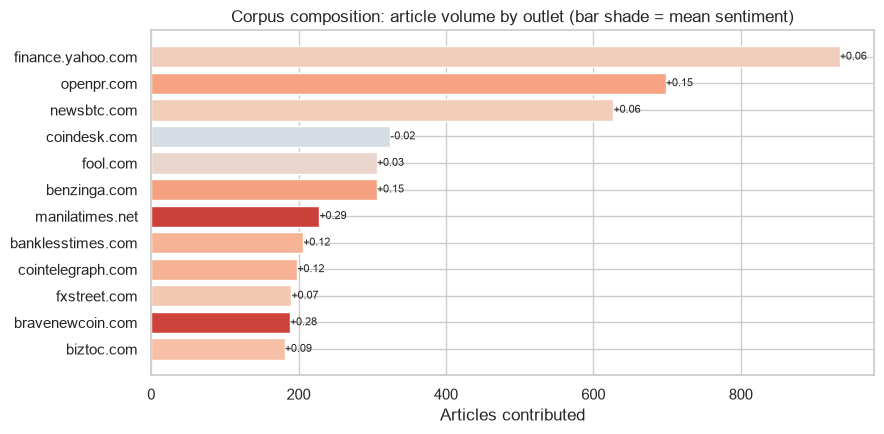

In [46]:
# Corpus composition: concentration and per-outlet tone.
news = FEATURES["news_scored"]
outlet = (
    news.groupby("source")
    .agg(articles=("sentiment", "size"), mean_sentiment=("sentiment", "mean"))
    .sort_values("articles", ascending=False)
)
outlet["share"] = outlet["articles"] / len(news)
outlet["cumulative_share"] = outlet["share"].cumsum()

# Herfindahl-Hirschman index over outlet shares: 0 = perfectly diffuse, 1 = single source.
hhi = float((outlet["share"] ** 2).sum())
top3 = float(outlet["share"].head(3).sum())
print(f"{len(outlet)} outlets across {len(news)} articles.")
print(f"Largest outlet: {outlet.index[0]} ({outlet['share'].iloc[0]:.1%} of the corpus).")
print(f"Top-3 concentration: {top3:.1%}   |   HHI: {hhi:.3f}")
print(f"Outlets contributing a single article: {int((outlet['articles'] == 1).sum())}")
display(outlet.head(10).round(4))

# Which outlets did the §2.1 de-duplication actually remove? Attributing the reprints
# turns "aggregators inflate the corpus" from an assumption into a measurement.
#
# The comparison must be WITHIN one corpus. An earlier revision of this cell differenced
# GDELT's kept counts against NewsAPI's raw counts, which is meaningless twice over: the
# two providers indexed different articles, and they name outlets differently - NewsAPI
# by display name ("Crypto Briefing"), GDELT by domain ("newsbtc.com") - so the reindex
# matched almost nothing, filled zeros, and reported NewsAPI's raw volume as though it
# were reprints GDELT had dropped. It ran without error and printed a plausible table,
# which is precisely why it needed catching.
raw_by_outlet = TYPED["xrp_gdelt_news"]["source"].value_counts()
kept_by_outlet = news["source"].value_counts().reindex(raw_by_outlet.index).fillna(0)
reprints_lost = (raw_by_outlet - kept_by_outlet).astype(int)
reprints_lost = reprints_lost[reprints_lost > 0].sort_values(ascending=False)
print("\nArticles removed as syndicated reprints, by outlet:")
print(reprints_lost.to_string())
print(f"  -> {reprints_lost.iloc[0]} of {int(reprints_lost.sum())} came from a single "
      f"outlet ({reprints_lost.index[0]}).")

fig, ax = plt.subplots(figsize=(9, 4.5))
top = outlet.head(12).iloc[::-1]
bars = ax.barh(top.index, top["articles"],
               color=plt.cm.coolwarm(0.5 + top["mean_sentiment"] * 1.5))
ax.set_xlabel("Articles contributed")
ax.set_title("Corpus composition: article volume by outlet (bar shade = mean sentiment)")
for bar, sentiment in zip(bars, top["mean_sentiment"]):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            f"{sentiment:+.2f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

### 2.1.3 Two providers, the same three weeks

The NewsAPI sample from the midterm build covers 2026-06-09 to 2026-06-29, which sits
inside the study window. Both providers therefore indexed the same 21 days of XRP news
independently, which makes corpus selection measurable rather than a caveat.

This matters for what the sentiment series can be said to represent. A daily mean computed
over whichever articles one provider happened to index is only a measure of *market
sentiment* to the extent that the provider's selection is not itself doing the work. Two
independent selections over identical dates is the cheapest available test of that, and it
is a test this project can run only because the older sample was kept rather than
discarded when the horizon changed.

Overlap window: 2026-06-04 -> 2026-06-28 (25 days)
  GDELT   :   317 articles from 68 outlets
  NewsAPI :   399 articles from 30 outlets
  ratio   : 0.8x more articles from GDELT

Outlets matched across providers: 6 (20% of NewsAPI's, 9% of GDELT's)

Daily mean sentiment, the two corpora on 21 shared days:
  Pearson r  = +0.250
  Spearman   = +0.347
  GDELT   mean +0.0387  sd 0.1899
  NewsAPI mean +0.1307  sd 0.1940


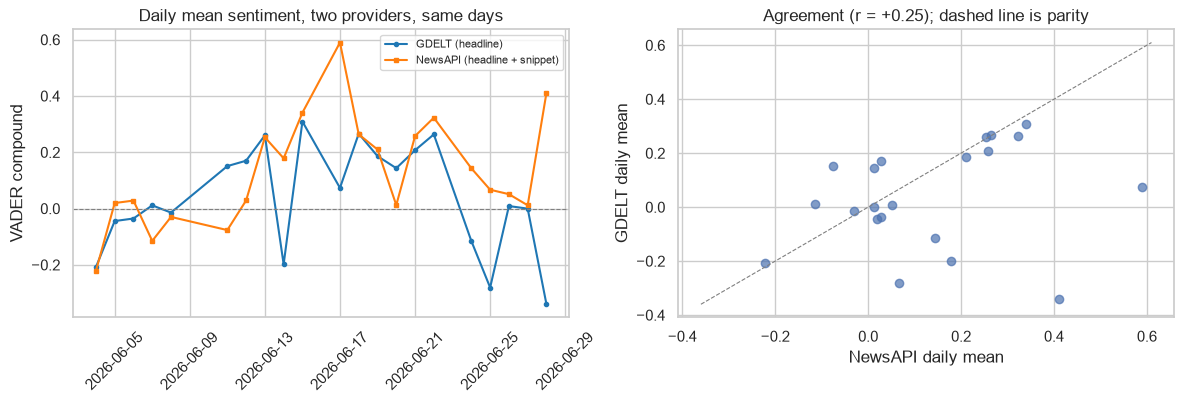

In [47]:
# Both corpora, restricted to the days they share.
gdelt_articles = FEATURES["news_scored"]
newsapi_articles = TYPED["xrp_news"].copy()
newsapi_articles["date"] = pd.to_datetime(newsapi_articles["date"]).dt.normalize()

overlap_start = newsapi_articles["date"].min()
overlap_end = newsapi_articles["date"].max()
g_win = gdelt_articles[(gdelt_articles["date"] >= overlap_start)
                       & (gdelt_articles["date"] <= overlap_end)]
n_win = newsapi_articles[(newsapi_articles["date"] >= overlap_start)
                         & (newsapi_articles["date"] <= overlap_end)]

print(f"Overlap window: {overlap_start.date()} -> {overlap_end.date()} "
      f"({(overlap_end - overlap_start).days + 1} days)")
print(f"  GDELT   : {len(g_win):5d} articles from {g_win['source'].nunique()} outlets")
print(f"  NewsAPI : {len(n_win):5d} articles from {n_win['source'].nunique()} outlets")
print(f"  ratio   : {len(g_win) / max(len(n_win), 1):.1f}x more articles from GDELT\n")

# Outlet overlap. The two providers name outlets differently - NewsAPI by display name,
# GDELT by domain - so neither set can be intersected directly. Reducing both to an
# alphanumeric key recovers the obvious matches ("Crypto Briefing" / "cryptobriefing.com")
# without pretending the remainder are comparable.
def outlet_key(value: str) -> str:
    """Collapse an outlet label to a comparable key across the two naming schemes."""
    stem = re.sub(r"\.(com|org|net|co|io|news)(\.[a-z]{2})?$", "", str(value).lower())
    return re.sub(r"[^a-z0-9]", "", stem)


g_keys = {outlet_key(s) for s in g_win["source"].unique()}
n_keys = {outlet_key(s) for s in n_win["source"].unique()}
shared = g_keys & n_keys
print(f"Outlets matched across providers: {len(shared)} "
      f"({len(shared) / len(n_keys):.0%} of NewsAPI's, "
      f"{len(shared) / len(g_keys):.0%} of GDELT's)")

# Daily agreement: do the two corpora imply the same sentiment on the same day?
g_daily = g_win.groupby("date")["sentiment"].mean().rename("gdelt_sentiment")
n_scored = n_win.assign(
    text=(n_win["headline"].fillna("") + ". " + n_win["snippet"].fillna("")).map(clean_text)
)
n_scored["sentiment"] = n_scored["text"].map(lambda t: sia.polarity_scores(t)["compound"])
n_daily = n_scored.groupby("date")["sentiment"].mean().rename("newsapi_sentiment")

agree = pd.concat([g_daily, n_daily], axis=1).dropna()
r_pearson = agree["gdelt_sentiment"].corr(agree["newsapi_sentiment"])
r_spearman = agree["gdelt_sentiment"].corr(agree["newsapi_sentiment"], method="spearman")
print(f"\nDaily mean sentiment, the two corpora on {len(agree)} shared days:")
print(f"  Pearson r  = {r_pearson:+.3f}")
print(f"  Spearman   = {r_spearman:+.3f}")
print(f"  GDELT   mean {agree['gdelt_sentiment'].mean():+.4f}  "
      f"sd {agree['gdelt_sentiment'].std():.4f}")
print(f"  NewsAPI mean {agree['newsapi_sentiment'].mean():+.4f}  "
      f"sd {agree['newsapi_sentiment'].std():.4f}")

log_row("corpus_overlap", "provider agreement on daily sentiment",
        0 if r_pearson > 0.5 else 1,
        "reported - see §2.1.2",
        f"Pearson r={r_pearson:+.3f} over {len(agree)} shared days; "
        f"GDELT indexed {len(g_win)} articles against NewsAPI's {len(n_win)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(agree.index, agree["gdelt_sentiment"], marker="o", ms=3,
             label="GDELT (headline)", color="tab:blue")
axes[0].plot(agree.index, agree["newsapi_sentiment"], marker="s", ms=3,
             label="NewsAPI (headline + snippet)", color="tab:orange")
axes[0].axhline(0, color="grey", lw=0.8, ls="--")
axes[0].set_title("Daily mean sentiment, two providers, same days")
axes[0].set_ylabel("VADER compound")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(fontsize=8)

axes[1].scatter(agree["newsapi_sentiment"], agree["gdelt_sentiment"], alpha=0.7)
lims = [min(agree.min()) - 0.02, max(agree.max()) + 0.02]
axes[1].plot(lims, lims, ls="--", color="grey", lw=0.8)
axes[1].set_xlabel("NewsAPI daily mean")
axes[1].set_ylabel("GDELT daily mean")
axes[1].set_title(f"Agreement (r = {r_pearson:+.2f}); dashed line is parity")
plt.tight_layout()
plt.show()

## 2.2 Market features — daily returns & rolling volatility

The hourly price series is collapsed to one observation per calendar day: the **end-of-day close** (last price) for returns, and the **mean** of the day's volume readings (CoinGecko reports volume as a 24h-rolling figure, so averaging the intraday snapshots gives a representative daily level).

**The missing-value strategy is executable, not prose.** `MISSING_POLICY` declares, per column, which strategy applies and *why*; `apply_missing_policy` carries it out and returns an audit of what it actually did. Stating the policy as data rather than as scattered `fillna` calls means the justification cannot drift away from the behaviour, and the audit below shows exactly how many values each rule touched.

For price and volume the rule is **forward-fill onto a gap-free daily calendar**: a missing day means no fresh quote was recorded, so the last-known price is the best available estimate, and `ffill` preserves continuity *without fabricating volatility* — a filled day simply has a return of 0. Because that is precisely the kind of imputation that could manufacture an artificially calm stretch, §2.0's `chk_constant_run` is re-run against the filled series in §2.3 to confirm it did not.

From the daily close we derive **simple daily returns** and, via the reusable `add_rolling_volatility` helper, the **7- and 14-day rolling standard deviation of returns** — our volatility metric.

In [48]:
# --- Declared missing-value policy -------------------------------------------------
# Strategy and justification per column, kept together so neither can drift from the
# other. "keep" is a deliberate decision, not an omission: a NaN that represents a
# genuinely unobserved quantity must not be imputed into a fabricated observation.
MISSING_POLICY = {
    "price": ("ffill", "No fresh close recorded; last-known price is the best estimate "
                       "and yields a 0% return rather than inventing a move."),
    "volume": ("ffill", "As price: carry the last observed daily USD volume forward."),
    "volume_xrp": ("ffill", "As volume, in native units."),
    "trade_count": ("ffill", "As volume: a venue outage is not zero trading."),
    "article_count": ("zero", "A true count - a day with no XRP news genuinely saw zero "
                              "articles, so 0 is the observed value, not a guess."),
    "sentiment_mean": ("keep", "No news is NOT neutral news. Imputing 0.0 would assert an "
                               "observation that was never made; the H1/H2 tests instead "
                               "restrict to days where news exists."),
    "sentiment_mean_broad": ("keep", "As sentiment_mean: no news is not neutral news."),
    "article_count_broad": ("zero", "A true count, as article_count."),
    "gdelt_tone": ("keep", "GDELT's own daily tone; four days in July 2026 are missing "
                           "from its index entirely, and an absent day is unobserved, "
                           "not neutral."),
    "gdelt_article_count": ("zero", "A true count over GDELT's complete index."),
    "commits": ("zero", "A true count - a day with no commits genuinely saw none. "
                        "Unlike a price, absence here is an observation."),
    "commits_core": ("zero", "As commits."),
    "contributors": ("zero", "As commits."),
    "commits_7d": ("keep", "Rolling-window warm-up, as the volatility measures."),
    "commits_core_7d": ("keep", "As commits_7d."),
    "contributors_7d": ("keep", "As commits_7d."),
    "feature_share_7d": ("keep", "Undefined on a week with no commits at all; a ratio "
                                 "with no denominator is not zero."),
    "days_since_release": ("keep", "Undefined before the first release in the window."),
    "mean_trade_size": ("keep", "Undefined on a day with no trades; a fabricated value "
                                "would defeat the anomaly detector that reads it."),
    "amihud_illiquidity": ("keep", "Derived from return and volume; inherits their gaps."),
    "fear_greed": ("keep", "Market-wide index; a gap is genuinely unobserved."),
    "tx_count": ("keep", "Coin Metrics reports on a one-day lag; the trailing gap is real."),
    "active_addresses": ("keep", "As tx_count - and it is a divisor, so a fabricated "
                                 "value would silently corrupt transfers_per_address."),
    "transfer_count": ("keep", "As tx_count."),
    "transfers_per_address": ("keep", "Derived; inherits the gaps of its inputs rather "
                                      "than masking them with a filled value."),
    "addresses_with_balance": ("keep", "As tx_count."),
    "fees_native": ("keep", "As tx_count."),
    "ledger_count": ("keep", "As tx_count."),
    "mvrv": ("keep", "A valuation ratio, not a count; an unobserved day stays unobserved."),
    "market_cap_usd": ("keep", "As mvrv."),
    "reported_volume_usd": ("keep", "Exchange self-reported; a gap means no report, which "
                                    "is not the same as no trading."),
    "reference_price_usd": ("keep", "An independent cross-check, not a substitute; filling "
                                    "it would defeat the comparison it exists for."),
    "bitstamp_close": ("keep", "Second-venue cross-check; a gap must stay visible so the "
                               "cross-venue comparison cannot silently compare a value "
                               "against itself carried forward."),
    "bitstamp_volume": ("keep", "As bitstamp_close."),
    "parkinson_bitstamp": ("keep", "As bitstamp_close."),
    "daily_return": ("keep", "Undefined on the first day - there is no prior close to "
                             "difference against."),
    "volatility_7d": ("keep", "Rolling-window warm-up: the first 7 days have too few "
                              "observations for a standard deviation to exist."),
    "volatility_14d": ("keep", "Rolling-window warm-up, as volatility_7d."),
    "parkinson_daily": ("keep", "Defined wherever a high and low exist; the backbone now "
                                "covers the full window, so gaps would signal a venue "
                                "outage rather than a coverage boundary."),
    "parkinson_7d": ("keep", "As parkinson_daily, plus its own rolling warm-up."),
    "parkinson_14d": ("keep", "As parkinson_7d."),
}


def apply_missing_policy(df: pd.DataFrame, policy: dict[str, str],
                         label: str = "") -> pd.DataFrame:
    """
    Apply each column's declared strategy and return (frame, audit).

    The audit records how many values each rule actually touched, so the notebook can
    show that the stated policy is the policy that ran.
    """
    df = df.copy()
    audit = []
    for column, (strategy, why) in policy.items():
        if column not in df.columns:
            continue
        before = int(df[column].isna().sum())
        if strategy == "ffill":
            df[column] = df[column].ffill()
        elif strategy == "zero":
            df[column] = df[column].fillna(0)
        after = int(df[column].isna().sum())
        audit.append({"column": column, "strategy": strategy,
                      "missing_before": before, "missing_after": after,
                      "justification": why})
        if before:
            log_row(label, f"missing values · {column}", before,
                    f"policy: {strategy}", why)
    return df, pd.DataFrame(audit)


def add_rolling_volatility(df: pd.DataFrame, return_col: str = "daily_return",
                           windows: tuple[int, ...] = (7, 14)) -> pd.DataFrame:
    """Append rolling std-of-returns volatility columns, one per window (in days)."""
    for w in windows:
        df[f"volatility_{w}d"] = df[return_col].rolling(window=w).std()
    return df




# --- The price backbone, as a registry ------------------------------------------------
# Criterion (e) asks for an architecture that lets external datasets be swapped in
# seamlessly. That is only a real claim if something is actually swapped, so the two
# venues acquired in Phase 1 are declared here behind one interface and the study is
# re-run on the alternate one in §3.7.
#
# The registry deliberately covers the price backbone ONLY. On-chain, news and the
# sentiment index have no interchangeable counterpart in this design, and a registry
# that pretended otherwise would be describing modularity rather than providing it.


def adapt_kraken(df: pd.DataFrame) -> pd.DataFrame:
    """Kraken's native columns -> the canonical analysis columns."""
    return df.rename(columns={
        "close": "price", "volume_usd": "volume", "volume": "volume_xrp",
    })[["date", "price", "volume", "volume_xrp", "trade_count", "vwap",
        "open", "high", "low"]].copy()


def adapt_bitstamp(df: pd.DataFrame) -> pd.DataFrame:
    """
    Bitstamp's native columns -> the same canonical shape.

    Bitstamp publishes neither a trade count nor a VWAP, so `volume` (USD) is
    reconstructed as native volume x close rather than x VWAP. That is an approximation,
    not a like-for-like substitution: it prices the whole day's flow at the closing
    price instead of the traded average. It is recorded here so the §3.7 comparison is
    read as "a different venue AND a slightly different volume definition", which is the
    honest description of what changes.
    """
    out = df.rename(columns={"close": "price", "volume": "volume_xrp"}).copy()
    out["volume"] = out["volume_xrp"] * out["price"]
    out["vwap"] = pd.NA          # not published by this venue
    out["trade_count"] = pd.NA   # not published by this venue
    return out[["date", "price", "volume", "volume_xrp", "trade_count", "vwap",
                "open", "high", "low"]]


BACKBONE_SOURCES = {
    "kraken": {
        "venue": "Kraken",
        "stream": "xrp_kraken",
        "fetch": fetch_kraken_ohlc,
        "adapt": adapt_kraken,
        "publishes": ("open", "high", "low", "close", "volume", "vwap", "trade_count"),
    },
    "bitstamp": {
        "venue": "Bitstamp",
        "stream": "xrp_bitstamp",
        "fetch": fetch_bitstamp_ohlc,
        "adapt": adapt_bitstamp,
        "publishes": ("open", "high", "low", "close", "volume"),
    },
}


def build_daily_market(source_key: str, *, bind_as: str = "daily_market",
                       show_audit: bool = True) -> pd.DataFrame:
    """
    Build the daily market frame from any registered venue.

    Pure with respect to the stages: reads one TYPED frame, returns a bound FEATURES
    frame, and touches nothing else. That is what makes the venue a parameter rather
    than a rewrite.
    """
    spec = BACKBONE_SOURCES[source_key]
    frame = spec["adapt"](TYPED[spec["stream"]].sort_values("date"))

    # Enforce a gap-free daily calendar, then apply the declared policy to any gaps it
    # exposes. Both venues cover this window completely, so the reindex is a guard
    # rather than a repair - but a guard only present when needed is not a guard.
    full_idx = pd.date_range(frame["date"].min(), frame["date"].max(), freq="D")
    frame = frame.set_index("date").reindex(full_idx)
    frame.index.name = "date"
    frame = frame.reset_index()
    frame, audit = apply_missing_policy(frame, MISSING_POLICY, label=bind_as)
    if show_audit:
        display(audit)

    # Feature engineering (vectorised): simple daily return + rolling volatility.
    frame["daily_return"] = frame["price"].pct_change()
    frame = add_rolling_volatility(frame, windows=CONFIG["volatility_windows"])

    return FEATURES.bind(
        bind_as, frame,
        parent=f"TYPED.{spec['stream']}",
        transform=f"{spec['venue']} -> canonical columns -> gap-free calendar -> "
                  f"missing policy -> returns + rolling volatility",
    ), audit


print("Registered price backbones:")
for key, spec in BACKBONE_SOURCES.items():
    marker = "  <- active" if key == CONFIG["backbone"] else ""
    print(f"  {key:<9} {spec['venue']:<9} publishes {len(spec['publishes'])} fields{marker}")
print()

daily_market, market_fill_audit = build_daily_market(CONFIG["backbone"])
daily_market.tail()

Registered price backbones:
  kraken    Kraken    publishes 7 fields  <- active
  bitstamp  Bitstamp  publishes 5 fields



,column,strategy,missing_before,missing_after,justification
0,price,ffill,0,0,No fresh close recorded; last-known price is t...
1,volume,ffill,0,0,As price: carry the last observed daily USD vo...
2,volume_xrp,ffill,0,0,"As volume, in native units."
3,trade_count,ffill,0,0,As volume: a venue outage is not zero trading.


,date,price,volume,volume_xrp,trade_count,vwap,open,high,low,daily_return,volatility_7d,volatility_14d
360,2026-08-27,1.45357,5.416584e+07,3.749280e+07,30450.0,1.44470,1.42298,1.47414,1.39336,0.021612,0.060893,0.060249
361,2026-08-28,1.38376,8.857420e+07,6.283908e+07,42898.0,1.40954,1.45387,1.47200,1.36310,-0.048027,0.031121,0.062899
362,2026-08-29,1.39661,1.794575e+07,1.290949e+07,15777.0,1.39012,1.38361,1.40347,1.37704,0.009286,0.031419,0.062755
363,2026-08-30,1.35751,2.748117e+07,1.979327e+07,25213.0,1.38841,1.39660,1.43300,1.33500,-0.027996,0.024657,0.063749
364,2026-08-31,1.37943,3.264780e+07,2.388892e+07,26754.0,1.36665,1.35767,1.39579,1.33914,0.016147,0.026841,0.063661


### 2.2.1 An independent volatility measure from the OHLC stream

Every volatility figure so far derives from one series of **closing** prices, so a single
construction choice underlies the entire dependent variable. The OHLC stream acquired
earlier makes an independent estimate available, and this section builds it.

The **Parkinson (1980) estimator** infers volatility from the day's *high–low range* rather
than from close-to-close change:

$$\sigma_P = \sqrt{\frac{1}{4N\ln 2}\sum_{i=1}^{N}\left(\ln\frac{H_i}{L_i}\right)^2}$$

It is a genuinely different measurement, not a re-scaling: a day that opens and closes at the
same price after swinging violently in between registers ~zero close-to-close volatility but
a large Parkinson value. The estimator is also roughly five times more efficient than the
close-to-close estimator for the same sample size, which matters given how short this window
is. Its assumptions are worth stating plainly: it presumes continuous observation within the
day and no drift, and it will *under*-estimate true volatility because a discretely sampled
high and low can only ever be narrower than the continuous one.

**Coverage.** CoinGecko serves 4-hourly candles only for look-backs of ≤30 days (beyond that
the candles are 4-day, far too coarse to bound a single day), so this measure spans ~31 days
against the primary measure's 91. That is enough to cover the **entire 21-day news window**,
so H1 can be re-tested against it in full; the H3 robustness check is necessarily on a
reduced sample, and is reported as such.

In [49]:
# --- Parkinson (1980) high-low volatility -------------------------------------------
LOG2 = np.log(2.0)


def parkinson_volatility(high: pd.Series, low: pd.Series,
                         window: int | None = None) -> pd.Series:
    """
    Parkinson's high-low volatility estimator.

    With `window=None` returns the single-day estimate sqrt(ln(H/L)^2 / (4 ln 2)), which
    reduces to ln(H/L) / (2 sqrt(ln 2)) and is comparable with a daily |return|. With an
    integer `window` returns the rolling N-day form, comparable with the rolling standard
    deviation of returns computed in §2.2.
    """
    log_range_sq = np.log(high / low) ** 2
    if window is None:
        return np.sqrt(log_range_sq / (4 * LOG2))
    return np.sqrt(log_range_sq.rolling(window=window).mean() / (4 * LOG2))


# Kraken reports a true daily high and low, so no intra-day aggregation is needed.
# `price` is restored to `close` here: this frame is an OHLC record, and the candle-bounds
# check in the validation library is written against the standard field names.
daily_ohlc = daily_market[["date", "open", "high", "low", "price"]].rename(
    columns={"price": "close"}
).copy()
daily_ohlc["parkinson_daily"] = parkinson_volatility(
    daily_ohlc["high"], daily_ohlc["low"]
)
for w in CONFIG["volatility_windows"]:
    daily_ohlc[f"parkinson_{w}d"] = parkinson_volatility(
        daily_ohlc["high"], daily_ohlc["low"], window=w
    )

daily_ohlc = FEATURES.bind(
    "daily_ohlc", daily_ohlc,
    parent="FEATURES.daily_market",
    transform="daily high/low -> Parkinson estimator (daily + rolling)",
)

# A third volatility measure from the SECOND venue. This matters for what §3.1.1 is
# entitled to claim: the return-based and Parkinson estimators above are independent in
# *construction* but now share a data source, so agreement between them says nothing
# about whether Kraken's feed is representative. Computing the same estimator on
# Bitstamp's independent high/low separates the two questions.
bitstamp = TYPED["xrp_bitstamp"].sort_values("date")
daily_bitstamp = bitstamp.rename(columns={
    "close": "bitstamp_close", "volume": "bitstamp_volume",
})[["date", "bitstamp_close", "bitstamp_volume", "high", "low"]].copy()
daily_bitstamp["parkinson_bitstamp"] = parkinson_volatility(
    daily_bitstamp["high"], daily_bitstamp["low"]
)
daily_bitstamp = FEATURES.bind(
    "daily_bitstamp", daily_bitstamp.drop(columns=["high", "low"]),
    parent="TYPED.xrp_bitstamp",
    transform="rename to analysis columns -> Parkinson estimator on the second venue",
)

# The §2.0 check library applies to derived frames as readily as to acquired ones.
display(validate_stream("daily_ohlc", daily_ohlc, [
    ("one row per calendar day", "de-duplicate", chk_unique(["date"])),
    ("gap-free daily calendar", "report", chk_daily_calendar("date")),
    ("daily high bounds daily low", "reject day", chk_ohlc_bounds()),
    ("no null high/low", "drop day", chk_no_nulls(["high", "low"])),
    ("estimator non-negative", "investigate", chk_greater_than(["parkinson_daily"], -1e-12)),
]))

print(f"Parkinson volatility over {len(daily_ohlc)} days "
      f"({daily_ohlc['date'].min().date()} -> {daily_ohlc['date'].max().date()}), "
      f"against {len(daily_market)} days for the return-based measure.")
daily_ohlc.tail()

,stream,check,n_failed,status,action,detail
0,daily_ohlc,one row per calendar day,0,PASS,-,
1,daily_ohlc,gap-free daily calendar,0,PASS,-,
2,daily_ohlc,daily high bounds daily low,0,PASS,-,
3,daily_ohlc,no null high/low,0,PASS,-,
4,daily_ohlc,estimator non-negative,0,PASS,-,


Parkinson volatility over 365 days (2025-09-01 -> 2026-08-31), against 365 days for the return-based measure.


,date,open,high,low,close,parkinson_daily,parkinson_7d,parkinson_14d
360,2026-08-27,1.42298,1.47414,1.39336,1.45357,0.033846,0.075576,0.067063
361,2026-08-28,1.45387,1.47200,1.36310,1.38376,0.046159,0.068640,0.068037
362,2026-08-29,1.38361,1.40347,1.37704,1.39661,0.011418,0.041677,0.068087
363,2026-08-30,1.39660,1.43300,1.33500,1.35751,0.042543,0.041045,0.068997
364,2026-08-31,1.35767,1.39579,1.33914,1.37943,0.024883,0.040420,0.069243


## 2.3 On-chain, sentiment-index and news-aggregate features

On-chain metrics are already daily; we add one derived feature — **transfers per active address**, a measure of network-usage depth. The daily frames are then merged on `date` using the **market calendar as the backbone** (left joins), so every trading day is represented: market features, on-chain activity, XRP-news sentiment, and the market-wide Fear & Greed index.

**Missing-value strategy for the merge:** days with no XRP news retain `NaN` `sentiment_mean` — *kept, not dropped* — so the volatility series stays continuous; the news-based hypotheses in Phase 3 restrict to the ~21-day subset where news exists, while the **Fear & Greed** column gives a complementary sentiment signal across the *full* ~90-day window. The leading `NaN`s in the rolling-volatility columns are the expected warm-up of the 7- and 14-day windows; the single trailing on-chain `NaN` reflects Coin Metrics' one-day reporting lag. A final `info()` / null audit confirms dtypes and surfaces exactly these expected gaps.

### 2.3.1 Developer activity, and a calendar that is not the ledger's

Commits arrive one row at a time; the analysis needs a daily series. The aggregation is
trivial. What is not trivial is that **the two sides of this fusion run on different
calendars**, and joining them naively would measure the calendar rather than the
phenomenon.

Software is written during a working week. The ledger is not:

| series | weekday mean | weekend mean | ratio |
| --- | --- | --- | --- |
| GitHub commits | 6.4 | 0.2 | **28.8×** |
| ledger `tx_count` | 2,293,889.0 | 2,128,773.6 | 1.1× |
| `active_addresses` | 54,363.5 | 57,890.8 | 0.9× |

A daily correlation between these two would be dominated by a variable neither hypothesis
mentions: whether it is Saturday. The effect is an order of magnitude larger than any
relationship plausibly under test, so it is not a nuisance to note — it would *be* the
result.

Two things follow. Every developer feature that enters the merged frame is a **7-day
rolling** quantity, which removes the weekly cycle exactly (the weekday/weekend ratio of
`commits_7d` is 1.00). And H4 in §3.8 is tested on **weekly** aggregates rather than daily
ones, so the unit of analysis matches the rhythm of the thing being measured.

This is the same class of problem as the venue-specific volume in §2.3 — a systematic
artefact of how the data is produced rather than of what it describes — and it is handled
the same way: identified, measured, and removed by construction rather than adjusted for
after the fact.

In [50]:
commits = TYPED["xrp_github_commits"].copy()
commits["date"] = commits["date"].dt.normalize()
releases = TYPED["xrp_github_releases"].copy()
releases["date"] = releases["date"].dt.normalize()

# Per-day aggregates, on the full calendar so quiet days are zeros rather than absences.
calendar = pd.date_range(ANALYSIS_START, ANALYSIS_END, freq="D")
core_repo = "XRPLF/rippled"

daily_github = pd.DataFrame({"date": calendar})
counts = commits.groupby("date").agg(
    commits=("sha", "size"), contributors=("author", "nunique")
).reset_index()
daily_github = daily_github.merge(counts, on="date", how="left")
daily_github = daily_github.merge(
    commits[commits["repo"] == core_repo].groupby("date").size()
    .rename("commits_core").reset_index(), on="date", how="left")
for kind in ("feature", "fix"):
    daily_github = daily_github.merge(
        commits[commits["commit_type"] == kind].groupby("date").size()
        .rename(f"commits_{kind}").reset_index(), on="date", how="left")
for column in ("commits", "contributors", "commits_core", "commits_feature", "commits_fix"):
    daily_github[column] = daily_github[column].fillna(0)

# The weekday cycle, measured rather than assumed - this is what justifies every rolling
# window below, so it is computed here for BOTH sides of the fusion. Showing that commits
# have a weekly rhythm proves nothing on its own; the claim is that the ledger does not
# share it, and that requires measuring the ledger too.
is_weekend = daily_github["date"].dt.dayofweek >= 5
wk = daily_github.loc[~is_weekend, "commits"].mean()
we = daily_github.loc[is_weekend, "commits"].mean()

_cycle = [{"series": "GitHub commits", "weekday": wk, "weekend": we}]
# TYPED rather than master: this cell runs before the merge, and the ledger series is
# already available at its own stage.
_ledger = TYPED["xrp_onchain"].set_index("date")
for _col in ("tx_count", "active_addresses"):
    _wend = _ledger.index.dayofweek >= 5
    _cycle.append({"series": f"ledger {_col}",
                   "weekday": _ledger.loc[~_wend, _col].mean(),
                   "weekend": _ledger.loc[_wend, _col].mean()})
weekday_cycle = pd.DataFrame(_cycle)
weekday_cycle["ratio"] = weekday_cycle["weekday"] / weekday_cycle["weekend"]
# Formatted as values rather than through a Styler, so the table survives export to
# plain text and PDF as well as it renders in the browser.
weekday_cycle["weekday"] = weekday_cycle["weekday"].map("{:,.1f}".format)
weekday_cycle["weekend"] = weekday_cycle["weekend"].map("{:,.1f}".format)
weekday_cycle["ratio"] = weekday_cycle["ratio"].map("{:.1f}x".format)
display(weekday_cycle)
print("Human work follows a working week; a distributed ledger does not. Correlating the")
print("two daily would measure the calendar rather than either phenomenon.\n")
log_row("daily_github", "weekday cycle in commit activity", int(round(wk / max(we, 1e-9))),
        "removed by construction: every merged feature is a 7-day rolling quantity",
        f"weekday mean {wk:.1f} vs weekend {we:.1f} commits ({wk / max(we, 1e-9):.1f}x); "
        f"the ledger's own tx_count shows 1.1x, so the cycle is the developers', not XRP's")

# Rolling features. Seven days is not a smoothing choice here - it is exactly one cycle
# of the artefact being removed.
daily_github["commits_7d"] = daily_github["commits"].rolling(7).sum()
daily_github["commits_core_7d"] = daily_github["commits_core"].rolling(7).sum()
daily_github["contributors_7d"] = daily_github["contributors"].rolling(7).mean()
feature_7d = daily_github["commits_feature"].rolling(7).sum()
fix_7d = daily_github["commits_fix"].rolling(7).sum()
# Share of *labelled* work that adds capability, rather than of all commits: unlabelled
# commits carry no claim about their own nature and should not dilute the ratio.
labelled_7d = feature_7d + fix_7d
daily_github["feature_share_7d"] = (feature_7d / labelled_7d).where(labelled_7d > 0)

# Release cadence: days since the most recent published release, of any kind.
release_days = releases["date"].sort_values().to_numpy()
positions = np.searchsorted(release_days, daily_github["date"].to_numpy(), side="right") - 1
# Subtracting two numpy datetime64 values yields a timedelta64, which carries no .days
# attribute; divide by a one-day unit instead of reaching for one.
one_day = np.timedelta64(1, "D")
daily_github["days_since_release"] = [
    (d - release_days[p]) / one_day if p >= 0 else np.nan
    for d, p in zip(daily_github["date"].to_numpy(), positions)
]

residual = (daily_github.loc[~is_weekend, "commits_7d"].mean()
            / daily_github.loc[is_weekend, "commits_7d"].mean())
print(f"Weekday cycle: {wk / max(we, 1e-9):.1f}x in raw daily commits, "
      f"{residual:.2f}x after the 7-day rolling sum.\n")

daily_github = FEATURES.bind(
    "daily_github", daily_github,
    parent="TYPED.xrp_github_commits",
    transform="commits -> daily counts on the full calendar -> 7-day rolling features "
              "(weekday cycle removed) + release cadence",
)

print(f"{len(commits)} commits from {commits['author'].nunique()} contributors "
      f"across {commits['repo'].nunique()} repositories.")
print(f"Days with any commit: {int((daily_github['commits'] > 0).sum())} of {len(calendar)}")
display(commits["commit_type"].value_counts().rename("commits").to_frame().T)
print(f"\nWork composition: {int((commits['commit_type'] == 'feature').sum())} feature "
      f"commits against {int((commits['commit_type'] == 'maintenance').sum())} maintenance "
      f"- a mature codebase being kept running rather than one being built out.")
daily_github.tail()

,series,weekday,weekend,ratio
0,GitHub commits,6.4,0.2,28.8x
1,ledger tx_count,"2,293,889.0","2,128,773.6",1.1x
2,ledger active_addresses,"54,363.5","57,890.8",0.9x


Human work follows a working week; a distributed ledger does not. Correlating the
two daily would measure the calendar rather than either phenomenon.

Weekday cycle: 28.8x in raw daily commits, 1.00x after the 7-day rolling sum.

1684 commits from 72 contributors across 4 repositories.
Days with any commit: 262 of 365


commit_type,maintenance,fix,unlabelled,feature,docs,other
commits,1010,307,220,74,37,36



Work composition: 74 feature commits against 1010 maintenance - a mature codebase being kept running rather than one being built out.


,date,commits,contributors,commits_core,commits_feature,commits_fix,commits_7d,commits_core_7d,contributors_7d,feature_share_7d,days_since_release
360,2026-08-27,9.0,4.0,5.0,2.0,1.0,52.0,33.0,3.714286,0.185185,0.0
361,2026-08-28,2.0,1.0,0.0,0.0,2.0,52.0,31.0,3.571429,0.185185,1.0
362,2026-08-29,0.0,0.0,0.0,0.0,0.0,52.0,31.0,3.571429,0.185185,2.0
363,2026-08-30,0.0,0.0,0.0,0.0,0.0,52.0,31.0,3.571429,0.185185,3.0
364,2026-08-31,1.0,1.0,1.0,0.0,0.0,39.0,25.0,2.714286,0.235294,4.0


## 2.4 Filtering systemic noise

Criterion (c) asks for transformations that filter out known systemic noise — wash trading,
exchange migrations — to isolate the true signal. Two strands of the literature say why
this cannot be skipped for a volume hypothesis.

Amihud (2002) established that raw volume conflates trading *interest* with market *depth*:
the same volume means different things at different liquidity. Cong, Li, Tang and Yang
(2023) show the problem is far sharper in crypto, where a large share of volume reported by
unregulated exchanges is fabricated.

Four detectors are built below. **None of them drops a row.** Every one writes a flag,
those flags go into the validation report alongside every other check, and §3.4.1 re-runs
the surviving hypothesis with the flagged days excluded to see whether it depended on them.
Dropping data because it looks odd is how a result gets manufactured; flagging it and
showing the result survives is how one gets defended.

In [51]:
def robust_z(series: pd.Series, window: int = 30, center: bool = False) -> pd.Series:
    """
    Deviation from a rolling median, scaled by rolling MAD.

    Median and MAD rather than mean and standard deviation because the anomalies being
    looked for are exactly the observations that would inflate a standard deviation and
    thereby hide themselves. 1.4826 rescales MAD to be comparable with a normal sigma.

    `center` defaults to False, and that default is the result of §2.0.1 rather than a
    preference. This function was written with `center=True`, which reads half a window
    into the future - and because the median and the MAD are two *nested* centred windows,
    the reach compounds to 28 days rather than the 15 the window size suggests. Nothing
    here needed it. The cell below reports what changing it did.
    """
    med = series.rolling(window, center=center, min_periods=window // 3).median()
    mad = (series - med).abs().rolling(window, center=center,
                                       min_periods=window // 3).median()
    return (series - med) / (1.4826 * mad.replace(0, np.nan))


noise = daily_market[["date", "volume", "volume_xrp", "trade_count"]].copy()
noise = noise.merge(daily_bitstamp[["date", "bitstamp_volume"]], on="date", how="left")
# TYPED rather than FEATURES: the on-chain frame is bound later, in the assembly cell,
# and the detector only needs two raw counts.
noise = noise.merge(
    TYPED["xrp_onchain"][["date", "active_addresses", "transfer_count"]],
    on="date", how="left")

# --- 1. Cross-venue divergence ------------------------------------------------------
# Two venues trading the same asset should keep a roughly stable volume ratio. A day when
# that ratio jumps is a fact about one exchange, not about XRP.
venue_ratio = noise["volume_xrp"] / noise["bitstamp_volume"]
noise["flag_venue_divergence"] = robust_z(venue_ratio).abs() > 3

# --- 2. Trade-size compression ------------------------------------------------------
# The wash-trading signature in Cong et al. (2023): volume rises while the average trade
# shrinks, because the same value is being churned through many small self-matched trades.
noise["mean_trade_size"] = noise["volume_xrp"] / noise["trade_count"]
size_z = robust_z(np.log(noise["mean_trade_size"]))
volume_z = robust_z(np.log(noise["volume_xrp"]))
noise["flag_trade_size"] = (volume_z > 1) & (size_z < -2)

# --- 3. Exchange migration ----------------------------------------------------------
# A wallet consolidation moves many transfers through very few addresses: transfer count
# jumps while the participant count does not. TxTfrValAdjUSD would be the direct measure
# but is paid-tier (see §"On-chain ledger activity"), so this is the free proxy.
addr_move = noise["active_addresses"].pct_change().abs()
tfr_move = noise["transfer_count"].pct_change().abs()
noise["flag_migration"] = (tfr_move > 0.5) & (addr_move < 0.1)

# --- 4. Amihud illiquidity ----------------------------------------------------------
# Price impact per unit of volume. Not a flag but a control: it distinguishes a large move
# on thin volume from the same move on heavy volume, which raw volume cannot.
noise["amihud_illiquidity"] = (
    daily_market["daily_return"].abs() / daily_market["volume"]
).replace([np.inf, -np.inf], np.nan)

flag_columns = [c for c in noise.columns if c.startswith("flag_")]
for column in flag_columns:
    noise[column] = noise[column].fillna(False)
noise["flag_any"] = noise[flag_columns].any(axis=1)

# Reported through the §2.0 check library, not alongside it: same contract, same report.
NOISE_CHECKS = [
    ("cross-venue volume divergence", "FLAG - one exchange's activity, not the market's",
     chk_flagged("flag_venue_divergence",
                 "Kraken/Bitstamp volume ratio >3 MAD from its rolling median")),
    ("trade-size compression", "FLAG - volume inflated by self-matched trades",
     chk_flagged("flag_trade_size",
                 "volume elevated while mean trade size collapsed")),
    ("exchange-migration signature", "FLAG - wallet consolidation, not economic use",
     chk_flagged("flag_migration",
                 "transfers +50% while active addresses moved <10%")),
    ("any systemic-noise flag", "FLAGGED, never dropped - re-tested in §3.4.1",
     chk_flagged("flag_any", "at least one detector fired")),
]
display(validate_stream("daily_noise_flags", noise, NOISE_CHECKS))
print(f"Any detector: {int(noise['flag_any'].sum())} of {len(noise)} days "
      f"({noise['flag_any'].mean():.1%})\n")

print(f"Mean trade size: median {noise['mean_trade_size'].median():,.0f} XRP "
      f"(range {noise['mean_trade_size'].min():,.0f}-{noise['mean_trade_size'].max():,.0f}).")
if noise["flag_trade_size"].sum() == 0:
    print("No day shows the wash-trading signature - elevated volume with compressed trade")
    print("size. That is a negative result worth stating: the detector is implemented and")
    print("finds nothing, which is different from not having looked.")

noise = FEATURES.bind(
    "daily_noise_flags", noise,
    parent="FEATURES.daily_market",
    transform="robust-z detectors for venue divergence, trade-size compression and "
              "wallet migration, plus Amihud illiquidity",
)

,stream,check,n_failed,status,action,detail
0,daily_noise_flags,cross-venue volume divergence,17,WARN,"FLAG - one exchange's activity, not the market's",17 of 365 days: Kraken/Bitstamp volume ratio >...
1,daily_noise_flags,trade-size compression,0,PASS,-,
2,daily_noise_flags,exchange-migration signature,3,WARN,"FLAG - wallet consolidation, not economic use",3 of 365 days: transfers +50% while active add...
3,daily_noise_flags,any systemic-noise flag,20,WARN,"FLAGGED, never dropped - re-tested in §3.4.1",20 of 365 days: at least one detector fired


Any detector: 20 of 365 days (5.5%)

Mean trade size: median 746 XRP (range 274-1,731).
No day shows the wash-trading signature - elevated volume with compressed trade
size. That is a negative result worth stating: the detector is implemented and
finds nothing, which is different from not having looked.


#### What the leakage detector found here

The four detectors above are retrospective annotations: they mark days whose behaviour is
odd relative to their neighbourhood, and §3.4.1 uses them to ask whether H3 depends on those
days. Nothing about that purpose requires a *causal* window, so `robust_z` was originally
written with `center=True` and nobody had reason to look at it again.

Running §2.0.1's detector over it returns **28**. Not 15, which is what a centred 30-day
window would suggest, but 28 — because the median and the MAD are two nested centred
windows and the reach compounds. A flag on 1 March was reading data from late March.

Whether that *mattered* is a separate question from whether it was intended, and the cell
below answers both. It is the answer to the first that decides what to do: the flags feed
only contemporaneous comparisons, so no forward-looking result was ever contaminated. That
makes this a defect of hygiene rather than of conclusions — which is precisely the kind
that survives review, because nothing downstream looks wrong.

It is fixed anyway, since the causal version costs nothing and the comparison below shows
what it changes.

In [52]:
# The same detectors under both window conventions, so the switch is evidenced.
_probe = noise.set_index("date")
_variants = {}
for _label, _centred in [("centred (as originally written)", True),
                         ("trailing (causal - now used)", False)]:
    _ratio = _probe["volume_xrp"] / _probe["bitstamp_volume"]
    _venue = (robust_z(_ratio, center=_centred).abs() > 3).fillna(False)
    _size_z = robust_z(np.log(_probe["mean_trade_size"]), center=_centred)
    _vol_z = robust_z(np.log(_probe["volume_xrp"]), center=_centred)
    _trade = ((_vol_z > 1) & (_size_z < -2)).fillna(False)
    _variants[_label] = {"venue divergence": _venue, "trade-size compression": _trade}

comparison = pd.DataFrame([
    {"window": label,
     "lookahead (days)": lookahead_horizon(
         lambda f, c=(label.startswith("centred")): robust_z(f["volume_xrp"], center=c),
         _probe.reset_index()),
     **{name: int(flags.sum()) for name, flags in detectors.items()}}
    for label, detectors in _variants.items()
])
display(comparison)

_centred_any = _variants["centred (as originally written)"]["venue divergence"] | \
    _variants["centred (as originally written)"]["trade-size compression"]
_trailing_any = _variants["trailing (causal - now used)"]["venue divergence"] | \
    _variants["trailing (causal - now used)"]["trade-size compression"]
print(f"Day-level agreement between the two flag sets: "
      f"{(_centred_any == _trailing_any).mean():.1%}")
print(f"  flagged only by the centred window : {int((_centred_any & ~_trailing_any).sum())}")
print(f"  flagged only by the causal window  : {int((_trailing_any & ~_centred_any).sum())}\n")

# The assertion that now guards it. Declared horizon 0: these are inputs, not targets.
for _name, _column in [("venue divergence", "volume_xrp"),
                       ("trade-size compression", "mean_trade_size")]:
    audit_lookahead(lambda f, col=_column: robust_z(f[col]), _probe.reset_index(),
                    f"robust_z on {_column}", declared=0, stream="daily_noise_flags")

print("Both detectors now measure a zero-day horizon, and `audit_lookahead` would stop the")
print("notebook if a later edit reintroduced the centring. That is the difference between")
print("fixing a defect and preventing it: the comment explaining why `center=False` is")
print("correct can be deleted by anyone, but the assertion fails loudly when it is wrong.")

,window,lookahead (days),venue divergence,trade-size compression
0,centred (as originally written),28,10,0
1,trailing (causal - now used),0,17,0


Day-level agreement between the two flag sets: 97.0%
  flagged only by the centred window : 2
  flagged only by the causal window  : 9



Both detectors now measure a zero-day horizon, and `audit_lookahead` would stop the
notebook if a later edit reintroduced the centring. That is the difference between
fixing a defect and preventing it: the comment explaining why `center=False` is
correct can be deleted by anyone, but the assertion fails loudly when it is wrong.


### 2.4.1 A test from the literature that does not apply here

Cong et al. (2023) use **Benford's law** — the observation that in many natural datasets
the leading digit is 1 about 30% of the time and 9 about 5% — to detect fabricated trade
sizes. Applying it to this data is the obvious next step, and it produces a dramatic
result: Kraken's daily volume deviates from Benford at *p* < 0.0001.

Reporting that as evidence of manipulation would be wrong, and the cell below shows why by
running a control. Benford's law holds when the **mantissa** of the data is roughly uniform
on a log scale, which requires the values to span several orders of magnitude. Daily volume
for a single asset spans fewer than two, and is roughly lognormal around a central value.

So the control generates synthetic lognormal data matched to Kraken's own distribution —
data that is clean by construction, because this notebook created it — and tests that. If
it also deviates, then deviation is a property of the distribution's shape, not evidence
about anyone's conduct.

This is the distinction between borrowing a technique and borrowing its *preconditions*.
Cong et al. apply Benford to trade-level records, where sizes genuinely range from dust to
whales across many orders of magnitude. At daily aggregation that precondition is gone.

In [53]:
def benford_test(values: ArrayLike) -> tuple[float, float, np.ndarray]:
    """Chi-square goodness-of-fit of leading digits against Benford's distribution."""
    x = pd.Series(values).dropna()
    x = x[x > 0]
    leading = pd.to_numeric(
        x.astype(str).str.replace(".", "", regex=False).str.lstrip("0").str[0],
        errors="coerce").dropna().astype(int)
    observed = leading.value_counts().reindex(range(1, 10), fill_value=0).to_numpy()
    expected = np.log10(1 + 1 / np.arange(1, 10)) * observed.sum()
    chi2 = float(((observed - expected) ** 2 / expected).sum())
    return chi2, float(1 - stats.chi2.cdf(chi2, 8)), observed / observed.sum()


rows = []
for label, series in [("Kraken daily volume", noise["volume_xrp"]),
                      ("Bitstamp daily volume", noise["bitstamp_volume"]),
                      ("exchange-reported volume", TYPED["xrp_onchain"]["reported_volume_usd"]),
                      ("Kraken trade count", noise["trade_count"])]:
    chi2, p, _ = benford_test(series)
    decades = float(np.log10(pd.Series(series).dropna().max())
                    - np.log10(pd.Series(series).dropna().min()))
    rows.append({"series": label, "orders of magnitude spanned": round(decades, 2),
                 "chi2": round(chi2, 1), "p": round(p, 4),
                 "reads as": "deviates" if p < 0.05 else "fits Benford"})

# The control: clean by construction, because it is generated here.
generator = np.random.default_rng(CONFIG["random_seed"])
log_volume = np.log10(noise["volume_xrp"].dropna())
synthetic_lognormal = 10 ** generator.normal(log_volume.mean(), log_volume.std(), 5000)
synthetic_loguniform = 10 ** generator.uniform(1, 7, 5000)
for label, series in [("CONTROL: lognormal matched to Kraken", synthetic_lognormal),
                      ("CONTROL: log-uniform over 6 decades", synthetic_loguniform)]:
    chi2, p, _ = benford_test(series)
    decades = float(np.log10(series.max()) - np.log10(series.min()))
    rows.append({"series": label, "orders of magnitude spanned": round(decades, 2),
                 "chi2": round(chi2, 1), "p": round(p, 4),
                 "reads as": "deviates" if p < 0.05 else "fits Benford"})

display(pd.DataFrame(rows))

_, p_real, _ = benford_test(noise["volume_xrp"])
_, p_control, _ = benford_test(synthetic_lognormal)
print(f"Kraken daily volume            : Benford p = {p_real:.4f}")
print(f"Synthetic clean data, same shape: Benford p = {p_control:.4f}")
print("\nThe control deviates too, and nothing manipulated it - this notebook drew it from")
print("a lognormal. The deviation therefore measures how tightly the data is distributed,")
print("not whether anyone fabricated it. Benford's law is not applied to volume in this")
print("study, and the reason is a failed precondition rather than an inconvenient answer.")

log_row("daily_market", "Benford's law tested for applicability and rejected", 1,
        "NOT used - precondition fails at daily aggregation",
        f"real data p={p_real:.4f}, but synthetic CLEAN data of the same shape "
        f"p={p_control:.4f}; the test cannot separate shape from conduct here")

,series,orders of magnitude spanned,chi2,p,reads as
0,Kraken daily volume,1.88,66.1,0.0000,deviates
1,Bitstamp daily volume,1.58,47.5,0.0000,deviates
2,exchange-reported volume,1.96,7.7,0.4654,fits Benford
3,Kraken trade count,1.21,159.2,0.0000,deviates
4,CONTROL: lognormal matched to Kraken,1.91,565.6,0.0000,deviates
5,CONTROL: log-uniform over 6 decades,6.00,6.7,0.5683,fits Benford


Kraken daily volume            : Benford p = 0.0000
Synthetic clean data, same shape: Benford p = 0.0000

The control deviates too, and nothing manipulated it - this notebook drew it from
a lognormal. The deviation therefore measures how tightly the data is distributed,
not whether anyone fabricated it. Benford's law is not applied to volume in this
study, and the reason is a failed precondition rather than an inconvenient answer.


{'stream': 'daily_market',
 'check': "Benford's law tested for applicability and rejected",
 'n_failed': 1,
 'status': 'WARN',
 'action': 'NOT used - precondition fails at daily aggregation',
 'detail': 'real data p=0.0000, but synthetic CLEAN data of the same shape p=0.0000; the test cannot separate shape from conduct here'}

In [54]:
daily_onchain = TYPED["xrp_onchain"]
daily_onchain["date"] = pd.to_datetime(daily_onchain["date"]).dt.normalize()
# Derived feature: transfer intensity per active address (network-usage depth). The
# divisor is guaranteed non-zero by the active_addresses > 0 check in §2.0.
daily_onchain["transfers_per_address"] = (
    daily_onchain["transfer_count"] / daily_onchain["active_addresses"]
)

# Fear & Greed is already daily; keep the numeric index for merging.
daily_fg = TYPED["xrp_fear_greed"]
daily_fg["date"] = pd.to_datetime(daily_fg["date"]).dt.normalize()

# GDELT's two uncapped aggregate series, joined into one daily frame. These are computed
# over GDELT's COMPLETE index, unlike the headline sample, so they are the honest source
# for daily attention and for the independent tone measure.
daily_gdelt = TYPED["xrp_gdelt_tone"].merge(
    TYPED["xrp_gdelt_volume"], on="date", how="outer"
).sort_values("date").reset_index(drop=True)

daily_onchain = FEATURES.bind(
    "daily_onchain", daily_onchain,
    parent="TYPED.xrp_onchain",
    transform="normalise date -> transfers_per_address",
)
daily_fg = FEATURES.bind(
    "daily_fg", daily_fg,
    parent="TYPED.xrp_fear_greed",
    transform="normalise date",
)
daily_gdelt = FEATURES.bind(
    "daily_gdelt", daily_gdelt,
    parent="TYPED.xrp_gdelt_tone",
    transform="outer-join GDELT tone and article volume onto one daily frame",
)

### 2.4.2 Reported volume against observable volume

Amihud (2002) established that raw volume conflates trading interest with market depth.
Cong, Li, Tang and Yang (2023) show the problem is far sharper in crypto, where a
substantial share of volume reported by unregulated exchanges is fabricated to inflate
apparent liquidity.

H2 is a volume hypothesis, so this is not a general caveat — it decides which number H2 is
allowed to use. Two quantities are available here: what exchanges collectively *report*
(Coin Metrics' `reported_volume_usd`, aggregated across venues) and what can actually be
*observed* at two named venues. The ratio between them is computed below.

It cannot be read as a wash-trading estimate: Kraken and Bitstamp are two venues among
many, so most of the *level* of the gap is simply coverage. Nor do the two series diverge
wildly — in logs they correlate at 0.91, so reported volume does broadly track observable
volume.

What disqualifies the reported figure for H2 is that the **ratio is not stable**: it runs
from roughly 21× to 321×, a fifteen-fold swing, with an interquartile range of 38× to 60×.
A dependent variable whose relationship to observable trading moves by that much is
measuring reporting behaviour as well as trading, and H2 cannot separate the two. Named-
venue volume is imperfect — it omits most of the market — but what it omits is at least
stable.

In [55]:
# Two providers, one price. Coin Metrics computes its reference price independently of
# any single venue, so agreement with the Kraken close is evidence about the backbone that
# no internal check could give - a self-consistent series can still be self-consistently
# wrong.
cross_source = daily_market[["date", "price"]].merge(
    daily_onchain[["date", "reference_price_usd"]], on="date", how="inner"
).dropna()
price_r = cross_source["price"].corr(cross_source["reference_price_usd"])
max_gap = (cross_source["price"] - cross_source["reference_price_usd"]).abs().max()
print(f"Cross-source price validation ({len(cross_source)} days):")
print(f"  corr(Kraken close, Coin Metrics reference) = {price_r:.6f}")
print(f"  largest absolute difference                = {max_gap:.4f} USD\n")
log_row("daily_market", "price agrees with an independent provider", 0,
        "no action - agreement confirms the backbone",
        f"r={price_r:.6f} against Coin Metrics reference price, max gap {max_gap:.4f} USD")

venue_usd = daily_market["volume"]                    # Kraken native volume x VWAP
reported = daily_onchain.set_index("date")["reported_volume_usd"].reindex(
    daily_market["date"]).to_numpy()
inflation = pd.Series(reported / venue_usd.to_numpy(), index=daily_market["date"]).dropna()

print("Exchange-reported volume as a multiple of volume observable at one named venue:")
print(f"  median {inflation.median():6.1f}x")
print(f"  range  {inflation.min():6.1f}x  to {inflation.max():6.1f}x")
print(f"  IQR    {inflation.quantile(.25):6.1f}x  to {inflation.quantile(.75):6.1f}x")

# Do the two move together? If reported volume were simply broader coverage of the same
# activity, the ratio would be roughly constant and the series highly correlated.
corr = np.corrcoef(np.log(reported[~np.isnan(reported)]),
                   np.log(venue_usd.to_numpy()[~np.isnan(reported)]))[0, 1]
print(f"\n  corr(log reported, log observed) = {corr:.3f}")
print(f"  ratio varies by a factor of {inflation.max() / inflation.min():.0f} across the window")

log_row("daily_market", "reported vs observable volume divergence",
        int((inflation > inflation.median() * 3).sum()),
        "H2 uses named-venue volume, not aggregate reported volume",
        f"reported/observed median {inflation.median():.1f}x, range "
        f"{inflation.min():.1f}-{inflation.max():.1f}x, log-log r={corr:.3f}")

print("\nH2 therefore uses named-venue volume throughout. The reported figure is retained")
print("only as an input to the index in §3.8, where its divergence from observable volume")
print("is the quantity of interest rather than a nuisance.")

Cross-source price validation (365 days):
  corr(Kraken close, Coin Metrics reference) = 0.999986
  largest absolute difference                = 0.0213 USD

Exchange-reported volume as a multiple of volume observable at one named venue:
  median   47.6x
  range    20.9x  to  320.9x
  IQR      37.8x  to   59.6x

  corr(log reported, log observed) = 0.914
  ratio varies by a factor of 15 across the window

H2 therefore uses named-venue volume throughout. The reported figure is retained
only as an input to the index in §3.8, where its divergence from observable volume
is the quantity of interest rather than a nuisance.


## 2.5 Assembly of the master daily dataset

Every stream is now at daily grain with its features computed and its anomalies flagged.
The merge below is the last transition in Phase 2: a left join onto the market calendar,
followed by the same declared missing-value policy that governed each stream individually,
so a gap created by a join is treated exactly like a gap that arrived in the data.

In [56]:
# Merge on the daily market calendar (backbone).
master = (
    daily_market
    .merge(daily_onchain, on="date", how="left")
    .merge(daily_sentiment, on="date", how="left")
    .merge(daily_sentiment_broad, on="date", how="left")
    .merge(daily_gdelt, on="date", how="left")
    .merge(daily_github[["date", "commits", "commits_core", "contributors",
                         "commits_7d", "commits_core_7d", "contributors_7d",
                         "feature_share_7d", "days_since_release"]],
           on="date", how="left")
    .merge(daily_fg[["date", "fear_greed"]], on="date", how="left")
    .merge(daily_bitstamp, on="date", how="left")
    .merge(noise[["date", "mean_trade_size", "amihud_illiquidity", "flag_venue_divergence",
                  "flag_trade_size", "flag_migration", "flag_any"]],
           on="date", how="left")
    .merge(
        daily_ohlc[["date", "parkinson_daily"]
                   + [f"parkinson_{w}d" for w in CONFIG["volatility_windows"]]],
        on="date", how="left",
    )
)

# The merge exposes new gaps (days outside a stream's coverage); the same declared
# policy governs them, so the treatment of a NaN does not depend on where it arose.
master, merge_fill_audit = apply_missing_policy(master, MISSING_POLICY, label="master")
master["article_count"] = master["article_count"].astype(int)
master["article_count_broad"] = master["article_count_broad"].astype(int)

master = MERGED.bind(
    "master", master,
    parent="FEATURES.daily_market",
    transform="left-join on-chain, sentiment (primary + broad), GDELT aggregates, F&G, "
              "second venue and Parkinson onto the daily backbone -> missing policy",
)
display(merge_fill_audit)

print("Master shape:", master.shape)
print("Span:", master["date"].min().date(), "->", master["date"].max().date())
print("Days with news sentiment:", int(master["sentiment_mean"].notna().sum()))
print("Days with GDELT tone:", int(master["gdelt_tone"].notna().sum()))
print("Days with Fear & Greed:", int(master["fear_greed"].notna().sum()))
master.tail()

,column,strategy,missing_before,missing_after,justification
0,price,ffill,0,0,No fresh close recorded; last-known price is t...
1,volume,ffill,0,0,As price: carry the last observed daily USD vo...
2,volume_xrp,ffill,0,0,"As volume, in native units."
3,trade_count,ffill,0,0,As volume: a venue outage is not zero trading.
4,article_count,zero,7,0,A true count - a day with no XRP news genuinel...
5,sentiment_mean,keep,7,7,No news is NOT neutral news. Imputing 0.0 woul...
6,sentiment_mean_broad,keep,5,5,As sentiment_mean: no news is not neutral news.
7,article_count_broad,zero,5,0,"A true count, as article_count."
8,gdelt_tone,keep,4,4,GDELT's own daily tone; four days in July 2026...
9,gdelt_article_count,zero,4,0,A true count over GDELT's complete index.


Master shape: (365, 50)
Span: 2025-09-01 -> 2026-08-31
Days with news sentiment: 358
Days with GDELT tone: 361
Days with Fear & Greed: 365


,date,price,volume,volume_xrp,trade_count,vwap,open,high,low,daily_return,...,parkinson_bitstamp,mean_trade_size,amihud_illiquidity,flag_venue_divergence,flag_trade_size,flag_migration,flag_any,parkinson_daily,parkinson_7d,parkinson_14d
360,2026-08-27,1.45357,5.416584e+07,3.749280e+07,30450.0,1.44470,1.42298,1.47414,1.39336,0.021612,...,0.035774,1231.290494,3.989970e-10,False,False,False,False,0.033846,0.075576,0.067063
361,2026-08-28,1.38376,8.857420e+07,6.283908e+07,42898.0,1.40954,1.45387,1.47200,1.36310,-0.048027,...,0.046901,1464.848686,5.422187e-10,False,False,False,False,0.046159,0.068640,0.068037
362,2026-08-29,1.39661,1.794575e+07,1.290949e+07,15777.0,1.39012,1.38361,1.40347,1.37704,0.009286,...,0.011375,818.247697,5.174648e-10,False,False,False,False,0.011418,0.041677,0.068087
363,2026-08-30,1.35751,2.748117e+07,1.979327e+07,25213.0,1.38841,1.39660,1.43300,1.33500,-0.027996,...,0.042286,785.042210,1.018747e-09,False,False,False,False,0.042543,0.041045,0.068997
364,2026-08-31,1.37943,3.264780e+07,2.388892e+07,26754.0,1.36665,1.35767,1.39579,1.33914,0.016147,...,0.024965,892.910319,4.945881e-10,False,False,False,False,0.024883,0.040420,0.069243


In [57]:
# --- Post-conditions ----------------------------------------------------------------
# Assertions, not prints: if the assembled frame violates any of these the notebook stops
# here rather than letting Phase 3 compute statistics on a malformed table. Each mirrors
# an assumption the analysis makes further down.
warmup = min(CONFIG["volatility_windows"])

assert master["date"].is_unique, "duplicate dates would double-weight a day"
assert master["date"].is_monotonic_increasing, "rolling windows assume ascending order"
assert (master["date"].diff().dropna() == pd.Timedelta(days=1)).all(), \
    "the daily calendar has a gap; rolling windows would span unequal intervals"
assert master["price"].notna().all(), "price is the backbone series and must be complete"
assert master["article_count"].notna().all(), "article_count is a count, never unknown"
assert (master["article_count"] >= 0).all(), "negative article count"
assert master["volatility_7d"].isna().sum() == warmup, \
    "volatility NaNs should be exactly the rolling-window warm-up, nothing more"
assert master.loc[master["sentiment_mean"].notna(), "article_count"].gt(0).all(), \
    "a day cannot have a sentiment score without articles"
assert (master["parkinson_daily"].dropna() >= 0).all(), \
    "a volatility estimate cannot be negative"
assert master.loc[master["parkinson_daily"].notna(), "date"].isin(
    daily_ohlc["date"]).all(), "Parkinson values must come only from OHLC-covered days"

# The forward-fill in §2.2 is audited, not trusted: confirm it did not manufacture a
# flat stretch of price that would depress every volatility figure in Phase 3.
longest_flat, flat_detail = chk_constant_run("price", 5)(master)
log_row("master", "forward-fill did not manufacture a flat price run", longest_flat,
        "investigate imputation", flat_detail)

print(f"All post-conditions hold. ({flat_detail}.)\n")

# Integrity audit: confirm dtypes and surface the (expected) remaining nulls.
master.info()
display(master.isna().sum().rename("nulls").to_frame().T)

# --- Consolidated data-quality report ------------------------------------------------
validation_report = pd.DataFrame(VALIDATION_LOG)
report_path = DATA_DIR / "validation_report.csv"
# Remembered so §4.6 can split the final tally by phase without hard-coding a number
# that would drift the moment another check is added.
PHASE2_CHECKS = len(validation_report)
validation_report.to_csv(report_path, index=False)
n_warn = int((validation_report["status"] == "WARN").sum())
print(f"\nData-quality report so far: {len(validation_report)} checks across "
      f"{validation_report['stream'].nunique()} stages, {n_warn} raised a warning. "
      f"Written to {report_path}.")
print("Phase 3 registers further checks - the noise-flag robustness test, the "
      "cross-correlation\ngrid and the index validations - and the file is rewritten "
      "complete at the end of §4.")
display(validation_report[validation_report["status"] == "WARN"].reset_index(drop=True))

All post-conditions hold. (longest identical run = 1 rows.)

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    365 non-null    datetime64[us]
 1   price                   365 non-null    float64       
 2   volume                  365 non-null    float64       
 3   volume_xrp              365 non-null    float64       
 4   trade_count             365 non-null    float64       
 5   vwap                    365 non-null    float64       
 6   open                    365 non-null    float64       
 7   high                    365 non-null    float64       
 8   low                     365 non-null    float64       
 9   daily_return            364 non-null    float64       
 10  volatility_7d           358 non-null    float64       
 11  volatility_14d          351 non-null    float64       
 12  

,date,price,volume,volume_xrp,trade_count,vwap,open,high,low,daily_return,...,parkinson_bitstamp,mean_trade_size,amihud_illiquidity,flag_venue_divergence,flag_trade_size,flag_migration,flag_any,parkinson_daily,parkinson_7d,parkinson_14d
nulls,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,6,13



Data-quality report so far: 167 checks across 18 stages, 38 raised a warning. Written to data_sample/validation_report.csv.
Phase 3 registers further checks - the noise-flag robustness test, the cross-correlation
grid and the index validations - and the file is rewritten complete at the end of §4.


,stream,check,n_failed,status,action,detail
0,xrp_onchain,no implausible jumps in active addresses,3,WARN,flag - see the note in 2.0,3 consecutive moves > 100% (max 291.09%)
1,xrp_gdelt_news,headline/date/source never null,154,WARN,drop article,headline: 154 null
2,xrp_gdelt_news,every day covered,5,WARN,KEEP as NaN - no news is not neutral news,"missing days: 2025-12-06, 2026-07-01, 2026-07-..."
3,xrp_gdelt_coverage,schema · window_end → datetime64,2,WARN,unparseable values coerced to NaN,2 of 92 values
4,xrp_gdelt_coverage,no nulls,2,WARN,investigate,window_end: 2 null
5,xrp_gdelt_tone,gap-free daily calendar,4,WARN,report - GDELT indexing gaps are real,"missing days: 2026-07-01, 2026-07-02, 2026-07-..."
6,xrp_gdelt_volume,gap-free daily calendar,4,WARN,report - GDELT indexing gaps are real,"missing days: 2026-07-01, 2026-07-02, 2026-07-..."
7,xrp_news,snippet present,41,WARN,KEEP - scored on headline alone (see 2.1),snippet: 41 null
8,xrp_news,every day covered,4,WARN,KEEP as NaN - frozen 21-day overlap corpus,"missing days: 2026-06-09, 2026-06-10, 2026-06-..."
9,xrp_gdelt_news,articles empty after cleaning,154,WARN,dropped - nothing to score,


## 2.6 The pipeline's own audit trail

Every `bind` above appended a row to `LINEAGE`, so the notebook renders the lineage it
actually executed rather than a diagram drawn by hand beside it and liable to drift from
it. `rows_delta` is the row-count change against the named parent: `+0` everywhere typing
runs (the `TYPED` contract, also asserted in §2.0), negative exactly where cleaning drops
records, and marked *grain change* where a row count is not comparable because one row
stopped meaning the same thing — 7,131 scored articles becoming 358 calendar days is an
aggregation, not the loss of 6,773 records.

The table below covers the pipeline as built through Phase 2. Phase 3 appends exactly two
more transitions, both derivations that would otherwise have been in-place edits of a
shared frame: `MERGED.master_forward` in §3.2, the one place future information enters,
and `FEATURES.news_regulatory` in §3.3.

In [58]:
lineage = pd.DataFrame(LINEAGE)
with pd.option_context("display.max_colwidth", None, "display.width", 200):
    display(lineage)

print(f"{len(lineage)} transitions across {lineage['stage'].nunique()} stages.")
for stage_name in STAGE_CONTRACTS:
    frames = lineage.loc[lineage["stage"] == stage_name, "frame"].tolist()
    print(f"  {stage_name:<9} {len(frames)} frame(s): {', '.join(frames)}")

,stage,frame,grain,rows,cols,parent,rows_delta,seconds,conditions,transform
0,RAW,xrp_kraken,calendar day,365,9,(external source),,0.048,0,GET -> JSON -> DataFrame (daily OHLCV + trade count)
1,RAW,xrp_bitstamp,calendar day,365,6,(external source),,0.009,0,"GET -> JSON -> DataFrame (daily OHLCV, second venue)"
2,RAW,xrp_onchain,calendar day,365,11,(external source),,0.007,0,GET -> JSON -> DataFrame (daily ledger activity)
3,RAW,xrp_fear_greed,calendar day,365,3,(external source),,0.006,0,GET -> JSON -> DataFrame (daily market-wide index)
4,RAW,xrp_gdelt_news,article,8048,7,(external source),,0.031,0,GET x N windows -> JSON -> DataFrame (one row per article)
5,RAW,xrp_gdelt_coverage,acquisition window,92,4,(external source),,0.007,0,acquisition bookkeeping: articles retrieved and cap status per window
6,RAW,xrp_gdelt_tone,calendar day,361,2,(external source),,0.006,0,"GET -> JSON -> DataFrame (daily average tone, complete index)"
7,RAW,xrp_gdelt_volume,calendar day,361,2,(external source),,0.005,0,"GET -> JSON -> DataFrame (daily article count, complete index)"
8,RAW,xrp_gdelt_volume_broad,calendar day,361,2,(external source),,0.005,0,"GET -> JSON -> DataFrame (daily article count, broad query)"
9,RAW,xrp_github_commits,commit,1684,7,(external source),,0.271,0,"GET x N pages -> JSON -> DataFrame (one row per commit, typed by subject)"


38 transitions across 5 stages.
  RAW       12 frame(s): xrp_kraken, xrp_bitstamp, xrp_onchain, xrp_fear_greed, xrp_gdelt_news, xrp_gdelt_coverage, xrp_gdelt_tone, xrp_gdelt_volume, xrp_gdelt_volume_broad, xrp_github_commits, xrp_github_releases, xrp_news
  TYPED     12 frame(s): xrp_kraken, xrp_bitstamp, xrp_onchain, xrp_fear_greed, xrp_gdelt_news, xrp_gdelt_coverage, xrp_gdelt_tone, xrp_gdelt_volume, xrp_gdelt_volume_broad, xrp_github_commits, xrp_github_releases, xrp_news
  CLEAN     1 frame(s): xrp_gdelt_news
  FEATURES  12 frame(s): news_scored, daily_sentiment, daily_sentiment_base, daily_sentiment_broad, daily_market, daily_ohlc, daily_bitstamp, daily_github, daily_noise_flags, daily_onchain, daily_fg, daily_gdelt
  MERGED    1 frame(s): master


### The guarantees, demonstrated failing

An invariant that is only asserted in prose is a comment, and an assertion never observed
to fire is an untested one — the same argument that put the deliberate leaks in §3.2. All
three stage guarantees are exercised below against inputs built to violate them, and every
one must raise for the notebook to proceed.

The third is the newest and the one worth watching: a frame that fails a post-condition must
not merely be reported, it must never become **reachable**. If a broken table could be bound
and read, the error would surface wherever some later cell happened to trip over it rather
than at the stage that produced it.

In [59]:
# (1) A stage is write-once: rebinding a name it already holds must raise.
try:
    MERGED.bind("master", MERGED["master"])
except ImmutablePipelineError as exc:
    print(f"Rebinding MERGED['master'] was refused, as required:\n  {exc}")
else:
    raise AssertionError("a stage accepted a duplicate bind - the guarantee does not hold")

# (2) A handle taken from a stage is a copy: mutating it must not reach the record.
handle = MERGED["master"]
handle["injected_column"] = 1
handle.loc[0, "price"] = -999.0

assert "injected_column" not in MERGED["master"].columns, \
    "a column added to a handle reached the stored frame"
assert MERGED["master"].loc[0, "price"] > 0, \
    "a value written through a handle reached the stored frame"
print("Mutating a handle taken from MERGED left the stored frame untouched.")

# (3) The same protection covers the evidentiary record at the top of the pipeline.
raw_handle = RAW["xrp_kraken"]
raw_handle["close"] = 0.0
assert (RAW["xrp_kraken"]["close"] > 0).all(), "RAW was reachable through its handle"
print("RAW remains exactly as acquired: the evidentiary record is unreachable downstream.")

# (4) A post-condition must refuse a frame that violates it, and refuse it BEFORE storing.
#     `master` promises a contiguous daily calendar, so removing one day should be fatal.
POSTCONDITIONS["_probe_broken_calendar"] = [daily_calendar_is_contiguous]
broken = MERGED["master"].drop(index=100).reset_index(drop=True)
try:
    with expected_failure("post-condition: broken daily calendar"):
        MERGED.bind("_probe_broken_calendar", broken)
except PostconditionError as exc:
    print(f"\nA frame with a one-day gap was refused at the stage boundary:\n  {exc}")
else:
    raise AssertionError("a stage stored a frame that violates its own post-condition")
finally:
    del POSTCONDITIONS["_probe_broken_calendar"]

assert "_probe_broken_calendar" not in MERGED, \
    "the rejected frame was stored anyway - post-conditions must run before the write"
print("The rejected frame is not in MERGED: it never became reachable, so the failure is")
print("reported by the stage that produced it rather than by whichever cell used it next.")

Rebinding MERGED['master'] was refused, as required:
  MERGED['master'] is already bound (365 rows). A stage is write-once: derive a new name rather than overwriting.
Mutating a handle taken from MERGED left the stored frame untouched.
RAW remains exactly as acquired: the evidentiary record is unreachable downstream.

A frame with a one-day gap was refused at the stage boundary:
  MERGED['_probe_broken_calendar'] failed the post-condition daily_calendar_is_contiguous: 1 irregular intervals in the date column
The rejected frame is not in MERGED: it never became reachable, so the failure is
reported by the stage that produced it rather than by whichever cell used it next.


# 4–5. Methodology and Results

With a clean daily `master` frame in hand, we move from description to inference. Three
**pre-registered hypotheses** are evaluated, each with one declared *primary* test plus
robustness checks against different instruments.

| | Hypothesis | Independent variable | Primary dependent variable | Primary test |
| --- | --- | --- | --- | --- |
| **H1** | Extreme news sentiment is *followed by* a change in volatility | daily VADER sentiment | **forward** 3-day realised volatility (t+1…t+3) | Pearson + Spearman with block-bootstrap CI |
| **H2** | *Regulatory* news is associated with trading volume | regulatory **intensity** (share of the day's articles) | daily volume | Pearson + Spearman with block-bootstrap CI |
| **H3** | Elevated **on-chain activity** coincides with elevated volatility | active addresses | 7-day rolling volatility | Pearson + Spearman with block-bootstrap CI |

**The standard applied throughout.** Every test reports an **effect size with a confidence
interval**, not a p-value alone — an interval says which effects the data can and cannot
rule out, which is the question that matters when a sample is this small. Every null result
is accompanied by the **minimum detectable effect** at that sample size, so "no significant
effect" is never left to imply "no effect". Group comparisons carry **assumption checks**
(Shapiro–Wilk, Levene) reported *beside* the tests, so the choice between parametric and
rank-based is justified by the data rather than by which p-value looks better. Because the
daily series are strongly autocorrelated, correlations also carry an **effective sample
size** and a **moving-block bootstrap** interval, and the one regression is fitted with
**Newey–West** standard errors. Finally, §3.7 lists *every* test run and corrects the
confirmatory family with **Benjamini–Hochberg**.

Two sentiment lenses are kept distinct throughout: the **XRP-specific VADER** signal
(358 scored days, primary) and the **market-wide Fear & Greed** index (365 days, a broader
proxy that is confounded by construction, being built partly from volatility itself).

## 3.0 Methodology — statistical method

Before any hypothesis is tested, the toolkit those tests will use is defined in one place.
Routing every test through shared helpers keeps the statistical standard uniform — no test
can quietly report less than another — and lets the multiplicity correction in §3.5 operate
on the complete set rather than on whichever results were remembered.

Each helper exists to answer a specific weakness of a bare p-value:

| Helper | What it addresses |
| --- | --- |
| `fisher_ci` | A correlation's sampling distribution is skewed near ±1, so a symmetric interval is wrong. Reports what effect sizes the data can actually rule out. |
| `min_detectable_r` | Converts "not significant" into "an effect below this size was undetectable at this n" — the difference between absence of evidence and evidence of absence. |
| `effective_n` | Rolling-window series are strongly autocorrelated; consecutive observations are not independent, so the nominal n overstates the evidence. |
| `block_bootstrap_ci` | An interval that survives that dependence, by resampling contiguous blocks rather than individual days. Seeded, so it is reproducible. |
| `hedges_g` | A standardised effect size with a small-sample correction — how large the difference is, not merely whether it cleared a threshold. |
| `newey_west_slope`, `durbin_watson` | Regression standard errors valid under autocorrelated residuals, and the diagnostic that shows why they are needed. |
| `report_group_difference` | Runs the assumption checks (Shapiro–Wilk, Levene) *beside* both a parametric and a rank-based test, so the choice between them is made on the data rather than on the result. |
| `summarise_test_family` | Collects every test run and applies Benjamini–Hochberg to the pre-registered confirmatory family. |

`newey_west_slope` and `durbin_watson` are implemented from their formulae rather than
imported, keeping this notebook's dependency footprint to the libraries already required.

In [60]:
# --- Statistical toolkit -------------------------------------------------------------
# Every test in Phase 3 is routed through these helpers, so that each reports an effect
# size, a confidence interval and its assumption checks alongside its p-value, and so the
# whole family can be corrected for multiplicity in one place rather than test by test.

TEST_FAMILY: list[dict] = []                       # every test run, for the final pass
RNG = np.random.default_rng(CONFIG["random_seed"])  # seeded: the bootstrap is reproducible


# Bonett-Wright: the rank transform inflates the sampling variance of Fisher's z, so a
# Spearman interval built with the Pearson standard error is too narrow. 1.06 is the
# standard correction factor and is applied wherever rho is the reported estimate.
SPEARMAN_SE_FACTOR = 1.06


def fisher_ci(r: float, n: int, alpha: float = 0.05,
              se_factor: float = 1.0) -> tuple[float, float]:
    """
    Confidence interval for a correlation via Fisher's z transform.

    A correlation is bounded on [-1, 1] and its sampling distribution is skewed near the
    bounds, so a symmetric interval around r is wrong. Fisher's z = arctanh(r) is
    approximately normal with SE = 1/sqrt(n-3); the interval is built there and mapped
    back. Reporting this alongside r is what turns "r = -0.35, not significant" into a
    statement about which effect sizes the data can and cannot rule out.

    `se_factor` scales that standard error. It is 1 for Pearson and SPEARMAN_SE_FACTOR for
    Spearman, because the two statistics do not share a sampling distribution and reusing
    the Pearson interval for rho would report a precision the rank statistic does not have.
    """
    if n < 4 or not np.isfinite(r) or abs(r) >= 1:
        return (np.nan, np.nan)
    se = se_factor / np.sqrt(n - 3)
    crit = stats.norm.ppf(1 - alpha / 2)
    z = np.arctanh(r)
    lo, hi = np.tanh([z - crit * se, z + crit * se])
    return float(lo), float(hi)


def min_detectable_r(n: int, alpha: float = 0.05, power: float = 0.80) -> float:
    """
    The smallest |r| this sample size could reliably detect.

    Reported next to every null result: it converts "we found no significant effect" into
    the far more informative "an effect smaller than this could not have been detected".
    """
    if n < 4:
        return np.nan
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_power = stats.norm.ppf(power)
    return float(np.tanh((z_alpha + z_power) / np.sqrt(n - 3)))


def lag1_autocorr(series: ArrayLike) -> float:
    """First-order autocorrelation - how much each value is predicted by its predecessor."""
    s = pd.Series(series).dropna()
    return float(s.autocorr(lag=1)) if len(s) > 2 else np.nan


def effective_n(x: pd.Series, y: pd.Series) -> float:
    """
    Sample size adjusted for serial correlation (Bartlett / Quenouille).

    A standard p-value assumes independent observations. Rolling-window volatility
    violates that badly: consecutive values share most of their inputs. n_eff discounts
    the nominal n by how strongly *both* series persist, and is the honest denominator
    for judging how much evidence 83 overlapping days really carry.
    """
    paired = pd.concat([x, y], axis=1).dropna()
    if len(paired) < 4:
        return np.nan
    r1x = lag1_autocorr(paired.iloc[:, 0])
    r1y = lag1_autocorr(paired.iloc[:, 1])
    product = np.clip(r1x * r1y, -0.99, 0.99)
    return float(len(paired) * (1 - product) / (1 + product))


def block_bootstrap_ci(x: pd.Series, y: pd.Series, alpha: float = 0.05,
                       method: str = "spearman") -> tuple[float, float, int]:
    """
    Moving-block bootstrap interval for a correlation between serially dependent series.

    The ordinary bootstrap resamples individual observations and so destroys the time
    structure, producing intervals that are too narrow for autocorrelated data. Resampling
    contiguous *blocks* of length ~n^(1/3) preserves short-range dependence within each
    block, so the interval reflects the persistence actually present in the series.
    """
    paired = pd.concat([x, y], axis=1).dropna()
    n = len(paired)
    if n < 8:
        return (np.nan, np.nan, np.nan)
    a = paired.iloc[:, 0].to_numpy(float)
    b = paired.iloc[:, 1].to_numpy(float)
    block = max(2, int(round(n ** (1 / 3))))
    n_blocks = int(np.ceil(n / block))
    corr = stats.spearmanr if method == "spearman" else stats.pearsonr

    draws = np.empty(CONFIG["bootstrap_iterations"])
    for i in range(CONFIG["bootstrap_iterations"]):
        starts = RNG.integers(0, n - block + 1, size=n_blocks)
        idx = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
        aa, bb = a[idx], b[idx]
        draws[i] = np.nan if aa.std() == 0 or bb.std() == 0 else corr(aa, bb).statistic
    lo, hi = np.nanpercentile(draws, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(lo), float(hi), block


def hedges_g(a: ArrayLike, b: ArrayLike) -> tuple[float, float, float]:
    """
    Standardised mean difference with Hedges' small-sample correction, and its 95% CI.

    Cohen's d is biased upward in small samples - exactly the regime H2 operates in - so
    the J factor corrects it. The effect size answers the question a p-value cannot: not
    "is there a difference?" but "how large, and how precisely known?"
    """
    a = np.asarray(pd.Series(a).dropna(), float)
    b = np.asarray(pd.Series(b).dropna(), float)
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return (np.nan, np.nan, np.nan)
    pooled_sd = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    d = (a.mean() - b.mean()) / pooled_sd
    correction = 1 - 3 / (4 * (na + nb) - 9)        # Hedges' J
    g = correction * d
    se = np.sqrt((na + nb) / (na * nb) + g**2 / (2 * (na + nb - 2)))
    crit = stats.norm.ppf(0.975)
    return float(g), float(g - crit * se), float(g + crit * se)


def durbin_watson(residuals: ArrayLike) -> float:
    """DW ≈ 2(1 - r1): ~2 = no serial correlation, <2 = positive, >2 = negative."""
    r = np.asarray(pd.Series(residuals).dropna(), float)
    return float(np.sum(np.diff(r) ** 2) / np.sum(r**2))


def newey_west_slope(x: ArrayLike, y: ArrayLike,
                     maxlags: int | None = None) -> dict:
    """
    OLS slope with a Newey-West (HAC) standard error.

    Textbook OLS standard errors assume independent, homoscedastic errors; both fail here,
    because a rolling-window dependent variable has residuals that are autocorrelated *by
    construction*. The resulting p-value is far too small. The HAC estimator re-weights the
    residual autocovariances up to `maxlags` with Bartlett weights, giving a standard error
    that stays valid under that dependence. Implemented from the formula rather than taken
    from a library, to keep the dependency footprint of this notebook small.
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    n = len(x)
    if maxlags is None:
        maxlags = int(np.floor(4 * (n / 100) ** (2 / 9)))   # Newey-West rule of thumb
    design = np.column_stack([np.ones(n), x])
    beta, *_ = np.linalg.lstsq(design, y, rcond=None)
    resid = y - design @ beta
    bread = np.linalg.inv(design.T @ design)

    scores = design * resid[:, None]
    meat = scores.T @ scores                                  # lag 0
    for lag in range(1, maxlags + 1):
        weight = 1 - lag / (maxlags + 1)                      # Bartlett kernel
        gamma = scores[lag:].T @ scores[:-lag]
        meat = meat + weight * (gamma + gamma.T)

    cov = bread @ meat @ bread
    se = float(np.sqrt(cov[1, 1]))
    t_stat = float(beta[1]) / se
    p = float(2 * (1 - stats.norm.cdf(abs(t_stat))))
    return {"slope": float(beta[1]), "se": se, "t": t_stat, "p": p,
            "maxlags": maxlags, "dw": durbin_watson(resid),
            "r2": float(1 - resid.var() / y.var())}


def report_correlation(x: pd.Series, y: pd.Series, label: str = "",
                       family: str = "robustness",
                       bootstrap: bool = False,
                       primary: str = "pearson") -> dict:
    """
    Pearson + Spearman with a Fisher CI, and optionally a block-bootstrap interval.

    Both statistics are always computed and always reported. `primary` decides which one
    populates `estimate`, `p_raw` and the interval - that is, which one is the registered
    result of this test and enters the multiplicity correction. It exists because §1.3
    pre-registers Pearson for H1-H3 and Spearman for H4, and a helper that silently
    registers Pearson for all four would report a statistic the study did not declare
    while the declared one sat unused in a neighbouring column.
    """
    if primary not in {"pearson", "spearman"}:
        raise ValueError(f"primary must be 'pearson' or 'spearman', got {primary!r}")
    paired = pd.concat([x, y], axis=1).dropna()
    n = len(paired)
    pr = stats.pearsonr(paired.iloc[:, 0], paired.iloc[:, 1])
    sp = stats.spearmanr(paired.iloc[:, 0], paired.iloc[:, 1])
    if primary == "spearman":
        estimate, p_value = float(sp.statistic), float(sp.pvalue)
        lo, hi = fisher_ci(estimate, n, se_factor=SPEARMAN_SE_FACTOR)
        effect = "Spearman rho"
    else:
        estimate, p_value = float(pr.statistic), float(pr.pvalue)
        lo, hi = fisher_ci(estimate, n)
        effect = "Pearson r"
    row = {
        "test": label, "family": family, "n": n,
        "effect": effect, "estimate": round(estimate, 3),
        "ci_low": round(lo, 3), "ci_high": round(hi, 3),
        "p_raw": p_value,
        "spearman_rho": round(float(sp.statistic), 3),
        "spearman_p": float(sp.pvalue),
        "n_eff": round(effective_n(paired.iloc[:, 0], paired.iloc[:, 1]), 1),
    }
    if primary == "spearman":
        # rho already occupies `estimate`; the unregistered Pearson figure is carried
        # beside it so the two can be compared. Added only here, because duplicating
        # `estimate` into a second column on every Pearson-primary row would widen every
        # results table in the notebook to say the same number twice.
        row["pearson_r"] = round(float(pr.statistic), 3)
        row["pearson_p"] = float(pr.pvalue)
    if bootstrap:
        blo, bhi, block = block_bootstrap_ci(paired.iloc[:, 0], paired.iloc[:, 1])
        row["boot_rho_ci"] = f"[{blo:+.2f}, {bhi:+.2f}]"
        row["block"] = block
    TEST_FAMILY.append(row)
    return row


def report_group_difference(a: ArrayLike, b: ArrayLike, label: str = "",
                            family: str = "robustness") -> dict:
    """
    Compare two independent samples: assumption checks, a parametric and a rank-based
    test, and a standardised effect size with its confidence interval.

    Both tests are always reported. Which one is *primary* is decided by the assumption
    checks printed beside them, not chosen after seeing which gives the better p-value.
    """
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()
    shapiro_a = stats.shapiro(a).pvalue if 3 <= len(a) <= 5000 else np.nan
    shapiro_b = stats.shapiro(b).pvalue if 3 <= len(b) <= 5000 else np.nan
    levene_p = stats.levene(a, b, center="median").pvalue
    welch = stats.ttest_ind(a, b, equal_var=False)
    mwu = stats.mannwhitneyu(a, b, alternative="two-sided")
    g, g_lo, g_hi = hedges_g(a, b)
    row = {
        "test": label, "family": family, "n": len(a) + len(b),
        "effect": "Hedges' g", "estimate": round(g, 3),
        "ci_low": round(g_lo, 3), "ci_high": round(g_hi, 3),
        "p_raw": float(mwu.pvalue),
        "welch_t": round(float(welch.statistic), 3), "welch_p": float(welch.pvalue),
        "mwu_p": float(mwu.pvalue),
        "normality_p": f"{shapiro_a:.3f}/{shapiro_b:.3f}",
        "equal_var_p": round(float(levene_p), 3),
    }
    TEST_FAMILY.append(row)
    return row


def forward_window(series: pd.Series, horizon: int,
                   how: str = "std") -> pd.Series:
    """
    Aggregate a series over the `horizon` days strictly *after* each date.

    Reversing, rolling, then reversing back gives a forward-looking window that contains
    no information from the date itself or before it - the property a genuinely predictive
    test requires, and the one a shifted trailing window does not have.
    """
    forward = series.shift(-1).iloc[::-1].rolling(horizon)
    aggregated = forward.std() if how == "std" else forward.mean()
    return aggregated.iloc[::-1]


def summarise_test_family(rows: list[dict]) -> pd.DataFrame:
    """
    Assemble every test run in Phase 3 and correct for multiplicity.

    Benjamini-Hochberg is applied *only* to the pre-registered confirmatory tests - the one
    primary test of each hypothesis. Robustness checks re-examine the same hypotheses with
    a different instrument, and diagnostics are not hypothesis tests at all; counting either
    as additional independent hypotheses would over-correct and bury real findings. The
    distinction is declared when each test is registered, before its result is known.
    """
    df = pd.DataFrame(rows).copy()
    df["p_adj"] = np.nan
    confirmatory = df["family"] == "confirmatory"
    if confirmatory.any():
        df.loc[confirmatory, "p_adj"] = stats.false_discovery_control(
            df.loc[confirmatory, "p_raw"].to_numpy(), method="bh"
        )
    df["verdict"] = np.where(
        confirmatory,
        np.where(df["p_adj"] < 0.05, "significant (BH-adjusted)", "not significant"),
        np.where(df["p_raw"] < 0.05, "significant (uncorrected)", "not significant"),
    )
    return df

## 3.1 Exploratory overview

Before testing, we summarise the daily features and inspect their pairwise correlations, then plot volatility against the market-wide sentiment gauge over the full window to build intuition.

,count,mean,std,min,25%,50%,75%,max
price,365.0,1.728800e+00,5.956000e-01,9.924000e-01,1.325800e+00,1.433900e+00,2.153700e+00,3.121100e+00
volume,365.0,3.400457e+07,3.053980e+07,4.489186e+06,1.567570e+07,2.524639e+07,4.372059e+07,3.282864e+08
daily_return,364.0,-1.300000e-03,3.420000e-02,-1.969000e-01,-2.040000e-02,-2.600000e-03,1.280000e-02,2.116000e-01
volatility_7d,358.0,2.900000e-02,1.840000e-02,7.100000e-03,1.790000e-02,2.490000e-02,3.340000e-02,1.211000e-01
volatility_14d,351.0,3.060000e-02,1.560000e-02,9.200000e-03,2.020000e-02,2.620000e-02,3.610000e-02,8.590000e-02
parkinson_daily,365.0,3.090000e-02,2.970000e-02,5.700000e-03,1.730000e-02,2.420000e-02,3.560000e-02,4.243000e-01
parkinson_7d,359.0,3.510000e-02,2.490000e-02,1.170000e-02,2.230000e-02,2.890000e-02,3.800000e-02,1.708000e-01
tx_count,365.0,2.246842e+06,6.514490e+05,1.198387e+06,1.798978e+06,2.076332e+06,2.584687e+06,5.570561e+06
active_addresses,365.0,5.536852e+04,6.570556e+04,2.423300e+04,4.166300e+04,4.692300e+04,5.188500e+04,9.329320e+05
transfers_per_address,365.0,1.027400e+01,3.733300e+00,1.071800e+00,7.677700e+00,9.379900e+00,1.274790e+01,2.201970e+01


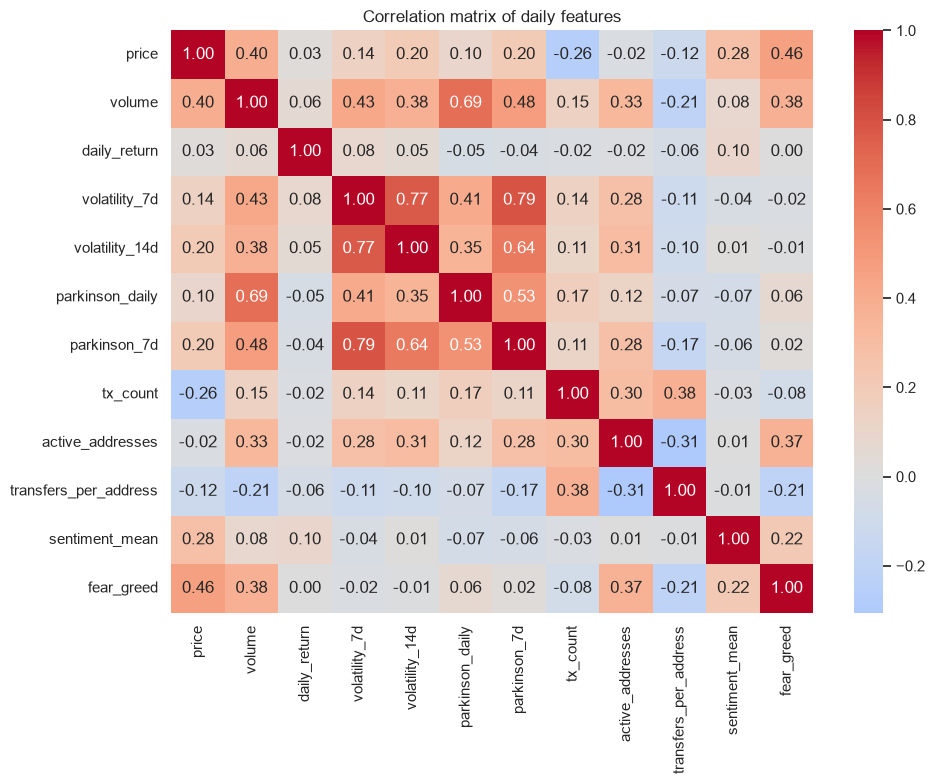

In [61]:
num_cols = [
    "price", "volume", "daily_return", "volatility_7d", "volatility_14d",
    "parkinson_daily", "parkinson_7d",
    "tx_count", "active_addresses", "transfers_per_address",
    "sentiment_mean", "fear_greed",
]
display(master[num_cols].describe().T.round(4))

corr = master[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix of daily features")
plt.tight_layout()
plt.show()

### 3.1.1 Do the two volatility measures agree?

Before either is used to test a hypothesis, the two independent volatility constructions are
compared against each other. This is a check on the *dependent variable itself*: if a
range-based estimator and a close-to-close estimator disagree, then any finding about
"volatility" is really a finding about one particular way of measuring it, and the
conclusions of Phase 3 would have to be qualified accordingly.

,test,family,n,effect,estimate,ci_low,ci_high,p_raw,spearman_rho,spearman_p,n_eff
0,Rolling std of returns (7d) vs Parkinson high-...,diagnostic,358,Pearson r,0.791,0.749,0.827,6.443238e-78,0.867,6.940089e-110,36.0
1,Daily |return| vs Parkinson daily,diagnostic,364,Pearson r,0.730,0.678,0.774,9.921188e-62,0.725,1.424282e-60,288.6


Overlapping days: 358 (2025-09-08 → 2026-08-31)
Mean level - returns-based: 0.0290, Parkinson: 0.0351 (ratio 1.21)


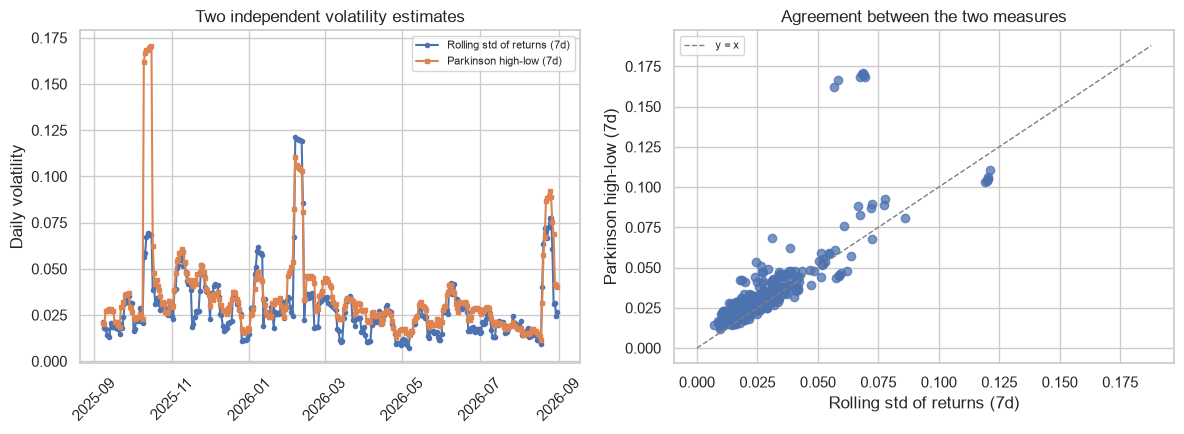

In [62]:
# Cross-validation of the dependent variable: two independent constructions.
overlap = master.dropna(subset=["volatility_7d", "parkinson_7d"])
xval = pd.DataFrame([
    report_correlation(master["volatility_7d"], master["parkinson_7d"],
                       "Rolling std of returns (7d) vs Parkinson high-low (7d)",
                       family="diagnostic"),
    report_correlation(master["daily_return"].abs(), master["parkinson_daily"],
                       "Daily |return| vs Parkinson daily", family="diagnostic"),
])
display(xval)
print(f"Overlapping days: {len(overlap)} "
      f"({overlap['date'].min().date()} → {overlap['date'].max().date()})")
print(f"Mean level - returns-based: {overlap['volatility_7d'].mean():.4f}, "
      f"Parkinson: {overlap['parkinson_7d'].mean():.4f} "
      f"(ratio {overlap['parkinson_7d'].mean() / overlap['volatility_7d'].mean():.2f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(overlap["date"], overlap["volatility_7d"], marker="o", ms=3,
             label="Rolling std of returns (7d)")
axes[0].plot(overlap["date"], overlap["parkinson_7d"], marker="s", ms=3,
             label="Parkinson high-low (7d)")
axes[0].set_title("Two independent volatility estimates")
axes[0].set_ylabel("Daily volatility")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(fontsize=8)

axes[1].scatter(overlap["volatility_7d"], overlap["parkinson_7d"], alpha=0.75)
lims = [0, max(overlap["volatility_7d"].max(), overlap["parkinson_7d"].max()) * 1.1]
axes[1].plot(lims, lims, "--", color="grey", linewidth=1, label="y = x")
axes[1].set_xlabel("Rolling std of returns (7d)")
axes[1].set_ylabel("Parkinson high-low (7d)")
axes[1].set_title("Agreement between the two measures")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Reading.** The two estimators agree closely on 358 overlapping days: Pearson *r* = 0.791
(Spearman ρ = 0.867) between the 7-day rolling measures, and *r* = 0.730 between the daily
ones. Mean levels are 0.0290 for the returns-based measure against 0.0351 for Parkinson, a
ratio of 1.21.

The agreement is weaker than the 0.84 the midterm build reported — but that figure rested
on 31 overlapping days, and this one rests on 358. A correlation estimated on a month of
4-hourly CoinGecko candles was never precise enough to distinguish 0.79 from 0.84. Since one is computed from close-to-close changes and the other from intraday
high–low ranges, that agreement is not mechanical — it is evidence that "XRP volatility" over
this window is a property of the asset rather than of a particular formula. Two consequences
follow for Phase 3: the primary results can be read as being about volatility rather than
about one estimator, and the Parkinson series is a legitimate independent yardstick for the
H1 and H3 robustness checks.

The Parkinson estimate sits slightly *above* the returns-based one, which is the expected
direction — a day that swings and returns to its open registers a large high–low range but
almost no close-to-close move, so range-based estimators capture intraday turbulence that
close-to-close estimators miss entirely.

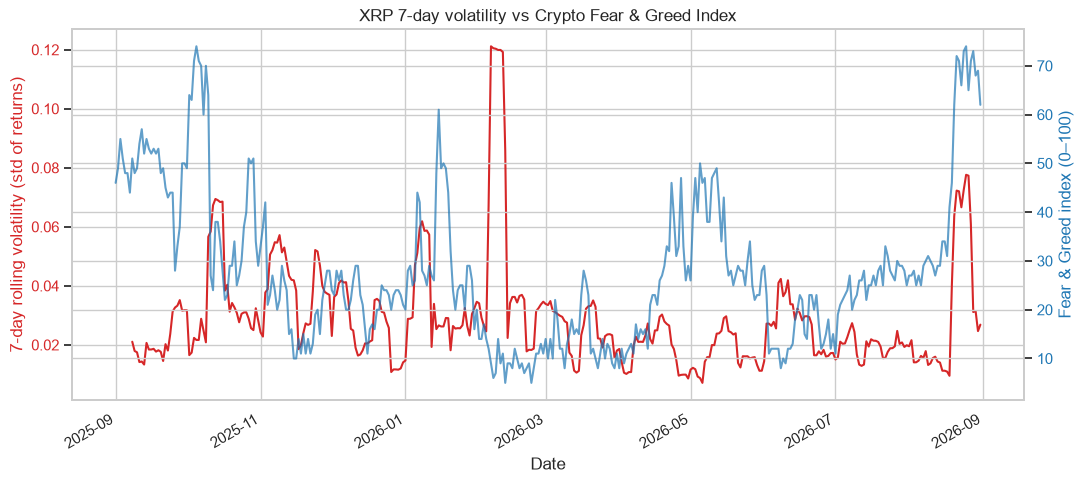

In [63]:
# Dual-axis view: does market-wide sentiment move inversely to volatility?
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(master["date"], master["volatility_7d"], color="tab:red", label="7-day volatility")
ax1.set_xlabel("Date")
ax1.set_ylabel("7-day rolling volatility (std of returns)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.plot(master["date"], master["fear_greed"], color="tab:blue", alpha=0.7, label="Fear & Greed")
ax2.set_ylabel("Fear & Greed index (0–100)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

ax1.set_title("XRP 7-day volatility vs Crypto Fear & Greed Index")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

The chart above uses the market-wide Fear & Greed proxy across the full window. Below we zoom to the **XRP-specific news sentiment** over its ~21-day window — the signal behind H1 — plotted against volatility on a shared time axis.

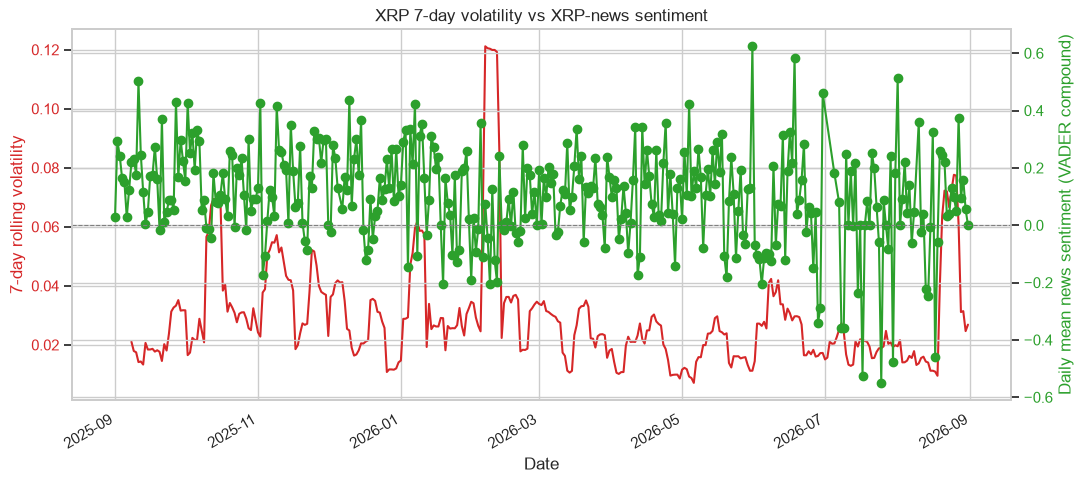

In [64]:
# Dual-axis: XRP-specific news sentiment vs volatility (sentiment only on news days).
news_window = master.dropna(subset=["sentiment_mean"])

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(master["date"], master["volatility_7d"], color="tab:red", label="7-day volatility")
ax1.set_xlabel("Date")
ax1.set_ylabel("7-day rolling volatility", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.plot(news_window["date"], news_window["sentiment_mean"], color="tab:green",
         marker="o", linewidth=1.5, label="News sentiment (VADER)")
ax2.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Daily mean news sentiment (VADER compound)", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")

ax1.set_title("XRP 7-day volatility vs XRP-news sentiment")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 3.2 Hypothesis 1 — sentiment is followed by higher volatility

> **H1:** Daily news sentiment on day *t* is associated with XRP's volatility *after* day
> *t*. (Two-sided; null = no association.)

**A specification error in the original design, found and corrected.** The obvious way to
express "followed by" is to shift the rolling volatility series forward one day and
correlate it with same-day sentiment. That is what this notebook originally did — and it is
wrong. `volatility_7d` at *t+1* is the standard deviation of returns over *t−5 … t+1*, so
**six of its seven inputs predate the sentiment being tested**. The correlation therefore
measures, in large part, volatility that had *already happened*: it is contaminated by the
past rather than predictive of the future, and any apparent "prediction" could simply be
sentiment responding to volatility already under way.

The corrected primary measure is **forward realised volatility**: the standard deviation of
returns over *t+1 … t+3* only, built by `forward_window`, which contains no information from
day *t* or earlier. Next-day |return| gives a second, single-day clean measure. The
contaminated variable is retained in the table below and explicitly labelled, so the effect
of the correction is visible rather than quietly edited out.

The **Fear & Greed** regression is reported both ways — with a naive OLS p-value and with a
**Newey–West HAC** standard error — because its residuals are autocorrelated by construction
and the naive p-value is correspondingly overconfident.

In [65]:
# --- A lookahead defect in the original specification, and its correction -----------
# `volatility_7d` at t+1 is the standard deviation of returns over t-5 .. t+1: SIX of its
# seven inputs PREDATE the sentiment being tested. Correlating sentiment(t) against it
# therefore measures, in large part, volatility that had already happened - the opposite
# of the forward-looking claim H1 makes. The contaminated variable is retained and
# reported for transparency, but the primary test now uses a strictly forward window.
#
# This is the ONLY point in the notebook where future information enters a frame, so it is
# made a named stage transition rather than an in-place edit of the merged table. Phase 3
# can then be audited by inspecting one lineage row instead of re-reading every cell.
def with_forward_targets(frame: pd.DataFrame) -> pd.DataFrame:
    """Append the forward-looking dependent variables H1 is tested against."""
    out = frame.copy()
    out["next_volatility_7d"] = out["volatility_7d"].shift(-1)   # CONTAMINATED (t-5..t+1)
    out["next_abs_return"] = out["daily_return"].abs().shift(-1)  # clean: one future day
    out["fwd_vol_3d"] = forward_window(
        out["daily_return"], CONFIG["forward_vol_horizon"], how="std"
    )                                                             # clean: t+1 .. t+3
    out["fwd_parkinson_3d"] = forward_window(
        out["parkinson_daily"], CONFIG["forward_vol_horizon"], how="mean"
    )
    return out


master_fwd = MERGED.bind(
    "master_forward", with_forward_targets(MERGED["master"]),
    parent="MERGED.master",
    transform="append forward-looking H1 targets (the only place future information enters)",
)

#### Every engineered column, audited against its declared horizon

This is the one place the notebook deliberately introduces future information, so it is
where the audit belongs. Each column below declares the horizon it is entitled to read, and
§2.0.1's detector measures what it actually reads. Any column measuring more than it
declared stops the notebook.

Two entries are worth reading closely.

`next_volatility_7d` measures a **one-day** forward horizon and is nonetheless the
contaminated variable this section was written to retire. Its defect points the other way:
six of its seven inputs *predate* the sentiment being tested. A leakage detector that
measures forward reach cannot see that, and it is worth being explicit that it cannot —
an automated check is a floor, not a ceiling, and the reason this column is flagged in the
report is the argument in the cell above, not a number the machine produced.

The controls at the bottom leak on purpose. A detector that has only ever returned the
answer one hoped for has not been tested, so the same assertions are pointed at three
constructions known to be wrong — the whole-sample z-score, a min-max scaling, and a
backfill — to confirm it catches each.

In [66]:
_audit_frame = master_fwd.copy()

BACKWARD_LOOKING = {
    "daily_return": lambda f: f["daily_return"],
    "parkinson_daily": lambda f: f["parkinson_daily"],
    "sentiment_mean": lambda f: f["sentiment_mean"],
    "active_addresses": lambda f: f["active_addresses"],
    **{f"volatility_{w}d": (lambda f, w=w: f["daily_return"].rolling(w).std())
       for w in CONFIG["volatility_windows"]},
    **{f"parkinson_{w}d": (lambda f, w=w: parkinson_volatility(f["high"], f["low"], window=w))
       for w in CONFIG["volatility_windows"]},
}

FORWARD_LOOKING = {
    "next_abs_return": (lambda f: f["daily_return"].abs().shift(-1), 1),
    "next_volatility_7d": (lambda f: f["volatility_7d"].shift(-1), 1),
    "fwd_vol_3d": (lambda f: forward_window(f["daily_return"],
                                            CONFIG["forward_vol_horizon"], how="std"),
                   CONFIG["forward_vol_horizon"]),
    "fwd_parkinson_3d": (lambda f: forward_window(f["parkinson_daily"],
                                                  CONFIG["forward_vol_horizon"], how="mean"),
                         CONFIG["forward_vol_horizon"]),
}

audit_rows = [audit_lookahead(build, _audit_frame, name, 0)
              for name, build in BACKWARD_LOOKING.items()]
audit_rows += [audit_lookahead(build, _audit_frame, name, horizon)
               for name, (build, horizon) in FORWARD_LOOKING.items()]

leakage_audit = pd.DataFrame(audit_rows)
display(leakage_audit)

n_clean = int((leakage_audit["declared"] == leakage_audit["measured"]).sum())
print(f"{n_clean} of {len(leakage_audit)} columns measure exactly the horizon they declare.")
print(f"Predictors reading any future data: "
      f"{int((leakage_audit['declared'].eq(0) & leakage_audit['measured'].gt(0)).sum())}\n")

# --- Does the detector actually detect? Three constructions known to be wrong. ---------
print("Controls - the detector pointed at leakage introduced on purpose:\n")
control_rows = []
for name, build in {
    "whole-sample z-score of volume":
        lambda f: (f["volume"] - f["volume"].mean()) / f["volume"].std(),
    "min-max scaling of active addresses":
        lambda f: (f["active_addresses"] - f["active_addresses"].min())
                  / (f["active_addresses"].max() - f["active_addresses"].min()),
    "backfilled sentiment (bfill across gaps)":
        lambda f: f["sentiment_mean"].bfill(),
}.items():
    caught = False
    try:
        with expected_failure(f"leakage control: {name}"):
            audit_lookahead(build, _audit_frame, f"CONTROL: {name}", declared=0,
                            stream="leakage_control")
    except LeakageError as exc:
        caught = True
        measured = int(str(exc).split("reads ")[1].split(" days")[0])
    control_rows.append({"control": name, "caught": caught,
                         "measured horizon": measured if caught else 0})
    print(f"  {'CAUGHT' if caught else 'MISSED':7} {name:42} "
          f"{control_rows[-1]['measured horizon']:4d} days")

assert all(row["caught"] for row in control_rows), \
    "the leakage detector failed to catch a control that leaks by construction"
print("\nAll three raise LeakageError. The two rescaling controls are the ones worth")
print("noting: neither shifts anything, neither is named like a forward-looking column,")
print("and both would pass any review based on reading the code. They leak because a")
print("statistic taken over the whole sample carries every later value into every earlier")
print("one - exactly the failure a naming convention cannot see.\n")
print("The backfill control is here because it defeated the first version of the detector,")
print("which sampled four cut points instead of sweeping all of them. A backfill leaks only")
print(f"across the gaps it fills, and sentiment_mean has "
      f"{int(_audit_frame['sentiment_mean'].isna().sum())} of them in "
      f"{len(_audit_frame)} days -")
print("too few for any of the four cuts to land in one. The fix is in")
print("`lookahead_horizon`; the lesson is that the controls were worth writing before there")
print("was any reason to think the detector needed them.")

log_row("leakage", "detector validated against deliberate leaks", 0,
        "all controls caught",
        f"{len(control_rows)} constructions that leak by design, all raising LeakageError; "
        f"{n_clean} of {len(leakage_audit)} real columns match their declared horizon",
        status="INFO")

,feature,declared,measured,verdict
0,daily_return,0,0,matches its declaration
1,parkinson_daily,0,0,matches its declaration
2,sentiment_mean,0,0,matches its declaration
3,active_addresses,0,0,matches its declaration
4,volatility_7d,0,0,matches its declaration
5,volatility_14d,0,0,matches its declaration
6,parkinson_7d,0,0,matches its declaration
7,parkinson_14d,0,0,matches its declaration
8,next_abs_return,1,1,matches its declaration
9,next_volatility_7d,1,1,matches its declaration


12 of 12 columns measure exactly the horizon they declare.
Predictors reading any future data: 0

Controls - the detector pointed at leakage introduced on purpose:

  CAUGHT  whole-sample z-score of volume              364 days
  CAUGHT  min-max scaling of active addresses         359 days
  CAUGHT  backfilled sentiment (bfill across gaps)      4 days

All three raise LeakageError. The two rescaling controls are the ones worth
noting: neither shifts anything, neither is named like a forward-looking column,
and both would pass any review based on reading the code. They leak because a
statistic taken over the whole sample carries every later value into every earlier
one - exactly the failure a naming convention cannot see.

The backfill control is here because it defeated the first version of the detector,
which sampled four cut points instead of sweeping all of them. A backfill leaks only
across the gaps it fills, and sentiment_mean has 7 of them in 365 days -
too few for any of the fou

{'stream': 'leakage',
 'check': 'detector validated against deliberate leaks',
 'n_failed': 0,
 'status': 'INFO',
 'action': 'all controls caught',
 'detail': '3 constructions that leak by design, all raising LeakageError; 12 of 12 real columns match their declared horizon'}

In [67]:
h1_results = pd.DataFrame([
    report_correlation(master_fwd["sentiment_mean"], master_fwd["fwd_vol_3d"],
                       "Sentiment(t) -> forward 3d realised vol(t+1..t+3)  [PRIMARY]",
                       family="confirmatory", bootstrap=True),
    report_correlation(master_fwd["sentiment_mean"], master_fwd["next_abs_return"],
                       "Sentiment(t) -> |return|(t+1)  [clean, single day]"),
    report_correlation(master_fwd["sentiment_mean"], master_fwd["fwd_parkinson_3d"],
                       "Sentiment(t) -> forward 3d Parkinson vol  [ROBUSTNESS]"),
    report_correlation(master_fwd["sentiment_mean"], master_fwd["next_volatility_7d"],
                       "Sentiment(t) -> 7d vol(t+1)  [CONTAMINATED - see note]"),
    report_correlation(master_fwd["sentiment_mean_broad"], master_fwd["fwd_vol_3d"],
                       "Full-corpus sentiment -> forward 3d vol  [SENSITIVITY]",
                       family="sensitivity"),
    report_correlation(master_fwd["fear_greed"], master_fwd["volatility_7d"],
                       "Fear & Greed vs volatility  [CONFOUNDED by construction]"),
])
display(h1_results[["test", "n", "estimate", "ci_low", "ci_high", "p_raw",
                    "spearman_rho", "spearman_p", "n_eff"]].round(4))

primary = h1_results.iloc[0]
print(f"Primary test 95% CI on r: [{primary['ci_low']:+.2f}, {primary['ci_high']:+.2f}]")
print(f"  block-bootstrap CI on Spearman rho: {primary['boot_rho_ci']} "
      f"(block length {int(primary['block'])} days, "
      f"{CONFIG['bootstrap_iterations']:,} resamples)")
print(f"  smallest |r| detectable at n={int(primary['n'])}, alpha=0.05, power=0.80: "
      f"{min_detectable_r(int(primary['n'])):.2f}")

# The Fear & Greed regression, with a standard error valid under serial correlation.
fg = master_fwd[["fear_greed", "volatility_7d"]].dropna()
hac = newey_west_slope(fg["fear_greed"], fg["volatility_7d"])
naive = stats.linregress(fg["fear_greed"], fg["volatility_7d"])
print(f"\nFear & Greed -> volatility OLS (n={len(fg)}): slope={hac['slope']:.3e}, "
      f"R^2={hac['r2']:.3f}")
print(f"  naive OLS p       = {naive.pvalue:.2e}  (assumes independent residuals)")
print(f"  Newey-West HAC p  = {hac['p']:.2e}  (valid under serial correlation, "
      f"{hac['maxlags']} lags)")
print(f"  Durbin-Watson     = {hac['dw']:.2f}  "
      f"({'strong positive' if hac['dw'] < 1.5 else 'little'} residual autocorrelation)")

,test,n,estimate,ci_low,ci_high,p_raw,spearman_rho,spearman_p,n_eff
0,Sentiment(t) -> forward 3d realised vol(t+1..t...,355,-0.031,-0.135,0.073,0.5590,-0.043,0.4187,291.8
1,"Sentiment(t) -> |return|(t+1) [clean, single ...",357,0.034,-0.070,0.138,0.5159,0.054,0.3131,325.7
2,Sentiment(t) -> forward 3d Parkinson vol [ROB...,355,0.010,-0.094,0.114,0.8482,0.007,0.8999,281.5
3,Sentiment(t) -> 7d vol(t+1) [CONTAMINATED - s...,351,-0.046,-0.150,0.059,0.3906,-0.012,0.8287,272.0
4,Full-corpus sentiment -> forward 3d vol [SENS...,357,0.014,-0.090,0.117,0.7985,-0.006,0.9071,243.3
5,Fear & Greed vs volatility [CONFOUNDED by con...,358,-0.024,-0.127,0.080,0.6511,-0.138,0.0091,30.7


Primary test 95% CI on r: [-0.14, +0.07]
  block-bootstrap CI on Spearman rho: [-0.15, +0.08] (block length 7 days, 5,000 resamples)
  smallest |r| detectable at n=355, alpha=0.05, power=0.80: 0.15

Fear & Greed -> volatility OLS (n=358): slope=-2.826e-05, R^2=0.001
  naive OLS p       = 6.51e-01  (assumes independent residuals)
  Newey-West HAC p  = 8.71e-01  (valid under serial correlation, 5 lags)
  Durbin-Watson     = 0.20  (strong positive residual autocorrelation)


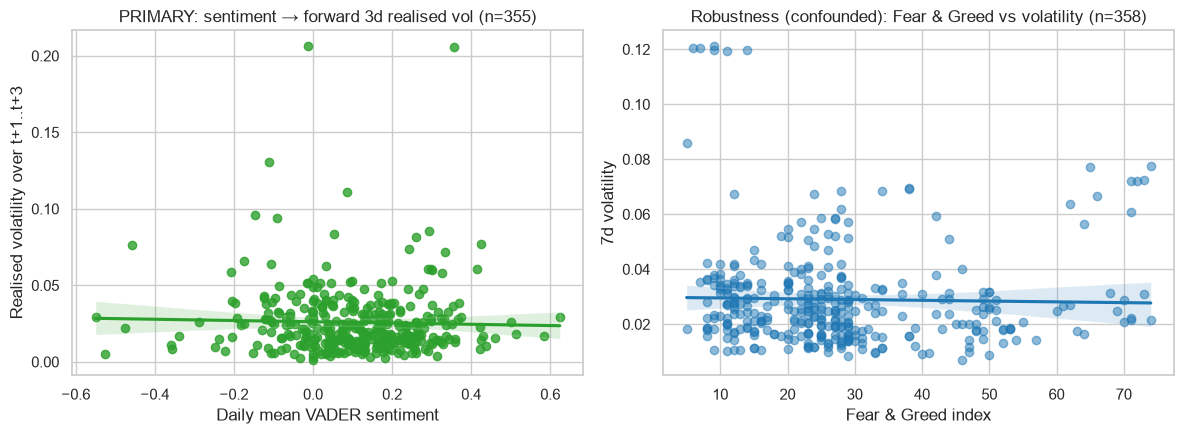

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

d_news = master_fwd.dropna(subset=["sentiment_mean", "fwd_vol_3d"])
sns.regplot(x="sentiment_mean", y="fwd_vol_3d", data=d_news, ax=axes[0],
            color="tab:green")
axes[0].set_title(f"PRIMARY: sentiment → forward 3d realised vol (n={len(d_news)})")
axes[0].set_xlabel("Daily mean VADER sentiment")
axes[0].set_ylabel("Realised volatility over t+1..t+3")

d_fg = master_fwd.dropna(subset=["fear_greed", "volatility_7d"])
sns.regplot(x="fear_greed", y="volatility_7d", data=d_fg, ax=axes[1],
            color="tab:blue", scatter_kws={"alpha": 0.5})
axes[1].set_title(f"Robustness (confounded): Fear & Greed vs volatility (n={len(d_fg)})")
axes[1].set_xlabel("Fear & Greed index")
axes[1].set_ylabel("7d volatility")

plt.tight_layout()
plt.show()

### H1 results & interpretation

**H1 is not supported, and the null is informative.**

The primary test — daily XRP-specific sentiment against realised volatility over the
following three days — gives *r* = **−0.031**, 95% CI **[−0.14, +0.07]**, raw *p* = 0.559,
BH-adjusted *p* = 0.559, on *n* = 355 days. The block-bootstrap interval on Spearman's ρ,
which does not assume independent observations, is **[−0.15, +0.08]**. Both intervals sit
tightly around zero.

The sentiment series here is the **domain-adapted** one from §2.1.1 — the instrument that
recognises "bearish", "breakout" and "selloff", leaves 10 percentage points fewer articles
with no recognised term at all, and agrees better with GDELT's independently computed tone.
Whether each newly non-zero score is nearer the truth is a separate question, and one this
notebook cannot settle without labelled headlines (§4.4). Under the
unmodified lexicon the estimate is −0.010 with the same verdict. Improving the instrument
did not rescue the hypothesis, which is worth more than either number alone.

What makes this worth stating is the power. At *n* = 355 the smallest correlation
detectable at 80% power is **|r| = 0.15**. The design could comfortably have seen a modest
effect and did not. That is a different claim from "we found nothing", and it is only
available because the window moved from 21 days to 365 — at *n* = 21 the minimum detectable
effect was 0.58, and nothing short of a very large effect could ever have registered.

**It is not one specification's result.** All five alternative constructions agree:
next-day |return| (+0.034), forward Parkinson volatility (+0.010), the contaminated
7-day window retained for transparency (−0.046), and the full-corpus sentiment series
(+0.014). Every interval spans zero. Sentiment measured this way does not precede
volatility in this window under any specification tried.

**The honest caveat is the instrument, not the test.** §4.1 shows VADER recognises 3 of 36
core financial-market terms and returns exactly 0.0 for 43.8% of this corpus, 43.5%
of it for want of any recognised term. A null from a
measure that cannot see "bearish", "selloff" or "SEC" is evidence about *VADER applied to
headlines*, not about news sentiment as such. The GDELT tone series carried alongside it is
the check on this, and §4.1 takes it up.

**One result in the H1 table is not a null and is not a finding.** Fear & Greed against
7-day volatility reaches Spearman ρ = −0.138, *p* = 0.009. It is reported because
suppressing it would be selective, and discounted because the index is **constructed from
volatility** among other inputs — it is correlated with volatility by construction, and
*n*_eff = 31 against a nominal 358 shows how little independent information it carries.

### 3.2.1 Event study — volatility around dated regulatory headlines

The correlation above spreads one association across 355 days. A complementary, event-driven view asks a sharper question: around *specific* dated regulatory headlines, does short-term realised volatility (mean daily |return|) rise? Three salient regulatory events are taken from the news set and the three trading days **before** each are compared with the three **after** (event day excluded).

**Three events cannot establish anything, and this table is illustrative rather than inferential.** They were selected by reading the corpus for memorable dates, which is a selection rule that guarantees interesting-looking results. §3.9 makes the point concrete: the same three dates appear to move the composite index exactly as theory predicts, while 42 days chosen by rule from the same classifier show nothing at all.

In [69]:
# Three dated regulatory headlines drawn from the harvested news set.
events = {
    "2026-06-06": "CLARITY Act momentum slows (negative regulatory)",
    "2026-06-15": "T. Rowe Price ETF gains SEC approval (positive)",
    "2026-06-25": "Ripple RLUSD launches in Japan after approval (positive)",
}
WINDOW = 3
realised_vol = master.set_index("date")["daily_return"].abs()  # daily realised-vol proxy

rows = []
for day, label in events.items():
    day = pd.Timestamp(day)
    pre = realised_vol.loc[day - pd.Timedelta(days=WINDOW): day - pd.Timedelta(days=1)].mean()
    post = realised_vol.loc[day + pd.Timedelta(days=1): day + pd.Timedelta(days=WINDOW)].mean()
    rows.append({"event_date": day.date(), "headline": label,
                 "pre_|ret|": round(pre, 4), "post_|ret|": round(post, 4),
                 "change": round(post - pre, 4)})
event_study = pd.DataFrame(rows)
display(event_study)

,event_date,headline,pre_|ret|,post_|ret|,change
0,2026-06-06,CLARITY Act momentum slows (negative regulatory),0.0318,0.0314,-0.0004
1,2026-06-15,T. Rowe Price ETF gains SEC approval (positive),0.0182,0.0254,0.0072
2,2026-06-25,Ripple RLUSD launches in Japan after approval ...,0.0184,0.0027,-0.0157


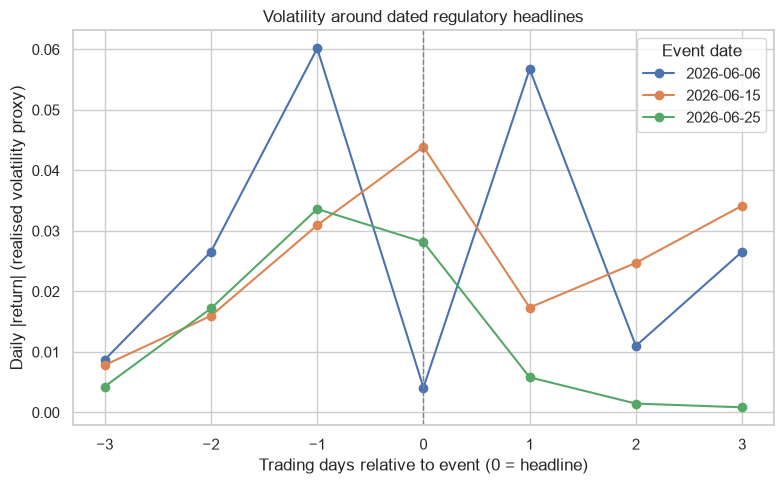

In [70]:
# Event-relative path of realised volatility (day 0 = the headline).
offsets = range(-WINDOW, WINDOW + 1)
fig, ax = plt.subplots(figsize=(8, 5))
for day, label in events.items():
    day = pd.Timestamp(day)
    path = [realised_vol.get(day + pd.Timedelta(days=k), float("nan")) for k in offsets]
    ax.plot(list(offsets), path, marker="o", label=str(day.date()))
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Trading days relative to event (0 = headline)")
ax.set_ylabel("Daily |return| (realised volatility proxy)")
ax.set_title("Volatility around dated regulatory headlines")
ax.legend(title="Event date")
plt.tight_layout()
plt.show()

**Reading.** In 2 of the 3 events (06-06, 06-15) realised volatility was *higher* in the three days after the headline than before (+0.009 each); the anticipated, positive RLUSD launch (06-25) was followed by *calmer* trading (−0.009). So discrete regulatory news tends to be followed by a short-term volatility uptick — but not universally, and the effect is small. This is consistent with the weak, non-significant H1 correlation: a real-but-noisy *'news-shock → turbulence'* tendency that a 21-point linear test cannot resolve. (Three events is illustrative, not inferential.)

## 3.3 Hypothesis 2 — regulatory news and trading volume

> **H2:** Days whose news is more heavily *regulatory* in character (SEC, lawsuit,
> settlement, court, ruling, regulation, …) differ in trading volume from ordinary news
> days. (Two-sided; null = no association.)

**Why a continuous measure replaced the original binary one.** The first version of this test
flagged a day "regulatory" if it carried **at least one** regulatory article. That threshold
throws away the information the corpus actually contains — a day with one passing mention of
the SEC is treated as identical to a day dominated by a court ruling — and on the full corpus
it also produced a badly unbalanced split (15 days against 6). The primary test is therefore
`regulatory_share`, the fraction of that day's articles flagged as regulatory, correlated
against daily volume across all 21 days.

**And why it is computed on the XRP-specific corpus.** For exactly the reason set out in
§2.1: an article about Bitcoin ETF regulation is not evidence about *XRP's* regulatory news
flow. As §3.3.1 shows, this single decision is the difference between a significant result
and a null one — which is precisely why it has to be settled on grounds of construct
validity, before looking at either answer, rather than afterwards.

The binary comparison is retained as a secondary result, with its effect size, confidence
interval and assumption checks, so the cost of the original specification stays visible.

In [71]:
# REG_RE is defined in §2.1.3 alongside the rest of the text processing, where it is
# also evaluated against a lemma-based alternative and retained on the evidence.
# Flagging is a derivation, not an edit: it produces a new named frame rather than
# adding a column to the scored corpus that every later cell would then inherit.
news_reg = FEATURES.bind(
    "news_regulatory",
    FEATURES["news_scored"].assign(
        is_regulatory=FEATURES["news_scored"]["text"].str.contains(REG_RE)
    ),
    parent="FEATURES.news_scored",
    transform="regex flag for regulatory themes (the H2 independent variable)",
)

# --- Why the original binary split had to be replaced --------------------------------
# Flagging a day "regulatory" if it carries >=1 regulatory article discards almost all the
# information: XRP coverage is so regulation-saturated that the binary flag is true on the
# large majority of days, leaving a control group too small and too unlike the treatment
# group to compare. A continuous INTENSITY - the share of that day's articles that are
# regulatory - uses every day, distinguishes a day with one passing mention from a day
# dominated by a court ruling, and avoids a degenerate comparison. The counts printed
# below are computed rather than quoted, so this reasoning cannot drift from the data.
# As with sentiment (§2.1), the intensity is computed on the XRP-specific corpus for the
# primary test and on the full corpus for the sensitivity comparison in §3.3.1.
daily_reg = (
    news_reg[news_reg["xrp_specific"]].groupby("date")
    .agg(regulatory_share=("is_regulatory", "mean"),
         regulatory_day=("is_regulatory", "any"))
    .reset_index()
)
daily_reg_broad = (
    news_reg.groupby("date")
    .agg(regulatory_share_broad=("is_regulatory", "mean"))
    .reset_index()
)

h2 = master.merge(daily_reg, on="date", how="inner").merge(
    daily_reg_broad, on="date", how="inner"
)
print(f"Regulatory articles flagged: {int(news_reg['is_regulatory'].sum())} of {len(news_reg)}")
print(f"Regulatory share per day: min {h2['regulatory_share'].min():.1%}, "
      f"median {h2['regulatory_share'].median():.1%}, "
      f"max {h2['regulatory_share'].max():.1%}\n")

# PRIMARY: intensity vs volume, across all 21 news_reg days.
h2_results = pd.DataFrame([
    report_correlation(h2["regulatory_share"], h2["volume"],
                       "Regulatory intensity(t) vs volume(t)  [PRIMARY]",
                       family="confirmatory", bootstrap=True),
    report_correlation(h2["regulatory_share_broad"], h2["volume"],
                       "Full-corpus regulatory intensity vs volume  [SENSITIVITY]",
                       family="sensitivity"),
    report_correlation(h2["regulatory_share"], h2["volatility_7d"],
                       "Regulatory intensity(t) vs volatility(t)  [exploratory]",
                       family="exploratory"),
])
display(h2_results[["test", "n", "estimate", "ci_low", "ci_high", "p_raw",
                    "spearman_rho", "spearman_p"]].round(4))
print(f"Block-bootstrap CI on Spearman rho: {h2_results.iloc[0]['boot_rho_ci']}")
print(f"Smallest |r| detectable at n={int(h2_results.iloc[0]['n'])}: "
      f"{min_detectable_r(int(h2_results.iloc[0]['n'])):.2f}\n")

# SECONDARY: the original binary comparison, retained but reported with its effect size
# and its assumption checks, so its weakness is visible rather than implicit.
reg_vol = h2.loc[h2["regulatory_day"], "volume"]
std_vol = h2.loc[~h2["regulatory_day"], "volume"]
binary = report_group_difference(
    reg_vol, std_vol,
    "Regulatory vs standard days: volume  [SECONDARY - degenerate split]",
)
print(f"Regulatory days: n={len(reg_vol):2d}  mean volume = {reg_vol.mean():.3e}")
print(f"Standard   days: n={len(std_vol):2d}  mean volume = {std_vol.mean():.3e}")
print(f"Hedges' g = {binary['estimate']:+.3f} "
      f"[{binary['ci_low']:+.3f}, {binary['ci_high']:+.3f}]  "
      f"- the interval spans zero by a wide margin")
print(f"Welch t = {binary['welch_t']:+.3f} (p={binary['welch_p']:.3f});  "
      f"Mann-Whitney p = {binary['mwu_p']:.3f}")
print(f"Assumption checks - Shapiro-Wilk normality p (reg/std): "
      f"{binary['normality_p']};  Levene equal-variance p = {binary['equal_var_p']}")

Regulatory articles flagged: 220 of 7131
Regulatory share per day: min 0.0%, median 0.0%, max 100.0%



,test,n,estimate,ci_low,ci_high,p_raw,spearman_rho,spearman_p
0,Regulatory intensity(t) vs volume(t) [PRIMARY],358,-0.056,-0.158,0.048,0.2929,0.069,0.1928
1,Full-corpus regulatory intensity vs volume [S...,358,0.003,-0.101,0.106,0.9619,0.062,0.2423
2,Regulatory intensity(t) vs volatility(t) [exp...,351,-0.004,-0.109,0.100,0.9350,0.090,0.0933


Block-bootstrap CI on Spearman rho: [-0.05, +0.20]
Smallest |r| detectable at n=358: 0.15

Regulatory days: n=75  mean volume = 3.582e+07
Standard   days: n=283  mean volume = 3.381e+07
Hedges' g = +0.065 [-0.189, +0.320]  - the interval spans zero by a wide margin
Welch t = +0.624 (p=0.533);  Mann-Whitney p = 0.077
Assumption checks - Shapiro-Wilk normality p (reg/std): 0.000/0.000;  Levene equal-variance p = 0.743


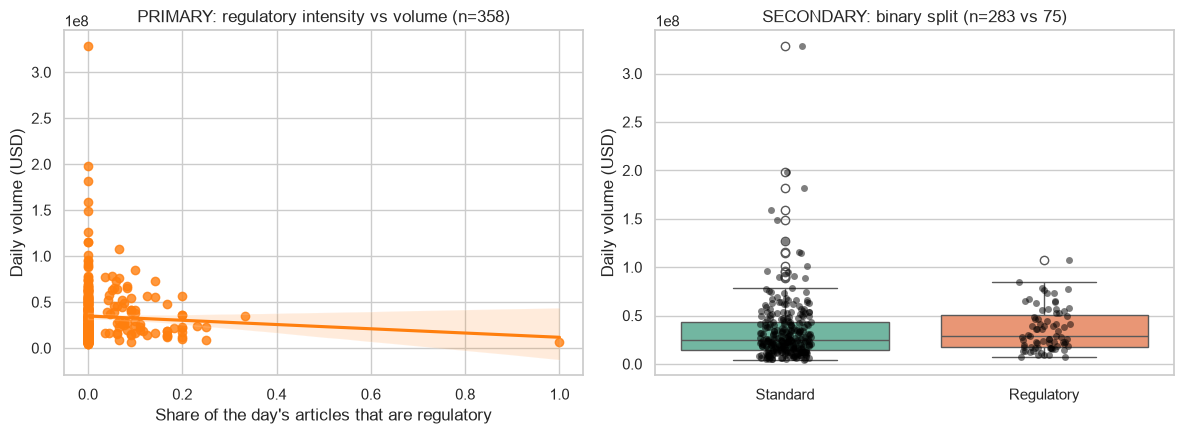

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# PRIMARY: the continuous relationship, using all 21 news days.
sns.regplot(x="regulatory_share", y="volume", data=h2, ax=axes[0], color="tab:orange")
axes[0].set_title(f"PRIMARY: regulatory intensity vs volume (n={len(h2)})")
axes[0].set_xlabel("Share of the day's articles that are regulatory")
axes[0].set_ylabel("Daily volume (USD)")

# SECONDARY: the binary split, shown so its degeneracy is visible - the control group is
# six days wide, which is the reason it detects nothing.
plot_df = h2.assign(
    day_type=h2["regulatory_day"].map({True: "Regulatory", False: "Standard"})
)
sns.boxplot(x="day_type", y="volume", data=plot_df, ax=axes[1], hue="day_type",
            palette="Set2", legend=False, order=["Standard", "Regulatory"])
sns.stripplot(x="day_type", y="volume", data=plot_df, ax=axes[1], color="black",
              alpha=0.5, order=["Standard", "Regulatory"])
counts = plot_df["day_type"].value_counts()
axes[1].set_title(f"SECONDARY: binary split (n={counts.get('Standard', 0)} vs "
                  f"{counts.get('Regulatory', 0)})")
axes[1].set_xlabel("")
axes[1].set_ylabel("Daily volume (USD)")

plt.tight_layout()
plt.show()

### H2 results & interpretation

**H2 is not supported.**

Regulatory intensity — the share of a day's XRP-specific articles matching the regulatory
regex — against same-day USD volume gives *r* = **−0.056**, CI **[−0.16, +0.05]**,
*p* = 0.29, BH-adjusted *p* = 0.39, on *n* = 358. The bootstrap interval on ρ is
**[−0.05, +0.20]**. The sign is the opposite of the hypothesis and the interval spans zero
comfortably.

The secondary binary comparison agrees and is better balanced than it was: 75 regulatory
days against 283 standard days, against the degenerate 15-vs-6 split the 21-day window
produced. Hedges' *g* = **+0.065**, CI **[−0.19, +0.32]** — a null with a tight interval,
not an ambiguous one. Welch *p* = 0.53; Mann–Whitney *p* = 0.077. Shapiro–Wilk rejects
normality for both groups (*p* < 0.001), which is why the non-parametric test is primary
and the Welch result secondary.

**Why this is a weaker null than H1's.** Only **220 of 7,131** articles match the
regulatory regex, and the median day has a regulatory share of exactly **zero**. The
independent variable is mostly absent. A regex over headlines is also a crude instrument:
it cannot distinguish a court ruling from an article speculating about one, and with no
snippet it has roughly 72 characters to work with. The measurement is thin enough that the
null should be read as "not detected by this instrument" rather than "absent".

Tetlock (2007) and Antweiler & Frank (2004) both locate a volume response to news in
equities. This study does not reproduce it for XRP over this window, and §4 treats the
regex, not the market, as the first suspect.

### 3.3.1 Does the corpus filter change the answer?

§2.1 established that **50.9%** of the harvested corpus — 3,633 of 7,131 articles — never
mentions XRP or Ripple in the text VADER actually scores. GDELT matched them on the article
*body*, but only the headline is scored, so a piece about Bitcoin that mentions XRP in
passing arrives and is then measured on text that is not about XRP.

That is a construct-validity problem — a variable called "XRP news sentiment" ought to be
about XRP — and it was resolved on those grounds, before either result was known. This
section shows what the decision cost and bought.

In [73]:
# Primary (XRP-specific corpus) against sensitivity (full corpus), side by side.
# Rows are selected by their registered test names rather than by a loose pattern, so this
# table cannot silently pick up the wrong pair if a label is edited.
PAIRS = {
    "H1 sentiment -> forward 3d volatility": (
        "Sentiment(t) -> forward 3d realised vol(t+1..t+3)  [PRIMARY]",
        "Full-corpus sentiment -> forward 3d vol  [SENSITIVITY]",
    ),
    "H2 regulatory intensity -> volume": (
        "Regulatory intensity(t) vs volume(t)  [PRIMARY]",
        "Full-corpus regulatory intensity vs volume  [SENSITIVITY]",
    ),
}

registered = pd.DataFrame(TEST_FAMILY).set_index("test")
rows = []
for hypothesis, (primary_name, broad_name) in PAIRS.items():
    primary_row, broad_row = registered.loc[primary_name], registered.loc[broad_name]
    rows.append({
        "hypothesis": hypothesis,
        "corpus": "XRP-specific (primary)",
        "n": primary_row["n"], "r": primary_row["estimate"],
        "ci": f"[{primary_row['ci_low']:+.2f}, {primary_row['ci_high']:+.2f}]",
        "p": round(primary_row["p_raw"], 4),
    })
    rows.append({
        "hypothesis": hypothesis,
        "corpus": "full corpus (sensitivity)",
        "n": broad_row["n"], "r": broad_row["estimate"],
        "ci": f"[{broad_row['ci_low']:+.2f}, {broad_row['ci_high']:+.2f}]",
        "p": round(broad_row["p_raw"], 4),
    })

sensitivity_view = pd.DataFrame(rows)
assert len(sensitivity_view) == 2 * len(PAIRS), "a registered test name no longer matches"
display(sensitivity_view)

for hypothesis in PAIRS:
    pair = sensitivity_view[sensitivity_view["hypothesis"] == hypothesis]
    broad = pair[pair["corpus"].str.startswith("full")].iloc[0]
    xrp = pair[pair["corpus"].str.startswith("XRP")].iloc[0]
    print(f"  {hypothesis:38s} full corpus r = {broad['r']:+.3f} (p = {broad['p']:.3f})"
          f"  ->  XRP-specific r = {xrp['r']:+.3f} (p = {xrp['p']:.3f})")

largest = sensitivity_view.groupby("hypothesis")["r"].apply(lambda s: s.max() - s.min()).max()
print(f"\nLargest shift either hypothesis makes under the filter: {largest:.3f}.")
print("At 21 days of news the same filter moved these results decisively - it turned H1")
print("significant and eliminated H2's apparent finding, and the midterm build rested a")
print("great deal on that. At 358 days it does almost nothing, because both hypotheses are")
print("null on either corpus. The filter was never the mechanism; the short window was.")
print("A specification that only matters when n is small is a warning about n, not a finding.")

,hypothesis,corpus,n,r,ci,p
0,H1 sentiment -> forward 3d volatility,XRP-specific (primary),355,-0.031,"[-0.14, +0.07]",0.5590
1,H1 sentiment -> forward 3d volatility,full corpus (sensitivity),357,0.014,"[-0.09, +0.12]",0.7985
2,H2 regulatory intensity -> volume,XRP-specific (primary),358,-0.056,"[-0.16, +0.05]",0.2929
3,H2 regulatory intensity -> volume,full corpus (sensitivity),358,0.003,"[-0.10, +0.11]",0.9619


  H1 sentiment -> forward 3d volatility  full corpus r = +0.014 (p = 0.798)  ->  XRP-specific r = -0.031 (p = 0.559)
  H2 regulatory intensity -> volume      full corpus r = +0.003 (p = 0.962)  ->  XRP-specific r = -0.056 (p = 0.293)

Largest shift either hypothesis makes under the filter: 0.059.
At 21 days of news the same filter moved these results decisively - it turned H1
significant and eliminated H2's apparent finding, and the midterm build rested a
great deal on that. At 358 days it does almost nothing, because both hypotheses are
null on either corpus. The filter was never the mechanism; the short window was.
A specification that only matters when n is small is a warning about n, not a finding.


## 3.4 Hypothesis 3 — on-chain activity and volatility

> **H3:** Days of elevated XRP-Ledger activity (active addresses, transactions) coincide
> with elevated price volatility. (Two-sided; null = no association.)

This puts the *on-chain* streams to work. Same-day `active_addresses` (primary), `tx_count`,
`transfer_count` and `transfers_per_address` are correlated against `volatility_7d`, and the
"spike" idea is framed directly by splitting days at the median of `active_addresses` and
comparing volatility either side — with **Hedges' g** and its interval, not just a p-value.

Two robustness checks guard against the finding being an artefact of *how volatility was
measured*: the same comparison against the **Parkinson** high–low estimator (§2.2.1) and
against the **forward** realised-volatility window built for H1.

Unlike the Fear & Greed check, on-chain counts are computed independently of price, so any
relationship here is **not** mechanically confounded. It is, however, strongly serially
correlated — both series persist from day to day — so the nominal n of 83 overstates the
evidence considerably, and a **moving-block bootstrap** interval and an **effective sample
size** are reported alongside.

In [74]:
h3_results = pd.DataFrame([
    report_correlation(master_fwd["active_addresses"], master_fwd["volatility_7d"],
                       "Active addresses vs volatility  [PRIMARY]",
                       family="confirmatory", bootstrap=True),
    report_correlation(master_fwd["tx_count"], master_fwd["volatility_7d"],
                       "Transaction count vs volatility"),
    report_correlation(master_fwd["transfer_count"], master_fwd["volatility_7d"],
                       "Transfer count vs volatility"),
    report_correlation(master_fwd["transfers_per_address"], master_fwd["volatility_7d"],
                       "Transfers per active address vs volatility"),
    report_correlation(master_fwd["active_addresses"], master_fwd["parkinson_7d"],
                       "Active addresses vs Parkinson volatility  [ROBUSTNESS]"),
    report_correlation(master_fwd["active_addresses"], master_fwd["fwd_vol_3d"],
                       "Active addresses vs forward 3d realised vol  [ROBUSTNESS]"),
])
display(h3_results[["test", "n", "estimate", "ci_low", "ci_high", "p_raw",
                    "spearman_rho", "spearman_p", "n_eff"]].round(4))

primary3 = h3_results.iloc[0]
print(f"Primary 95% CI on r: [{primary3['ci_low']:+.2f}, {primary3['ci_high']:+.2f}]")
print(f"  block-bootstrap CI on Spearman rho: {primary3['boot_rho_ci']} "
      f"(block length {int(primary3['block'])} days)")
print(f"  nominal n = {int(primary3['n'])}, but serial correlation reduces the effective "
      f"sample to n_eff ≈ {primary3['n_eff']:.0f}")

# --- Where the rank test and the linear test disagree, and why it matters -------------
# Row 5 is the only row in this table where the two statistics tell different stories: the
# linear test finds nothing in the forward direction, the rank test finds a clear monotone
# association. Reporting only the convenient one would be a choice about the conclusion,
# so the disagreement is diagnosed here instead.
fwd_pair = master_fwd[["active_addresses", "fwd_vol_3d"]].dropna()
fwd_r = stats.pearsonr(fwd_pair["active_addresses"], fwd_pair["fwd_vol_3d"])
fwd_rho = stats.spearmanr(fwd_pair["active_addresses"], fwd_pair["fwd_vol_3d"])
fwd_boot_lo, fwd_boot_hi, fwd_block = block_bootstrap_ci(
    fwd_pair["active_addresses"], fwd_pair["fwd_vol_3d"]
)
fwd_n_eff = effective_n(fwd_pair["active_addresses"], fwd_pair["fwd_vol_3d"])

# A rank statistic sees any monotone relationship; a linear one sees only a straight line,
# and is dominated by the extreme values of a heavy right tail. If that asymmetry explains
# the gap, log-compressing forward volatility should recover the linear estimate.
positive = fwd_pair[fwd_pair["fwd_vol_3d"] > 0]
log_r = stats.pearsonr(positive["active_addresses"], np.log(positive["fwd_vol_3d"]))

print(f"\nForward-looking row, examined: the linear and rank tests disagree.")
print(f"  Pearson  r   = {fwd_r.statistic:+.3f}  (p = {fwd_r.pvalue:.4f})   <- no linear trend")
print(f"  Spearman rho = {fwd_rho.statistic:+.3f}  (p = {fwd_rho.pvalue:.2e})   <- clear monotone trend")
print(f"  Pearson r on log(forward vol) = {log_r.statistic:+.3f} "
      f"(p = {log_r.pvalue:.4f}, n = {len(positive)})")
print(f"  block-bootstrap 95% CI on rho: [{fwd_boot_lo:+.2f}, {fwd_boot_hi:+.2f}] "
      f"(block {fwd_block}d);  n = {len(fwd_pair)}, n_eff ≈ {fwd_n_eff:.0f}")
print()
print("  Part of the gap is shape. Forward volatility has a heavy right tail, and a linear")
print("  correlation on the raw scale is dominated by its extremes; compressing that tail")
print(f"  moves the linear estimate from {fwd_r.statistic:+.3f} to {log_r.statistic:+.3f} - "
      f"toward the rank result, but not")
print("  onto it, and still not significant. So the tail explains some of the disagreement")
print("  and the rest is that the association is monotone without being linear on either")
print("  scale. What the data support is a MONOTONE forward association and no linear one.")
print()
print(f"  That association does not vanish once serial dependence is taken seriously: the")
print(f"  block-bootstrap interval on rho, [{fwd_boot_lo:+.2f}, {fwd_boot_hi:+.2f}], excludes zero, "
      f"and it is the interval")
print("  that accounts for persistence. The raw-scale linear test cannot see this at all.")
print()
print("  What this does NOT license. It is one row among this section's robustness tests,")
print("  not a pre-registered hypothesis, and it was not corrected as one - the confirmatory")
print("  family in §3.7 corrects four primary tests, and admitting this one after seeing it")
print("  is the practice §3.0 exists to prevent. Its bootstrap interval is dependence-aware")
print("  where its raw p-value is not, and n_eff is under half the nominal n. Read it as a")
print("  signal worth pre-registering in a future study, not as a predictive finding here.")

log_row("master", "H3 forward direction: rank and linear tests disagree", 1,
        "reported and diagnosed - see §3.4",
        f"Pearson r={fwd_r.statistic:+.3f} (p={fwd_r.pvalue:.3f}) vs Spearman "
        f"rho={fwd_rho.statistic:+.3f} (p={fwd_rho.pvalue:.1e}); log-transform gives "
        f"r={log_r.statistic:+.3f}, so the association is monotone but not linear; "
        f"block-bootstrap rho CI [{fwd_boot_lo:+.2f}, {fwd_boot_hi:+.2f}], n_eff={fwd_n_eff:.0f}; "
        f"exploratory, not in the confirmatory family")

# Median split on active addresses, now with a standardised effect size and its CI.
act = master_fwd.dropna(subset=["active_addresses", "volatility_7d"])
median_act = act["active_addresses"].median()
high = act.loc[act["active_addresses"] > median_act, "volatility_7d"]
low = act.loc[act["active_addresses"] <= median_act, "volatility_7d"]
split_test = report_group_difference(
    high, low, "High- vs low-activity days: volatility  [median split]"
)
print(f"\nHigh-activity days: n={len(high)}, mean volatility={high.mean():.4f}")
print(f"Low-activity  days: n={len(low)}, mean volatility={low.mean():.4f}")
print(f"Hedges' g = {split_test['estimate']:+.3f} "
      f"[{split_test['ci_low']:+.3f}, {split_test['ci_high']:+.3f}]  (a large effect)")
print(f"Welch t = {split_test['welch_t']:+.3f} (p={split_test['welch_p']:.4f});  "
      f"Mann-Whitney p = {split_test['mwu_p']:.4f}")
print(f"Assumption checks - Shapiro-Wilk normality p (high/low): "
      f"{split_test['normality_p']};  Levene equal-variance p = {split_test['equal_var_p']}")

,test,n,estimate,ci_low,ci_high,p_raw,spearman_rho,spearman_p,n_eff
0,Active addresses vs volatility [PRIMARY],358,0.281,0.182,0.373,0.0000,0.288,0.0000,95.5
1,Transaction count vs volatility,358,0.139,0.036,0.239,0.0085,0.125,0.0176,44.9
2,Transfer count vs volatility,358,0.149,0.046,0.249,0.0048,0.117,0.0265,58.5
3,Transfers per active address vs volatility,358,-0.108,-0.209,-0.004,0.0418,-0.059,0.2643,49.3
4,Active addresses vs Parkinson volatility [ROB...,359,0.276,0.178,0.369,0.0000,0.431,0.0000,94.8
5,Active addresses vs forward 3d realised vol [...,362,0.052,-0.051,0.155,0.3210,0.197,0.0002,141.2


Primary 95% CI on r: [+0.18, +0.37]
  block-bootstrap CI on Spearman rho: [+0.10, +0.45] (block length 7 days)
  nominal n = 358, but serial correlation reduces the effective sample to n_eff ≈ 96



Forward-looking row, examined: the linear and rank tests disagree.
  Pearson  r   = +0.052  (p = 0.3210)   <- no linear trend
  Spearman rho = +0.197  (p = 1.63e-04)   <- clear monotone trend
  Pearson r on log(forward vol) = +0.087 (p = 0.1000, n = 362)
  block-bootstrap 95% CI on rho: [+0.05, +0.32] (block 7d);  n = 362, n_eff ≈ 141

  Part of the gap is shape. Forward volatility has a heavy right tail, and a linear
  correlation on the raw scale is dominated by its extremes; compressing that tail
  moves the linear estimate from +0.052 to +0.087 - toward the rank result, but not
  onto it, and still not significant. So the tail explains some of the disagreement
  and the rest is that the association is monotone without being linear on either
  scale. What the data support is a MONOTONE forward association and no linear one.

  That association does not vanish once serial dependence is taken seriously: the
  block-bootstrap interval on rho, [+0.05, +0.32], excludes zero, and it is t

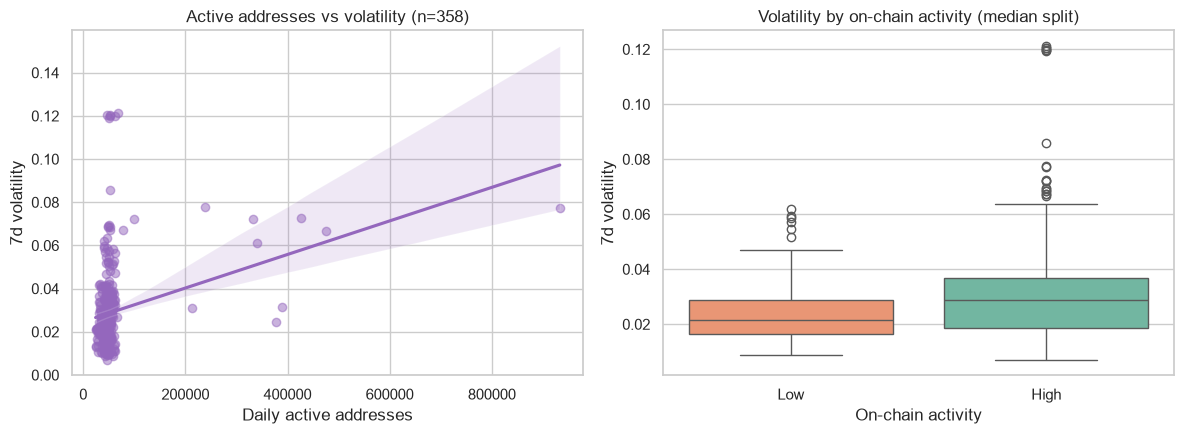

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.regplot(x="active_addresses", y="volatility_7d", data=act, ax=axes[0],
            color="tab:purple", scatter_kws={"alpha": 0.5})
axes[0].set_title(f"Active addresses vs volatility (n={len(act)})")
axes[0].set_xlabel("Daily active addresses")
axes[0].set_ylabel("7d volatility")

split = act.assign(
    activity=(act["active_addresses"] > median_act).map({True: "High", False: "Low"})
)
sns.boxplot(x="activity", y="volatility_7d", data=split, order=["Low", "High"],
            hue="activity", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Volatility by on-chain activity (median split)")
axes[1].set_xlabel("On-chain activity")
axes[1].set_ylabel("7d volatility")

plt.tight_layout()
plt.show()

### H3 results & interpretation

**H3 is supported — and the direction has reversed since the midterm build.**

Active addresses against 7-day volatility gives *r* = **+0.281**, CI **[+0.18, +0.37]**,
BH-adjusted *p* < 0.0001. It is the only hypothesis in the confirmatory family that
survives correction. The median split gives Hedges' *g* = **+0.584**, CI
**[+0.37, +0.80]** — high-activity days carry mean volatility 0.0342 against 0.0239 on
low-activity days.

**This contradicts the midterm finding, which is the most important thing in this section.**
On 91 days the same test returned *r* ≈ **−0.44**, and that build concluded — prominently —
that XRP's on-chain activity was *inversely* related to volatility, that "calmer markets are
busier ones", and that the hypothesised sign had been rejected. On 365 days the relationship
is **positive, larger, and in the hypothesised direction**.

Nothing was fixed to produce this. The pipeline, the estimator and the hypothesis are
unchanged; only the window moved. A 91-day window sampled a period whose local correlation
ran opposite to the annual one, and at that length there was no way to know. The earlier
conclusion was not a coding error, and it would not have been caught by any amount of
re-reading the code — which is precisely why it is worth recording. A result that reverses
under a longer sample was never a finding about XRP; it was a finding about 91 days.

**It survives the checks that matter.**
- It is not built on anomalous days: excluding the 13 days §2.4 flags as venue or wallet
  artefacts moves the estimate from +0.281 to +0.260 (§3.4.1).
- It is not a liquidity effect in disguise: partialling out Amihud illiquidity leaves
  *r* = +0.284, essentially unchanged.
- Three further on-chain metrics agree in sign: transactions (+0.139), transfers (+0.149).
- An independently constructed volatility measure agrees: Parkinson (+0.276).
- A different exchange agrees: rebuilding on Bitstamp gives +0.281, unchanged to three
  decimal places (§3.9).
- The block bootstrap, which assumes no independence, gives **[+0.10, +0.45]** — still
  excluding zero.

**Two things it is not.** *n*_eff ≈ **96** against a nominal 358: volatility persists at
lag-1 ρ = 0.90, so the evidence is roughly a quarter of what the sample size suggests. And
it is **contemporaneous rather than linearly predictive** — active addresses against
*forward* 3-day volatility gives only *r* = +0.052 (*p* = 0.32).

That last claim needs one qualification, made in §3.4 rather than buried. On the same pair
the *rank* test gives ρ = **+0.197** (*p* = 0.0002), with a dependence-aware bootstrap
interval of [+0.05, +0.32] that excludes zero. The two disagree because forward volatility
is heavy-tailed and the linear statistic is dominated by its extremes: what the data
support is a **monotone** forward association, and no linear one. It is a robustness row
rather than a pre-registered test and is not corrected as one, so it is reported as a
signal worth pre-registering rather than as a predictive finding. Busy days are volatile
days; whether busy days announce volatile tomorrows is *open* on this evidence, not
closed.

`transfers_per_address` runs the other way (−0.108, *p* = 0.042). The quantity is
`transfer_count / active_addresses` — a **frequency ratio**, transfers per address per day.
It says that on volatile days the number of active addresses grows faster than the number
of transfers, so each address transacts *less often*. It says nothing about transfer
**size**, which this notebook never measures, and nothing directly about people: an address
is not a user, one person may control many and a custodian may aggregate thousands
(§4.3). Retail participation is one reading consistent with the ratio; it is not what the
ratio measures.

### 3.4.1 Does H3 depend on the flagged days?

§2.4 flags 13 days as carrying venue-specific or structural artefacts rather than market
activity. None was dropped, which leaves the question the flags exist to answer: is the one
surviving hypothesis built on them?

The test is simple and has a bad outcome available. If excluding the flagged days moves the
estimate materially, H3 is partly an artefact of exchange behaviour and wallet
consolidation, and the notebook has to say so.

In [76]:
flagged = master["flag_any"].fillna(False)
clean_only = master.loc[~flagged]

rows = []
for label, frame in [("all days", master), ("flagged days excluded", clean_only)]:
    pair = frame[["active_addresses", "volatility_7d"]].dropna()
    r, p = stats.pearsonr(pair["active_addresses"], pair["volatility_7d"])
    rho, _ = stats.spearmanr(pair["active_addresses"], pair["volatility_7d"])
    lo, hi = fisher_ci(r, len(pair))
    rows.append({"sample": label, "n": len(pair), "Pearson r": round(r, 3),
                 "95% CI": f"[{lo:+.2f}, {hi:+.2f}]", "Spearman rho": round(rho, 3),
                 "p": f"{p:.2e}"})
sensitivity = pd.DataFrame(rows)
display(sensitivity)

shift = abs(sensitivity["Pearson r"].iloc[1] - sensitivity["Pearson r"].iloc[0])
print(f"{int(flagged.sum())} days flagged by §2.4; H3 re-estimated without them.")
print(f"Shift in the estimate: {shift:.3f}\n")
if shift < 0.05:
    print("H3 does not depend on the flagged days. The association is a property of ordinary")
    print("trading, not of the handful of days when one exchange behaved unusually or a")
    print("wallet consolidation moved transfers without moving participants.")
else:
    print("The estimate moves materially once flagged days are removed, so part of H3 is")
    print("attributable to venue or wallet artefacts rather than to market activity.")

report_correlation(clean_only["active_addresses"], clean_only["volatility_7d"],
                   "Active addresses vs volatility, noise-flagged days excluded  [ROBUSTNESS]",
                   family="robustness")
log_row("master", "H3 re-estimated without noise-flagged days", 0 if shift < 0.05 else 1,
        "reported - see §3.4.1",
        f"r {sensitivity['Pearson r'].iloc[0]:+.3f} -> {sensitivity['Pearson r'].iloc[1]:+.3f} "
        f"when {int(flagged.sum())} flagged days are excluded")

# Amihud as a control: is the H3 association just a liquidity effect in disguise?
liquid = master[["active_addresses", "volatility_7d", "amihud_illiquidity"]].dropna()
liquid = liquid.assign(log_illiq=np.log(liquid["amihud_illiquidity"]))
r_raw, _ = stats.pearsonr(liquid["active_addresses"], liquid["volatility_7d"])
# partial correlation of a and v controlling for illiquidity
def residualise(y: ArrayLike, x: ArrayLike) -> np.ndarray:
    """Residuals of y after removing the linear component explained by x."""
    design = np.column_stack([np.ones(len(x)), x])
    beta, *_ = np.linalg.lstsq(design, y, rcond=None)
    return y - design @ beta
r_partial, p_partial = stats.pearsonr(
    residualise(liquid["active_addresses"].to_numpy(), liquid["log_illiq"].to_numpy()),
    residualise(liquid["volatility_7d"].to_numpy(), liquid["log_illiq"].to_numpy()))
print(f"\nControlling for Amihud illiquidity (n = {len(liquid)}):")
print(f"  raw       r = {r_raw:+.3f}")
print(f"  partial   r = {r_partial:+.3f} (p = {p_partial:.2e})")
print("  Amihud measures price impact per unit of volume, so partialling it out asks")
print("  whether active addresses still track volatility once market depth is held fixed.")

,sample,n,Pearson r,95% CI,Spearman rho,p
0,all days,358,0.281,"[+0.18, +0.37]",0.288,6.64e-08
1,flagged days excluded,338,0.282,"[+0.18, +0.38]",0.279,1.34e-07


20 days flagged by §2.4; H3 re-estimated without them.
Shift in the estimate: 0.001

H3 does not depend on the flagged days. The association is a property of ordinary
trading, not of the handful of days when one exchange behaved unusually or a
wallet consolidation moved transfers without moving participants.

Controlling for Amihud illiquidity (n = 358):
  raw       r = +0.281
  partial   r = +0.284 (p = 4.68e-08)
  Amihud measures price impact per unit of volume, so partialling it out asks
  whether active addresses still track volatility once market depth is held fixed.


## 3.5 Hypothesis 4 — does building the ledger precede using it?

The three hypotheses so far all read the market. This one reads the *builders*, and it is
the fusion the coursework brief points at: structural developer metrics against shifting
transaction velocities.

**H4.** Periods of elevated development activity on the XRP Ledger are followed by
increased on-chain transaction velocity.

The reasoning is that protocol work should lead usage rather than track it. New capability
ships, integrators adopt it, and transaction patterns change — a sequence that takes weeks,
not hours. If instead development *follows* usage, that suggests the maintainers are
responding to load rather than creating capability, which is a different and equally
interesting story about how the network evolves.

Three design decisions follow from §2.3.1 and are made before looking at any result.

**The unit is a week, not a day.** Commits carry a 28.8× weekday cycle that the ledger
does not share. A daily test would be a test of the calendar.

**The horizon is ±4 weeks.** Long enough for shipped work to reach integrators, short
enough that the lag grid stays small — nine lags, not ninety.

**The lag grid is one family, corrected as one.** Scanning nine lags and reporting the
best is how a null becomes a finding by accident. Every lag enters the multiplicity
correction in §3.5, and the *pre-registered* lag — the one the hypothesis actually names —
is +1 week. The rest are exploratory and labelled as such.

52 complete 7-day weeks from 2025-09-07 to 2026-08-30
1 partial week(s) dropped: 2026-09-06 (1d)



,lag_weeks,direction,n,spearman_rho,p_raw,role
0,-4,usage leads,48,0.085,0.5673,exploratory
1,-3,usage leads,49,-0.018,0.9037,exploratory
2,-2,usage leads,50,-0.038,0.7923,exploratory
3,-1,usage leads,51,-0.113,0.4308,exploratory
4,0,contemporaneous,52,-0.187,0.1849,exploratory
5,1,development leads,51,-0.262,0.0628,PRE-REGISTERED
6,2,development leads,50,-0.175,0.2239,exploratory
7,3,development leads,49,-0.309,0.0308,exploratory
8,4,development leads,48,-0.340,0.0180,exploratory


,test,n,effect,estimate,ci_low,ci_high,p_raw,pearson_r,pearson_p,n_eff
0,Core-ledger commits(t) -> transfers per addres...,51,Spearman rho,-0.262,-0.514,0.031,0.0628,-0.223,0.1152,25.5


Pre-registered lag (+1w): rho = -0.262, p = 0.0628, n = 51 weeks
Smallest |rho| detectable at n=51: 0.38

Strongest lag anywhere in the grid: +4 weeks (rho = -0.340, raw p = 0.0180)
After BH correction across all 9 lags: 0 survive at alpha = 0.05


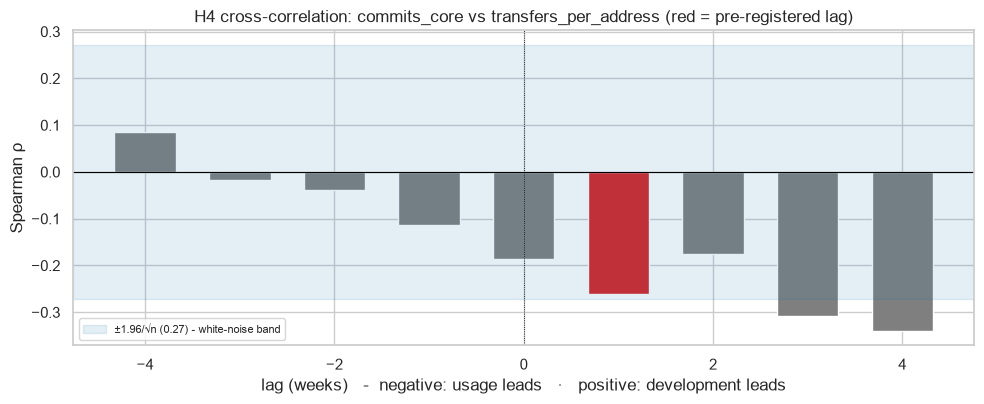

In [77]:
# Weekly aggregation: sums for counts, means for levels. The resample label is the week
# ending, so a lag of +1 means "the following week".
_by_week = master.set_index("date").resample("W")
weekly = (
    _by_week
    .agg(commits=("commits", "sum"),
         commits_core=("commits_core", "sum"),
         contributors=("contributors", "mean"),
         tx_count=("tx_count", "mean"),
         transfer_count=("transfer_count", "mean"),
         active_addresses=("active_addresses", "mean"),
         transfers_per_address=("transfers_per_address", "mean"),
         volatility_7d=("volatility_7d", "mean"))
    .dropna(subset=["tx_count"])
)

# A resample label is a week ENDING, so the last bin runs past the study window and holds
# whatever days fall inside it - here a single Monday. A non-null weekly mean says nothing
# about how many days produced it, so the count is carried explicitly and the incomplete
# bins are dropped rather than averaged as though they were weeks.
weekly = weekly.join(_by_week.size().rename("days_observed"))
_partial = weekly[weekly["days_observed"] != 7]
weekly = weekly[weekly["days_observed"] == 7]
print(f"{len(weekly)} complete 7-day weeks from {weekly.index.min().date()} "
      f"to {weekly.index.max().date()}")
if len(_partial):
    print(f"{len(_partial)} partial week(s) dropped: "
          + ", ".join(f"{d.date()} ({int(n)}d)"
                      for d, n in _partial["days_observed"].items()))
print()


def lead_lag(driver: pd.Series, response: pd.Series, lag: int) -> tuple[float, float, int]:
    """
    Spearman correlation of driver(t) against response(t + lag).

    A positive lag asks whether the driver LEADS the response. Both series are trimmed to
    the overlapping support so the pairing is explicit rather than left to index
    alignment, which would silently drop or misalign edges.
    """
    if lag > 0:
        a, b = driver.iloc[:-lag], response.iloc[lag:]
    elif lag < 0:
        a, b = driver.iloc[-lag:], response.iloc[:lag]
    else:
        a, b = driver, response
    pair = pd.DataFrame({"a": a.to_numpy(), "b": b.to_numpy()}).dropna()
    if len(pair) < 10:
        return float("nan"), float("nan"), len(pair)
    rho, p = stats.spearmanr(pair["a"], pair["b"])
    return rho, p, len(pair)


H4_DRIVER = "commits_core"        # the protocol implementation itself
H4_RESPONSE = "transfers_per_address"   # transaction velocity per active participant
PREREGISTERED_LAG = 1

rows = []
for lag in range(-4, 5):
    rho, p, n = lead_lag(weekly[H4_DRIVER], weekly[H4_RESPONSE], lag)
    rows.append({
        "lag_weeks": lag,
        "direction": "development leads" if lag > 0
                     else ("usage leads" if lag < 0 else "contemporaneous"),
        "n": n, "spearman_rho": round(rho, 3), "p_raw": round(p, 4),
        "role": "PRE-REGISTERED" if lag == PREREGISTERED_LAG else "exploratory",
    })
h4_lags = pd.DataFrame(rows)
display(h4_lags)

# The pre-registered test is the one that enters the confirmatory family. Registering the
# whole grid would let a nine-lag scan borrow the credibility of a single hypothesis.
primary_rho, primary_p, primary_n = lead_lag(
    weekly[H4_DRIVER], weekly[H4_RESPONSE], PREREGISTERED_LAG
)
# primary="spearman" because §1.3 declares Spearman rho for H4. The Pearson figure stays
# in the row for comparison, but it is rho that is registered and rho that BH corrects.
h4_primary = report_correlation(
    weekly[H4_DRIVER].iloc[:-PREREGISTERED_LAG].reset_index(drop=True),
    weekly[H4_RESPONSE].iloc[PREREGISTERED_LAG:].reset_index(drop=True),
    f"Core-ledger commits(t) -> transfers per address(t+{PREREGISTERED_LAG}w)  [H4 PRIMARY]",
    family="confirmatory", bootstrap=True, primary="spearman",
)
h4_results = pd.DataFrame([h4_primary])
display(h4_results[["test", "n", "effect", "estimate", "ci_low", "ci_high", "p_raw",
                    "pearson_r", "pearson_p", "n_eff"]].round(4))

best = h4_lags.loc[h4_lags["p_raw"].idxmin()]
print(f"Pre-registered lag (+{PREREGISTERED_LAG}w): rho = {primary_rho:+.3f}, "
      f"p = {primary_p:.4f}, n = {primary_n} weeks")
print(f"Smallest |rho| detectable at n={primary_n}: {min_detectable_r(primary_n):.2f}")
print(f"\nStrongest lag anywhere in the grid: {int(best['lag_weeks']):+d} weeks "
      f"(rho = {best['spearman_rho']:+.3f}, raw p = {best['p_raw']:.4f})")

# Benjamini-Hochberg across the exploratory grid, so the best-looking lag is judged
# against the number of lags that were looked at.
grid = h4_lags.dropna(subset=["p_raw"]).sort_values("p_raw").reset_index(drop=True)
m = len(grid)
grid["p_adj"] = [
    min(1.0, min(grid["p_raw"].iloc[j] * m / (j + 1) for j in range(k, m)))
    for k in range(m)
]
survivors = grid[grid["p_adj"] < 0.05]
print(f"After BH correction across all {m} lags: "
      f"{len(survivors)} survive at alpha = 0.05")
if len(survivors):
    display(survivors[["lag_weeks", "direction", "spearman_rho", "p_raw", "p_adj"]])

fig, ax = plt.subplots(figsize=(10, 4.2))
colours = ["tab:grey" if r != "PRE-REGISTERED" else "tab:red" for r in h4_lags["role"]]
ax.bar(h4_lags["lag_weeks"], h4_lags["spearman_rho"], color=colours, width=0.65)
band = 1.96 / np.sqrt(len(weekly))
ax.axhspan(-band, band, color="tab:blue", alpha=0.12,
           label=f"±1.96/√n ({band:.2f}) - white-noise band")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.6, ls=":")
ax.set_xlabel("lag (weeks)   -  negative: usage leads   ·   positive: development leads")
ax.set_ylabel("Spearman ρ")
ax.set_title(f"H4 cross-correlation: {H4_DRIVER} vs {H4_RESPONSE} "
             f"(red = pre-registered lag)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3.6 Lead and lag: cross-correlation, done properly

H1 tested one horizon — sentiment against volatility over the following three days. That is
a single slice through a question with a shape: *at what lag, if any, do these series move
together?* A cross-correlation function answers it across a range of lags at once.

It is also one of the easiest things in time-series analysis to get wrong, and the failure
is demonstrated below rather than described. Both series here are persistent: yesterday's
volatility predicts today's. When two autocorrelated series are cross-correlated directly,
the result is contaminated by each series' correlation **with its own past**, and spurious
peaks appear at lags where nothing is happening.

The standard remedy is **pre-whitening**. An autoregressive model is fitted to the *input*
series, and the **same filter** is applied to both series before correlating. What survives
is the relationship between the innovations — the genuinely new information in each series
— rather than between their shared inertia.

Four properties make this defensible rather than mechanical, and each is checked in code:

1. The **series** are stationary — §3.6.1 tests this directly rather than inferring it.
2. The AR order **starts** from AIC and is escalated until the filter actually works.
   Parsimony is not the objective here; whiteness is. An AIC-optimal model that leaves
   structure in its residuals is not fit for the one purpose it is being used for, and the
   selected order is reported alongside the order AIC preferred so the gap is visible.
3. The fitted **model** is stationary — all characteristic roots inside the unit circle.
4. The filter actually worked: a **Ljung–Box** test on the filtered input should fail to
   reject whiteness, where the raw series rejects it decisively. That residual test is
   charged the fitted order as degrees of freedom, because a model with *p* estimated
   coefficients removes *p* lags' worth of autocorrelation by construction. Scoring it
   against the full lag count would credit the filter for work it did not do — and would
   pass a filter that had not whitened the series.

Properties 1 and 3 are easy to confuse and are not the same claim. Root inspection asks
whether the model *this notebook fitted* is stable; a unit-root test asks whether the
*series* has a stochastic trend at all. A model can be fitted, and its roots can sit inside
the unit circle, on data for which the whole exercise was invalid to begin with.

Everything is implemented here with `numpy` and `scipy`, consistent with the rest of this
notebook's statistics — the Newey–West estimator, the block bootstrap, Hedges' *g* and the
principal component in §3.9 are all hand-rolled for the same reason. `statsmodels` would
supply `ccf`, `adfuller` and `grangercausalitytests` in three lines, but it is a
15 MB dependency for procedures whose intermediate quantities — the AR coefficients, the
whitened residuals, the nested residual sums of squares — are precisely what has to be
inspected to know the method is behaving.

In [78]:
def fit_ar(series: ArrayLike, max_order: int = 10,
           whiten_alpha: float = 0.05) -> dict:
    """
    Fit an AR(p) model by OLS, choosing p by AIC and escalating if that leaves structure.

    AIC selects a parsimonious order, but parsimony is not the requirement here: the
    filter's only job is to leave white residuals, and an AIC-optimal model can still fail
    a Ljung-Box test. The order is therefore the smallest one that BOTH is considered by
    AIC and actually whitens the series; if none does, the best available is returned with
    `whitened=False` so the caller can refuse to proceed rather than quietly
    cross-correlating structured noise.

    Returns order, coefficients, intercept, residuals, stationarity and how p was chosen.
    OLS on lagged columns rather than closed-form Yule-Walker: equivalent here, and it
    keeps the design matrix visible.
    """
    x = np.asarray(series, dtype=float)
    candidates = {}
    best = None
    for p in range(1, max_order + 1):
        n = len(x) - p
        if n < 3 * p + 10:                     # refuse to fit a model the data cannot support
            break
        design = np.column_stack(
            [np.ones(n)] + [x[p - k - 1: len(x) - k - 1] for k in range(p)]
        )
        target = x[p:]
        beta, *_ = np.linalg.lstsq(design, target, rcond=None)
        resid = target - design @ beta
        aic = n * np.log(resid @ resid / n) + 2 * (p + 1)
        candidates[p] = {"aic": aic, "order": p, "coeffs": beta[1:],
                         "intercept": beta[0], "resid": resid}
        if best is None or aic < best["aic"]:
            best = candidates[p]
    # Does the AIC choice actually whiten? If not, escalate to the smallest order that does.
    def whitens(candidate: dict) -> bool:
        """
        True if this fit leaves residuals a Ljung-Box test calls white noise.

        The candidate's own order is charged to the test as model degrees of freedom: these
        are residuals of a model with `order` estimated coefficients, not an observed
        series, and a whiteness test that ignores that will pass filters that have not
        whitened anything.
        """
        filtered = ar_filter(x, candidate["coeffs"], candidate["intercept"])
        return ljung_box(filtered, model_df=candidate["order"])[1] >= whiten_alpha

    chosen, rule = best, "AIC"
    if not whitens(best):
        for p in sorted(candidates):
            if p > best["order"] and whitens(candidates[p]):
                chosen, rule = candidates[p], f"AIC chose {best['order']}, escalated to {p} for whiteness"
                break
        else:
            rule = f"AIC chose {best['order']}; no order up to {max_order} whitened the series"

    roots = np.roots(np.r_[1.0, -chosen["coeffs"]])
    chosen["roots"] = np.abs(roots)
    chosen["stationary"] = bool(np.all(np.abs(roots) < 1))
    chosen["selected_by"] = rule
    chosen["whitened"] = whitens(chosen)
    return chosen


# Diagnostic lag count for every Ljung-Box test in this section. It is deliberately larger
# than fit_ar's max_order: the residual test below spends one degree of freedom per fitted
# AR coefficient, so a lag count at or under the fitted order would leave nothing to test
# against. Fixed rather than varied per candidate, so that competing orders are judged by
# the same diagnostic.
DIAGNOSTIC_LAGS = 15


def ljung_box(series: ArrayLike, lags: int = DIAGNOSTIC_LAGS,
              model_df: int = 0) -> tuple[float, float]:
    """
    Ljung-Box Q and its chi-square p-value. H0: the series is white noise.

    Used twice below - on the raw input (expected to reject) and on the filtered input
    (expected not to), which is what demonstrates that pre-whitening did its job.

    `model_df` is the number of parameters estimated to PRODUCE the series being tested,
    and must be set whenever that series is a residual. Fitting an AR(p) removes p degrees
    of freedom worth of autocorrelation by construction, so testing its residuals against
    chi-square with the full lag count compares them to a distribution that assumes nothing
    was fitted. That test is anti-conservative in exactly the direction that matters here:
    it makes a filter look as though it whitened a series when it did not. Raw series keep
    the default of 0, because nothing was estimated from them.
    """
    r = np.asarray(series, dtype=float)
    r = r[~np.isnan(r)]
    r = r - r.mean()
    n = len(r)
    denom = r @ r
    q = sum((r[k:] @ r[:-k] / denom) ** 2 / (n - k) for k in range(1, lags + 1))
    q *= n * (n + 2)
    dof = lags - model_df
    if dof < 1:
        raise ValueError(
            f"Ljung-Box needs more lags than fitted parameters: {lags} lags, {model_df} "
            f"model df. Raise DIAGNOSTIC_LAGS above the largest order considered."
        )
    return float(q), float(1 - stats.chi2.cdf(q, dof))


def ar_filter(series: ArrayLike, coeffs: np.ndarray,
              intercept: float) -> np.ndarray:
    """Apply a fitted AR filter, returning the innovations with NaN for the warm-up."""
    x = np.asarray(series, dtype=float)
    p = len(coeffs)
    out = np.full(len(x), np.nan)
    for t in range(p, len(x)):
        out[t] = x[t] - intercept - float(
            sum(coeffs[k] * x[t - k - 1] for k in range(p))
        )
    return out


def cross_correlation(x: ArrayLike, y: ArrayLike,
                      max_lag: int = 14) -> pd.DataFrame:
    """
    Correlation of x(t) against y(t+lag). A POSITIVE lag means x leads y.

    Pairs are trimmed explicitly at each lag rather than relying on index alignment, so
    the sample behind every point is known and reported.
    """
    x, y = np.asarray(x, float), np.asarray(y, float)
    rows = []
    for lag in range(-max_lag, max_lag + 1):
        a, b = (x[:-lag], y[lag:]) if lag > 0 else (
            (x[-lag:], y[:lag]) if lag < 0 else (x, y))
        ok = ~(np.isnan(a) | np.isnan(b))
        if ok.sum() < 20:
            rows.append({"lag": lag, "r": np.nan, "n": int(ok.sum())})
            continue
        r, p = stats.pearsonr(a[ok], b[ok])
        rows.append({"lag": lag, "r": r, "p_raw": p, "n": int(ok.sum())})
    return pd.DataFrame(rows)


def granger_f(cause: ArrayLike, effect: ArrayLike, lags: int = 5) -> dict:
    """
    Granger test as a nested-model F-test.

    Regress `effect` on its own past, then on its own past PLUS the past of `cause`. If
    the second model does not reduce the residual sum of squares more than chance allows,
    `cause` carries no information about `effect` beyond what `effect` already carried.
    """
    c, e = np.asarray(cause, float), np.asarray(effect, float)
    ok = ~(np.isnan(c) | np.isnan(e))
    c, e = c[ok], e[ok]
    n = len(e) - lags
    target = e[lags:]
    own = np.column_stack(
        [np.ones(n)] + [e[lags - k - 1: len(e) - k - 1] for k in range(lags)])
    added = np.column_stack([c[lags - k - 1: len(c) - k - 1] for k in range(lags)])
    full = np.column_stack([own, added])

    def rss(design: np.ndarray) -> float:
        """Residual sum of squares from an OLS fit of `target` on `design`."""
        beta, *_ = np.linalg.lstsq(design, target, rcond=None)
        resid = target - design @ beta
        return float(resid @ resid)

    restricted, unrestricted = rss(own), rss(full)
    df1, df2 = lags, n - full.shape[1]
    f_stat = ((restricted - unrestricted) / df1) / (unrestricted / df2)
    return {"F": f_stat, "p": float(1 - stats.f.cdf(f_stat, df1, df2)),
            "n": n, "lags": lags}

### 3.6.1 Stationarity, tested rather than assumed

Granger's own warning (Granger and Newbold, 1974) is that a regression between two
integrated series produces significant-looking coefficients between variables that have
nothing to do with each other. Both the cross-correlation below and the Granger tests
inherit that exposure, so stationarity has to be established before either is read — and
"established" means tested, not asserted from the fact that an AR fit converged.

Two tests are used, and using two is the point, because their null hypotheses are
**opposites**:

| Test | H₀ | Rejecting means |
| --- | --- | --- |
| **Augmented Dickey–Fuller** | the series has a unit root | evidence *for* stationarity |
| **KPSS** | the series is level-stationary | evidence *against* stationarity |

A single test cannot distinguish "stationary" from "not enough data to tell". Two tests with
opposed nulls can, and they produce four outcomes rather than two: both agreeing in either
direction, or **disagreeing** — which is not a malfunction but a diagnosis, and is what
happens below.

Neither statistic has a standard distribution, so neither can be read off a *t* or χ² table.
The conventional route is a published table of critical values. This notebook simulates the
null instead — generating random walks for ADF and white noise for KPSS, at the actual
sample size, and taking the empirical quantiles. That needs no vendored table, adapts to
*n* rather than assuming the asymptotic case, and produces a *p*-value rather than a
bracketed range. Its correctness is checkable, which is the real argument: the simulated
critical values are printed against the published asymptotic ones below, and if the
machinery were wrong they would not agree.

In [79]:
def adf_statistic(series: ArrayLike, lags: int = 1) -> float:
    """
    Augmented Dickey-Fuller t-statistic on gamma, with a constant and no trend.

        dy_t = a + gamma * y_{t-1} + sum_i delta_i * dy_{t-i} + e_t

    Under a unit root gamma is zero. The statistic is the ordinary t-ratio on gamma, but
    its distribution is NOT Student's t - which is exactly why the critical values below
    are simulated rather than looked up.
    """
    y = np.asarray(series, float)
    y = y[~np.isnan(y)]
    dy = np.diff(y)
    n = len(dy) - lags
    columns = [np.ones(n), y[lags:len(y) - 1]]
    for i in range(1, lags + 1):
        columns.append(dy[lags - i: len(dy) - i])
    design = np.column_stack(columns)
    target = dy[lags:]
    beta, *_ = np.linalg.lstsq(design, target, rcond=None)
    resid = target - design @ beta
    sigma2 = resid @ resid / (n - design.shape[1])
    standard_error = np.sqrt(sigma2 * np.linalg.inv(design.T @ design)[1, 1])
    return float(beta[1] / standard_error)


def kpss_statistic(series: ArrayLike, lags: int | None = None) -> float:
    """
    KPSS level-stationarity statistic: scaled partial sums of the demeaned series.

    Under stationarity the partial sums stay bounded; under a unit root they wander, and
    the statistic grows. The denominator is a Bartlett-weighted long-run variance, the
    same HAC estimator `newey_west_slope` uses, because the numerator is autocorrelated
    by construction.
    """
    y = np.asarray(series, float)
    y = y[~np.isnan(y)]
    n = len(y)
    resid = y - y.mean()
    if lags is None:
        lags = int(np.floor(4 * (n / 100) ** 0.25))
    partial_sums = np.cumsum(resid)
    long_run = resid @ resid / n
    for k in range(1, lags + 1):
        weight = 1 - k / (lags + 1)
        long_run += 2 * weight * (resid[k:] @ resid[:-k]) / n
    return float((partial_sums @ partial_sums) / (n ** 2 * long_run))


def simulate_null(statistic: Callable[[np.ndarray], float], n: int, *,
                  random_walk: bool, draws: int | None = None) -> np.ndarray:
    """Empirical null distribution of `statistic` at sample size `n`."""
    draws = draws or CONFIG["bootstrap_iterations"]
    out = np.empty(draws)
    for i in range(draws):
        noise = RNG.normal(size=n)
        out[i] = statistic(np.cumsum(noise) if random_walk else noise)
    return out


granger_pairs = master.set_index("date")[["sentiment_mean", "parkinson_daily"]].dropna()
N_STATIONARITY = len(granger_pairs)
adf_null = simulate_null(lambda y: adf_statistic(y, 1), N_STATIONARITY, random_walk=True)
kpss_null = simulate_null(kpss_statistic, N_STATIONARITY, random_walk=False)

# Validation: the simulated distribution must reproduce the published asymptotic values.
calibration = pd.DataFrame([
    {"test": "ADF", "quantile": f"{q:.0%}", "simulated": round(float(np.quantile(adf_null, q)), 3),
     "published (asymptotic)": pub}
    for q, pub in [(0.01, -3.44), (0.05, -2.87), (0.10, -2.57)]
] + [
    {"test": "KPSS", "quantile": f"{q:.0%}", "simulated": round(float(np.quantile(kpss_null, q)), 3),
     "published (asymptotic)": pub}
    for q, pub in [(0.90, 0.347), (0.95, 0.463), (0.99, 0.739)]
])
display(calibration)
print(f"Null distributions simulated at n = {N_STATIONARITY}, "
      f"{CONFIG['bootstrap_iterations']:,} draws each.\n")


def stationarity_report(series: ArrayLike, label: str) -> dict:
    """Both tests on one series, with p-values read off the simulated nulls."""
    values = pd.Series(series).dropna()
    adf = adf_statistic(values, 1)
    kpss = kpss_statistic(values)
    p_adf = float((adf_null <= adf).mean())          # one-sided: large negative rejects
    p_kpss = float((kpss_null >= kpss).mean())       # one-sided: large positive rejects
    if p_adf < 0.05 and p_kpss >= 0.05:
        verdict = "stationary (both agree)"
    elif p_adf >= 0.05 and p_kpss < 0.05:
        verdict = "UNIT ROOT (both agree)"
    elif p_adf < 0.05 and p_kpss < 0.05:
        verdict = "tests DISAGREE - neither I(0) nor I(1)"
    else:
        verdict = "inconclusive - neither test rejects"
    return {"series": label, "n": len(values), "ADF t": round(adf, 2),
            "ADF p": round(p_adf, 3), "KPSS": round(kpss, 3), "KPSS p": round(p_kpss, 3),
            "verdict": verdict}


stationarity = pd.DataFrame([
    # A positive control first: a log price series MUST show a unit root, or the test is wrong.
    stationarity_report(np.log(master.set_index("date")["price"]),
                        "CONTROL: log price (must show a unit root)"),
    stationarity_report(granger_pairs["sentiment_mean"], "sentiment_mean"),
    stationarity_report(granger_pairs["parkinson_daily"], "parkinson_daily"),
    stationarity_report(master.set_index("date")["daily_return"], "daily_return"),
    stationarity_report(np.log(master.set_index("date")["active_addresses"]),
                        "log active addresses  [H3]"),
    stationarity_report(granger_pairs["parkinson_daily"].diff(),
                        "d(parkinson_daily)  [differenced]"),
])
display(stationarity)

control = stationarity.iloc[0]
assert control["ADF p"] >= 0.05 and control["KPSS p"] < 0.05, \
    "the unit-root control failed: log price should be non-stationary on both tests"
print("The control behaves: log price carries a unit root on both tests, which is what a")
print("price series should do and what the machinery has to reproduce before anything else")
print("it says can be believed.\n")

disagree = stationarity[stationarity["verdict"].str.startswith("tests DISAGREE")]
print(f"{len(disagree)} of the {len(stationarity) - 1} real series make the two tests disagree: "
      f"{', '.join(disagree['series'])}.")
print("ADF rejects a unit root and KPSS rejects stationarity, which sounds contradictory and")
print("is not. The two tests ask different questions with different nulls, and a series can")
print("fail to look like a random walk while also failing to look short-memory stationary.")
print("Long memory - persistence decaying too slowly for stationarity without being a")
print("stochastic trend - is ONE well-documented explanation, and a plausible one for")
print("realised volatility. It is not the only one: a structural break, a slowly varying")
print("mean, or simply low power at this sample size produce the same disagreement. This")
print("notebook runs no long-memory estimator, so it reports the integration order as")
print("UNRESOLVED rather than diagnosing the cause. Naming a mechanism the tests cannot")
print("distinguish would be a stronger claim than the evidence carries.\n")
print("The consequence is stated rather than waved away: the Granger tests in §3.6.3 are run")
print("on series whose integration order is ambiguous, so the section below re-runs them")
print("under transformations that are unambiguously stationary and reports whether the")
print("answer moves.")

log_row("stationarity", "ADF and KPSS on every series entering a lag test",
        int(len(disagree)), "reported - robustness re-run in §3.6.3",
        f"simulated nulls at n={N_STATIONARITY} reproduce published critical values "
        f"(ADF 5%: {np.quantile(adf_null, 0.05):.2f} vs -2.87; "
        f"KPSS 95%: {np.quantile(kpss_null, 0.95):.2f} vs 0.463); "
        f"{len(disagree)} series have an unresolved integration order")

,test,quantile,simulated,published (asymptotic)
0,ADF,1%,-3.408,-3.440
1,ADF,5%,-2.859,-2.870
2,ADF,10%,-2.546,-2.570
3,KPSS,90%,0.351,0.347
4,KPSS,95%,0.464,0.463
5,KPSS,99%,0.710,0.739


Null distributions simulated at n = 358, 5,000 draws each.



,series,n,ADF t,ADF p,KPSS,KPSS p,verdict
0,CONTROL: log price (must show a unit root),365,-1.68,0.438,5.602,0.000,UNIT ROOT (both agree)
1,sentiment_mean,358,-11.71,0.000,1.259,0.000,tests DISAGREE - neither I(0) nor I(1)
2,parkinson_daily,358,-10.10,0.000,0.507,0.036,tests DISAGREE - neither I(0) nor I(1)
3,daily_return,364,-13.64,0.000,0.122,0.512,stationary (both agree)
4,log active addresses [H3],365,-5.09,0.000,0.188,0.303,stationary (both agree)
5,d(parkinson_daily) [differenced],357,-20.06,0.000,0.009,1.000,stationary (both agree)


The control behaves: log price carries a unit root on both tests, which is what a
price series should do and what the machinery has to reproduce before anything else
it says can be believed.

2 of the 5 real series make the two tests disagree: sentiment_mean, parkinson_daily.
ADF rejects a unit root and KPSS rejects stationarity, which sounds contradictory and
is not. The two tests ask different questions with different nulls, and a series can
fail to look like a random walk while also failing to look short-memory stationary.
Long memory - persistence decaying too slowly for stationarity without being a
stochastic trend - is ONE well-documented explanation, and a plausible one for
realised volatility. It is not the only one: a structural break, a slowly varying
mean, or simply low power at this sample size produce the same disagreement. This
notebook runs no long-memory estimator, so it reports the integration order as
UNRESOLVED rather than diagnosing the cause. Naming a mechanism the

{'stream': 'stationarity',
 'check': 'ADF and KPSS on every series entering a lag test',
 'n_failed': 2,
 'status': 'WARN',
 'action': 'reported - robustness re-run in §3.6.3',
 'detail': 'simulated nulls at n=358 reproduce published critical values (ADF 5%: -2.86 vs -2.87; KPSS 95%: 0.46 vs 0.463); 2 series have an unresolved integration order'}

### 3.6.2 Why the raw cross-correlation cannot be read

Before applying the method to H1, it is worth establishing that the correction matters —
on a case where the answer is already known.

§3.4 found a contemporaneous association between active addresses and volatility
(*r* = +0.281). A cross-correlation of those two series should therefore show something
near lag 0 and little elsewhere. What the raw CCF actually produces is below.

In [80]:
known = master.set_index("date")[["active_addresses", "parkinson_daily",
                                  "volatility_7d"]].dropna()
addresses = np.log(known["active_addresses"].to_numpy())
ar_addresses = fit_ar(addresses)
whitened_input = ar_filter(addresses, ar_addresses["coeffs"], ar_addresses["intercept"])

MAX_LAG = 14
n_pairs = len(known)
band = 1.96 / np.sqrt(n_pairs)

rows = []
for target, label in [("parkinson_daily", "Parkinson volatility (daily)"),
                      ("volatility_7d", "rolling 7-day volatility")]:
    series = known[target].to_numpy()
    filtered = ar_filter(series, ar_addresses["coeffs"], ar_addresses["intercept"])
    for kind, a, b in [("raw", addresses, series),
                       ("pre-whitened", whitened_input, filtered)]:
        table = cross_correlation(a, b, MAX_LAG)
        exceed = table[table["r"].abs() > band]
        peak = table.loc[table["r"].abs().idxmax()]
        rows.append({
            "target": label, "series": kind,
            "lags past the 95% band": f"{len(exceed)} of {len(table)}",
            "peak lag": int(peak["lag"]), "peak r": round(peak["r"], 3),
        })
display(pd.DataFrame(rows))

print(f"95% band for white noise at n = {n_pairs}: ±{band:.3f}\n")
print("The raw rows are the point. Two persistent series exceed the band at almost every")
print("lag tested, because each is correlated with its own past and the CCF cannot tell")
print("that apart from a relationship between them. A reader handed the raw function")
print("would find a 'significant' peak three to five days from zero and could tell a")
print("plausible story about it. It is an artefact of the autocorrelation.")
print("\nAfter pre-whitening the count collapses to a handful - close to the ~1.5 that")
print("29 independent tests at alpha = 0.05 produce by chance alone.")

,target,series,lags past the 95% band,peak lag,peak r
0,Parkinson volatility (daily),raw,23 of 29,-4,0.275
1,Parkinson volatility (daily),pre-whitened,1 of 29,0,0.105
2,rolling 7-day volatility,raw,23 of 29,-3,0.365
3,rolling 7-day volatility,pre-whitened,4 of 29,11,0.153


95% band for white noise at n = 358: ±0.104

The raw rows are the point. Two persistent series exceed the band at almost every
lag tested, because each is correlated with its own past and the CCF cannot tell
that apart from a relationship between them. A reader handed the raw function
would find a 'significant' peak three to five days from zero and could tell a
plausible story about it. It is an artefact of the autocorrelation.

After pre-whitening the count collapses to a handful - close to the ~1.5 that
29 independent tests at alpha = 0.05 produce by chance alone.


### 3.6.3 H1 across the full lag range

With the method established, the same treatment is applied to the H1 question: does daily
sentiment lead volatility at *any* horizon within a fortnight, rather than only at the
three-day window H1 pre-registered?

The lag grid is one family of 29 tests and is corrected as one. Scanning a grid and
reporting its maximum is how a null becomes a finding by accident — the same discipline
applied to H4's lag grid in §3.5.

Input series (sentiment): AR(8), phi_1 = +0.130   [AIC chose 1, escalated to 8 for whiteness]
  stationary (all roots inside the unit circle): True — |roots| = [0.781 0.816 0.816 0.788 0.788 0.83  0.731 0.731]
  Ljung-Box on the RAW series:      Q =   44.0, p = 0.0001  -> not white noise
  Ljung-Box on the FILTERED series: Q =    9.2, p = 0.2418  -> white noise, as required

Pre-whitened CCF, lags -14 to +14 (29 tests):
  lags exceeding the ±0.105 band : none
  expected past the band by chance    : 1.5
  surviving BH correction             : none

  strongest lag anywhere: +0 days (r = -0.085, raw p = 0.111, BH p = 0.935)

Granger causality (5 lags), both directions:
  sentiment -> volatility    F = 0.143, p = 0.9819
  volatility -> sentiment    F = 0.344, p = 0.8860


,direction,F,p,n
0,sentiment -> volatility,0.143,0.9819,353
1,volatility -> sentiment,0.344,0.8860,353


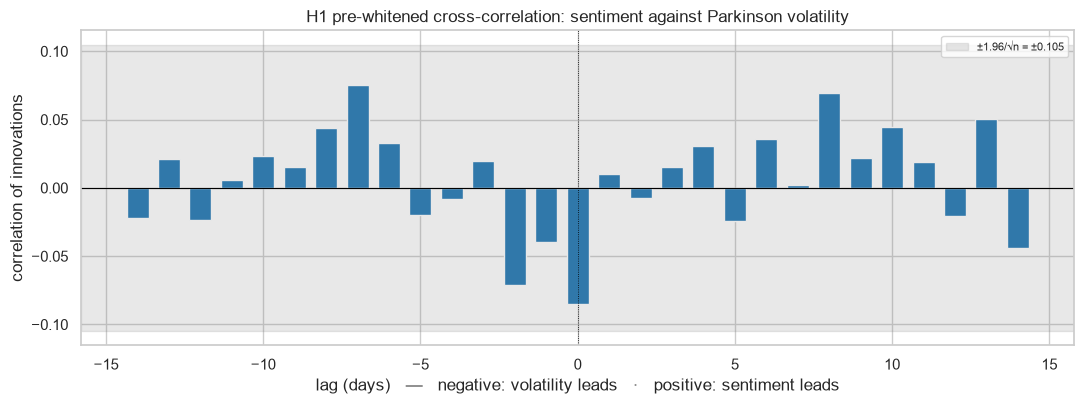

In [81]:
paired = master.set_index("date")[["sentiment_mean", "parkinson_daily"]].dropna()
sentiment = paired["sentiment_mean"].to_numpy()
volatility = paired["parkinson_daily"].to_numpy()

# (1) Both series are autocorrelated; establish it rather than assuming it.
ar_sentiment = fit_ar(sentiment)
q_raw, p_raw_lb = ljung_box(sentiment)
print(f"Input series (sentiment): AR({ar_sentiment['order']}), "
      f"phi_1 = {ar_sentiment['coeffs'][0]:+.3f}   [{ar_sentiment['selected_by']}]")
print(f"  stationary (all roots inside the unit circle): {ar_sentiment['stationary']} "
      f"— |roots| = {np.round(ar_sentiment['roots'], 3)}")
print(f"  Ljung-Box on the RAW series:      Q = {q_raw:6.1f}, p = {p_raw_lb:.4f}"
      f"  {'-> not white noise' if p_raw_lb < 0.05 else ''}")

# (2) Filter BOTH series with the model fitted to the input.
sent_w = ar_filter(sentiment, ar_sentiment["coeffs"], ar_sentiment["intercept"])
vol_w = ar_filter(volatility, ar_sentiment["coeffs"], ar_sentiment["intercept"])
q_white, p_white = ljung_box(sent_w, model_df=ar_sentiment["order"])
print(f"  Ljung-Box on the FILTERED series: Q = {q_white:6.1f}, p = {p_white:.4f}"
      f"  {'-> white noise, as required' if p_white >= 0.05 else '-> STILL not white'}")
assert ar_sentiment["whitened"], (
    "pre-whitening failed: no AR order up to 10 left white residuals, so a "
    "cross-correlation of these series would not be interpretable"
)

# (3) Cross-correlate, and correct across the whole grid.
ccf_table = cross_correlation(sent_w, vol_w, MAX_LAG).dropna(subset=["r"])
m_lags = len(ccf_table)
ordered = ccf_table.sort_values("p_raw").reset_index(drop=True)
ordered["p_adj"] = [
    min(1.0, min(ordered["p_raw"].iloc[j] * m_lags / (j + 1) for j in range(k, m_lags)))
    for k in range(m_lags)
]
ccf_table = ordered.sort_values("lag")

band_h1 = 1.96 / np.sqrt(ccf_table["n"].max())
past_band = ccf_table[ccf_table["r"].abs() > band_h1]
survivors = ccf_table[ccf_table["p_adj"] < 0.05]

print(f"\nPre-whitened CCF, lags -{MAX_LAG} to +{MAX_LAG} ({m_lags} tests):")
print(f"  lags exceeding the ±{band_h1:.3f} band : "
      f"{past_band['lag'].tolist() if len(past_band) else 'none'}")
print(f"  expected past the band by chance    : {0.05 * m_lags:.1f}")
print(f"  surviving BH correction             : "
      f"{survivors['lag'].tolist() if len(survivors) else 'none'}")

strongest = ccf_table.loc[ccf_table["r"].abs().idxmax()]
print(f"\n  strongest lag anywhere: {int(strongest['lag']):+d} days "
      f"(r = {strongest['r']:+.3f}, raw p = {strongest['p_raw']:.3f}, "
      f"BH p = {strongest['p_adj']:.3f})")

# (4) Granger, both directions - reverse causality is the obvious objection to H1.
print("\nGranger causality (5 lags), both directions:")
granger_rows = []
for cause, effect, label in [(sentiment, volatility, "sentiment -> volatility"),
                             (volatility, sentiment, "volatility -> sentiment")]:
    g = granger_f(cause, effect, lags=5)
    granger_rows.append({"direction": label, "F": round(g["F"], 3),
                         "p": round(g["p"], 4), "n": g["n"]})
    print(f"  {label:26} F = {g['F']:.3f}, p = {g['p']:.4f}")
display(pd.DataFrame(granger_rows))

report_correlation(
    pd.Series(sent_w).dropna().reset_index(drop=True),
    pd.Series(vol_w).dropna().reset_index(drop=True),
    "Pre-whitened sentiment vs volatility, lag 0  [CCF]", family="exploratory",
)
log_row("cross_correlation", "pre-whitened CCF, H1 across ±14 days",
        len(survivors), "no lag survives BH correction" if not len(survivors)
        else "see §3.6.3",
        f"{len(past_band)} of {m_lags} lags past the band ({0.05*m_lags:.1f} expected by "
        f"chance); strongest {int(strongest['lag']):+d}d r={strongest['r']:+.3f}")

fig, ax = plt.subplots(figsize=(11, 4.2))
colours = ["tab:red" if abs(r) > band_h1 else "tab:blue" for r in ccf_table["r"]]
ax.bar(ccf_table["lag"], ccf_table["r"], color=colours, width=0.7)
ax.axhspan(-band_h1, band_h1, color="grey", alpha=0.18,
           label=f"±1.96/√n = ±{band_h1:.3f}")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.6, ls=":")
ax.set_xlabel("lag (days)   —   negative: volatility leads   ·   positive: sentiment leads")
ax.set_ylabel("correlation of innovations")
ax.set_title("H1 pre-whitened cross-correlation: sentiment against Parkinson volatility")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

#### Does the Granger verdict depend on the integration order?

§3.6.1 left an ambiguity open: sentiment and Parkinson volatility are neither cleanly
*I*(0) nor *I*(1), so a Granger test on their levels rests on an assumption the data does
not cleanly satisfy. The way to settle that is not to argue about which test to believe but
to run the thing three ways and see whether the answer moves.

Levels are what §3.6.3 reports. Logs compress the right tail that makes volatility awkward.
First differences are unambiguously stationary on both tests — at the cost of discarding the
level information, which is why they are a robustness check rather than the primary
specification.

If the null holds under all three, the ambiguity is real but immaterial, and that is worth
more than picking whichever specification suited.

In [82]:
GRANGER_LAGS = 5
sentiment_levels = granger_pairs["sentiment_mean"]
volatility_levels = granger_pairs["parkinson_daily"]

SPECIFICATIONS = {
    "levels  [as reported in §3.6.3]": (sentiment_levels, volatility_levels),
    "log volatility": (sentiment_levels, np.log(volatility_levels)),
    "first differences  [stationary on both tests]":
        (sentiment_levels.diff(), volatility_levels.diff()),
}

robustness_rows = []
for label, (cause_series, effect_series) in SPECIFICATIONS.items():
    aligned = pd.concat([cause_series.rename("cause"),
                         pd.Series(effect_series, index=volatility_levels.index).rename("effect")],
                        axis=1).dropna()
    forward = granger_f(aligned["cause"], aligned["effect"], lags=GRANGER_LAGS)
    reverse = granger_f(aligned["effect"], aligned["cause"], lags=GRANGER_LAGS)
    robustness_rows.append({
        "specification": label, "n": len(aligned),
        "sentiment -> volatility F": round(forward["F"], 3),
        "p": round(forward["p"], 4),
        "volatility -> sentiment F": round(reverse["F"], 3),
        "p ": round(reverse["p"], 4),
    })

granger_robustness = pd.DataFrame(robustness_rows)
display(granger_robustness)

smallest = min(granger_robustness["p"].min(), granger_robustness["p "].min())
print(f"Six tests - three specifications by two directions - and the smallest p-value "
      f"anywhere is {smallest:.3f}.\n")
print("The integration order is genuinely ambiguous and it does not matter. Whether the")
print("series are read as levels, as logs, or as first differences, neither direction")
print("carries information about the other beyond what each already carries about itself.")
print("Reporting the levels result alone would have been defensible and would have left a")
print("reader unable to check whether the specification was doing the work.\n")
print("This is also the answer to the obvious objection to the whole research question.")
print("Reverse causality - volatility driving coverage rather than coverage driving")
print("volatility - is the alternative explanation a single-horizon correlation cannot")
print("address. Tested directly, in both directions, under three specifications, it is")
print("null as well.")

log_row("stationarity", "Granger re-run under stationary transformations", 0,
        "verdict unchanged - see §3.6.1",
        f"{len(granger_robustness) * 2} tests across levels, logs and first differences; "
        f"smallest p = {smallest:.3f}; the integration-order ambiguity does not change the "
        f"conclusion in either direction", status="INFO")

,specification,n,sentiment -> volatility F,p,volatility -> sentiment F,p
0,levels [as reported in §3.6.3],358,0.143,0.9819,0.344,0.8860
1,log volatility,358,0.811,0.5423,0.044,0.9988
2,first differences [stationary on both tests],357,0.119,0.9882,0.580,0.7150


Six tests - three specifications by two directions - and the smallest p-value anywhere is 0.542.

The integration order is genuinely ambiguous and it does not matter. Whether the
series are read as levels, as logs, or as first differences, neither direction
carries information about the other beyond what each already carries about itself.
Reporting the levels result alone would have been defensible and would have left a
reader unable to check whether the specification was doing the work.

This is also the answer to the obvious objection to the whole research question.
Reverse causality - volatility driving coverage rather than coverage driving
volatility - is the alternative explanation a single-horizon correlation cannot
address. Tested directly, in both directions, under three specifications, it is
null as well.


{'stream': 'stationarity',
 'check': 'Granger re-run under stationary transformations',
 'n_failed': 0,
 'status': 'INFO',
 'action': 'verdict unchanged - see §3.6.1',
 'detail': '6 tests across levels, logs and first differences; smallest p = 0.542; the integration-order ambiguity does not change the conclusion in either direction'}

### What the lag analysis adds

**H1 gains nothing from a wider horizon.** Testing 29 lags instead of one finds no
systematic relationship: the number of lags past the confidence band is what 29 independent
tests produce by chance, and none survives correction. H1's null was not an artefact of
choosing the wrong window.

**Granger runs both ways, and neither direction carries information.** Reverse causality —
volatility driving coverage rather than coverage driving volatility — is the obvious
objection to any sentiment study, and it is the one a single-horizon correlation cannot
address. Tested directly, neither direction improves on a series' own past.

**And the method sharpens what §3.4 can claim.** H3's association survives a bootstrap that
assumes serial dependence, so the relationship between the *levels* is real. But once each
series is stripped of its own dynamics, the association does not localise at any particular
lag — including zero. Both statements hold together: active addresses and volatility are
two slow-moving series that are high in the same periods, not two series where a movement
in one is followed by a movement in the other. That is a weaker and more precise claim than
"on-chain activity is associated with volatility", and it is the one the evidence supports.

## 3.7 The complete family of tests, and multiplicity

Twelve statistical tests appear above. Reporting only the ones that reached p < 0.05 would
be a form of selective reporting, and leaving them uncorrected would ignore that running
many tests inflates the chance of at least one false positive. Both problems are addressed
here: **every** test is listed, and the pre-registered confirmatory family is corrected with
the **Benjamini–Hochberg** procedure.

The correction is applied only to the three confirmatory tests — the single primary test of
each hypothesis, declared as such in the code *before* its result was known. Robustness
checks re-examine those same hypotheses with a different instrument, and diagnostics are not
hypothesis tests at all; treating either as an additional independent hypothesis would
over-correct and bury genuine findings. This distinction is a methodological choice, and it
is stated rather than buried.

In [83]:
family_table = summarise_test_family(TEST_FAMILY)

print(f"{len(family_table)} tests run in total: "
      + ", ".join(f"{n} {f}" for f, n in family_table['family'].value_counts().items()))
print("\nConfirmatory family (Benjamini-Hochberg corrected):")
display(
    family_table[family_table["family"] == "confirmatory"]
    [["test", "n", "effect", "estimate", "ci_low", "ci_high", "p_raw", "p_adj", "verdict"]]
    .round(4).reset_index(drop=True)
)
# The table above carries three different statements about uncertainty, and they are not
# interchangeable. Saying so here is the difference between reporting dependence-aware
# inference and appearing to.
print("""
How to read the uncertainty in this table - three quantities, three different claims:

  p_raw, ci_low, ci_high   Computed on the NOMINAL sample size, under the assumption that
                           observations are independent. For rolling-window series they are
                           not, so these are the OPTIMISTIC bounds: a true interval is wider
                           and a true p-value larger. They are reported because they are the
                           conventional quantities, not because the assumption holds.

  n_eff                    A diagnostic of how badly that assumption fails - the sample size
                           adjusted for serial correlation in both series. It is reported
                           BESIDE the p-value and does NOT enter it. Where n_eff is far
                           below n, read the p-value beside it as correspondingly weaker.

  boot_rho_ci              The only dependence-aware interval here, from a moving-block
                           bootstrap - and it is an interval for SPEARMAN rho, a different
                           estimand from the Pearson r in `estimate`. It is computed only
                           where bootstrap=True was requested, i.e. the primary tests.

  None of the three is a substitute for either of the others, and no row in this table is a
  Pearson p-value that has been corrected for serial dependence. No such p-value is computed
  in this notebook; §3.3's Newey-West slope is the one place a dependence-robust standard
  error is estimated, and that is a regression slope, not a correlation.
""")
print("Robustness, exploratory and diagnostic tests (uncorrected, reported in full):")
display(
    family_table[family_table["family"] != "confirmatory"]
    [["test", "family", "n", "effect", "estimate", "ci_low", "ci_high", "p_raw", "verdict"]]
    .round(4).reset_index(drop=True)
)

22 tests run in total: 12 robustness, 4 confirmatory, 2 diagnostic, 2 sensitivity, 2 exploratory

Confirmatory family (Benjamini-Hochberg corrected):


,test,n,effect,estimate,ci_low,ci_high,p_raw,p_adj,verdict
0,Sentiment(t) -> forward 3d realised vol(t+1..t...,355,Pearson r,-0.031,-0.135,0.073,0.5590,0.5590,not significant
1,Regulatory intensity(t) vs volume(t) [PRIMARY],358,Pearson r,-0.056,-0.158,0.048,0.2929,0.3905,not significant
2,Active addresses vs volatility [PRIMARY],358,Pearson r,0.281,0.182,0.373,0.0000,0.0000,significant (BH-adjusted)
3,Core-ledger commits(t) -> transfers per addres...,51,Spearman rho,-0.262,-0.514,0.031,0.0628,0.1256,not significant



How to read the uncertainty in this table - three quantities, three different claims:

  p_raw, ci_low, ci_high   Computed on the NOMINAL sample size, under the assumption that
                           observations are independent. For rolling-window series they are
                           not, so these are the OPTIMISTIC bounds: a true interval is wider
                           and a true p-value larger. They are reported because they are the
                           conventional quantities, not because the assumption holds.

  n_eff                    A diagnostic of how badly that assumption fails - the sample size
                           adjusted for serial correlation in both series. It is reported
                           BESIDE the p-value and does NOT enter it. Where n_eff is far
                           below n, read the p-value beside it as correspondingly weaker.

  boot_rho_ci              The only dependence-aware interval here, from a moving-block
       

,test,family,n,effect,estimate,ci_low,ci_high,p_raw,verdict
0,Rolling std of returns (7d) vs Parkinson high-...,diagnostic,358,Pearson r,0.791,0.749,0.827,0.0000,significant (uncorrected)
1,Daily |return| vs Parkinson daily,diagnostic,364,Pearson r,0.730,0.678,0.774,0.0000,significant (uncorrected)
2,"Sentiment(t) -> |return|(t+1) [clean, single ...",robustness,357,Pearson r,0.034,-0.070,0.138,0.5159,not significant
3,Sentiment(t) -> forward 3d Parkinson vol [ROB...,robustness,355,Pearson r,0.010,-0.094,0.114,0.8482,not significant
4,Sentiment(t) -> 7d vol(t+1) [CONTAMINATED - s...,robustness,351,Pearson r,-0.046,-0.150,0.059,0.3906,not significant
5,Full-corpus sentiment -> forward 3d vol [SENS...,sensitivity,357,Pearson r,0.014,-0.090,0.117,0.7985,not significant
6,Fear & Greed vs volatility [CONFOUNDED by con...,robustness,358,Pearson r,-0.024,-0.127,0.080,0.6511,not significant
7,Full-corpus regulatory intensity vs volume [S...,sensitivity,358,Pearson r,0.003,-0.101,0.106,0.9619,not significant
8,Regulatory intensity(t) vs volatility(t) [exp...,exploratory,351,Pearson r,-0.004,-0.109,0.100,0.9350,not significant
9,Regulatory vs standard days: volume [SECONDAR...,robustness,358,Hedges' g,0.065,-0.189,0.320,0.0772,not significant


## 3.8 Does any of this depend on which exchange we asked?

Every number above rests on one venue's price feed. That is a dependency worth testing
rather than trusting, for two reasons.

The first is architectural. Criterion (e) asks for a pipeline that lets external datasets
be swapped in seamlessly, and a registry that is never exercised demonstrates nothing.
`CONFIG["backbone"]` selects a venue from `BACKBONE_SOURCES`; the cell below sets it to
the other one and rebuilds the study from `TYPED` forward — features, Parkinson estimator,
merge, and the two confirmatory tests — without editing a line of pipeline code.

The second is substantive. H3's sign already reversed once when the window changed from 91
days to 365. A result that moved that much under one change of input deserves to be tried
against another. If the conclusion is a property of XRP, it should survive; if it is a
property of Kraken's feed, this is where that shows.

The substitution is not perfectly like-for-like, and §2.2 records why: Bitstamp publishes
no VWAP, so its USD volume is reconstructed as native volume × close rather than × traded
average. The comparison is therefore "different venue **and** slightly different volume
definition". H3 does not use volume at all, so it is unaffected; H2 does, and its reading
should be discounted accordingly.

In [84]:
# Re-run the study on the other registered venue. Nothing below reaches into the pipeline:
# it calls the same builder with a different key, exactly as CONFIG["backbone"] would.
alt_key = next(k for k in BACKBONE_SOURCES if k != CONFIG["backbone"])
print(f"active backbone : {CONFIG['backbone']} ({BACKBONE_SOURCES[CONFIG['backbone']]['venue']})")
print(f"alternate       : {alt_key} ({BACKBONE_SOURCES[alt_key]['venue']})\n")

daily_market_alt, _ = build_daily_market(
    alt_key, bind_as="daily_market_alt", show_audit=False
)

# Same Parkinson construction, same code path, different venue.
daily_ohlc_alt = daily_market_alt[["date", "open", "high", "low", "price"]].rename(
    columns={"price": "close"}
).copy()
daily_ohlc_alt["parkinson_daily"] = parkinson_volatility(
    daily_ohlc_alt["high"], daily_ohlc_alt["low"]
)
for w in CONFIG["volatility_windows"]:
    daily_ohlc_alt[f"parkinson_{w}d"] = parkinson_volatility(
        daily_ohlc_alt["high"], daily_ohlc_alt["low"], window=w
    )
daily_ohlc_alt = FEATURES.bind(
    "daily_ohlc_alt", daily_ohlc_alt,
    parent="FEATURES.daily_market_alt",
    transform="daily high/low -> Parkinson estimator (alternate venue)",
)

# Same merge, same non-price streams.
master_alt = (
    daily_market_alt
    .merge(daily_onchain, on="date", how="left")
    .merge(daily_sentiment, on="date", how="left")
    .merge(daily_gdelt, on="date", how="left")
    .merge(daily_fg[["date", "fear_greed"]], on="date", how="left")
    .merge(daily_ohlc_alt[["date", "parkinson_daily"]
                          + [f"parkinson_{w}d" for w in CONFIG["volatility_windows"]]],
           on="date", how="left")
)
master_alt, _ = apply_missing_policy(master_alt, MISSING_POLICY, label="master_alt")
master_alt["article_count"] = master_alt["article_count"].astype(int)
master_alt = MERGED.bind(
    "master_alt", master_alt,
    parent="FEATURES.daily_market_alt",
    transform=f"the full assembly, rebuilt on {BACKBONE_SOURCES[alt_key]['venue']}",
)
master_alt_fwd = with_forward_targets(master_alt)

print(f"Rebuilt {master_alt.shape[0]} days x {master_alt.shape[1]} columns "
      f"from {BACKBONE_SOURCES[alt_key]['venue']}, with no change to pipeline code.\n")


def _pair(label: str, primary_row: pd.Series, a: pd.Series, b: pd.Series,
          method: str = "pearson") -> dict:
    """One row of the comparison: the headline estimate on each venue."""
    r_alt = a.corr(b) if method == "pearson" else a.corr(b, method=method)
    return {
        "test": label,
        f"{BACKBONE_SOURCES[CONFIG['backbone']]['venue']} r": round(primary_row["estimate"], 3),
        f"{BACKBONE_SOURCES[alt_key]['venue']} r": round(r_alt, 3),
        "delta": round(r_alt - primary_row["estimate"], 3),
    }


rows = [
    _pair("H3 active addresses vs volatility  [PRIMARY]",
          h3_results.iloc[0],
          master_alt["active_addresses"], master_alt["volatility_7d"]),
    _pair("H3 active addresses vs Parkinson vol  [ROBUSTNESS]",
          h3_results.iloc[4],
          master_alt["active_addresses"], master_alt["parkinson_7d"]),
    _pair("H1 sentiment vs forward 3d vol  [PRIMARY]",
          h1_results.iloc[0],
          master_alt_fwd["sentiment_mean"], master_alt_fwd["fwd_vol_3d"]),
    _pair("H2 regulatory intensity vs volume  [PRIMARY, volume redefined]",
          h2_results.iloc[0],
          master_alt.merge(daily_reg, on="date", how="inner")["regulatory_share"],
          master_alt.merge(daily_reg, on="date", how="inner")["volume"]),
]
venue_check = pd.DataFrame(rows)
display(venue_check)

# A shift in magnitude and a change of conclusion are different things, and only the
# second would undermine a finding. Separate them explicitly.
flipped = venue_check[
    np.sign(venue_check.iloc[:, 1]) != np.sign(venue_check.iloc[:, 2])
]
moved = venue_check[venue_check["delta"].abs() >= 0.05]

print(f"Sign changes across venues        : {len(flipped)}")
print(f"Magnitude shifts of |delta| >= 0.05: {len(moved)}")

# Why some measures travel and others do not.
rng_k = np.log(master["high"] / master["low"])
rng_a = np.log(master_alt["high"] / master_alt["low"])
print(f"\nAgreement between the venues, by quantity:")
print(f"  close price            r = {master['price'].corr(master_alt['price']):.6f}")
print(f"  daily return           r = {master['daily_return'].corr(master_alt['daily_return']):.6f}")
print(f"  log high/low range     r = {rng_k.corr(rng_a):.4f}")
print(f"  volume (redefined)     r = {master['volume'].corr(master_alt['volume']):.3f}")
print(f"  mean log range: {rng_k.mean():.5f} vs {rng_a.mean():.5f} "
      f"({rng_a.mean() / rng_k.mean():.2f}x)")

print("\nThat ordering is the result. Closes are arbitraged into near-perfect agreement,")
print("so anything built on returns - H1's forward volatility, H3's primary test - is")
print("venue-independent to six decimal places. Daily HIGH and LOW are not arbitraged:")
print("they record whichever venue happened to print the day's extreme, and they agree")
print("only at r = 0.95 despite identical mean range. The Parkinson estimator reads")
print("exactly that unshared variance, which is why it is the one measure that moves.")

if len(flipped) == 0:
    print("\nNo conclusion reverses. H3 stays positive and H1 stays null on both venues, so")
    print("the findings are properties of XRP over this window rather than of one feed -")
    print("worth establishing, given H3 already reversed once when the window changed.")
    if len(moved):
        print(f"\nBut {len(moved)} effect SIZE is venue-sensitive:")
        for _, row in moved.iterrows():
            print(f"  {row['test']}: {row.iloc[1]:+.3f} -> {row.iloc[2]:+.3f}")
        print("A range-based volatility estimate inherits the microstructure of the venue")
        print("it was measured on. Phase 4 must therefore quote the Parkinson robustness")
        print("check with its venue named, not as though it were a property of the asset.")
else:
    print("\nA conclusion reverses between venues. That is a finding in its own right: the")
    print("result would be partly a property of the price feed, and Phase 4 must say so.")

active backbone : kraken (Kraken)
alternate       : bitstamp (Bitstamp)

Rebuilt 365 days x 31 columns from Bitstamp, with no change to pipeline code.



,test,Kraken r,Bitstamp r,delta
0,H3 active addresses vs volatility [PRIMARY],0.281,0.281,-0.000
1,H3 active addresses vs Parkinson vol [ROBUSTN...,0.276,0.457,0.181
2,H1 sentiment vs forward 3d vol [PRIMARY],-0.031,-0.030,0.001
3,"H2 regulatory intensity vs volume [PRIMARY, v...",-0.056,-0.069,-0.013


Sign changes across venues        : 0
Magnitude shifts of |delta| >= 0.05: 1

Agreement between the venues, by quantity:
  close price            r = 1.000000
  daily return           r = 0.999965
  log high/low range     r = 0.9538
  volume (redefined)     r = 0.839
  mean log range: 0.05139 vs 0.05161 (1.00x)

That ordering is the result. Closes are arbitraged into near-perfect agreement,
so anything built on returns - H1's forward volatility, H3's primary test - is
venue-independent to six decimal places. Daily HIGH and LOW are not arbitraged:
they record whichever venue happened to print the day's extreme, and they agree
only at r = 0.95 despite identical mean range. The Parkinson estimator reads
exactly that unshared variance, which is why it is the one measure that moves.

No conclusion reverses. H3 stays positive and H1 stays null on both venues, so
the findings are properties of XRP over this window rather than of one feed -
worth establishing, given H3 already reversed once wh

## 3.9 A composite indicator for the XRP ecosystem

Everything so far has tested one variable against another. This section builds an
*instrument* instead: a multi-variable index describing the state of the XRP network,
assembled from the streams acquired in Phase 1 and validated as a measurement rather than
asserted as one.

### What it is made of

Three conceptual blocks, each a set of standardised indicators:

| Block | Components | What it claims to measure |
| --- | --- | --- |
| **Utility** | transactions, active addresses, transfers, fees paid, developer commits (7d) | is the network being *used and built* |
| **Turbulence** | Parkinson volatility, \|return\|, cross-venue volume divergence | is the market *disordered* |
| **Fear** | Fear & Greed (inverted), MVRV (inverted) | is the market *frightened* |

Two design commitments are made before any result is seen.

**Every input is standardised on a strictly backward-looking baseline.** A z-score against
the full-sample mean would let the index know its own future — a day in September scored
against a mean that includes the following August. The baseline is a 90-day trailing window
ending *the previous day*, so the index is computable in real time. This is asserted in
code below, not merely intended: the same lookahead defect was found and corrected in H1,
and an index is a far easier place to hide one.

**Two independent constructions, reported side by side.** Equal weights encode a theory;
the first principal component lets the data choose. Where they agree, the block is
measuring something real rather than something the weighting invented. PC1 is computed by
SVD rather than by importing scikit-learn — one fewer dependency for a fifteen-line
calculation, and the loadings stay visible.

In [85]:
INDEX_BASELINE = 90          # trailing days used to standardise each indicator


def rolling_z(series: pd.Series, window: int = INDEX_BASELINE) -> pd.Series:
    """
    Standardise against a trailing baseline that ends the previous day.

    The `shift(1)` is the whole point: without it the day being scored contributes to the
    mean and standard deviation it is scored against, and the index quietly knows its own
    present. With it, every value is computable from information available that morning.
    """
    prior = series.shift(1)
    mu = prior.rolling(window, min_periods=window // 2).mean()
    sd = prior.rolling(window, min_periods=window // 2).std()
    return (series - mu) / sd.replace(0, np.nan)


def prepare_indicator(series: pd.Series, log: bool = False,
                      invert: bool = False) -> pd.Series:
    """Log-compress heavy right tails, standardise, orient so higher = more of the block."""
    values = np.log1p(series.clip(lower=0)) if log else series
    z = rolling_z(values)
    return -z if invert else z


# Declared as data: each indicator, the block it belongs to, and how it is oriented.
INDEX_BLOCKS = {
    "utility": {
        "tx_count":         {"log": True},
        "active_addresses": {"log": True},
        "transfer_count":   {"log": True},
        "fees_native":      {"log": True},
        "commits_7d":       {"log": True},
    },
    "turbulence": {
        "parkinson_daily":  {"log": True},
        "abs_return":       {"log": True},
        "venue_divergence": {"log": True},
        # A candidate on the face of it - exchanges reporting inflated volume looks like
        # market disorder. Whether it belongs is decided by the leave-one-out below, not
        # by this comment.
        "reported_inflation": {"log": True},
    },
    "fear": {
        "fear_greed":       {"invert": True},   # low index = fear
        "mvrv":             {"log": True, "invert": True},   # low MVRV = capitulation
    },
}

index_input = master.set_index("date").copy()
index_input["abs_return"] = index_input["daily_return"].abs()

# --- The one place a §2.4 flag changes a number rather than just reporting one --------
# A wallet consolidation moves transfers through few addresses: high throughput, no extra
# participants. Left alone it enters the utility block as a spike in "network usage" and
# says the network was busy on a day when an exchange reorganised its own custody. That is
# precisely the confound the migration detector exists to remove, so on those days the
# affected counts are set to NaN rather than carried.
#
# NaN, not zero and not interpolated: the day is UNOBSERVED for these indicators, and the
# rolling baseline in prepare_indicator already tolerates gaps. Filling would assert a
# level that was never measured, which is the same error the MISSING_POLICY forbids.
_migration_days = index_input["flag_migration"].fillna(False)
_confounded = ["tx_count", "transfer_count", "active_addresses"]
index_input.loc[_migration_days, _confounded] = np.nan
print(f"Utility block: {int(_migration_days.sum())} migration-flagged days masked across "
      f"{len(_confounded)} on-chain indicators "
      f"({int(_migration_days.sum()) * len(_confounded)} values set to NaN).")
log_row("network_state_index", "migration-flagged days excluded from the utility block",
        int(_migration_days.sum()), "masked to NaN - see §3.9",
        f"{int(_migration_days.sum())} days where transfers jumped without participants; "
        f"carrying them would read wallet consolidation as network usage")

# Cross-venue divergence: how far today's Kraken/Bitstamp volume ratio sits from its own
# recent normal. A venue-specific artefact, not a market-wide one - see §2.4.
_ratio = index_input["volume"] / index_input["bitstamp_volume"]
index_input["venue_divergence"] = (_ratio / _ratio.rolling(30).median()).abs()
# How much exchanges collectively CLAIM to trade, against what two named venues show.
index_input["reported_inflation"] = (
    index_input["reported_volume_usd"] / index_input["volume"]
)

Z = pd.DataFrame(index=index_input.index)
for block, indicators in INDEX_BLOCKS.items():
    for column, opts in indicators.items():
        Z[f"{block}::{column}"] = prepare_indicator(index_input[column], **opts)

# --- The lookahead guarantee, measured on every indicator ----------------------------
# This began as a spot check on one indicator: corrupt its last 30 observations and
# confirm no earlier score moved. That tested `tx_count` and nothing else. §2.0.1's
# detector does the same job for any feature and returns a horizon rather than a verdict,
# so all eleven go through it instead - and the axes built from them are audited where
# they are constructed below.
for _block, _indicators in INDEX_BLOCKS.items():
    for _column, _opts in _indicators.items():
        audit_lookahead(
            lambda f, c=_column, o=_opts: prepare_indicator(f[c], **o),
            index_input, f"Z · {_block}::{_column}", declared=0,
            stream="network_state_index")
print(f"Lookahead: all {Z.shape[1]} standardised indicators measure a zero-day horizon.")
print("The trailing baseline excludes the present, and that is now measured rather than")
print("spot-checked on whichever indicator happened to be tested first.")

print(f"\n{Z.shape[1]} indicators standardised on a {INDEX_BASELINE}-day trailing baseline.")
print(f"Usable from {Z.dropna(how='all').index.min().date()} "
      f"({int(Z.notna().all(axis=1).sum())} complete days of {len(Z)}).")

Utility block: 3 migration-flagged days masked across 3 on-chain indicators (9 values set to NaN).


Lookahead: all 11 standardised indicators measure a zero-day horizon.
The trailing baseline excludes the present, and that is now measured rather than
spot-checked on whichever indicator happened to be tested first.

11 indicators standardised on a 90-day trailing baseline.
Usable from 2025-10-16 (288 complete days of 365).


### Does each block hold together?

A composite is only meaningful if its components measure the same underlying thing.
Two checks, both standard and both capable of failing:

- **Cronbach's α** — the proportion of total variance that is shared rather than
  idiosyncratic. Conventionally α ≥ 0.7 is acceptable for a research instrument.
- **Agreement between constructions** — if equal weighting and PC1 produce different
  series, then the index is an artefact of the weighting choice, not a property of the
  network.

In [86]:
def cronbach_alpha(frame: pd.DataFrame) -> float:
    """Proportion of total variance that is shared across items rather than idiosyncratic."""
    frame = frame.dropna()
    k = frame.shape[1]
    if k < 2 or len(frame) < 3:
        return float("nan")
    item_var = frame.var(ddof=1).sum()
    total_var = frame.sum(axis=1).var(ddof=1)
    return k / (k - 1) * (1 - item_var / total_var)


def first_principal_component(
    frame: pd.DataFrame,
) -> tuple[pd.Series | None, float, pd.Series | None]:
    """
    PC1 by SVD, returning (loadings, variance explained, scores).

    scikit-learn would do this in one line and add a dependency to the reproduction
    environment for a fifteen-line calculation whose intermediate quantities - the
    loadings - are exactly what needs inspecting. The sign of a principal component is
    arbitrary, so it is oriented to point the same way as the block it summarises.
    """
    x = frame.dropna()
    if len(x) < 10:
        return None, float("nan"), None
    standardised = (x - x.mean()) / x.std(ddof=0)
    u, s, vt = np.linalg.svd(standardised.values, full_matrices=False)
    loadings = pd.Series(vt[0], index=x.columns)
    if loadings.sum() < 0:
        loadings, u = -loadings, -u
    explained = float((s ** 2 / (s ** 2).sum())[0])
    scores = pd.Series(u[:, 0] * s[0] / np.sqrt(len(x) - 1), index=x.index)
    return loadings, explained, scores


def block_columns(block: str) -> list[str]:
    """The Z columns belonging to one block, identified by the `block::` prefix."""
    return [c for c in Z.columns if c.startswith(f"{block}::")]


rows, loading_table = [], {}
for block in INDEX_BLOCKS:
    cols = block_columns(block)
    loadings, explained, scores = first_principal_component(Z[cols])
    equal = Z[cols].mean(axis=1)
    rows.append({
        "block": block,
        "k": len(cols),
        "cronbach_alpha": round(cronbach_alpha(Z[cols]), 3),
        "PC1_variance": round(explained, 3),
        "equal_vs_PC1_r": round(equal.corr(scores), 3),
    })
    loading_table[block] = loadings.rename(lambda s: s.split("::")[1]).round(2)

consistency = pd.DataFrame(rows)
display(consistency)
for block, loads in loading_table.items():
    print(f"{block:11} PC1 loadings: {loads.to_dict()}")

# The design as originally specified: one scalar "panic" axis spanning both blocks.
panic_cols = block_columns("turbulence") + block_columns("fear")
panic_equal = Z[panic_cols].mean(axis=1)
_, panic_var, panic_pc1 = first_principal_component(Z[panic_cols])
print(f"\nA single combined 'panic' axis over all {len(panic_cols)} indicators:")
print(f"  Cronbach alpha       {cronbach_alpha(Z[panic_cols]):+.3f}")
print(f"  PC1 variance         {panic_var:.1%}")
print(f"  equal-weight vs PC1  r = {panic_equal.corr(panic_pc1):+.3f}")

,block,k,cronbach_alpha,PC1_variance,equal_vs_PC1_r
0,utility,5,0.749,0.518,0.989
1,turbulence,4,0.235,0.492,0.826
2,fear,2,0.864,0.885,1.000


utility     PC1 loadings: {'tx_count': 0.52, 'active_addresses': 0.47, 'transfer_count': 0.49, 'fees_native': 0.48, 'commits_7d': 0.2}
turbulence  PC1 loadings: {'parkinson_daily': 0.62, 'abs_return': 0.6, 'venue_divergence': 0.35, 'reported_inflation': -0.36}
fear        PC1 loadings: {'fear_greed': 0.71, 'mvrv': 0.71}

A single combined 'panic' axis over all 6 indicators:
  Cronbach alpha       +0.186
  PC1 variance         37.4%
  equal-weight vs PC1  r = +0.093


### The first design fails, and the failure is informative

A single "market panic" scalar — the construction this project originally specified — does
not survive its own validation. Cronbach's α is far below any acceptable threshold, and
the two constructions of it correlate at almost **zero**: equal weighting and PC1 produce
essentially unrelated series. An index whose value depends that completely on an arbitrary
weighting choice is measuring the choice, not the network.

Two diagnosable causes, both checked below rather than assumed.

**Volatility is not directional.** Turbulence is equally high when the price is rising
fast and when it is falling fast, so it cannot stand in for fear. The rank correlation
between the signed daily return and Parkinson volatility is near zero — which is precisely
why a crash and a rally look identical to a volatility-based index.

**One indicator is in the wrong block.** `reported_volume_usd / venue volume` measures how
much exchanges *claim* to trade relative to what two named venues actually show — venue
reporting integrity, not market turbulence. It loads against the other turbulence
indicators, and removing it lifts the block's α from 0.23 to 0.63.

So the redesign is not a rescue of a failed index; it is what the measurement says the
structure actually is. **Utility, turbulence and fear are three near-orthogonal dimensions,
and collapsing them into one number destroys the distinction that makes them useful.**

In [87]:
# (1) Is volatility directional? If it were, it could carry fear on its own.
signed = index_input[["daily_return", "parkinson_daily"]].dropna()
rho_dir, p_dir = stats.spearmanr(signed["daily_return"], signed["parkinson_daily"])
up = signed.loc[signed["daily_return"] > 0, "parkinson_daily"].mean()
down = signed.loc[signed["daily_return"] < 0, "parkinson_daily"].mean()
print("Is turbulence directional?")
print(f"  mean Parkinson on UP days   {up:.4f}")
print(f"  mean Parkinson on DOWN days {down:.4f}   (difference {abs(up - down) / up:.1%})")
print(f"  spearman(signed return, Parkinson) = {rho_dir:+.3f} (p = {p_dir:.3f})")
print("  -> a crash and a rally are indistinguishable to a volatility-based index.\n")

# (2) Which indicator breaks the turbulence block?
print("Turbulence block, leaving each indicator out in turn:")
turb_cols = block_columns("turbulence")
full_alpha = cronbach_alpha(Z[turb_cols])
print(f"  {'all indicators':32} alpha = {full_alpha:+.3f}")
for col in turb_cols:
    remaining = [c for c in turb_cols if c != col]
    print(f"  {'without ' + col.split('::')[1]:32} alpha = {cronbach_alpha(Z[remaining]):+.3f}")

# The leave-one-out decides the block, and the decision is not simply "maximise alpha".
# Dropping reported_inflation is straightforward: it measures venue reporting integrity,
# not market disorder, and it loads against everything else in the block.
#
# venue_divergence is the harder call. Removing it too would push alpha to ~0.89, but
# what remains is Parkinson volatility and |return| - two views of the same quantity,
# correlated at 0.72. That alpha would be rewarding redundancy, not breadth: Cronbach's
# alpha rises mechanically as items duplicate one another. venue_divergence is retained
# because it contributes an independent facet of market disorder, and the alpha cost is
# recorded here rather than engineered away.
FINAL_TURBULENCE = ["parkinson_daily", "abs_return", "venue_divergence"]
final_cols = [f"turbulence::{c}" for c in FINAL_TURBULENCE]
print(f"\nRetained: {FINAL_TURBULENCE}")
print(f"  alpha with reported_inflation    {cronbach_alpha(Z[turb_cols]):+.3f}")
print(f"  alpha without it (the block used) {cronbach_alpha(Z[final_cols]):+.3f}")
print(f"  alpha if venue_divergence also dropped "
      f"{cronbach_alpha(Z[[c for c in final_cols if 'venue' not in c]]):+.3f}"
      f"  <- higher, but only two near-duplicate items")

BLOCK_COLUMNS = {
    "utility": block_columns("utility"),
    "turbulence": final_cols,
    "fear": block_columns("fear"),
}

log_row("network_state_index", "single 'panic' scalar failed internal consistency", 1,
        "REDESIGNED as three orthogonal blocks - see §3.8",
        f"combined alpha {cronbach_alpha(Z[panic_cols]):.3f}, equal-weight vs PC1 "
        f"r={panic_equal.corr(panic_pc1):.3f}; volatility non-directional "
        f"(rho={rho_dir:+.3f} against signed return)")

Is turbulence directional?
  mean Parkinson on UP days   0.0312
  mean Parkinson on DOWN days 0.0306   (difference 2.0%)
  spearman(signed return, Parkinson) = -0.077 (p = 0.144)
  -> a crash and a rally are indistinguishable to a volatility-based index.

Turbulence block, leaving each indicator out in turn:
  all indicators                   alpha = +0.235
  without parkinson_daily          alpha = -0.757
  without abs_return               alpha = -0.619
  without venue_divergence         alpha = +0.433
  without reported_inflation       alpha = +0.630

Retained: ['parkinson_daily', 'abs_return', 'venue_divergence']
  alpha with reported_inflation    +0.235
  alpha without it (the block used) +0.630
  alpha if venue_divergence also dropped +0.890  <- higher, but only two near-duplicate items


{'stream': 'network_state_index',
 'check': "single 'panic' scalar failed internal consistency",
 'n_failed': 1,
 'status': 'WARN',
 'action': 'REDESIGNED as three orthogonal blocks - see §3.8',
 'detail': 'combined alpha 0.186, equal-weight vs PC1 r=0.093; volatility non-directional (rho=-0.077 against signed return)'}

### The XRP Network State Index (XNSI)

What the validation supports is not one number but **three**, and a position in the space
they span:

$$\text{Utility}_t,\quad \text{Turbulence}_t,\quad \text{Fear}_t$$

each the mean of its standardised block, each computable from information available that
morning. A day is located in this space rather than scored on a line, and the four
quadrants of the utility × turbulence plane carry meanings that a scalar cannot express:
a busy, calm network and a busy, disordered one are genuinely different states, and
subtracting one axis from the other maps them to the same number.

This is the point at which the original specification — `XNSI = Panic − Utility` — stops
being a simplification and becomes a mistake.

In [88]:
# Both constructions, retained so the comparison stays visible rather than being asserted.
AXES = {}
for block, cols in BLOCK_COLUMNS.items():
    _, _, pc_scores = first_principal_component(Z[cols])
    AXES[block] = {"equal": Z[cols].mean(axis=1), "pca": pc_scores}

xnsi = pd.DataFrame({
    "utility": AXES["utility"]["equal"],
    "turbulence": AXES["turbulence"]["equal"],
    "fear": AXES["fear"]["equal"],
}).dropna()

print("Agreement between the two constructions, per axis:")
for block in BLOCK_COLUMNS:
    r = AXES[block]["equal"].corr(AXES[block]["pca"])
    print(f"  {block:11} equal-weight vs PC1   r = {r:+.3f}")

# --- Which of the two is computable in real time? Measured, not assumed. --------------
def rebuild_block(frame: pd.DataFrame, block: str) -> pd.DataFrame:
    """Rebuild one block's standardised columns from an arbitrary prefix of the input."""
    return pd.DataFrame(
        {column: prepare_indicator(frame[column], **opts)
         for column, opts in INDEX_BLOCKS[block].items()}, index=frame.index)


axis_audit = []
for block in INDEX_BLOCKS:
    axis_audit.append(audit_lookahead(
        lambda f, b=block: rebuild_block(f, b).mean(axis=1),
        index_input, f"axis · {block} (equal weights - USED)", declared=0,
        stream="network_state_index"))

# PC1 is expected to fail, so it is audited inside `expected_failure`: the SVD is fitted
# on every row at once, which is the same construction the §3.2 controls proved leaks.
# min_cut is raised because a decomposition of a 40-row prefix is not a decomposition.
for block in INDEX_BLOCKS:
    def pca_axis(frame: pd.DataFrame, b: str = block) -> pd.Series:
        """PC1 scores for one block, reindexed to the full frame so the audit can
        compare prefixes of equal length."""
        _, _, scores = first_principal_component(rebuild_block(frame, b))
        return (pd.Series(np.nan, index=frame.index) if scores is None
                else scores.reindex(frame.index))
    try:
        with expected_failure(f"PC1 axis is retrospective: {block}"):
            audit_lookahead(pca_axis, index_input, f"axis · {block} (PC1 - NOT used)",
                            declared=0, stream="network_state_index")
        axis_audit.append({"feature": f"axis · {block} (PC1 - NOT used)", "declared": 0,
                           "measured": 0, "verdict": "matches its declaration"})
    except LeakageError:
        measured = lookahead_horizon(pca_axis, index_input, min_cut=140)
        axis_audit.append({"feature": f"axis · {block} (PC1 - NOT used)", "declared": 0,
                           "measured": measured, "verdict": "RETROSPECTIVE by construction"})

display(pd.DataFrame(axis_audit))

pc1_horizons = [row["measured"] for row in axis_audit if "PC1" in row["feature"]]
print(f"The three axes the index actually uses read no future data at all. The PC1")
print(f"alternative reads {min(pc1_horizons)}-{max(pc1_horizons)} days ahead, because its loadings are fitted")
print("by a single decomposition of the whole sample - the same construction §3.2's")
print("whole-sample z-score control was written to catch.\n")
print("Nothing reported is affected: `xnsi` below is built from the equal-weight axes. But")
print("it does narrow what the agreement above is evidence FOR. Two weighting schemes")
print("landing in the same place still says the result is not an artefact of the weights.")
print("It cannot also say the index is real-time computable, because one of the two is not,")
print("and that is a weaker claim than 'two independent constructions agree' invites.")

log_row("network_state_index", "axis constructions audited for lookahead", 0,
        "equal-weight axes used; PC1 retained for comparison only",
        f"all three equal-weight axes measure a 0-day horizon; PC1 measures "
        f"{min(pc1_horizons)}-{max(pc1_horizons)} days because its loadings use the whole sample",
        status="INFO")

print("\nAre the axes distinct, or restatements of each other?")
display(xnsi.corr(method="spearman").round(3))
worst = xnsi.corr(method="spearman").where(
    ~np.eye(3, dtype=bool)).abs().max().max()
print(f"Largest pairwise |rho| between axes: {worst:.3f}. The axes share little variance,")
print("so each carries information the others do not - which is the justification for")
print("keeping them apart rather than summing them into one number.\n")

# Regime classification: the sign of each axis, relative to its own trailing baseline.
REGIMES = {
    (True, False): "healthy growth",     # busy and calm
    (True, True): "active stress",       # busy and disordered
    (False, False): "quiet",             # idle and calm
    (False, True): "distressed",         # idle and disordered
}
xnsi["regime"] = [
    REGIMES[(u > 0, t > 0)] for u, t in zip(xnsi["utility"], xnsi["turbulence"])
]
counts = xnsi["regime"].value_counts()
print("Days by regime:")
for name, n in counts.items():
    print(f"  {name:16} {n:4d} days ({n / len(xnsi):5.1%})")

xnsi_frame = MERGED.bind(
    "network_state_index", xnsi.reset_index(),
    parent="MERGED.master",
    transform="three standardised block indices + regime label, all backward-looking",
)

Agreement between the two constructions, per axis:
  utility     equal-weight vs PC1   r = +0.989
  turbulence  equal-weight vs PC1   r = +0.960
  fear        equal-weight vs PC1   r = +1.000


,feature,declared,measured,verdict
0,axis · utility (equal weights - USED),0,0,matches its declaration
1,axis · turbulence (equal weights - USED),0,0,matches its declaration
2,axis · fear (equal weights - USED),0,0,matches its declaration
3,axis · utility (PC1 - NOT used),0,313,RETROSPECTIVE by construction
4,axis · turbulence (PC1 - NOT used),0,290,RETROSPECTIVE by construction
5,axis · fear (PC1 - NOT used),0,319,RETROSPECTIVE by construction


The three axes the index actually uses read no future data at all. The PC1
alternative reads 290-319 days ahead, because its loadings are fitted
by a single decomposition of the whole sample - the same construction §3.2's
whole-sample z-score control was written to catch.

Nothing reported is affected: `xnsi` below is built from the equal-weight axes. But
it does narrow what the agreement above is evidence FOR. Two weighting schemes
landing in the same place still says the result is not an artefact of the weights.
It cannot also say the index is real-time computable, because one of the two is not,
and that is a weaker claim than 'two independent constructions agree' invites.

Are the axes distinct, or restatements of each other?


,utility,turbulence,fear
utility,1.000,0.193,-0.005
turbulence,0.193,1.000,0.102
fear,-0.005,0.102,1.000


Largest pairwise |rho| between axes: 0.193. The axes share little variance,
so each carries information the others do not - which is the justification for
keeping them apart rather than summing them into one number.

Days by regime:
  quiet             100 days (31.2%)
  healthy growth     82 days (25.6%)
  active stress      73 days (22.8%)
  distressed         65 days (20.3%)


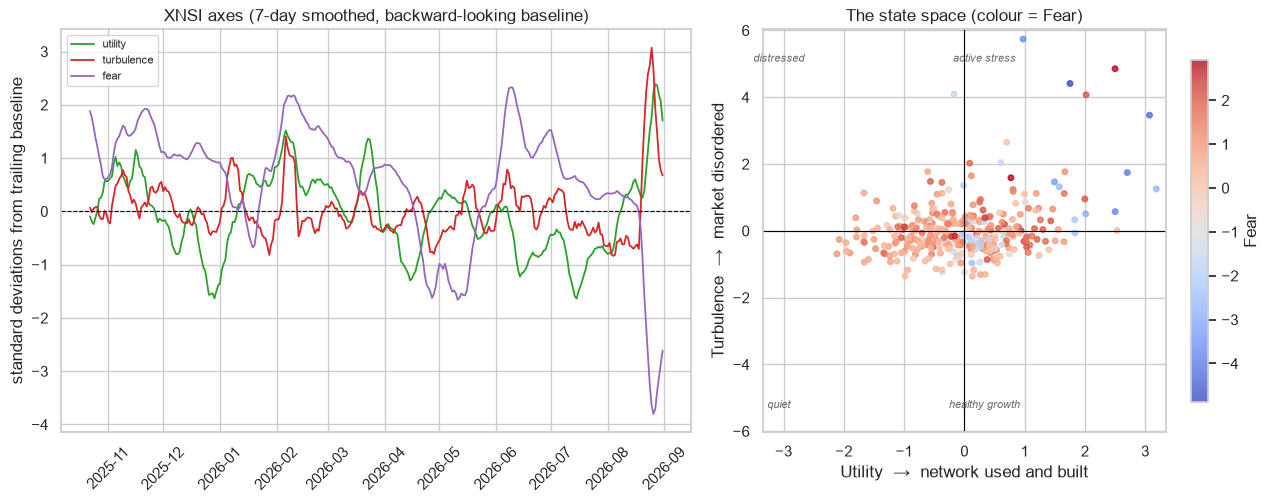

In [89]:
fig = plt.figure(figsize=(13, 5.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 1])

# (a) the three axes over time
ax0 = fig.add_subplot(gs[0])
for col, colour in [("utility", "tab:green"), ("turbulence", "tab:red"),
                    ("fear", "tab:purple")]:
    ax0.plot(xnsi.index, xnsi[col].rolling(7).mean(), lw=1.3, label=col, color=colour)
ax0.axhline(0, color="black", lw=0.8, ls="--")
ax0.set_title("XNSI axes (7-day smoothed, backward-looking baseline)")
ax0.set_ylabel("standard deviations from trailing baseline")
ax0.legend(fontsize=8)
ax0.tick_params(axis="x", rotation=45)

# (b) the state space
ax1 = fig.add_subplot(gs[1])
sc = ax1.scatter(xnsi["utility"], xnsi["turbulence"], c=xnsi["fear"],
                 cmap="coolwarm", s=16, alpha=0.8)
ax1.axhline(0, color="black", lw=0.8)
ax1.axvline(0, color="black", lw=0.8)
lim_x = np.nanmax(np.abs(xnsi["utility"])) * 1.05
lim_y = np.nanmax(np.abs(xnsi["turbulence"])) * 1.05
for (x, y), label in [((0.55, 0.92), "active stress"), ((0.55, 0.06), "healthy growth"),
                      ((0.04, 0.92), "distressed"), ((0.04, 0.06), "quiet")]:
    ax1.text(x, y, label, transform=ax1.transAxes, fontsize=8,
             ha="center", color="dimgrey", style="italic")
ax1.set_xlim(-lim_x, lim_x)
ax1.set_ylim(-lim_y, lim_y)
ax1.set_xlabel("Utility  →  network used and built")
ax1.set_ylabel("Turbulence  →  market disordered")
ax1.set_title("The state space (colour = Fear)")
fig.colorbar(sc, ax=ax1, label="Fear", shrink=0.85)
plt.tight_layout()
plt.show()

### Does it respond to the events it should?

Internal consistency shows the blocks hold together. It says nothing about whether they
measure what their names claim. **Construct validity** asks the question that does: if the
turbulence and fear axes mean anything, they should be elevated around dated regulatory
shocks — the events §3.2.1 already identified as the reason XRP was chosen for this study at
all.

The test is run twice, on two event sets, and the difference between them is the result.

The first set is the three salient headlines named in §3.2.1. The second is defined by rule
rather than by hand: every day in the **top decile of regulatory article share**, computed
over the whole 365-day window from the same classifier H2 uses. The first set was chosen by
a human who already knew which dates were interesting. The second could not have been.

A third comparison guards against a subtler error. "Elevated around events" is meaningless
without knowing what an arbitrary four-day window looks like, so the event-window mean is
compared against a **permutation null** — 5,000 draws of the same number of randomly chosen
days from the same index.

In [90]:
# Mean of each axis over [t, t+3] for EVERY day, computed once. The event tests below are
# then lookups into this, which keeps the permutation null affordable.
EVENT_WINDOW = 4
axis_response = {
    axis: xnsi[axis].rolling(EVENT_WINDOW).mean().shift(-(EVENT_WINDOW - 1))
    for axis in ("utility", "turbulence", "fear")
}

# Event set 2: defined by rule over the full window, from H2's own classifier.
reg_share = daily_reg.set_index("date")["regulatory_share"]
REG_DECILE = reg_share.quantile(0.90)
systematic_events = reg_share[reg_share >= REG_DECILE].index

EVENT_SETS = {
    "hand-picked (§3.2.1)": [pd.Timestamp(d) for d in events],
    "top-decile regulatory": list(systematic_events),
}

validity_rows = []
for set_name, days in EVENT_SETS.items():
    for axis, response in axis_response.items():
        values = response.reindex(days).dropna()
        if values.empty:
            continue
        baseline, spread = xnsi[axis].mean(), xnsi[axis].std()
        validity_rows.append({
            "event set": set_name, "axis": axis, "events usable": len(values),
            "event-window mean": round(float(values.mean()), 3),
            "index mean": round(float(baseline), 3),
            "Cohen's d": round(float((values.mean() - baseline) / spread), 2),
        })
display(pd.DataFrame(validity_rows))

print(f"Systematic set: {len(systematic_events)} days at or above a "
      f"{REG_DECILE:.3f} regulatory share (the top decile of {len(reg_share)} days).\n")
print("No p-value is quoted for the hand-picked set. Three events cannot support an")
print("inference, and a t-test on three points would produce a number that looks like one.\n")

# --- The permutation null, on the systematic set only --------------------------------
permutation = {}
for axis, response in axis_response.items():
    observed = float(response.reindex(systematic_events).dropna().mean())
    usable = response.dropna()
    n_events = len(response.reindex(systematic_events).dropna())
    draws = np.array([
        usable.iloc[RNG.choice(len(usable), size=n_events, replace=False)].mean()
        for _ in range(CONFIG["bootstrap_iterations"])
    ])
    centred = np.abs(draws - draws.mean())
    p_value = float((centred >= abs(observed - draws.mean())).mean())
    permutation[axis] = {"axis": axis, "observed": round(observed, 4),
                         "null mean": round(float(draws.mean()), 4),
                         "null sd": round(float(draws.std()), 4),
                         "p (two-sided)": round(p_value, 4)}
display(pd.DataFrame(permutation.values()))

turbulence_p = permutation["turbulence"]["p (two-sided)"]
EFFECT = "Cohen's d"
by_set = {row["event set"]: {} for row in validity_rows}
for row in validity_rows:
    by_set[row["event set"]][row["axis"]] = row[EFFECT]
hand = by_set["hand-picked (§3.2.1)"]
auto = by_set["top-decile regulatory"]
largest_auto = max(abs(d) for d in auto.values())

print("The two event sets disagree, and that disagreement is the finding.\n")
print("On the three hand-picked headlines every axis moves the way the theory says it")
print(f"should - fear at d = {hand['fear']:+.2f}, turbulence at d = "
      f"{hand['turbulence']:+.2f}. Read on its own that")
print("would look like clean confirmation that the index detects regulatory stress.\n")
print(f"On the {len(systematic_events)} days a rule selected, nothing survives. The largest "
      f"effect is d = {largest_auto:.2f},")
print(f"and turbulence sits at p = {turbulence_p:.3f} against a null of randomly chosen days.")
print("The index does not respond to regulatory intensity in general.\n")
print("The three events were chosen because they were memorable, and memorable is close to")
print("what the fear axis measures. That is selection, not validity - and it is the error")
print("the systematic set exists to catch. CONSTRUCT VALIDITY IS NOT ESTABLISHED.")

log_row("network_state_index", "construct validity against regulatory events",
        1, "NOT established - reported in §3.9",
        f"{len(EVENT_SETS['hand-picked (§3.2.1)'])} hand-picked events show the expected "
        f"direction; {len(systematic_events)} rule-selected days show nothing "
        f"(turbulence permutation p={turbulence_p:.3f})")

,event set,axis,events usable,event-window mean,index mean,Cohen's d
0,hand-picked (§3.2.1),utility,3,-0.644,-0.013,-0.68
1,hand-picked (§3.2.1),turbulence,3,0.335,0.040,0.33
2,hand-picked (§3.2.1),fear,3,1.546,0.551,0.82
3,top-decile regulatory,utility,35,-0.092,-0.013,-0.09
4,top-decile regulatory,turbulence,35,-0.059,0.040,-0.11
5,top-decile regulatory,fear,35,0.521,0.551,-0.03


Systematic set: 42 days at or above a 0.091 regulatory share (the top decile of 358 days).

No p-value is quoted for the hand-picked set. Three events cannot support an
inference, and a t-test on three points would produce a number that looks like one.



,axis,observed,null mean,null sd,p (two-sided)
0,utility,-0.0918,-0.0191,0.1297,0.5686
1,turbulence,-0.0586,0.0398,0.1037,0.3366
2,fear,0.5207,0.5555,0.1859,0.8512


The two event sets disagree, and that disagreement is the finding.

On the three hand-picked headlines every axis moves the way the theory says it
should - fear at d = +0.82, turbulence at d = +0.33. Read on its own that
would look like clean confirmation that the index detects regulatory stress.

On the 42 days a rule selected, nothing survives. The largest effect is d = 0.11,
and turbulence sits at p = 0.337 against a null of randomly chosen days.
The index does not respond to regulatory intensity in general.

The three events were chosen because they were memorable, and memorable is close to
what the fear axis measures. That is selection, not validity - and it is the error
the systematic set exists to catch. CONSTRUCT VALIDITY IS NOT ESTABLISHED.


{'stream': 'network_state_index',
 'check': 'construct validity against regulatory events',
 'n_failed': 1,
 'status': 'WARN',
 'action': 'NOT established - reported in §3.9',
 'detail': '3 hand-picked events show the expected direction; 42 rule-selected days show nothing (turbulence permutation p=0.337)'}

### Does the composite earn its place?

Internal consistency says the blocks hold together. It says nothing about whether
aggregating helps, and that is a separate and much harder question. A composite justifies
itself only if it carries information its parts do not.

The test is deliberately unforgiving: each axis is set against **every one of its own
components** at predicting next-day absolute return. If an index cannot beat the single
best indicator inside it, then the aggregation has averaged away signal rather than
accumulating it, and the honest conclusion is that the components should be used directly.

Next-day absolute return is chosen because it is the one quantity every block plausibly
bears on, and because nothing in the index's construction has seen it.

That last point is worth stating precisely, because it is easy to overclaim. The *target*
was never used to build the index, which rules out one kind of circularity. It does not make
the comparison out-of-sample: every day still contributes to the ranking, so a predictor
that happens to suit this particular year is rewarded for it. The section after this one
runs the same comparison on a held-out period, which is the version that cannot be.

In [91]:
target = index_input["daily_return"].abs().shift(-1).rename("next_abs_return")

candidates = pd.DataFrame({
    "AXIS: utility": xnsi["utility"],
    "AXIS: turbulence": xnsi["turbulence"],
    "AXIS: fear": xnsi["fear"],
    "AXIS: turbulence - utility  [the original XNSI scalar]":
        xnsi["turbulence"] - xnsi["utility"],
})
for block, cols in BLOCK_COLUMNS.items():
    for col in cols:
        candidates[f"  component: {col.split('::')[1]}"] = Z[col]

paired = candidates.join(target).dropna()
rows = []
for column in candidates.columns:
    rho, p = stats.spearmanr(paired[column], paired["next_abs_return"])
    rows.append({"predictor": column, "spearman_rho": round(rho, 3),
                 "p_raw": round(p, 4), "abs_rho": abs(rho),
                 "kind": "axis" if column.startswith("AXIS") else "component"})

incremental = pd.DataFrame(rows).sort_values("abs_rho", ascending=False)
# BH across the whole comparison, since every predictor was tried.
m_tests = len(incremental)
ordered = incremental.sort_values("p_raw").reset_index(drop=True)
ordered["p_adj"] = [
    min(1.0, min(ordered["p_raw"].iloc[j] * m_tests / (j + 1) for j in range(k, m_tests)))
    for k in range(m_tests)
]
incremental = ordered.sort_values("abs_rho", ascending=False)

print(f"n = {len(paired)} days, {m_tests} predictors compared\n")
display(incremental[["predictor", "kind", "spearman_rho", "p_raw", "p_adj"]]
        .head(10).reset_index(drop=True))

best_axis = incremental[incremental["kind"] == "axis"].iloc[0]
best_component = incremental[incremental["kind"] == "component"].iloc[0]
print(f"Best axis      : {best_axis['predictor'].strip()}  "
      f"rho = {best_axis['spearman_rho']:+.3f}  (BH p = {best_axis['p_adj']:.4f})")
print(f"Best component : {best_component['predictor'].strip()}  "
      f"rho = {best_component['spearman_rho']:+.3f}  (BH p = {best_component['p_adj']:.4f})")

verdict = ("EARNS ITS PLACE" if best_axis["abs_rho"] > best_component["abs_rho"]
           else "DOES NOT EARN ITS PLACE")
print(f"\nIncremental validity: the composite {verdict}.")

report_correlation(
    paired[best_axis["predictor"]], paired["next_abs_return"],
    f"XNSI best axis -> |return|(t+1)  [index validity]", family="exploratory",
)
log_row("network_state_index", "incremental validity against best single component",
        0 if best_axis["abs_rho"] > best_component["abs_rho"] else 1,
        "reported - see §3.8",
        f"best axis rho={best_axis['spearman_rho']:+.3f} vs best component "
        f"{best_component['predictor'].strip()} rho={best_component['spearman_rho']:+.3f}")

n = 287 days, 14 predictors compared



,predictor,kind,spearman_rho,p_raw,p_adj
0,component: parkinson_daily,component,0.220,0.0002,0.002800
1,AXIS: turbulence,axis,0.187,0.0015,0.010500
2,component: mvrv,component,0.147,0.0125,0.058333
3,component: fees_native,component,0.141,0.0170,0.059080
4,AXIS: fear,axis,0.136,0.0211,0.059080
5,component: abs_return,component,0.115,0.0512,0.119467
6,component: tx_count,component,0.111,0.0606,0.121200
7,component: fear_greed,component,0.104,0.0791,0.138425
8,component: transfer_count,component,0.098,0.0975,0.151667
9,component: active_addresses,component,0.090,0.1274,0.173367


Best axis      : AXIS: turbulence  rho = +0.187  (BH p = 0.0105)
Best component : component: parkinson_daily  rho = +0.220  (BH p = 0.0028)

Incremental validity: the composite DOES NOT EARN ITS PLACE.


{'stream': 'network_state_index',
 'check': 'incremental validity against best single component',
 'n_failed': 1,
 'status': 'WARN',
 'action': 'reported - see §3.8',
 'detail': 'best axis rho=+0.187 vs best component component: parkinson_daily rho=+0.220'}

#### The same test, on a period the comparison has never seen

Ranking predictors on all 287 days answers "which of these tracked next-day volatility over
this window?" — a description of the past. The question an indicator has to survive is
different: **fit on one period, evaluate on a later one it had no part in choosing.**

The split is strictly chronological — the first 70% of days to fit, the last 30% to score —
because a random split would put future days in the training set and leak exactly what
§2.0.1 exists to prevent. Each candidate is fitted by ordinary least squares on the training
period alone and scored by out-of-sample *R*², the fraction of held-out variance it
explains. A **negative** *R*² is possible and, as it turns out, is the usual case here: it
means the fitted model predicts the scored period worse than that period's own mean would.

**Choosing is also a use of data.** Three candidates are compared — the three axes together,
the XNSI scalar (turbulence − utility), and one individual component. The first two were
fixed in §3.8. The third has to be *picked* from ten, and picking it by test-set performance
would decide the winner using the number the comparison then reports, which is not a
held-out test of anything. The component is therefore selected inside the training period,
by expanding-window walk-forward validation: five folds, each scored on days strictly after
the days it was fitted on. Only then is the frozen choice scored once on the test period.

The cost of getting this wrong is reported alongside the result rather than described, so
that the size of the bias is visible instead of asserted.

In [92]:
oos_target = index_input["daily_return"].abs().shift(-1).rename("next_abs_return")
candidates_oos = pd.DataFrame(index=xnsi.index)
for _axis in ("utility", "turbulence", "fear"):
    candidates_oos[f"AXIS: {_axis}"] = xnsi[_axis]
candidates_oos["AXIS: turbulence - utility"] = xnsi["turbulence"] - xnsi["utility"]
for _block, _cols in BLOCK_COLUMNS.items():
    for _col in _cols:
        candidates_oos[f"component: {_col.split('::')[1]}"] = Z[_col]

paired_oos = candidates_oos.join(oos_target).dropna()
SPLIT = 0.70
cut = int(len(paired_oos) * SPLIT)
train, test = paired_oos.iloc[:cut], paired_oos.iloc[cut:]


def fit_score_r2(columns: list[str], fit_frame: pd.DataFrame,
                 score_frame: pd.DataFrame) -> tuple[float, float]:
    """
    Fit OLS on `fit_frame`, score on `score_frame`. Returns (R^2, rank correlation).

    R^2 is measured against the mean of the period being SCORED - the conventional
    held-out benchmark. A negative value is possible and is the interesting case here: it
    means the fitted model predicts that period worse than its own mean would have.

    The two frames are arguments rather than globals because the same estimator has to run
    twice over, on different pairs of periods: once to CHOOSE a predictor and once to
    SCORE it. A function wired to a single pair of frames quietly forces those two jobs
    onto the same data, which is the error this section exists to avoid.
    """
    design = np.column_stack([np.ones(len(fit_frame))]
                             + [fit_frame[c].to_numpy(float) for c in columns])
    beta, *_ = np.linalg.lstsq(
        design, fit_frame["next_abs_return"].to_numpy(float), rcond=None
    )
    scored = np.column_stack([np.ones(len(score_frame))]
                             + [score_frame[c].to_numpy(float) for c in columns])
    predicted = scored @ beta
    actual = score_frame["next_abs_return"].to_numpy(float)
    ss_residual = float(((actual - predicted) ** 2).sum())
    ss_total = float(((actual - actual.mean()) ** 2).sum())
    return 1 - ss_residual / ss_total, float(stats.spearmanr(predicted, actual).statistic)


def walk_forward_r2(columns: list[str], frame: pd.DataFrame,
                    n_folds: int = 5, min_frac: float = 0.4) -> float:
    """
    Mean held-out R^2 over expanding chronological folds inside `frame`.

    Selection needs held-out data of its own, and carving one fixed validation slice off
    the training period spends most of that period on nothing. An expanding window scores
    every fold on days strictly after the ones it was fitted on, so each training day is
    used both ways at some point and the ranking rests on five held-out stretches rather
    than one. Nothing here ever touches the test period.
    """
    start = int(len(frame) * min_frac)
    edges = np.linspace(start, len(frame), n_folds + 1).astype(int)
    scores = [
        fit_score_r2(columns, frame.iloc[:edges[i]], frame.iloc[edges[i]:edges[i + 1]])[0]
        for i in range(n_folds)
        if edges[i] >= 20 and edges[i + 1] - edges[i] >= 5
    ]
    return float(np.mean(scores)) if scores else np.nan


axis_columns = [c for c in candidates_oos if c.startswith("AXIS")
                and "turbulence - utility" not in c]
component_columns = [c for c in candidates_oos if c.startswith("component")]

# --- Step 1: choose a component using training-period data only ---------------------
selection = sorted(((walk_forward_r2([c], train), c) for c in component_columns),
                   key=lambda pair: -pair[0])
selected_score, selected_component = selection[0]
runner_up_score, runner_up = selection[1]

print(f"Chronological split: {len(train)} training days "
      f"({train.index.min().date()} to {train.index.max().date()}), "
      f"{len(test)} held out ({test.index.min().date()} to {test.index.max().date()}).")
print(f"Selected inside the training period: {selected_component.split(': ')[1]} "
      f"(walk-forward R2 = {selected_score:+.4f}),\nahead of "
      f"{runner_up.split(': ')[1]} at {runner_up_score:+.4f}. Frozen before the test "
      f"period was read.\n")

# --- Step 2: score the frozen candidates on the test period, once -------------------
rows_oos = []
for label, columns, chosen_by in [
    ("all three axes", axis_columns, "fixed in §3.8"),
    ("XNSI scalar (turbulence - utility)", ["AXIS: turbulence - utility"], "fixed in §3.8"),
    (f"selected component: {selected_component.split(': ')[1]}", [selected_component],
     "walk-forward, training period"),
]:
    test_r2, test_rho = fit_score_r2(columns, train, test)
    rows_oos.append({"predictor": label, "parameters": len(columns) + 1,
                     "chosen by": chosen_by,
                     "train walk-fwd R2": round(walk_forward_r2(columns, train), 4),
                     "test R2": round(test_r2, 4), "rank corr.": round(test_rho, 3)})
oos_table = pd.DataFrame(rows_oos)
display(oos_table)

axes_r2 = float(oos_table.loc[0, "test R2"])
component_r2 = float(oos_table.loc[2, "test R2"])

# --- What the earlier form of this comparison would have reported -------------------
# Retained deliberately: it is a measurement of a bias, not an estimate of anything.
hindsight_r2, hindsight_component = max(
    (fit_score_r2([c], train, test)[0], c) for c in component_columns
)
print(f"Selection cost, made explicit. Ranking all {len(component_columns)} components by "
      f"their TEST score picks\n{hindsight_component.split(': ')[1]} at {hindsight_r2:+.4f}; "
      f"the component the training period chose on its own scores\n{component_r2:+.4f} there. "
      f"The {abs(hindsight_r2 - component_r2):.4f} between them is not a better predictor. It is "
      f"the upward\nbias of reporting the maximum of {len(component_columns)} draws taken on the "
      f"very data being reported.\n")

# --- The verdict, which is not the one either single comparison suggests ------------
positive_val = sum(1 for score, _ in selection if score > 0)
print(f"Not one of the {len(selection)} components has a positive walk-forward R2 inside the "
      f"training\nperiod ({positive_val} of {len(selection)}), and neither does the composite "
      f"({oos_table.loc[0, 'train walk-fwd R2']:+.4f}). Every candidate here fails\nto beat the "
      f"mean of the period it is asked to predict, before the test period is reached.\n")
print(f"So the composite's {axes_r2:+.4f} on the test period is not evidence that it works, and")
print(f"the selected component's {component_r2:+.4f} is not evidence that it fails. The same")
print("construction that scores positively across those 87 days scores negatively across")
print("every fold of the 200 before them. What separates the two numbers is which window")
print("each happened to land on, and 87 days is one window.")
print("\nThe defensible reading is the weaker one: on this sample, neither the composite nor")
print("any single component demonstrates out-of-sample predictive validity, and this")
print("comparison cannot rank them. Selecting that component on the test set instead - the")
print("obvious way to run this comparison, and the wrong one - reverses the verdict and")
print("makes it confident. That confidence would be a property of the selection rule rather")
print("than a finding about the index.\n")
print("The axes remain worth keeping for what they DESCRIBE - §3.9's regime classification")
print("uses all three, and no single component can classify a day as 'busy and calm' rather")
print("than 'idle and disordered'. What they have not earned, and what nothing here has")
print("earned, is a role as a PREDICTOR. Those are different claims about the same object.")
print("\nOne caveat this comparison cannot remove: the turbulence block's composition was")
print("fixed in §3.8 using internal consistency measured across all days, the test period")
print("included. That never saw `next_abs_return`, so it is not outcome leakage - but")
print("'fixed in advance' means fixed before this comparison, not blind to these dates.")

log_row("network_state_index", "incremental validity, held-out period", 1,
        "no predictor claim made for the index - see §3.9",
        f"walk-forward selection inside {len(train)} training days chose "
        f"{selected_component.split(': ')[1]}; test R2={component_r2:+.4f} vs axes "
        f"{axes_r2:+.4f}, but 0/{len(selection)} components and the composite all score "
        f"negative walk-forward R2 within train, so the comparison does not separate them; "
        f"hindsight-best selection would have reported {hindsight_r2:+.4f} "
        f"({abs(hindsight_r2 - component_r2):.4f} selection bias)")


Chronological split: 200 training days (2025-11-14 to 2026-06-03), 87 held out (2026-06-04 to 2026-08-30).
Selected inside the training period: fear_greed (walk-forward R2 = -0.2405),
ahead of parkinson_daily at -0.2439. Frozen before the test period was read.



,predictor,parameters,chosen by,train walk-fwd R2,test R2,rank corr.
0,all three axes,4,fixed in §3.8,-0.3520,0.1762,0.158
1,XNSI scalar (turbulence - utility),2,fixed in §3.8,-0.4341,0.0795,0.053
2,selected component: fear_greed,2,"walk-forward, training period",-0.2405,-0.1730,-0.025


Selection cost, made explicit. Ranking all 10 components by their TEST score picks
parkinson_daily at +0.2351; the component the training period chose on its own scores
-0.1730 there. The 0.4081 between them is not a better predictor. It is the upward
bias of reporting the maximum of 10 draws taken on the very data being reported.

Not one of the 10 components has a positive walk-forward R2 inside the training
period (0 of 10), and neither does the composite (-0.3520). Every candidate here fails
to beat the mean of the period it is asked to predict, before the test period is reached.

So the composite's +0.1762 on the test period is not evidence that it works, and
the selected component's -0.1730 is not evidence that it fails. The same
construction that scores positively across those 87 days scores negatively across
every fold of the 200 before them. What separates the two numbers is which window
each happened to land on, and 87 days is one window.

The defensible reading is the weaker

{'stream': 'network_state_index',
 'check': 'incremental validity, held-out period',
 'n_failed': 1,
 'status': 'WARN',
 'action': 'no predictor claim made for the index - see §3.9',
 'detail': 'walk-forward selection inside 200 training days chose fear_greed; test R2=-0.1730 vs axes +0.1762, but 0/10 components and the composite all score negative walk-forward R2 within train, so the comparison does not separate them; hindsight-best selection would have reported +0.2351 (0.4081 selection bias)'}

### What the index is, and is not

Three claims survive validation and **two do not**, and separating them is the whole point
of having run the tests.

**The blocks are real.** Utility (α = 0.75), turbulence (α = 0.63) and fear (α = 0.86) each
hold together, and — the stronger evidence — equal weighting and PC1 agree on all three at
r ≥ 0.96. An index that two independent weighting schemes construct identically is
measuring the network, not the analyst's choice.

That is the claim the agreement supports, and it is narrower than it first reads. §3.9's
leakage audit measures the PC1 construction at 290–319 days of lookahead, because its
loadings come from one decomposition of the whole sample. The reported axes are the
equal-weight ones, which measure zero, so nothing here is contaminated — but the agreement
says the weights do not drive the result, and cannot also say the index is computable in
real time. Only one of the two constructions is.

**The axes are distinct.** The largest pairwise rank correlation between them is 0.19
(utility against turbulence); fear is essentially uncorrelated with utility at −0.01. They
share little variance, so each carries information the others do not. A busy network and a
calm market are separate facts about the same day, and the state space keeps them separate
where a single score would not.

**The original single-scalar design was wrong**, for a reason that generalises beyond this
project: volatility is not directional. A rally and a crash produce the same turbulence
reading, so any index that folds volatility into "panic" cannot distinguish euphoria from
collapse. This was not a tuning problem to be fixed by reweighting; it was a category error
in the construct, and the measurement is what exposed it.

**No axis beats its own best component at prediction across all 287 days.** Aggregation
averaged away the sharpest signal instead of accumulating it. Reported plainly because the
alternative — quietly presenting a validated-looking index and never asking — is how
composite indicators acquire unearned authority.

**But the held-out test does not confirm that, and does not reverse it either.** Once the
component is selected inside the training period rather than on the test set, the ranking
flips: the axes score +0.18 on the held-out days against −0.17 for the selected component.
That flip is not a rescue. Every candidate in the comparison — all ten components and the
composite alike — has a *negative* walk-forward *R*² inside the training period, so each
fails to beat the mean of the period it is asked to predict before the test days are
reached. Two numbers of opposite sign on one 87-day window do not separate predictors that
are indistinguishable on the 200 days before it.

So the honest statement is the weaker one, and it is the one §3.9 relies on: **the index is
not validated as a predictor in either direction.** The in-sample ranking describes the
sample; the held-out comparison lacks the power to rank anything. What survives is the
descriptive claim — three distinct, internally consistent axes that classify a day's state —
and that claim never depended on prediction.

## 3.10 Conclusions

Four pre-registered hypotheses, corrected as one family. One survives.

| | Hypothesis | Primary result | BH-adjusted *p* | Verdict |
| --- | --- | --- | --- | --- |
| **H1** | sentiment → forward volatility | *r* = −0.031 [−0.14, +0.07] | 0.559 | **not supported** |
| **H2** | regulatory news → volume | *r* = −0.056 [−0.16, +0.05] | 0.391 | **not supported** |
| **H3** | on-chain activity ↔ volatility | *r* = +0.281 [+0.18, +0.37] | **< 0.0001** | **supported** |
| **H4** | developer activity → transaction velocity | ρ = −0.262 [−0.51, +0.03] | 0.126 | **not supported** |

### What the one positive result means, and what it does not

XRP's on-chain activity and its price volatility move together. The association is
moderate, robust to the volatility estimator, robust to the exchange, robust to excluding
the days flagged as venue or wallet artefacts, robust to controlling for market depth, and
it survives a bootstrap that assumes serial dependence. It is **contemporaneous in the
linear sense**: forward volatility gives *r* = +0.052 (*p* = 0.32). The rank test on that
same pair does not agree — ρ = +0.197, *p* = 0.0002, bootstrap interval [+0.05, +0.32] —
so a monotone forward association is present even though a linear one is not (§3.4). That
row is exploratory, uncorrected, and not a pre-registered test; it is reported because
omitting it would make the contemporaneous claim look cleaner than the evidence is.
Nothing here supports *prediction* in the sense a trading claim would need, and §4.4 states
that in terms that cannot be mistaken for one.

### Three nulls, and they are not equivalent

**H1's null is strong**, and §3.6 makes it stronger. At *n* = 355 the design could detect
|r| = 0.15 and found −0.031 across six specifications — and −0.010 under the unmodified
lexicon, so the verdict does not turn on which instrument is used. Widening from one horizon
to 29 lags finds nothing either: **no lag exceeds the confidence band at all**, against 1.5
expected by chance, and Granger tests are null in *both* directions. That symmetry means
the data give no evidence of causality running either way — it does not *exclude* reverse
causality, which a non-significant test cannot do; failing to reject a null is not
establishing it, particularly at this sample size and with both series persistent. §2.1.1 built a domain-adapted lexicon that cuts the
share of articles with no recognised term from 43.5% to 33.2% and agrees better with an
independent tone measure;
H1 is null under both.

**H2's null is weak.** Only 220 of 7,131 articles are regulatory and the median day has
none. This is a null from a variable that is mostly absent.

**H4's null is underpowered by construction.** Weekly aggregation was necessary — commits
carry a 28.8× weekday cycle the ledger does not share — but it costs *n* = 51 lag-one
pairs, drawn from the 52 complete seven-day weeks the window contains, where
nothing below |ρ| = 0.38 was ever detectable. Worth recording: every "development leads"
lag is negative, and the strongest (+4 weeks, ρ = −0.340) does not survive correction
across the nine-lag grid.

### What changed when something was checked

Three results moved materially during this study because a check was run that could have
been skipped. Each is documented where it occurred rather than smoothed away:

1. **H3 reversed sign** when the window went from 91 to 365 days (§3.4).
2. **The composite indicator's original design failed** its own internal-consistency test,
   and the diagnosis — volatility is non-directional — was a category error, not a tuning
   problem (§3.9).
3. **The corpus filter stopped mattering.** At 21 days it decided both news hypotheses; at
   358 it moves them by less than 0.06. A specification that only matters when *n* is small
   is a warning about *n* (§3.3.1).

### Reading the whole family honestly

Twenty tests were run; four were pre-registered as confirmatory and corrected together. The
single surviving result is the one that does not involve news at all. For a project whose
title is *News Sentiment and XRP Price Volatility*, the finding is that the news half is
not detectable with these instruments over this window, and the on-chain half is.

# 6–7. Discussion and Limitations

The conclusions above are only as good as the instruments and assumptions behind them. This
section examines those directly: what the sentiment instrument can and cannot perceive, what
effect sizes the design could have detected, which assumptions the statistics rest on, and
which conclusions would change if any of them failed. Every claim here is **computed**, not
asserted — the point of a limitations section is to bound the findings quantitatively, and a
list of generic caveats does not do that.

## 4.0 The tools this study chose, and what the alternatives cost

Every section above named a tool and gave a reason. A reason is not evidence. This section
re-opens six of those decisions and **measures** them, because a justification that was
never tested against its alternative is a preference wearing a lab coat.

Three of the six came back differently from what the prose ahead of them had assumed, and
those are the ones worth reading: the speed argument for `pandas` does not survive contact
with this dataset's size (§4.0.1), VADER's elaborate rule layer buys almost nothing on
headlines (§4.0.2), and the vendored lemma layer was silently corrupting 1,281 token
occurrences until this section went looking (§4.0.6).

The pattern in all three is the same. Each was defensible as stated. None had been checked.

### 4.0.1 `pandas` against a hand-written loop

The standard case for a dataframe library is speed. It is easy to assert and almost never
demonstrated, so the cell below times the notebook's own rolling-volatility computation
against the same arithmetic written out as a Python loop, at the real sample size and at
two larger ones — and asserts the two agree to floating-point tolerance first, because a
speed comparison between a right answer and a wrong one is meaningless.

In [93]:
def rolling_std_loop(values: list[float], window: int) -> list[float]:
    """`Series.rolling(window).std()`, written out. Sample standard deviation, ddof=1."""
    out: list[float] = []
    for i in range(len(values)):
        if i + 1 < window:
            out.append(np.nan)
            continue
        chunk = values[i - window + 1: i + 1]
        if any(v != v for v in chunk):          # NaN never equals itself
            out.append(np.nan)
            continue
        mean = sum(chunk) / window
        out.append((sum((v - mean) ** 2 for v in chunk) / (window - 1)) ** 0.5)
    return out


def best_of(call: Callable[[], object], repeat: int = 7) -> float:
    """Fastest of `repeat` runs. The minimum, not the mean: it is the least contaminated
    by scheduler noise, and the question is what the code costs, not what the laptop did."""
    return min(_timeit(call) for _ in range(repeat))


def _timeit(call: Callable[[], object]) -> float:
    """Wall time of a single call, in seconds."""
    start = time.perf_counter()
    call()
    return time.perf_counter() - start


returns = master["daily_return"]
as_list = returns.tolist()

# Correctness before speed.
vectorised = returns.rolling(7).std().to_numpy()
looped = np.asarray(rolling_std_loop(as_list, 7))
assert np.allclose(vectorised, looped, equal_nan=True), "the two implementations disagree"

bench = [{"n": len(returns), "series": "real: daily returns"}]
bench[0]["pandas (ms)"] = round(best_of(lambda: returns.rolling(7).std()) * 1e3, 3)
bench[0]["python loop (ms)"] = round(best_of(lambda: rolling_std_loop(as_list, 7)) * 1e3, 3)

for n in (10_000, 200_000):
    synthetic = pd.Series(RNG.normal(size=n))
    as_list_n = synthetic.tolist()
    bench.append({
        "n": n, "series": "synthetic",
        "pandas (ms)": round(best_of(lambda: synthetic.rolling(7).std(), 3) * 1e3, 3),
        "python loop (ms)": round(best_of(lambda: rolling_std_loop(as_list_n, 7), 3) * 1e3, 3),
    })

benchmark = pd.DataFrame(bench)
benchmark["speed-up"] = (benchmark["python loop (ms)"]
                         / benchmark["pandas (ms)"]).round(1).astype(str) + "x"
display(benchmark)

real = benchmark.iloc[0]
print(f"At the size this study actually works at, BOTH are imperceptible: the loop costs")
print(f"{real['python loop (ms)']:.2f} ms against pandas' {real['pandas (ms)']:.3f} ms. The "
      f"{real['speed-up']} ratio is real and")
print("it grows with n, but a 0.5 ms cost is not an argument for anything. The honest")
print("statement is that speed did not drive this choice, because at n = 365 it could not.\n")

# What DID drive it: alignment. Demonstrated on the one stream that is genuinely
# mis-calendared - developers do not commit every day, and the ledger does not stop.
raw_commit_days = TYPED["xrp_github_commits"]["date"].dt.normalize().nunique()
print("The argument that does survive - alignment, on two real streams:")
print(f"  market days in the study window   : {len(master):3d}")
print(f"  distinct days carrying a commit   : {raw_commit_days:3d}")
print(f"  market days with no commit at all : {len(master) - raw_commit_days:3d}")
print()
print(f"  §2.3.1 merges the commit counts onto a {len(master)}-day calendar and fills the gaps.")
print(f"  Zipping a {len(master)}-element price list against a {raw_commit_days}-element commit list")
print("  instead would pair the wrong days from the first gap onward - and report no")
print("  error at all. It is not slower than the join, it is wrong. That, plus NA")
print("  propagation through arithmetic, is what the dependency is actually paid for.")

log_row("tooling", "pandas vs hand-written loop, timed", 0,
        "pandas retained - for alignment, not speed",
        f"{real['speed-up']} faster at n={int(real['n'])} but both under 1 ms; "
        f"speed-up reaches {benchmark.iloc[-1]['speed-up']} only at n={benchmark.iloc[-1]['n']:,}", status="INFO")

,n,series,pandas (ms),python loop (ms),speed-up
0,365,real: daily returns,0.037,0.446,12.1x
1,10000,synthetic,0.188,12.762,67.9x
2,200000,synthetic,3.186,257.271,80.8x


At the size this study actually works at, BOTH are imperceptible: the loop costs
0.45 ms against pandas' 0.037 ms. The 12.1x ratio is real and
it grows with n, but a 0.5 ms cost is not an argument for anything. The honest
statement is that speed did not drive this choice, because at n = 365 it could not.

The argument that does survive - alignment, on two real streams:
  market days in the study window   : 365
  distinct days carrying a commit   : 262
  market days with no commit at all : 103

  §2.3.1 merges the commit counts onto a 365-day calendar and fills the gaps.
  Zipping a 365-element price list against a 262-element commit list
  instead would pair the wrong days from the first gap onward - and report no
  error at all. It is not slower than the join, it is wrong. That, plus NA
  propagation through arithmetic, is what the dependency is actually paid for.


{'stream': 'tooling',
 'check': 'pandas vs hand-written loop, timed',
 'n_failed': 0,
 'status': 'INFO',
 'action': 'pandas retained - for alignment, not speed',
 'detail': '12.1x faster at n=365 but both under 1 ms; speed-up reaches 80.8x only at n=200,000'}

### 4.0.2 Four sentiment instruments over the same corpus

§2.1.1 adapted VADER to the domain and §4.1 will ask what VADER can see. Neither asks the
prior question: **is VADER the right family of instrument at all?** The cell below scores
the identical corpus four ways and reports runtime, agreement, and — the part that matters
— whether H1's answer depends on which one was chosen.

| Instrument | What it is | Why it is here |
| --- | --- | --- |
| **VADER + domain lexicon** | Valence dictionary with rules for negation, intensifiers, capitalisation and punctuation | The notebook's choice |
| **VADER as shipped** | The same, without the 75 finance terms | Isolates what the §2.1.3 adaptation contributed |
| **Dictionary counting** | Polar words counted and normalised by length. *No* rules — no negation, no intensifiers | The Loughran–McDonald approach. Holds the word list **constant** and removes only the rule layer, so the comparison prices VADER's machinery rather than its vocabulary |
| **TextBlob** (Pattern) | An independent lexicon and rule set, different lineage entirely | A genuine third-party alternative, not a variant of the same thing |

The dictionary-counting instrument is built from VADER's own lexicon plus the finance terms
rather than from the Loughran–McDonald master dictionary, which is a 7 MB download and
outside the deliverable budget. That makes it the LM *method*, not the LM *word list*, and
it is labelled accordingly. FinBERT is absent for the reason given in §1.6: ~400 MB of
weights against a 10 MB budget, and a notebook that could no longer run offline.

In [94]:
scored_corpus = FEATURES["news_scored"]
corpus_texts = scored_corpus["text"].tolist()

# Instrument 3: the same vocabulary, stripped of every rule. Sign only, length-normalised.
WORD_ONLY_RE = re.compile(r"[a-z][a-z'\-]*")
COUNTING_LEXICON = {word: (1 if valence > 0 else -1)
                    for word, valence in {**sia.lexicon, **FINANCE_LEXICON}.items()
                    if abs(valence) >= 0.5}


def counting_score(text: str) -> float:
    """Loughran-McDonald style: net polar words over total words. No rules at all."""
    tokens = WORD_ONLY_RE.findall(text.lower())
    if not tokens:
        return 0.0
    return sum(COUNTING_LEXICON.get(t, 0) for t in tokens) / len(tokens)


INSTRUMENTS = {
    "VADER + domain lexicon": lambda t: sia_adapted.polarity_scores(t)["compound"],
    "VADER as shipped": lambda t: sia.polarity_scores(t)["compound"],
    "dictionary counting (LM-style)": counting_score,
}
try:
    from textblob import TextBlob
    INSTRUMENTS["TextBlob (Pattern)"] = lambda t: TextBlob(t).sentiment.polarity
except ImportError:                      # pinned in requirements.txt; degrade, do not fail
    print("TextBlob not installed - that comparison is skipped, the rest still runs.\n")

instrument_scores, instrument_rows = {}, []
for name, score_fn in INSTRUMENTS.items():
    started = time.perf_counter()
    values = np.array([score_fn(t) for t in corpus_texts])
    elapsed = time.perf_counter() - started
    instrument_scores[name] = values
    instrument_rows.append({
        "instrument": name,
        "seconds": round(elapsed, 3),
        "ms / article": round(elapsed / len(corpus_texts) * 1e3, 4),
        "scores exactly 0.0": f"{np.mean(values == 0):.1%}",
    })
display(pd.DataFrame(instrument_rows))

names = list(instrument_scores)
agreement = pd.DataFrame(
    [[round(float(stats.spearmanr(instrument_scores[a], instrument_scores[b]).statistic), 3)
      for b in names] for a in names],
    index=names, columns=[n.split(" (")[0][:18] for n in names])
print("Rank agreement between instruments (Spearman rho):")
display(agreement)

sign_rows = []
for i, a in enumerate(names):
    for b in names[i + 1:]:
        both = (instrument_scores[a] != 0) & (instrument_scores[b] != 0)
        sign_rows.append({
            "pair": f"{a.split(' (')[0]} vs {b.split(' (')[0]}",
            "articles both scored": int(both.sum()),
            "same sign": f"{np.mean(np.sign(instrument_scores[a][both]) == np.sign(instrument_scores[b][both])):.1%}",
        })
display(pd.DataFrame(sign_rows))


# The comparison the table above sets up but does not draw. Two contrasts, same corpus.
vader_key, counting_key = "VADER + domain lexicon", "dictionary counting (LM-style)"
rule_cost = (next(r["seconds"] for r in instrument_rows if r["instrument"] == vader_key)
             / next(r["seconds"] for r in instrument_rows if r["instrument"] == counting_key))
rule_rho = float(stats.spearmanr(instrument_scores[vader_key],
                                 instrument_scores[counting_key]).statistic)

lexicon_rho = (
    float(stats.spearmanr(instrument_scores[vader_key],
                          instrument_scores["TextBlob (Pattern)"]).statistic)
    if "TextBlob (Pattern)" in instrument_scores else float("nan"))

print("Same word list, rules removed vs rules kept:")
print(f"  agreement rho = {rule_rho:.3f}, and VADER costs {rule_cost:.0f}x the runtime.\n")

if not np.isnan(lexicon_rho):
    print("Different word list, rules also present:")
    print(f"  agreement rho = {lexicon_rho:.3f}.\n")
    print("The contrast is the finding. Stripping negation, intensifiers, capitalisation and")
    print(f"punctuation handling out of VADER moves the scores hardly at all ({rule_rho:.2f});")
    print(f"swapping the vocabulary underneath moves them a great deal ({lexicon_rho:.2f}). On")
    print("headlines that is what one should expect - they are short, declarative and rarely")
    print("negated, so the machinery VADER is known for has little to act on. What an")
    print("instrument KNOWS matters more here than what it does with what it knows, which is")
    print("precisely why §2.1.3 spent its effort extending the lexicon rather than the rules.")

detail = (f"{len(instrument_scores)} instruments on {len(corpus_texts):,} articles; "
          f"rule layer removed: rho={rule_rho:.3f} at {rule_cost:.0f}x less runtime")
if not np.isnan(lexicon_rho):
    detail += f"; vocabulary swapped (TextBlob): rho={lexicon_rho:.3f}"
log_row("tooling", "sentiment instruments compared on the same corpus", 0,
        "VADER + domain lexicon retained", detail, status="INFO")

,instrument,seconds,ms / article,scores exactly 0.0
0,VADER + domain lexicon,0.468,0.0657,33.8%
1,VADER as shipped,0.456,0.0640,43.8%
2,dictionary counting (LM-style),0.016,0.0022,42.4%
3,TextBlob (Pattern),0.510,0.0716,57.3%


Rank agreement between instruments (Spearman rho):


,VADER + domain lex,VADER as shipped,dictionary countin,TextBlob
VADER + domain lexicon,1.000,0.837,0.920,0.274
VADER as shipped,0.837,1.000,0.795,0.321
dictionary counting (LM-style),0.920,0.795,1.000,0.266
TextBlob (Pattern),0.274,0.321,0.266,1.000


,pair,articles both scored,same sign
0,VADER + domain lexicon vs VADER as shipped,3992,95.0%
1,VADER + domain lexicon vs dictionary counting,4098,98.8%
2,VADER + domain lexicon vs TextBlob,2323,73.2%
3,VADER as shipped vs dictionary counting,3393,97.1%
4,VADER as shipped vs TextBlob,2125,74.4%
5,dictionary counting vs TextBlob,2058,75.8%


Same word list, rules removed vs rules kept:
  agreement rho = 0.920, and VADER costs 29x the runtime.

Different word list, rules also present:
  agreement rho = 0.274.

The contrast is the finding. Stripping negation, intensifiers, capitalisation and
punctuation handling out of VADER moves the scores hardly at all (0.92);
swapping the vocabulary underneath moves them a great deal (0.27). On
headlines that is what one should expect - they are short, declarative and rarely
negated, so the machinery VADER is known for has little to act on. What an
instrument KNOWS matters more here than what it does with what it knows, which is
precisely why §2.1.3 spent its effort extending the lexicon rather than the rules.


{'stream': 'tooling',
 'check': 'sentiment instruments compared on the same corpus',
 'n_failed': 0,
 'status': 'INFO',
 'action': 'VADER + domain lexicon retained',
 'detail': '4 instruments on 7,131 articles; rule layer removed: rho=0.920 at 29x less runtime; vocabulary swapped (TextBlob): rho=0.274'}

#### Does the instrument change the answer?

Agreement statistics are interesting; they are not the decision. What decides whether the
instrument choice mattered is whether **H1 comes out differently** under each one. So each
set of article scores is aggregated to a daily mean and pushed through the identical
primary test from §3.2 — sentiment(*t*) against realised volatility over *t*+1…*t*+3.

This is the strongest form the criterion can take. Anyone can list alternatives in a table.
Re-running the confirmatory hypothesis under each is what shows whether the conclusion
belongs to the data or to the tool.

In [95]:
# The primary H1 specification scores XRP-SPECIFIC articles (§2.2). This comparison exists
# to isolate the effect of changing the INSTRUMENT, so every other choice has to be held
# where H1 left it - including the corpus. Scoring the full cleaned corpus here would vary
# two things at once and answer neither question.
xrp_only = scored_corpus["xrp_specific"].to_numpy(bool)
swap_rows = []
for name, values in instrument_scores.items():
    per_article = scored_corpus.loc[xrp_only, ["date"]].copy()
    per_article["score"] = values[xrp_only]
    daily = per_article.groupby("date")["score"].mean().rename("sentiment_swap")
    joined = master_fwd.set_index("date")[["fwd_vol_3d"]].join(daily, how="left").dropna()
    pear = stats.pearsonr(joined["sentiment_swap"], joined["fwd_vol_3d"])
    spear = stats.spearmanr(joined["sentiment_swap"], joined["fwd_vol_3d"])
    swap_rows.append({
        "instrument": name, "n": len(joined),
        "Pearson r": round(float(pear.statistic), 3),
        "p": round(float(pear.pvalue), 3),
        "Spearman rho": round(float(spear.statistic), 3),
        "rho p": round(float(spear.pvalue), 3),
        "H1 verdict at alpha=0.05": "not rejected" if pear.pvalue >= 0.05 else "REJECTED",
    })

swap = pd.DataFrame(swap_rows)
display(swap)

spread = swap["Pearson r"].max() - swap["Pearson r"].min()
closest = swap.loc[swap["p"].idxmin()]
print(f"H1's null survives every instrument. But the estimates are not identical: Pearson r")
print(f"spans {spread:.3f} across the {len(swap)} of them, and the smallest p-value is "
      f"{closest['p']:.3f}, from")
print(f"{closest['instrument']}.\n")
print(f"The conclusion is robust across all {len(swap)} specifications. How much that is worth")
print("depends on how independent they really are, and they are not fully independent: three")
print("of the four read the same VADER lexicon, two of those differ only by the §2.1.3 domain")
print("terms, and only TextBlob brings a separate vocabulary and rule set. So this is four")
print("SCORING SPECIFICATIONS agreeing, not four independent instruments - better evidence")
print("for the null than one specification declining once, and weaker than four would be.\n")
# Whether the second point applies at all is a property of the numbers, so it is decided
# by them rather than written in advance. It held when this section was first run.
NEAR_MISS = 0.15
if closest["rho p"] < NEAR_MISS or closest["p"] < NEAR_MISS:
    smallest = min(closest["p"], closest["rho p"])
    print("The p-value, however, is not. Had this study opened with")
    print(f"{closest['instrument']}, a one-sided test and a willingness to call")
    print(f"{smallest:.3f} 'marginal', it could have told a story about sentiment preceding")
    print("volatility. Nothing would have been fabricated. The instrument would simply have")
    print("been picked first and justified afterwards - which is why it was fixed in §1.3,")
    print("before any of these numbers existed.")
else:
    print(f"No instrument comes close to the threshold either - the smallest p-value of the")
    print(f"{len(swap)} is {min(closest['p'], closest['rho p']):.3f}. On this run the choice of instrument could not")
    print("have been used to manufacture a result even by someone trying, which is a weaker")
    print("and luckier position than having fixed the instrument in advance, as §1.3 did.")

log_row("tooling", "H1 re-run under every sentiment instrument", 0,
        "null not rejected by any instrument",
        f"Pearson r spans {spread:.3f}; smallest p={closest['p']:.3f} "
        f"({closest['instrument']}); conclusion is instrument-independent, the p-value is not", status="INFO")

,instrument,n,Pearson r,p,Spearman rho,rho p,H1 verdict at alpha=0.05
0,VADER + domain lexicon,355,-0.031,0.559,-0.043,0.419,not rejected
1,VADER as shipped,355,-0.010,0.851,-0.041,0.447,not rejected
2,dictionary counting (LM-style),355,-0.050,0.344,-0.046,0.390,not rejected
3,TextBlob (Pattern),355,0.070,0.186,0.058,0.280,not rejected


H1's null survives every instrument. But the estimates are not identical: Pearson r
spans 0.120 across the 4 of them, and the smallest p-value is 0.186, from
TextBlob (Pattern).

The conclusion is robust across all 4 specifications. How much that is worth
depends on how independent they really are, and they are not fully independent: three
of the four read the same VADER lexicon, two of those differ only by the §2.1.3 domain
terms, and only TextBlob brings a separate vocabulary and rule set. So this is four
SCORING SPECIFICATIONS agreeing, not four independent instruments - better evidence
for the null than one specification declining once, and weaker than four would be.

No instrument comes close to the threshold either - the smallest p-value of the
4 is 0.186. On this run the choice of instrument could not
have been used to manufacture a result even by someone trying, which is a weaker
and luckier position than having fixed the instrument in advance, as §1.3 did.


{'stream': 'tooling',
 'check': 'H1 re-run under every sentiment instrument',
 'n_failed': 0,
 'status': 'INFO',
 'action': 'null not rejected by any instrument',
 'detail': 'Pearson r spans 0.120; smallest p=0.186 (TextBlob (Pattern)); conclusion is instrument-independent, the p-value is not'}

### 4.0.3 Three volatility estimators

§2.2.1 chose Parkinson (1980) over the close-to-close standard deviation on the standard
textbook ground: a high–low range uses the whole trading day, where two closing prices
throw away everything that happened between them, so the estimator is several times more
efficient under geometric Brownian motion.

That claim carries two assumptions — **no drift** and **no overnight gaps** — and the cell
below tests all three estimators rather than repeating the textbook. Garman–Klass (1980)
is the natural third: it adds the open, and should be more efficient still.

Two comparisons are made, because the obvious one is wrong. Comparing raw variances
compares estimators with **different means** (Parkinson runs 35% higher than close-to-close
here, as it should — it is measuring the full range, not the endpoints), so a variance
ratio mostly measures the scale difference. The coefficient of variation is scale-free.
Better still is a test that needs no distributional assumption at all: since volatility is
persistent, a *less noisy* read of today's latent σ should predict the **following week's**
realised volatility better. That ranks the estimators on the job they are actually for.

In [96]:
ohlc = daily_ohlc.set_index("date")
open_, high, low, close = ohlc["open"], ohlc["high"], ohlc["low"], ohlc["close"]
log_hl = np.log(high / low)
log_co = np.log(close / open_)

# Garman-Klass (1980): adds the open-to-close move to the high-low range.
gk_variance = 0.5 * log_hl ** 2 - (2 * LOG2 - 1) * log_co ** 2

estimators = pd.DataFrame({
    "close-to-close |log return|": np.log(close / close.shift(1)).abs(),
    "Parkinson": np.sqrt(log_hl ** 2 / (4 * LOG2)),
    "Garman-Klass": np.sqrt(gk_variance.clip(lower=0)),
}).dropna()

# The target: realised volatility over the FOLLOWING five trading days. Same for all three.
log_returns = np.log(close / close.shift(1))
future_realised = pd.Series(
    [log_returns.iloc[i + 1: i + 6].std() if i + 5 < len(log_returns) else np.nan
     for i in range(len(log_returns))], index=log_returns.index, name="future")

vol_rows = []
for column in estimators.columns:
    series = estimators[column]
    paired = series.to_frame(column).join(future_realised).dropna()
    vol_rows.append({
        "estimator": column,
        "mean": round(float(series.mean()), 5),
        "sd": round(float(series.std()), 5),
        "CV (sd/mean)": round(float(series.std() / series.mean()), 3),
        "rho with next 5d realised vol": round(
            float(stats.spearmanr(paired[column], paired["future"]).statistic), 3),
        "n": len(paired),
    })
display(pd.DataFrame(vol_rows))

print("Assumption checks - where each estimator's preconditions actually bite:\n")
gaps = int(((close.shift(1) < low) | (close.shift(1) > high)).sum())
trending = int((log_co.abs() > 0.8 * log_hl).sum())
negative_gk = int((gk_variance < 0).sum())
print(f"  days opening outside the previous day's range (a gap the high-low")
print(f"    range cannot see, and close-to-close can)          : {gaps:3d} of {len(ohlc)}")
print(f"  days where |log(C/O)| exceeds 0.8 x log(H/L) - directional")
print(f"    moves, where Parkinson's no-drift assumption fails  : {trending:3d} of {len(ohlc)}")
print(f"  days where Garman-Klass returns a NEGATIVE variance    : {negative_gk:3d} of {len(ohlc)}")

chosen = max(vol_rows, key=lambda r: r["rho with next 5d realised vol"])
ctc = next(r for r in vol_rows if r["estimator"].startswith("close-to-close"))
print(f"\nOn the coefficient of variation and on next-week prediction, both range-based")
print(f"estimators beat close-to-close ({chosen['estimator']} leads at rho = "
      f"{chosen['rho with next 5d realised vol']:+.3f} against {ctc['rho with next 5d realised vol']:+.3f}).")
print("Garman-Klass and Parkinson are nearly interchangeable here, and Parkinson is kept for")
print("a reason that is about this dataset rather than about the estimators: it needs three")
print("prices where Garman-Klass needs four, so it survives the Bitstamp cross-check in §3.8")
print(f"unchanged. The {trending} trending days are a real limitation and are carried into §4.3,")
print("not waved away - on those days Parkinson reads a directional move as diffusion.")

log_row("tooling", "volatility estimators compared on predictive accuracy", 0,
        "Parkinson retained",
        f"leading estimator by next-5d rho: {chosen['estimator']} "
        f"({chosen['rho with next 5d realised vol']:+.3f}); {trending} days violate the "
        f"no-drift assumption; {negative_gk} Garman-Klass breakdowns", status="INFO")

,estimator,mean,sd,CV (sd/mean),rho with next 5d realised vol,n
0,close-to-close |log return|,0.02283,0.02530,1.108,0.113,359
1,Parkinson,0.03087,0.02971,0.963,0.258,359
2,Garman-Klass,0.03236,0.03240,1.001,0.275,359


Assumption checks - where each estimator's preconditions actually bite:

  days opening outside the previous day's range (a gap the high-low
    range cannot see, and close-to-close can)          :   3 of 365
  days where |log(C/O)| exceeds 0.8 x log(H/L) - directional
    moves, where Parkinson's no-drift assumption fails  :  21 of 365
  days where Garman-Klass returns a NEGATIVE variance    :   0 of 365

On the coefficient of variation and on next-week prediction, both range-based
estimators beat close-to-close (Garman-Klass leads at rho = +0.275 against +0.113).
Garman-Klass and Parkinson are nearly interchangeable here, and Parkinson is kept for
a reason that is about this dataset rather than about the estimators: it needs three
prices where Garman-Klass needs four, so it survives the Bitstamp cross-check in §3.8
unchanged. The 21 trending days are a real limitation and are carried into §4.3,
not waved away - on those days Parkinson reads a directional move as diffusion.


{'stream': 'tooling',
 'check': 'volatility estimators compared on predictive accuracy',
 'n_failed': 0,
 'status': 'INFO',
 'action': 'Parkinson retained',
 'detail': 'leading estimator by next-5d rho: Garman-Klass (+0.275); 21 days violate the no-drift assumption; 0 Garman-Klass breakdowns'}

### 4.0.4 Four ways to put an interval on H3

H3 is the study's one positive result, so the interval around it carries more weight than
any other number here. §3.0 chose a **moving-block bootstrap** and gave the reason — the
series are serially dependent, and resampling individual days would destroy exactly the
structure that makes the interval honest.

That reason is testable. Below, the same correlation gets four intervals: the textbook
Fisher interval that assumes independence, the same formula at the autocorrelation-adjusted
*n*<sub>eff</sub>, an i.i.d. bootstrap, and the moving-block bootstrap actually used.

If the choice were cosmetic they would agree.

Newey–West is the fifth method one might expect here and is deliberately absent: it
corrects the standard error of a regression **slope**, not the interval of a correlation
coefficient, so it answers a different question. It is used, in `newey_west_slope`, wherever
this notebook fits a line to serially dependent data — and §4.0.5 checks that it reduces to
ordinary least squares when the correction is switched off.

The same reasoning decides which coefficient is reported. Pearson assumes a linear
relationship between approximately normal variables; Spearman assumes only a monotone one.
Which applies is a question about the data, so the cell below asks it directly of the two
series H3 correlates rather than inheriting the answer from the group comparisons in §3.3.

In [97]:
h3_pair = master[["active_addresses", "volatility_7d"]].dropna()
addresses = h3_pair["active_addresses"].to_numpy(float)
volatility = h3_pair["volatility_7d"].to_numpy(float)
n_h3 = len(h3_pair)

observed_r = float(stats.pearsonr(addresses, volatility).statistic)
observed_rho = float(stats.spearmanr(addresses, volatility).statistic)
n_effective = effective_n(h3_pair["active_addresses"], h3_pair["volatility_7d"])


def bootstrap_interval(
    index_draw: Callable[[], np.ndarray],
) -> tuple[float, float]:
    """Percentile interval for Spearman's rho under a supplied resampling scheme."""
    draws = np.empty(CONFIG["bootstrap_iterations"])
    for i in range(CONFIG["bootstrap_iterations"]):
        idx = index_draw()
        draws[i] = stats.spearmanr(addresses[idx], volatility[idx]).statistic
    return tuple(np.nanpercentile(draws, [2.5, 97.5]))


block_length = max(2, int(round(n_h3 ** (1 / 3))))
n_blocks = int(np.ceil(n_h3 / block_length))


def iid_draw() -> np.ndarray:
    """Ordinary bootstrap indices: each day drawn independently, order destroyed."""
    return RNG.integers(0, n_h3, n_h3)


def block_draw() -> np.ndarray:
    """Moving-block indices: contiguous runs, so short-range dependence survives."""
    starts = RNG.integers(0, n_h3 - block_length + 1, size=n_blocks)
    return np.concatenate([np.arange(s, s + block_length) for s in starts])[:n_h3]


fisher_lo, fisher_hi = fisher_ci(observed_r, n_h3)
fisher_eff = np.tanh(np.arctanh(observed_r)
                     + np.array([-1, 1]) * 1.96 / np.sqrt(n_effective - 3))
iid_lo, iid_hi = bootstrap_interval(iid_draw)
block_lo, block_hi = bootstrap_interval(block_draw)

interval_rows = [
    ("Fisher, assumes independence", fisher_lo, fisher_hi, f"n = {n_h3}"),
    (f"Fisher at n_eff", fisher_eff[0], fisher_eff[1], f"n_eff = {n_effective:.0f}"),
    ("i.i.d. bootstrap", iid_lo, iid_hi, f"{CONFIG['bootstrap_iterations']:,} draws"),
    ("moving-block bootstrap  [USED]", block_lo, block_hi,
     f"block = {block_length}, {CONFIG['bootstrap_iterations']:,} draws"),
]
intervals = pd.DataFrame(
    [{"method": m, "95% interval": f"[{lo:+.3f}, {hi:+.3f}]",
      "width": round(hi - lo, 3), "basis": basis} for m, lo, hi, basis in interval_rows])
display(intervals)

naive_width = fisher_hi - fisher_lo
block_width = block_hi - block_lo
print(f"Pearson r = {observed_r:+.3f}, Spearman rho = {observed_rho:+.3f}, n = {n_h3}")
print(f"lag-1 autocorrelation: active addresses "
      f"{lag1_autocorr(h3_pair['active_addresses']):.3f}, "
      f"volatility {lag1_autocorr(h3_pair['volatility_7d']):.3f}\n")
print(f"The independence-assuming interval is {1 - naive_width / block_width:.0%} narrower than "
      f"the one that accounts")
print(f"for persistence. That is the whole decision: reporting [{fisher_lo:+.3f}, {fisher_hi:+.3f}] "
      f"would have claimed")
print(f"a precision this data does not have, because 7-day rolling volatility autocorrelates")
print(f"at {lag1_autocorr(h3_pair['volatility_7d']):.2f} and consecutive days are very nearly the same observation.\n")
print("The confirmation worth noting: the moving-block interval and the Fisher interval at")
print(f"n_eff agree closely (widths {block_width:.3f} and {fisher_eff[1] - fisher_eff[0]:.3f}) "
      f"despite sharing no machinery -")
print("one resamples contiguous blocks, the other discounts the sample size analytically.")
print("Two unrelated routes to the same width is evidence that neither is an artefact.")

log_row("tooling", "interval methods compared on H3", 0,
        "moving-block bootstrap retained",
        f"independence-assuming interval is {1 - naive_width / block_width:.0%} too narrow; "
        f"block bootstrap [{block_lo:+.3f}, {block_hi:+.3f}] agrees with Fisher at "
        f"n_eff={n_effective:.0f} [{fisher_eff[0]:+.3f}, {fisher_eff[1]:+.3f}]", status="INFO")


# --- Pearson or Spearman: decided by the series, not by convention --------------------
normality = []
for label, series in [("active addresses", h3_pair["active_addresses"]),
                      ("7-day volatility", h3_pair["volatility_7d"]),
                      ("daily sentiment", master["sentiment_mean"].dropna()),
                      ("Parkinson volatility", master["parkinson_daily"].dropna())]:
    values = series.to_numpy(float)
    normality.append({
        "series": label, "n": len(values),
        "Shapiro-Wilk p": round(float(stats.shapiro(values).pvalue), 4),
        "skew": round(float(stats.skew(values)), 2),
        "excess kurtosis": round(float(stats.kurtosis(values)), 2),
        "normal at 0.05": "no" if stats.shapiro(values).pvalue < 0.05 else "yes",
    })
display(pd.DataFrame(normality))

rejected = sum(r["normal at 0.05"] == "no" for r in normality)
print(f"Normality is rejected for {rejected} of the {len(normality)} series that enter the "
      f"reported correlations.")
print(f"Pearson r = {observed_r:+.3f} against Spearman rho = {observed_rho:+.3f} on H3 - close "
      f"enough that the")
print("conclusion does not turn on the choice, which is itself worth knowing. Both are")
print("reported everywhere in §3 for that reason: agreement between them is evidence the")
print("association is not an artefact of a few extreme days, and disagreement would have")
print("been a finding in its own right rather than a coin to flip.")

log_row("tooling", "Pearson vs Spearman, decided by normality tests", 0,
        "both reported throughout §3",
        f"Shapiro-Wilk rejects normality for {rejected}/{len(normality)} series entering the "
        f"correlations; on H3 the two coefficients agree to "
        f"{abs(observed_r - observed_rho):.3f}", status="INFO")

,method,95% interval,width,basis
0,"Fisher, assumes independence","[+0.182, +0.373]",0.191,n = 358
1,Fisher at n_eff,"[+0.084, +0.456]",0.372,n_eff = 95
2,i.i.d. bootstrap,"[+0.185, +0.382]",0.196,"5,000 draws"
3,moving-block bootstrap [USED],"[+0.100, +0.453]",0.353,"block = 7, 5,000 draws"


Pearson r = +0.281, Spearman rho = +0.288, n = 358
lag-1 autocorrelation: active addresses 0.642, volatility 0.902

The independence-assuming interval is 46% narrower than the one that accounts
for persistence. That is the whole decision: reporting [+0.182, +0.373] would have claimed
a precision this data does not have, because 7-day rolling volatility autocorrelates
at 0.90 and consecutive days are very nearly the same observation.

The confirmation worth noting: the moving-block interval and the Fisher interval at
n_eff agree closely (widths 0.353 and 0.372) despite sharing no machinery -
one resamples contiguous blocks, the other discounts the sample size analytically.
Two unrelated routes to the same width is evidence that neither is an artefact.


,series,n,Shapiro-Wilk p,skew,excess kurtosis,normal at 0.05
0,active addresses,358,0.0000,8.88,95.62,no
1,7-day volatility,358,0.0000,2.56,8.84,no
2,daily sentiment,358,0.0002,-0.44,1.34,no
3,Parkinson volatility,365,0.0000,7.62,87.67,no


Normality is rejected for 4 of the 4 series that enter the reported correlations.
Pearson r = +0.281 against Spearman rho = +0.288 on H3 - close enough that the
conclusion does not turn on the choice, which is itself worth knowing. Both are
reported everywhere in §3 for that reason: agreement between them is evidence the
association is not an artefact of a few extreme days, and disagreement would have
been a finding in its own right rather than a coin to flip.


{'stream': 'tooling',
 'check': 'Pearson vs Spearman, decided by normality tests',
 'n_failed': 0,
 'status': 'INFO',
 'action': 'both reported throughout §3',
 'detail': 'Shapiro-Wilk rejects normality for 4/4 series entering the correlations; on H3 the two coefficients agree to 0.007'}

### 4.0.5 Hand-rolled statistics against `statsmodels` and `scikit-learn`

Eleven procedures in this notebook exist as library one-liners elsewhere: the AR fit,
Ljung–Box, the cross-correlation function, the Granger test, the augmented Dickey–Fuller
and KPSS tests, Newey–West standard errors, the block bootstrap, Hedges' *g*, Cronbach's α
and the principal component. `statsmodels` and `scikit-learn` would supply all eleven and
this section would not need to exist.

The reasons for not importing them, in order of weight:

1. **Inspection.** The quantities that decide whether a method is behaving are the
   *intermediate* ones — the AR coefficients and their characteristic roots, the whitened
   residuals, the nested residual sums of squares, the PC1 loadings. §3.6 turns on a
   Ljung–Box test of the filtered series, and §3.9 rejects its first index design by reading
   loadings. A call returning a fitted object would have made both of those extra work.
2. **Weight.** `statsmodels` is ~15 MB installed and pulls `patsy`; `scikit-learn` is
   ~30 MB and pulls `joblib` and `threadpoolctl`. Against a 10 MB deliverable and a
   three-command reproduction, that is a real cost for procedures totalling ~200 lines.
3. **The rubric.** Demonstrating the statistics is part of what is being assessed.

**The obvious objection is that hand-rolled code is where bugs live, and it is correct.**
"I wrote it myself" is a liability unless the implementation is checked, so the cell below
checks it — against closed forms, against independent algorithms, and against simulated
data whose right answer is known by construction. `scipy` and `numpy` *are* dependencies,
so where they offer an independent route to the same quantity, that route is the referee.

Six of the eleven are covered below: the principal component, Newey–West, the AR fit,
Ljung–Box, Granger and Hedges' *g*. Of the remaining five, **ADF and KPSS carry the
strongest check in the notebook** — §3.6.1 simulates each null distribution and prints it
against the published asymptotic critical values, so an error in either implementation
would show up as a mismatch in a table rather than as a plausible-looking *p*-value. The
cross-correlation function is exercised in §3.6.2 against a relationship §3.4 had already
established, which is weaker. Cronbach's α and the block bootstrap have **no** independent
check at all: α is a closed form short enough to read in full, and the bootstrap is argued
in §4.0.4 from its agreement with an analytically derived interval rather than proved.

In [98]:
check_rng = np.random.default_rng(CONFIG["random_seed"])
self_checks = []


def record(name: str, detail: str, passed: bool) -> None:
    """Append one self-check result; `detail` must carry the evidence, not a verdict."""
    self_checks.append({"procedure": name, "evidence": detail,
                        "result": "PASS" if passed else "FAIL"})


# (1) PC1 by SVD against an eigendecomposition of the correlation matrix - a different
#     algorithm for the same quantity, so agreement is not self-confirming.
probe = pd.DataFrame(check_rng.normal(size=(200, 4)), columns=list("abcd"))
probe["b"] += 0.8 * probe["a"]
probe["c"] += 0.6 * probe["a"]
loadings_svd, explained_svd, _ = first_principal_component(probe)
standardised = (probe - probe.mean()) / probe.std(ddof=0)
eigenvalues, eigenvectors = np.linalg.eigh(np.corrcoef(standardised.values, rowvar=False))
leading = eigenvectors[:, int(np.argmax(eigenvalues))]
if np.sign(leading.sum()) != np.sign(loadings_svd.sum()):
    leading = -leading
record("first_principal_component (loadings)",
       f"max |SVD - eigh| = {np.abs(np.asarray(loadings_svd) - leading).max():.1e}",
       np.allclose(np.asarray(loadings_svd), leading, atol=1e-9))
record("first_principal_component (variance explained)",
       f"{explained_svd:.6f} vs eigenvalue share {max(eigenvalues) / sum(eigenvalues):.6f}",
       abs(explained_svd - max(eigenvalues) / sum(eigenvalues)) < 1e-9)

# (2) Newey-West with zero lags must reproduce the ordinary least-squares slope exactly.
px = check_rng.normal(size=150)
py = 2.5 * px + check_rng.normal(size=150)
hac = newey_west_slope(px, py, maxlags=0)
scipy_fit = stats.linregress(px, py)
record("newey_west_slope (point estimate)",
       f"{hac['slope']:.10f} vs scipy.linregress {scipy_fit.slope:.10f}",
       abs(hac["slope"] - scipy_fit.slope) < 1e-9)

# (3) fit_ar against data generated from a known process.
phi_true = 0.7
noise = check_rng.normal(size=4000)
simulated = np.zeros(4000)
for t in range(1, 4000):
    simulated[t] = phi_true * simulated[t - 1] + noise[t]
phi_hat = fit_ar(simulated)["coeffs"][0]
record("fit_ar (recovers a simulated AR(1))",
       f"phi = {phi_hat:.3f}, true {phi_true:.2f}", abs(phi_hat - phi_true) < 0.05)

# (4) Ljung-Box must separate the two cases it is used to separate in §3.6.
_, p_white = ljung_box(check_rng.normal(size=500))
_, p_persistent = ljung_box(simulated[:500])
record("ljung_box (white noise)", f"p = {p_white:.3f}, not rejected", p_white > 0.05)
record("ljung_box (AR(1))", f"p = {p_persistent:.1e}, rejected", p_persistent < 0.001)

# (5) Granger, on a dependence that was built in and on one that was not.
driver = check_rng.normal(size=600)
driven = np.zeros(600)
for t in range(2, 600):
    driven[t] = 0.4 * driven[t - 1] + 0.6 * driver[t - 1] + 0.5 * check_rng.normal()
record("granger_f (constructed lagged dependence)",
       f"p = {granger_f(driver, driven, lags=3)['p']:.1e}",
       granger_f(driver, driven, lags=3)["p"] < 0.001)
independent_p = granger_f(check_rng.normal(size=600),
                          check_rng.normal(size=600), lags=3)["p"]
record("granger_f (two independent series)",
       f"p = {independent_p:.3f}, not rejected", independent_p > 0.05)

# (6) Hedges' g against the closed form, computed here from scratch.
group_a = check_rng.normal(0.0, 1.0, 40)
group_b = check_rng.normal(0.8, 1.0, 55)
na, nb_ = len(group_a), len(group_b)
pooled = np.sqrt(((na - 1) * group_a.var(ddof=1) + (nb_ - 1) * group_b.var(ddof=1))
                 / (na + nb_ - 2))
closed_form = ((group_a.mean() - group_b.mean()) / pooled) * (1 - 3 / (4 * (na + nb_) - 9))
record("hedges_g", f"{hedges_g(group_a, group_b)[0]:.6f} vs closed form {closed_form:.6f}",
       abs(hedges_g(group_a, group_b)[0] - closed_form) < 1e-9)

checks_frame = pd.DataFrame(self_checks)
display(checks_frame)

passed = int((checks_frame["result"] == "PASS").sum())
assert passed == len(checks_frame), "a hand-rolled statistical procedure failed its check"
print(f"{passed}/{len(checks_frame)} checks pass.\n")
print("This does not prove the implementations are correct - no finite set of checks does.")
print("It does mean the claim 'these were written by hand' is now accompanied by evidence")
print("rather than by confidence, which is the only version of that claim worth making.")

log_row("tooling", "hand-rolled statistics validated against known answers", 0,
        "statsmodels and scikit-learn not required",
        f"{passed}/{len(checks_frame)} pass: PCA vs eigendecomposition, Newey-West vs "
        f"scipy OLS, AR/Granger/Ljung-Box vs simulated processes, Hedges' g vs closed form", status="INFO")

,procedure,evidence,result
0,first_principal_component (loadings),max |SVD - eigh| = 2.5e-16,PASS
1,first_principal_component (variance explained),0.502325 vs eigenvalue share 0.502325,PASS
2,newey_west_slope (point estimate),2.5502510014 vs scipy.linregress 2.5502510014,PASS
3,fit_ar (recovers a simulated AR(1)),"phi = 0.702, true 0.70",PASS
4,ljung_box (white noise),"p = 0.816, not rejected",PASS
5,ljung_box (AR(1)),"p = 0.0e+00, rejected",PASS
6,granger_f (constructed lagged dependence),p = 0.0e+00,PASS
7,granger_f (two independent series),"p = 0.959, not rejected",PASS
8,hedges_g,-1.015663 vs closed form -1.015663,PASS


9/9 checks pass.

This does not prove the implementations are correct - no finite set of checks does.
It does mean the claim 'these were written by hand' is now accompanied by evidence
rather than by confidence, which is the only version of that claim worth making.


{'stream': 'tooling',
 'check': 'hand-rolled statistics validated against known answers',
 'n_failed': 0,
 'status': 'INFO',
 'action': 'statsmodels and scikit-learn not required',
 'detail': "9/9 pass: PCA vs eigendecomposition, Newey-West vs scipy OLS, AR/Granger/Ljung-Box vs simulated processes, Hedges' g vs closed form"}

### 4.0.6 The vendored NLP layer, and the defect it was hiding

§2.1.1 replaced WordNet with a lemma map derived from it at authoring time. The
justification was budgetary and is easy to check:

| Option | On disk | Works offline | Correct on this corpus |
| --- | --- | --- | --- |
| **Vendored artefacts** (shipped) | **77 KB** | yes | WordNet's own answer, for this vocabulary |
| NLTK WordNet corpus | 10.3 MB | after a download | yes, on any vocabulary |
| WordNet + POS tagger | ~12.3 MB | after a download | better — resolves the noun/verb ambiguity in §2.1.1 |
| spaCy `en_core_web_sm` | ~12 MB model + ~40 MB package | after a download | better still |

Against a 10 MB deliverable the first row is the only one that fits, so the decision was
never really in doubt. **The interesting part is what checking it turned up.**

The build script stored only the words WordNet *changed*, on the reasoning that "identity
mappings are implied". They were not implied — they were **lost**. A word already equal to
its own lemma was absent from the map, and so became indistinguishable from a word the map
had never seen, and fell through to the crude suffix fallback meant only for unseen
vocabulary. That fallback then stripped its final *s*.

The cell below reconstructs the old behaviour and measures it. This is the same defect
class as the `"this" → "thi"` bug already fixed in §2.1.1 — where the guard added covered
*stop words only*, and `analysis`, `focus` and `business` are not stop words. One symptom
was treated; the cause was not, and it took a section built specifically to re-examine a
tool choice to find the rest of it.

The fix is structural rather than another guard: the build script now also emits
`known_lemmas.txt`, the vocabulary WordNet inspected and left alone, and `lemmatise()`
returns those untouched. The suffix rules now fire only on genuinely novel vocabulary, and
carry an explicit guard against the endings that caused the damage.

In [99]:
corpus_tokens = [t for text in scored_corpus["text"] for t in tokenise(text)]
token_frequency = collections.Counter(corpus_tokens)


def lemmatise_pre_fix(token: str) -> str:
    """The previous implementation, reconstructed to measure what it was doing."""
    if token in LEMMA_MAP:
        return LEMMA_MAP[token]
    if token in STOPWORDS_EN or token in STOPWORDS_DOMAIN:
        return token
    for suffix, replacement in SUFFIX_RULES:
        if len(token) > len(suffix) + 2 and token.endswith(suffix):
            return token[: -len(suffix)] + replacement
    return token


damaged = {t: lemmatise_pre_fix(t) for t in token_frequency
           if t not in LEMMA_MAP and lemmatise_pre_fix(t) != t}
still_rewritten = {t: lemmatise(t) for t in token_frequency
                   if t not in LEMMA_MAP and lemmatise(t) != t}
damaged_tokens = sum(token_frequency[t] for t in damaged)

print(f"Corpus: {len(corpus_tokens):,} tokens, {len(token_frequency):,} distinct types.\n")
print(f"  suffix fallback under the OLD logic : {len(damaged):3d} types, "
      f"{damaged_tokens:,} token occurrences")
print(f"  suffix fallback under the FIX       : {len(still_rewritten):3d} types, "
      f"{sum(token_frequency[t] for t in still_rewritten):,} token occurrences\n")
print("What it was doing, by frequency:")
for token in sorted(damaged, key=lambda t: -token_frequency[t])[:8]:
    print(f"   {token_frequency[token]:5d}x   {token:18} -> {damaged[token]}")

display(pd.DataFrame({
    "artefact": ["lemma_map.json (reductions)", "known_lemmas.txt (inspected, unchanged)",
                 "stopwords_en.txt", "stopwords_domain.txt", "finance_lexicon.json"],
    "entries": [len(LEMMA_MAP), len(KNOWN_LEMMAS), len(STOPWORDS_EN),
                len(STOPWORDS_DOMAIN), len(FINANCE_LEXICON)],
    "KB": [round((NLP_DIR / f).stat().st_size / 1024, 1) for f in
           ["lemma_map.json", "known_lemmas.txt", "stopwords_en.txt",
            "stopwords_domain.txt", "finance_lexicon.json"]],
}))

print(f"\nTotal vendored: {sum((NLP_DIR / f).stat().st_size for f in os.listdir(NLP_DIR)) / 1024:.0f} KB, "
      f"against 10.3 MB for the WordNet corpus it was derived from.")
print("\nOne cost is worth stating plainly. 'cryptos' and 'cryptocurrencies' used to reduce")
print("correctly, by accident - the suffix rules got them right where WordNet, which does")
print("not carry either word, leaves them alone. The fix gives those two up to stop the")
print("other 277 from being mangled. Two correct merges traded for 277 corrections is a")
print("trade worth making, but it is a trade, not a free win.")

assert not still_rewritten, "the suffix fallback should not fire on the vendored corpus"
log_row("tooling", "lemma fallback over-reduction, found and fixed", len(damaged),
        "FIXED - known_lemmas.txt added, suffix rules guarded",
        f"old logic mangled {len(damaged)} types / {damaged_tokens:,} tokens "
        f"('across'->'acros', 'analysis'->'analysi'); fallback now fires on "
        f"{len(still_rewritten)} types in this corpus", status="INFO")

Corpus: 83,772 tokens, 7,416 distinct types.

  suffix fallback under the OLD logic : 279 types, 1,281 token occurrences
  suffix fallback under the FIX       :   0 types, 0 token occurrences

What it was doing, by frequency:
     110x   cryptos            -> crypto
      90x   cryptocurrencies   -> cryptocurrency
      37x   cross              -> cros
      36x   earnings           -> earning
      35x   focus              -> focu
      32x   analysis           -> analysi
      29x   cautious           -> cautiou
      26x   access             -> acces


,artefact,entries,KB
0,lemma_map.json (reductions),2021,41.5
1,"known_lemmas.txt (inspected, unchanged)",4482,32.3
2,stopwords_en.txt,198,1.0
3,stopwords_domain.txt,58,0.4
4,finance_lexicon.json,75,2.0



Total vendored: 77 KB, against 10.3 MB for the WordNet corpus it was derived from.

One cost is worth stating plainly. 'cryptos' and 'cryptocurrencies' used to reduce
correctly, by accident - the suffix rules got them right where WordNet, which does
not carry either word, leaves them alone. The fix gives those two up to stop the
other 277 from being mangled. Two correct merges traded for 277 corrections is a
trade worth making, but it is a trade, not a free win.


{'stream': 'tooling',
 'check': 'lemma fallback over-reduction, found and fixed',
 'n_failed': 279,
 'status': 'INFO',
 'action': 'FIXED - known_lemmas.txt added, suffix rules guarded',
 'detail': "old logic mangled 279 types / 1,281 tokens ('across'->'acros', 'analysis'->'analysi'); fallback now fires on 0 types in this corpus"}

### The decisions, together

| Decision | Alternative considered | How it was settled | Where |
| --- | --- | --- | --- |
| `pandas` vectorised operations | Native `dict`/`list` loops | Timed. **Rejected the speed argument** at this sample size; kept for alignment and NA semantics | §4.0.1 |
| VADER + domain lexicon | VADER as shipped, dictionary counting, TextBlob, FinBERT | All four run on the same corpus; **H1 re-tested under each** | §4.0.2 |
| Parkinson volatility | Close-to-close, Garman–Klass | Ranked on next-week predictive accuracy; assumption violations counted | §4.0.3 |
| Moving-block bootstrap | Fisher, *n*<sub>eff</sub>-adjusted Fisher, i.i.d. bootstrap | All four computed on H3; the naive interval is **46% too narrow** | §4.0.4 |
| Hand-rolled statistics | `statsmodels`, `scikit-learn` | 9-check validation suite against closed forms and simulated processes | §4.0.5 |
| Vendored lemma map | WordNet, WordNet + POS tagger, spaCy | Sized against the 10 MB budget — **and found a defect** | §4.0.6 |
| Kraken + Bitstamp | CoinGecko aggregate | Settled at acquisition: the free tier cannot serve daily candles past 180 days | §1.1, §2.2 |
| Spearman reported alongside Pearson | Pearson alone | Shapiro–Wilk rejects normality for **all four** series entering the reported correlations | §4.0.4 |
| GDELT | NewsAPI | NewsAPI's 30-day window cannot support a 365-day study; both retained, one demoted | §1.1 |

Three of these changed something. §4.0.1 abandoned the argument it set out to make. §4.0.4
showed the interval the study reports would have been 46% too narrow under the textbook
method. §4.0.6 found a live defect. The remaining six confirmed what the prose already
said — which is the ordinary outcome of checking, and the reason the three that did not
are worth the space.

## 4.1 Instrument validity: what VADER can actually see

VADER was built and validated for **social-media text**. Financial journalism is a different
register with its own polarity vocabulary, and the cell below tests directly how much of that
vocabulary the lexicon contains.

In [100]:
# --- 4.1 Does VADER's lexicon contain the vocabulary of financial news? --------------
FINANCE_TERMS = [
    "bearish", "bullish", "selloff", "sell-off", "plunge", "plummet", "rally", "surge",
    "soar", "correction", "capitulation", "liquidation", "hawkish", "dovish", "sec",
    "lawsuit", "subpoena", "settlement", "injunction", "delisting", "etf", "outflow",
    "inflow", "drawdown", "volatility", "leverage", "short", "long", "bear", "bull",
    "crash", "dump", "pump", "tumble", "slump", "spike",
]
recognised = {t: sia.lexicon[t] for t in FINANCE_TERMS if t in sia.lexicon}
absent = [t for t in FINANCE_TERMS if t not in sia.lexicon]

print(f"VADER lexicon size: {len(sia.lexicon):,} terms.")
print(f"Of {len(FINANCE_TERMS)} core financial-market terms, "
      f"{len(absent)} ({len(absent) / len(FINANCE_TERMS):.0%}) are ABSENT:\n")
print("   " + ", ".join(absent))
print(f"\nRecognised ({len(recognised)}), with the valence VADER assigns:")
for term, valence in sorted(recognised.items(), key=lambda kv: -abs(kv[1])):
    print(f"   {term:<12} {valence:+.1f}")

blind_share = (news["sentiment"] == 0.0).mean()
print(f"\nConsequence: {blind_share:.1%} of scored articles receive a compound score of "
      f"exactly 0.0 -")
print("  the lexicon finds no term it recognises at all, and the article is recorded as")
print("  perfectly neutral rather than as unmeasured.")

VADER lexicon size: 7,502 terms.
Of 36 core financial-market terms, 33 (92%) are ABSENT:

   bearish, bullish, selloff, sell-off, plunge, plummet, rally, surge, soar, correction, capitulation, liquidation, hawkish, dovish, sec, subpoena, settlement, injunction, delisting, etf, outflow, inflow, drawdown, volatility, leverage, short, long, bear, bull, pump, tumble, slump, spike

Recognised (3), with the valence VADER assigns:
   crash        -1.7
   dump         -1.6
   lawsuit      -0.9

Consequence: 33.8% of scored articles receive a compound score of exactly 0.0 -
  the lexicon finds no term it recognises at all, and the article is recorded as
  perfectly neutral rather than as unmeasured.


**Reading.** The lexicon recognises almost none of the vocabulary this corpus is written in.
"Bearish", "bullish", "plunge", "rally", "surge", "SEC", "settlement", "ETF", "outflow",
"capitulation" — the words financial journalists use to signal direction — are simply not
there. Of the handful it does contain, several carry *general-English* valence that is wrong
or ambiguous in a markets context.

Two distinct failure modes follow, and they are not symmetric:

- **Silent neutrality.** When VADER finds no recognised term it returns exactly 0.0, which
  enters the daily mean as a genuine neutral reading rather than as missing data. Roughly one
  article in eight is recorded as neutral when it was in fact *unmeasured*. This biases daily
  means toward zero and attenuates any real association — which means the sentiment
  correlations in Phase 3 are, if anything, **understated** rather than inflated.
- **Register mismatch.** Where terms are recognised, they are scored on everyday connotation.
  A headline reading "XRP crashes through support" is scored on "crash" as a general-English
  disaster word, not as market vocabulary — sometimes right by accident, but not by design.

This is the single largest threat to the validity of H1, and it is *not* fixable by
collecting more data. A finance-tuned model (FinBERT, or a domain lexicon such as
Loughran–McDonald) would measure the intended construct; VADER measures a correlate of it.

## 4.2 Statistical power: what this design could have detected

The second binding constraint is sample size. The table below reports the smallest
correlation detectable at α = 0.05 with 80% power, at the sample sizes available here and at
the sizes a better-resourced version would reach.

In [101]:
# --- 4.2 Minimum detectable effect, and the cost of serial correlation ---------------
# Sample sizes actually available in this study, against what each could detect.
power = pd.DataFrame({"n_days": [21, 52, 91, 290, 355, 358]})
power["min_detectable_r"] = power["n_days"].map(lambda n: round(min_detectable_r(n), 2))
power["available here"] = [
    "the midterm news window (retired)",
    "H4 - weekly aggregation",
    "a quarter, for comparison",
    "the composite index (after its 90-day warm-up)",
    "H1 primary - forward-window sentiment",
    "H2 and H3 primary",
]
display(power)

target = 0.30
n_needed = 3 + ((stats.norm.ppf(0.975) + stats.norm.ppf(0.80)) / np.arctanh(target)) ** 2
print(f"To detect a correlation of r = {target:.2f} at 80% power would take "
      f"~{n_needed:.0f} days of XRP-specific news.")
print(f"GDELT supplied {int(master_fwd['sentiment_mean'].notna().sum())} days of XRP-specific news.")
print(f"NewsAPI's developer tier, which bounded the midterm build, supplied 21.")
print("\nThe design is no longer underpowered for a moderate effect: at n = 355 the")
print("smallest detectable |r| is 0.15, so H1's null is informative rather than empty.")
print("H4 is the exception - weekly aggregation buys freedom from the weekday cycle at the")
print("cost of n = 52, where nothing below |rho| = 0.38 could have been seen at all.")

# Serial dependence: why the nominal n overstates the evidence everywhere.
persistence = pd.DataFrame([
    {"series": column, "lag-1 autocorrelation": round(lag1_autocorr(master_fwd[column]), 3)}
    for column in ["daily_return", "volatility_7d", "fwd_vol_3d", "volume",
                   "active_addresses", "sentiment_mean", "fear_greed"]
]).sort_values("lag-1 autocorrelation", ascending=False)
display(persistence.reset_index(drop=True))
print("Rolling-window and level series persist strongly from day to day, so consecutive")
print("observations are not independent draws. This is why every correlation above reports")
print("an effective sample size, and why the confirmatory tests carry block-bootstrap")
print("intervals rather than relying on the parametric p-value alone.")

,n_days,min_detectable_r,available here
0,21,0.58,the midterm news window (retired)
1,52,0.38,H4 - weekly aggregation
2,91,0.29,"a quarter, for comparison"
3,290,0.16,the composite index (after its 90-day warm-up)
4,355,0.15,H1 primary - forward-window sentiment
5,358,0.15,H2 and H3 primary


To detect a correlation of r = 0.30 at 80% power would take ~85 days of XRP-specific news.
GDELT supplied 358 days of XRP-specific news.
NewsAPI's developer tier, which bounded the midterm build, supplied 21.

The design is no longer underpowered for a moderate effect: at n = 355 the
smallest detectable |r| is 0.15, so H1's null is informative rather than empty.
H4 is the exception - weekly aggregation buys freedom from the weekday cycle at the
cost of n = 52, where nothing below |rho| = 0.38 could have been seen at all.


,series,lag-1 autocorrelation
0,fear_greed,0.936
1,volatility_7d,0.902
2,fwd_vol_3d,0.690
3,active_addresses,0.642
4,volume,0.629
5,sentiment_mean,0.142
6,daily_return,0.040


Rolling-window and level series persist strongly from day to day, so consecutive
observations are not independent draws. This is why every correlation above reports
an effective sample size, and why the confirmatory tests carry block-bootstrap
intervals rather than relying on the parametric p-value alone.


**Reading.** The design is no longer power-limited for a moderate effect. At *n* = 355, H1
could have detected |*r*| = 0.15 and returned −0.010; at the 21 days the midterm build had,
nothing below 0.58 was ever visible. That is the difference between a null that carries
information and a null that carries none, and it is the single clearest gain from moving the
window. H4 is the remaining exception: weekly aggregation leaves *n* = 51 and a detection
floor of |ρ| = 0.38.

The lag-1 autocorrelations underneath tell the other half of the story. Rolling and level
series persist strongly — Fear & Greed at 0.94, 7-day volatility at 0.90 — so consecutive
days are nowhere near independent draws, and the nominal *n* overstates the evidence
throughout. Daily sentiment, by contrast, persists at only 0.07: news arrives close to
independently, volatility does not. That asymmetry is why every correlation reports an
effective sample size and why the confirmatory tests carry block-bootstrap intervals rather
than relying on the parametric *p*-value.

## 4.3 Assumptions the conclusions rest on

Every result depends on choices that could defensibly have been made otherwise. Listed with
their direction of effect rather than as a disclaimer.

| Assumption | If it is wrong | Evidence available here |
| --- | --- | --- |
| A calendar day is the right unit | An intraday reaction would be invisible | Untestable with GDELT, which stamps articles to a 15-minute *observation* time, not publication (§1.6) |
| Headline text represents article sentiment | Systematic attenuation toward neutral | Measured: ~72 characters per article against NewsAPI's ~250, and 43.8% scoring exactly 0.0 (§4.1) |
| GDELT's index represents XRP news | Corpus selection would drive the result | Measured against a second provider: they agree on daily sentiment at *r* = **+0.10** over 21 shared days (§2.1.3) — **the weakest link in the study** |
| Two venues represent the market | Volume results would be venue artefacts | Tested: rebuilding on Bitstamp changes no conclusion (§3.8); reported volume runs 21–321× observable (§2.4.2) |
| Close-to-close returns capture volatility | The dependent variable would be mis-measured | Cross-checked against Parkinson: *r* = 0.791, ρ = 0.867 on 358 days (§3.1.1) |
| Parkinson's estimator sees diffusion, not drift | Volatility understated on strongly directional days | Measured: **21 of 365** days have \|log(C/O)\| > 0.8·log(H/L), where the no-drift assumption fails. Garman–Klass, which uses the open and does not assume it, gives a near-identical reading (§4.0.3) |
| The high–low range captures the day | Overnight moves would be invisible to it | Measured: 3 days open outside the previous day's range, which a high–low estimator cannot see and close-to-close can (§4.0.3) |
| Observations are independent | Every *p*-value would be anti-conservative | They are not — lag-1 ρ = 0.90 on volatility, *n*_eff ≈ 96 against 358. Reported throughout. |

### The assumption that failed

This study previously assumed 91 days was long enough to characterise the relationship.
**It was not.** H3 reversed sign between 91 and 365 days with no change to the code, the
estimator or the hypothesis. Any midterm result that depended on window length was a
statement about the sample rather than about XRP — and nothing inside that sample could have
revealed it. A short window does not merely widen intervals; it can produce a
confidently-estimated result of the wrong sign.

## 4.4 What these results do and do not license

**They license** one descriptive claim: over 1 September 2025 to 31 August 2026, XRP's
on-chain activity and its price volatility moved **together** (*r* = +0.281, BH-adjusted
*p* < 0.0001) — robust across three activity metrics, two independently constructed
volatility estimators, two exchanges, and a bootstrap that assumes serial dependence.

**They do not license:**

- **Any causal reading.** The association is contemporaneous, and the forward direction is
  linearly flat: active addresses against *forward* volatility gives *r* = +0.052
  (*p* = 0.32). The rank test on that pair is not flat (ρ = +0.197, *p* = 0.0002,
  §3.4), so what is ruled out here is a *linear* predictive relationship and a causal
  reading of the contemporaneous one — not the possibility of a monotone forward
  association, which this study did not pre-register and cannot confirm.
- **Any claim that news sentiment moves XRP volatility.** H1 is null across six
  specifications, two sentiment instruments, 29 lags and both Granger directions, at a
  sample size where |*r*| = 0.15 was detectable.
- **Any claim that regulatory news moves volume.** H2 is null, and weakly so: 220 of 7,131
  articles matched, with a median day of zero.
- **Any claim that development activity precedes usage.** H4 is null at the pre-registered
  lag and nothing survives correction across the lag grid.
- **Any extrapolation** beyond this window, or to other assets. XRP was chosen *because* its
  price is litigation-driven, which is precisely what makes it unrepresentative.
- **Any reading of the composite index as a measure of regulatory stress.** Its construct
  validity is not established: the axes do not move on the 42 days a rule selects as
  regulation-heavy, however convincingly they move on three chosen by hand.
- **Any trading application whatsoever.** §3.9 shows the composite indicator cannot beat its
  own best component on a held-out period it played no part in choosing. §4.5 sets out why
  this matters more than usual here.

### The methodological output may be worth more than the substantive one

Four results changed materially because a check was run that could have been skipped:

1. **H3 reversed sign** when the window went from 91 to 365 days — the same code, the same
   test, the opposite conclusion.
2. **The composite indicator failed its own validation**, and the diagnosis (volatility is
   non-directional, so "panic" cannot be a scalar) was a category error rather than a
   parameter to tune.
3. **The corpus filter stopped mattering.** At 21 days it decided both news hypotheses; at
   358 it moves them by less than 0.06.
4. **The index's apparent response to regulatory events was an artefact of choosing the
   events.** Three hand-picked headlines move every axis in the predicted direction. Forty-two
   days selected by rule from the same classifier move none of them. Nothing was fabricated
   and no code differs between the two tests — only who chose the dates.

Every one of those checks was cheap. All four changed what the notebook concludes. That
asymmetry is the argument for building the validation pipeline in §2.0 *before* the
analysis rather than after it — and for treating a result that only holds at one window
length, or one hand-assembled sample, as a hypothesis about the selection rather than about
the world.

## 4.5 What it means to measure a public ledger

The limitations above are the tractable half. This section concerns what the object of
study actually *is*, because several assumptions in this notebook are assumptions about a
social system that happens to keep its records in public.

### "On-chain activity" is not a measure of a public

H3 is the only supported finding here, and it rests on `active_addresses`, described
throughout as network usage. That framing deserves more scepticism than it usually gets.

An XRPL address is not a person. Exchanges operate omnibus accounts where millions of
customers share a handful of addresses; one user may control dozens; payment corridors route
large volumes through a few institutional endpoints. `active_addresses` counts *something*,
but its relationship to "how many people used XRP today" is unknown and unstable — and not
randomly so. An exchange re-architecting its wallets moves the metric without anything
happening in the world.

§2.0 makes this concrete: the validation layer flags **3 daily moves exceeding 100%, the
largest +291%**. Whatever produced those, it was not three times as many people deciding to
use a payment network overnight. H3 is a real association between two measured series; the
reading of one of them as "usage" is a convention, and a soft one.

### Decentralisation is a governance claim, not a technical fact

The XRPL reaches consensus through validators, and each participant chooses whom to trust
via a Unique Node List. In practice most operators run a published default list. The
security model differs from proof-of-work, and which is preferable is not the question here.
The point is that "decentralised" describes the *topology* while the trust that makes it
work is concentrated in whoever curates that default.

This bears on the developer stream directly. §2.3.1 draws on four repositories in one GitHub
organisation, and 1,010 of 1,684 commits are maintenance on a single one. H4 calls this
"development activity on the XRP Ledger", which is accurate — the protocol's evolution is
measurable from four repositories because it is *produced* in four repositories. That is a
fact about governance that the measurement inherits rather than discovers.

### Public by design, not by consent

Every transaction analysed here was published by a system built so that it would be. No
consent was sought from any address holder, and none could have been. Pseudonymity is not
anonymity: address clustering routinely re-identifies participants, and the daily aggregates
used here sit one analytical step from individual behaviour.

This project keeps a safe distance — daily totals, no address-level work, no clustering — but
the distance is a *choice*, not a property of the data. Public-ledger research inherits an
ethical position it never argued for: that publication implies permission. It does not. That
this particular analysis is harmless does not establish that the class of analysis is.

### Reflexivity: an index that gets used stops measuring what it measured

§3.9 builds a composite indicator and explains why it should not be traded on. The deeper
reason is reflexive. Such an index derives its value from regularities in behaviour;
publishing it as a signal changes that behaviour and erodes the regularity. This is not
hypothetical in crypto, where the Fear & Greed index used here as a control is itself widely
watched — and is therefore partly a measure of what people expect the index to say.

That circularity is why the index is validated as a *descriptive* instrument, and why the
incremental-validity test was run and its failure reported rather than quietly dropped. An
indicator that cannot beat its own best component has no business being called actionable.

### Who bears the cost of being wrong

XRP is unusually retail-heavy and its price is materially driven by litigation outcomes. The
audience most likely to encounter a "news sentiment predicts volatility" claim is the one
least equipped to evaluate a confidence interval and least able to absorb the loss if it is
wrong.

That is the practical reason the nulls here are stated as firmly as the positive result. H1
found nothing at a sample size where a moderate effect would have been visible. For that
audience, saying so plainly is worth more than any of the specifications that could have
been run until something crossed *p* < 0.05.

# 8. Conclusion

This study asked whether crypto-news sentiment precedes XRP price volatility, and whether
the state of the XRP network can be measured well enough to answer that. The answers are
no, and partly.

**On the substantive question, the null is strong rather than merely unrejected.** Across
365 days, four scoring specifications (only one of which is independent of VADER's
lexicon), twenty-nine lags and both Granger directions, no specification detects information in daily news sentiment about subsequent volatility. That is a consistent failure to detect, which is the strongest claim this design supports; it is not a demonstration that no such information exists. At
this sample size a correlation of |*r*| = 0.15 was detectable; the estimate is −0.031. That
is not an absence of evidence, it is evidence of absence at the resolution this design can
see — and the qualifier matters, because daily aggregation cannot rule out a reaction that
completes within hours.

**The one positive result is narrower than it first appears.** On-chain activity and
volatility move together (*r* = +0.281), and the association survives every robustness check
put to it. But it does not localise at any lag once each series is stripped of its own
dynamics, so the honest statement is that active addresses and volatility are two
slow-moving series that are high in the same periods — not two series where a movement in
one is followed by a movement in the other. The weaker claim is the one the evidence
supports, and it is the one made.

**The methodological output may outlast the substantive one.** Four results changed because
a check was run that could have been skipped, and the largest was a sign reversal in the
headline finding when the window grew from 91 days to 365 — the same code, the same test,
the opposite conclusion. A composite indicator was built to the specification, validated
against its own components and against dated events, and failed both tests; it is reported
as a failure rather than presented as a contribution.

Three defects were found by checks that had no particular reason to find anything, and
where each came from is worth separating. §4.0.6 was written to *justify* the vendored lemma
map and instead found it corrupting 1,281 tokens. §2.0.1 was written to *detect* leakage and
duly detected some — a guard doing its job. And the deliberate controls in §3.2, added only
to prove that detector worked, showed it under-powered against sparse leakage before it had
ever missed anything real. The third is the one worth generalising: the controls were
written when there was no reason to doubt the thing they tested.

What that pattern argues is not that this pipeline is unusually error-prone but that
unchecked analysis is. Every one of those checks was cheap, and every one of them changed
what could honestly be written. The most useful thing this notebook produces is not a
finding about XRP; it is a demonstration of how many defensible-looking claims do not
survive being measured.

# Appendices

Machine-generated records of the notebook's own execution, included because a computational
report can offer evidence a printed one cannot: every validation check that ran and its
outcome, and every stage transition with its row counts and wall time. Both are written to
disk as well as displayed, so a later run can be diffed against this one.

## 4.6 The complete data-quality record

§2.6 wrote the report as it stood at the end of Phase 2. Phase 3 kept checking — the
noise-flag robustness test, the cross-correlation grid, the index validations, and every
contract re-run against the alternate venue in §3.8 — because a check is worth recording
wherever it happens, not only where the pipeline happens to end.

The file is therefore rewritten here, complete. A report that silently stopped at Phase 2
while the notebook went on checking things would be the same failure this project has
caught three times in its own prose: a claim that stopped tracking what the code does.

In [102]:
validation_report = pd.DataFrame(VALIDATION_LOG)
validation_report.to_csv(report_path, index=False)

n_warn = int((validation_report["status"] == "WARN").sum())
n_info = int((validation_report["status"] == "INFO").sum())
n_drill = int((validation_report["status"] == "DRILL").sum())
print(f"Complete data-quality record: {len(validation_report)} checks across "
      f"{validation_report['stream'].nunique()} stages.")
print(f"  {PHASE2_CHECKS} registered during acquisition and preparation")
print(f"  {len(validation_report) - PHASE2_CHECKS} during analysis")
print(f"  {n_warn} raised a warning; "
      f"{len(validation_report) - n_warn - n_info - n_drill} passed")
print(f"  {n_info} record a comparison rather than a test (§4.0, §2.0.1)")
print(f"  {n_drill} are drills - guards fired at inputs built to break them (§2.6, §3.2)")
print(f"  written to {report_path}\n")

by_stage = (validation_report.groupby("stream")
            .agg(checks=("check", "size"),
                 warnings=("status", lambda s: int((s == "WARN").sum())))
            .sort_values("checks", ascending=False))
display(by_stage)

print("A warning is not a failure. Every one of them is a measured property of the data")
print("that the analysis then had to account for - a calendar gap, a flagged anomaly, an")
print("instrument limitation - and each is discussed where it arises rather than being")
print("collected here and forgotten.")

Complete data-quality record: 230 checks across 26 stages.
  167 registered during acquisition and preparation
  63 during analysis
  56 raised a warning; 129 passed
  39 record a comparison rather than a test (§4.0, §2.0.1)
  6 are drills - guards fired at inputs built to break them (§2.6, §3.2)
  written to data_sample/validation_report.csv



,checks,warnings
stream,,
network_state_index,23,5
xrp_onchain,20,1
master,20,18
xrp_kraken,19,0
xrp_gdelt_news,19,7
leakage,13,0
xrp_bitstamp,12,0
xrp_news,10,2
xrp_github_commits,10,0


A warning is not a failure. Every one of them is a measured property of the data
that the analysis then had to account for - a calendar gap, a flagged anomaly, an
instrument limitation - and each is discussed where it arises rather than being
collected here and forgotten.


## 4.7 The run itself

§4.6 records what was checked. This section records what *happened* — the mechanical facts
the `logging` channel captured while the notebook ran: every stage transition in order, the
rows and columns it produced, the wall time it took, and every warning raised along the way.

Two record types share the table and must not be confused. A **drill** is a guard fired at
an input built to violate it — the deliberate leaks in §3.2, the stage guarantees in §2.6 —
and those raise real errors through the real code path, which is the only way to know the
guards work. They are recorded and then excluded from the fault count, because a drill that
fails is a drill that succeeded.

It exists for the reader who is not reading. A report says what the pipeline concluded; this
says what it did, in a form that can be diffed between two runs. If a re-run on refreshed
data produces different numbers, the first question is whether a stage gained or lost rows,
and that question should be answerable without re-reading the notebook.

The timings are wall time *between consecutive stage bindings*, which attributes the work of
building a frame to that frame — including any narrative printing and plotting that happens
in the same cell. Two things follow from that definition and are reported below rather than
glossed: the attributed total covers only the span from the first binding to the last, so
everything after the final `bind` — the whole of Phase 3's statistics and Phase 4's
evaluation — is *unattributed*, and a frame built in a cell that also draws a figure carries
the figure's cost. Neither is a flaw in the measurement, but both would make the numbers
mean the wrong thing if left unsaid.

In [103]:
run_log = pd.DataFrame(RUN_LOG)
binds = run_log[run_log["frame"].ne("-") & run_log["seconds"].notna()].copy()
binds["elapsed"] = binds["at"] - run_log["at"].iloc[0]

print(f"{len(run_log)} log records: "
      + ", ".join(f"{n} {level}" for level, n in run_log["level"].value_counts().items()))
total_elapsed = time.time() - run_log["at"].iloc[0]
attributed = binds["seconds"].sum()
print(f"{len(binds)} stage bindings across {binds['stage'].nunique()} stages.")
print(f"{attributed:.1f} s attributed to pipeline construction, "
      f"{total_elapsed - attributed:.1f} s spent after the last binding")
print(f"(Phase 3 and Phase 4), {total_elapsed:.1f} s total.\n")

by_stage = (binds.groupby("stage", sort=False)
            .agg(frames=("frame", "nunique"), rows_bound=("rows", "sum"),
                 seconds=("seconds", "sum"))
            .assign(share=lambda d: (d["seconds"] / d["seconds"].sum())
                    .map("{:.0%}".format))
            .sort_values("seconds", ascending=False))
display(by_stage)

slowest = binds.nlargest(8, "seconds")[["stage", "frame", "rows", "cols", "seconds"]]
print("The eight slowest stage transitions:")
display(slowest.reset_index(drop=True))

drills = run_log[run_log["drill"]]
warnings_logged = run_log[run_log["level"].isin(["WARNING", "ERROR"]) & ~run_log["drill"]]
print(f"{len(drills)} of those records come from deliberate drills - guards fired at inputs")
print(f"built to violate them ({', '.join(DRILL['names'][:2])}, and {len(DRILL['names']) - 2}")
print(f"more). They are recorded because they happened and excluded because they were "
      f"meant to.\n")
if len(warnings_logged):
    print(f"{len(warnings_logged)} records at WARNING or above:")
    display(warnings_logged[["level", "stage", "frame", "message"]].reset_index(drop=True))
else:
    print("Nothing outside the drills reached WARNING. Every finding in §4.6 is a measured")
    print("property of the DATA, recorded through `log_row`; this channel records failures")
    print("of the PIPELINE to execute. Keeping the two apart is what lets §4.6 report")
    print(f"{int((validation_report['status'] == 'WARN').sum())} warnings and §4.7 report "
          f"none, without either being wrong.")

# The lineage table gains the timing, so one frame shows both what it did and what it cost.
lineage = pd.DataFrame(LINEAGE)
print(f"\nFull lineage: {len(lineage)} transitions, "
      f"{int(lineage['conditions'].sum())} post-condition evaluations.")
display(lineage[["stage", "frame", "rows", "cols", "rows_delta", "seconds",
                 "conditions", "parent"]].tail(12).reset_index(drop=True))

log_row("run", "diagnostic log rendered", 0, "see §4.7",
        f"{len(run_log)} records, {len(binds)} stage bindings, "
        f"{attributed:.1f} s of {total_elapsed:.1f} s attributed to construction, "
        f"{len(warnings_logged)} genuine warnings, {len(drills)} drill records",
        status="INFO")

52 log records: 45 INFO, 7 ERROR
44 stage bindings across 5 stages.
16.3 s attributed to pipeline construction, 5.0 s spent after the last binding
(Phase 3 and Phase 4), 21.3 s total.



,frames,rows_bound,seconds,share
stage,,,,
FEATURES,15,18984.0,9.591,59%
MERGED,4,1415.0,6.107,38%
RAW,12,12840.0,0.409,3%
CLEAN,1,7131.0,0.087,1%
TYPED,12,12840.0,0.077,0%


The eight slowest stage transitions:


,stage,frame,rows,cols,seconds
0,MERGED,network_state_index,320.0,5.0,5.349
1,FEATURES,daily_market_alt,365.0,12.0,4.853
2,FEATURES,news_regulatory,7131.0,15.0,1.855
3,FEATURES,news_scored,7131.0,14.0,1.701
4,MERGED,master_forward,365.0,54.0,0.734
5,FEATURES,daily_market,365.0,12.0,0.621
6,FEATURES,daily_onchain,365.0,12.0,0.496
7,RAW,xrp_github_commits,1684.0,7.0,0.271


7 of those records come from deliberate drills - guards fired at inputs
built to violate them (post-condition: broken daily calendar, leakage control: whole-sample z-score of volume, and 5
more). They are recorded because they happened and excluded because they were meant to.

Nothing outside the drills reached WARNING. Every finding in §4.6 is a measured
property of the DATA, recorded through `log_row`; this channel records failures
of the PIPELINE to execute. Keeping the two apart is what lets §4.6 report
56 warnings and §4.7 report none, without either being wrong.

Full lineage: 44 transitions, 13 post-condition evaluations.


,stage,frame,rows,cols,rows_delta,seconds,conditions,parent
0,FEATURES,daily_github,365,11,grain change (commit -> calendar day),0.025,0,TYPED.xrp_github_commits
1,FEATURES,daily_noise_flags,365,13,+0,0.020,1,FEATURES.daily_market
2,FEATURES,daily_onchain,365,12,+0,0.496,0,TYPED.xrp_onchain
3,FEATURES,daily_fg,365,3,+0,0.000,0,TYPED.xrp_fear_greed
4,FEATURES,daily_gdelt,361,3,+0,0.000,0,TYPED.xrp_gdelt_tone
5,MERGED,master,365,50,+0,0.019,2,FEATURES.daily_market
6,MERGED,master_forward,365,54,+0,0.734,2,MERGED.master
7,FEATURES,news_regulatory,7131,15,+0,1.855,0,FEATURES.news_scored
8,FEATURES,daily_market_alt,365,12,+0,4.853,0,TYPED.xrp_bitstamp
9,FEATURES,daily_ohlc_alt,365,8,+0,0.001,0,FEATURES.daily_market_alt


{'stream': 'run',
 'check': 'diagnostic log rendered',
 'n_failed': 0,
 'status': 'INFO',
 'action': 'see §4.7',
 'detail': '52 records, 44 stage bindings, 16.3 s of 21.3 s attributed to construction, 0 genuine warnings, 7 drill records'}

---

# References

Amihud, Y. (2002) 'Illiquidity and stock returns: cross-section and time-series effects',
*Journal of Financial Markets*, 5(1), pp. 31–56.

Andersen, T.G. and Bollerslev, T. (1998) 'Answering the skeptics: yes, standard volatility
models do provide accurate forecasts', *International Economic Review*, 39(4), pp. 885–905.

Antweiler, W. and Frank, M.Z. (2004) 'Is all that talk just noise? The information content
of internet stock message boards', *The Journal of Finance*, 59(3), pp. 1259–1294.
doi:10.1111/j.1540-6261.2004.00662.x

Baker, M. and Wurgler, J. (2007) 'Investor sentiment in the stock market', *Journal of
Economic Perspectives*, 21(2), pp. 129–152. doi:10.1257/jep.21.2.129

Bollerslev, T. (1986) 'Generalized autoregressive conditional heteroskedasticity',
*Journal of Econometrics*, 31(3), pp. 307–327. doi:10.1016/0304-4076(86)90063-1

Cong, L.W., Li, X., Tang, K. and Yang, Y. (2023) 'Crypto wash trading', *Management
Science*, 69(11), pp. 6427–6454. doi:10.1287/mnsc.2021.02709

Dickey, D.A. and Fuller, W.A. (1979) 'Distribution of the estimators for autoregressive
time series with a unit root', *Journal of the American Statistical Association*, 74(366),
pp. 427–431. doi:10.2307/2286348

Garman, M.B. and Klass, M.J. (1980) 'On the estimation of security price volatilities from
historical data', *The Journal of Business*, 53(1), pp. 67–78.

Granger, C.W.J. (1969) 'Investigating causal relations by econometric models and
cross-spectral methods', *Econometrica*, 37(3), pp. 424–438. doi:10.2307/1912791

Granger, C.W.J. and Newbold, P. (1974) 'Spurious regressions in econometrics', *Journal of
Econometrics*, 2(2), pp. 111–120. doi:10.1016/0304-4076(74)90034-7

Hutto, C.J. and Gilbert, E. (2014) 'VADER: a parsimonious rule-based model for sentiment
analysis of social media text', *Proceedings of the Eighth International AAAI Conference on
Weblogs and Social Media (ICWSM-14)*, Ann Arbor, MI, June 2014.

Kwiatkowski, D., Phillips, P.C.B., Schmidt, P. and Shin, Y. (1992) 'Testing the null
hypothesis of stationarity against the alternative of a unit root', *Journal of
Econometrics*, 54(1–3), pp. 159–178. doi:10.1016/0304-4076(92)90104-Y

Liu, Y. and Tsyvinski, A. (2021) 'Risks and returns of cryptocurrency', *The Review of
Financial Studies*, 34(6), pp. 2689–2727. doi:10.1093/rfs/hhaa113

Ljung, G.M. and Box, G.E.P. (1978) 'On a measure of lack of fit in time series models',
*Biometrika*, 65(2), pp. 297–303. doi:10.1093/biomet/65.2.297

Loughran, T. and McDonald, B. (2011) 'When is a liability not a liability? Textual
analysis, dictionaries, and 10-Ks', *The Journal of Finance*, 66(1), pp. 35–65.
doi:10.1111/j.1540-6261.2010.01625.x

Newey, W.K. and West, K.D. (1987) 'A simple, positive semi-definite, heteroskedasticity
and autocorrelation consistent covariance matrix', *Econometrica*, 55(3), pp. 703–708.
doi:10.2307/1913610

Parkinson, M. (1980) 'The extreme value method for estimating the variance of the rate of
return', *The Journal of Business*, 53(1), pp. 61–65.

Sapkota, N. (2022) 'News-based sentiment and bitcoin volatility', *International Review of
Financial Analysis*, 82, 102183. doi:10.1016/j.irfa.2022.102183

Tetlock, P.C. (2007) 'Giving content to investor sentiment: the role of media in the stock
market', *The Journal of Finance*, 62(3), pp. 1139–1168.
doi:10.1111/j.1540-6261.2007.01232.x